In [1]:
knitr::opts_chunk$set(echo = TRUE, warning = FALSE, message = FALSE)

In [ ]:
#install.packages("gtable", force = TRUE)

In [2]:
library(ggplot2)
library(gtable)

Warning message:
“package ‘ggplot2’ was built under R version 4.5.2”


In [ ]:
#install.packages("BiocManager")
#BiocManager::install(c("AnnotationDbi", "topGO", "org.Hs.eg.db", "limma", "DESeq2"))

In [ ]:
#install.packages("reshape2")
#install.packages("ggpubr")
#install.packages("AnnotationDbi")
#install.packages("topGO")
#install.packages("org.Hs.eg.db")
#install.packages("limma")
#install.packages("DESeq2")
#install.packages("pheatmap")

In [3]:
library(ggplot2)
library(tidyverse)
library(dplyr)
library(reshape2)
library(stringr)
library(ggpubr)
library(readxl)
library(AnnotationDbi)
library(topGO)
library(limma)
library(DESeq2)
library(pheatmap)
library(org.Mm.eg.db)
library(ggrepel)

Warning message:
“package ‘tibble’ was built under R version 4.5.2”
Warning message:
“package ‘tidyr’ was built under R version 4.5.2”
Warning message:
“package ‘readr’ was built under R version 4.5.2”
Warning message:
“package ‘purrr’ was built under R version 4.5.2”
Warning message:
“package ‘dplyr’ was built under R version 4.5.2”
Warning message:
“package ‘lubridate’ was built under R version 4.5.2”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.2     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    s

# Overview

The dataset encompasses two cell states - Healthy and Glioma cells - subjected to a diverse set of treatments (control, DMSO, 6 drugs) - each analysed in triplicates.

# 1. Load the counts table

Load the data. Note: the data has been subjected to prior inspection, cleaning and curation in a Jupyter Notebook. 

Count data is the raw file extracted from canonical bulk RNAseq. The count data shows the raw number of reads of each sample mapped onto a gene. 

In [4]:
countsLOG_in <- as.data.frame(read_csv("./post_processing_countData/Log2_normalized_countData_minus_outliers.csv"))
countsRAW_in <- as.data.frame(read_csv("./post_processing_countData/Raw_countData_minus_outliers.csv"))
countsTPM_in <- as.data.frame(read_csv("./post_processing_countData/TPM_normalized_countData_minus_outliers.csv"))

# Example: TPM data
head(countsTPM_in)

New names:
• `` -> `...1`
Rows: 16453 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): ...1
dbl (16): B1-1, B1-2, B1-3, B2-1, B2-2, B2-3, C1-1, C1-2, C1-3, C2-2, C2-3, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 16453 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): ...1
dbl (16): B1-1, B1-2, B1-3, B2-1, B2-2, B2-3, C1-1, C1-2, C1-3, C2-2, C2-3, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 16453 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): ...1
dbl (16): B1-1, B1-2, B1-3, B2-1, B2-2, B2-3, C

,...1,B1-1,B1-2,B1-3,B2-1,B2-2,B2-3,C1-1,C1-2,C1-3,C2-2,C2-3,H1-2,H1-3,H2-1,H2-2,H2-3
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Xkr4,0.3509304,0.3518539,0.16386554,0.03605912,0.10844500,0.027074409,0.07057607,0.2295575,0.14817486,0.055285848,0.08578147,0.5679819,0.4022494,0.16541565,0.1113403,0.15607267
2,Gm53491,0.1449919,0.2091959,0.07577641,0.04716596,0.03377332,0.003219436,0.06132797,0.1074450,0.05285872,0.002191359,0.05637026,0.1051839,0.2158262,0.05900906,0.0152764,0.02530733
3,Rp1,0.3452282,0.4345120,0.15739197,0.08015434,0.13392108,0.100304324,0.16760753,0.1990430,0.10979061,0.104686329,0.10593340,0.7014132,0.3271257,0.20427537,0.1586498,0.57821258
4,Sox17,0.4802099,1.1043231,0.07903044,0.24416814,0.01344902,0.014102285,0.55141582,0.6996112,0.23154014,0.009598939,0.01175819,0.8002380,1.4053184,0.20104065,0.1115269,0.33256550
5,Mrpl15,49.1383846,47.4968991,58.95079308,1.19368473,36.39399063,53.476782359,80.82525339,42.2790491,67.62171802,78.354290690,100.75194353,63.4581559,67.0922095,6.30842897,3.4569524,0.20600314
6,Lypla1,49.0709671,25.3802537,28.35994799,0.55525571,4.74052561,0.416904791,42.92397368,25.4843781,21.79870372,0.021828670,19.17183194,40.0907024,36.1996296,0.45718074,0.1521720,0.92433930


In [5]:
# Convert Geneid column to rownames
rownames(countsTPM_in) <- countsTPM_in[,1]
countsTPM <- countsTPM_in[,-1]

rownames(countsLOG_in) <- countsLOG_in[,1]
countsLOG <- countsLOG_in[,-1]

rownames(countsRAW_in) <- countsRAW_in[,1]
countsRAW <- countsRAW_in[,-1]

head(countsTPM)

,B1-1,B1-2,B1-3,B2-1,B2-2,B2-3,C1-1,C1-2,C1-3,C2-2,C2-3,H1-2,H1-3,H2-1,H2-2,H2-3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Xkr4,0.3509304,0.3518539,0.16386554,0.03605912,0.10844500,0.027074409,0.07057607,0.2295575,0.14817486,0.055285848,0.08578147,0.5679819,0.4022494,0.16541565,0.1113403,0.15607267
Gm53491,0.1449919,0.2091959,0.07577641,0.04716596,0.03377332,0.003219436,0.06132797,0.1074450,0.05285872,0.002191359,0.05637026,0.1051839,0.2158262,0.05900906,0.0152764,0.02530733
Rp1,0.3452282,0.4345120,0.15739197,0.08015434,0.13392108,0.100304324,0.16760753,0.1990430,0.10979061,0.104686329,0.10593340,0.7014132,0.3271257,0.20427537,0.1586498,0.57821258
Sox17,0.4802099,1.1043231,0.07903044,0.24416814,0.01344902,0.014102285,0.55141582,0.6996112,0.23154014,0.009598939,0.01175819,0.8002380,1.4053184,0.20104065,0.1115269,0.33256550
Mrpl15,49.1383846,47.4968991,58.95079308,1.19368473,36.39399063,53.476782359,80.82525339,42.2790491,67.62171802,78.354290690,100.75194353,63.4581559,67.0922095,6.30842897,3.4569524,0.20600314
Lypla1,49.0709671,25.3802537,28.35994799,0.55525571,4.74052561,0.416904791,42.92397368,25.4843781,21.79870372,0.021828670,19.17183194,40.0907024,36.1996296,0.45718074,0.1521720,0.92433930


#### Load annotation

Allows us to explain the observed differences between samples. It qualitatively identifies the samples with experimental variables (cell state, treatment, replicates...)

Here our conditions of interest are TMZ, AUF, DMSO across HCs and Glioma organoids

In [6]:
anno <- as.data.frame(read.csv('./post_processing_countData/sample_annotation.csv', sep=";"))
rownames(anno) <- c(anno$ID)
head(anno)

,Cell_state,Treatment,ID_old,No_cells,ID,Replicate
,<chr>,<chr>,<chr>,<int>,<chr>,<int>
A1-1,Healthy,Control,A1_1,4500,A1-1,1
A1-2,Healthy,Control,A1_2,5000,A1-2,2
A1-3,Healthy,Control,A2_1,5000,A1-3,3
A2-1,Glioma,Control,A1_3,500,A2-1,1
A2-2,Glioma,Control,A2_2,500,A2-2,2
A2-3,Glioma,Control,A2_3,1000,A2-3,3


# 2. Inspect the data by PCA

PCA (Principal component analysis) reduces the dimensionality of the dataset to allow for visual inspection. Thereby, we can see the shifts in gene expression between cell types and treatment, for instance.

In PCA, each dot represents a sample plotted against 2 dimensions. The distance between dots represents the difference between their global gene expression profiles. 

PC1 represents the biggest source of variation and PC2 represents the second biggest. 

In bulk RNAseq, you can see samples of HC vs Glioma organoids separating along PC1 or PC2 given respective conditions. 

In [7]:
# Define a function for PCA

pca <- function(x){
  
  tpm_pca <- prcomp(t(as.matrix(x)), center = TRUE, scale = TRUE)
  
  # Get contributions of variance of each PC
  pc1 <- summary(tpm_pca)$importance[2,1]*100
  pc2 <- summary(tpm_pca)$importance[2,2]*100
  
  # Configure dataframe for PC1 and PC2 coordinates for all samples
  pcs_1_2 <- tpm_pca$x[,1:2]
  pcs_1_2_sample <- data.frame(cbind(pcs_1_2, rownames(pcs_1_2)))
  colnames(pcs_1_2_sample) <- c("PC1", "PC2", "Sample")
  
  # Transform coordinates to values that can be calculated with
  pcs_1_2_sample$PC1 <- as.numeric(as.character(pcs_1_2_sample$PC1))
  pcs_1_2_sample$PC2 <- as.numeric(as.character(pcs_1_2_sample$PC2))
  
  # Plot data
  p <- ggplot(pcs_1_2_sample, aes(x = PC1, y = PC2, color = Sample))+
    geom_point()+
    theme_minimal()+
    xlab(paste0("PC1 - ", pc1, " % of variance"))+
    ylab(paste0("PC2 - ", pc2, " % of variance"))+
    theme(legend.position = "right")
  
  return(p)
}

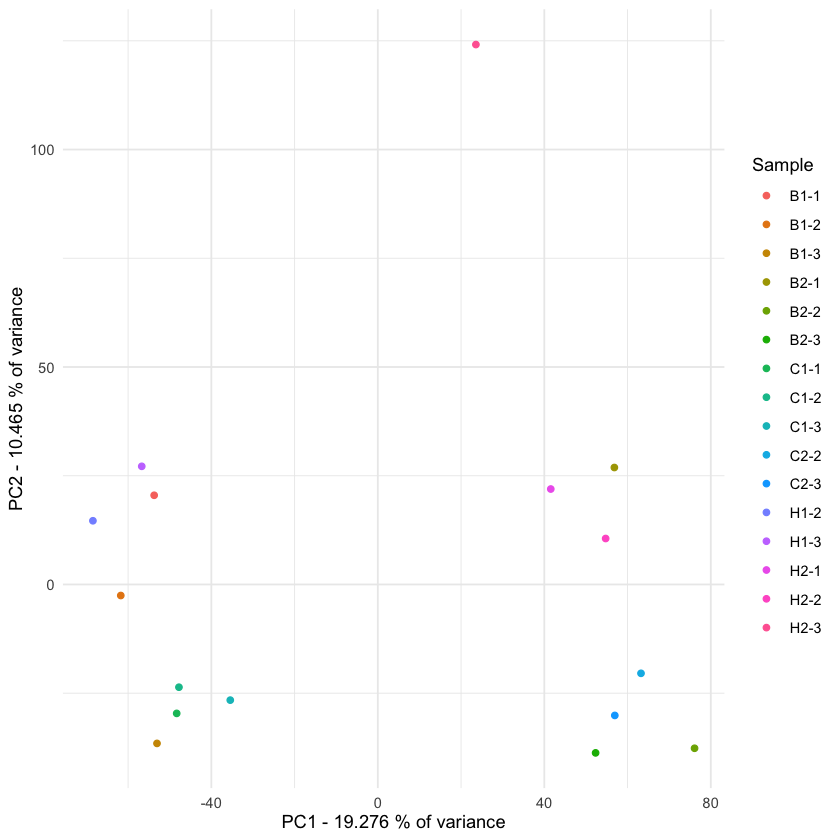

In [8]:
# PCA with all samples, TPM normalised
pca(countsTPM)

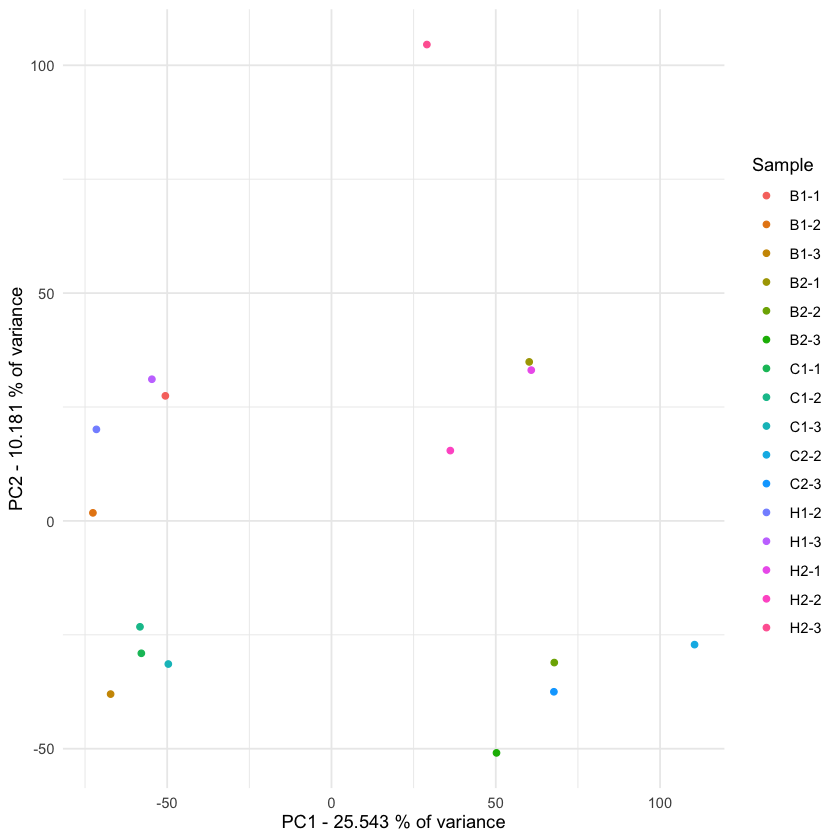

In [9]:
# PCA with all samples, log2 normalized
pca(countsLOG)

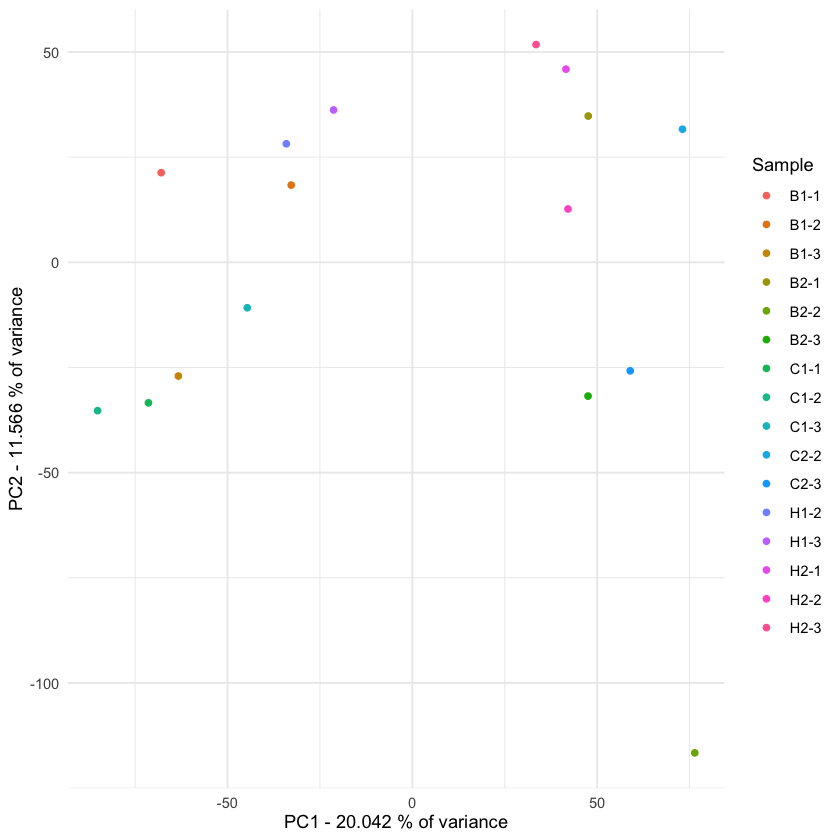

In [10]:
# PCA with all samples, raw counts
pca(countsRAW)

#### PCA with sample annotation

In [11]:
# Define a function for PCA by cell state

pca_by_state <- function(x, anno){
  
  tpm_pca <- prcomp(t(as.matrix(x)), center = TRUE, scale = TRUE)
  
  # Get contributions of variance of each PC
  pc1 <- summary(tpm_pca)$importance[2,1]*100
  pc2 <- summary(tpm_pca)$importance[2,2]*100
  
  # Configure dataframe for PC1 and PC2 coordinates for all samples
  pcs_1_2 <- tpm_pca$x[,1:2]
  sample_info <- anno[rownames(pcs_1_2),c('Cell_state', 'Treatment', 'Replicate')]
  pcs_1_2_sample <- data.frame(cbind(pcs_1_2, rownames(pcs_1_2), sample_info))
  colnames(pcs_1_2_sample) <- c("PC1", "PC2", "Sample", "Cell_state", "Treatment", "Replicate")
  
  # Transform coordinates to values that can be calculated with
  pcs_1_2_sample$PC1 <- as.numeric(as.character(pcs_1_2_sample$PC1))
  pcs_1_2_sample$PC2 <- as.numeric(as.character(pcs_1_2_sample$PC2))
  
  # Plot data
  p <- ggplot(pcs_1_2_sample, aes(x = PC1, y = PC2, color = Cell_state))+
    geom_point()+
    theme_minimal()+
    xlab(paste0("PC1 - ", pc1, " % of variance"))+
    ylab(paste0("PC2 - ", pc2, " % of variance"))+
    theme(legend.position = "right")
  
  return(p)
}

Plot PCA with annotation of samples.

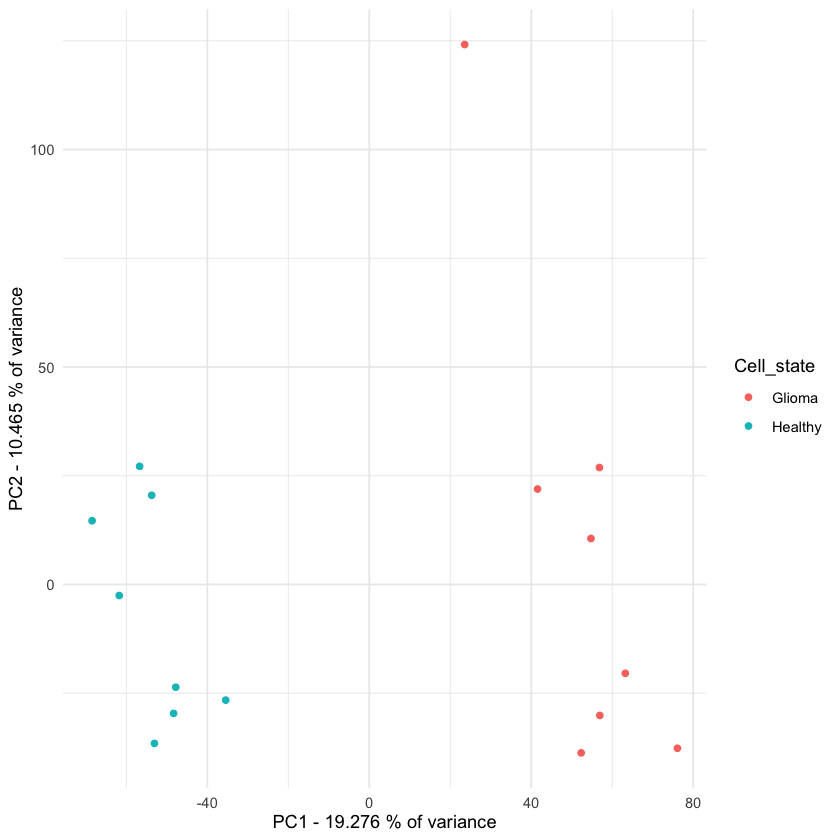

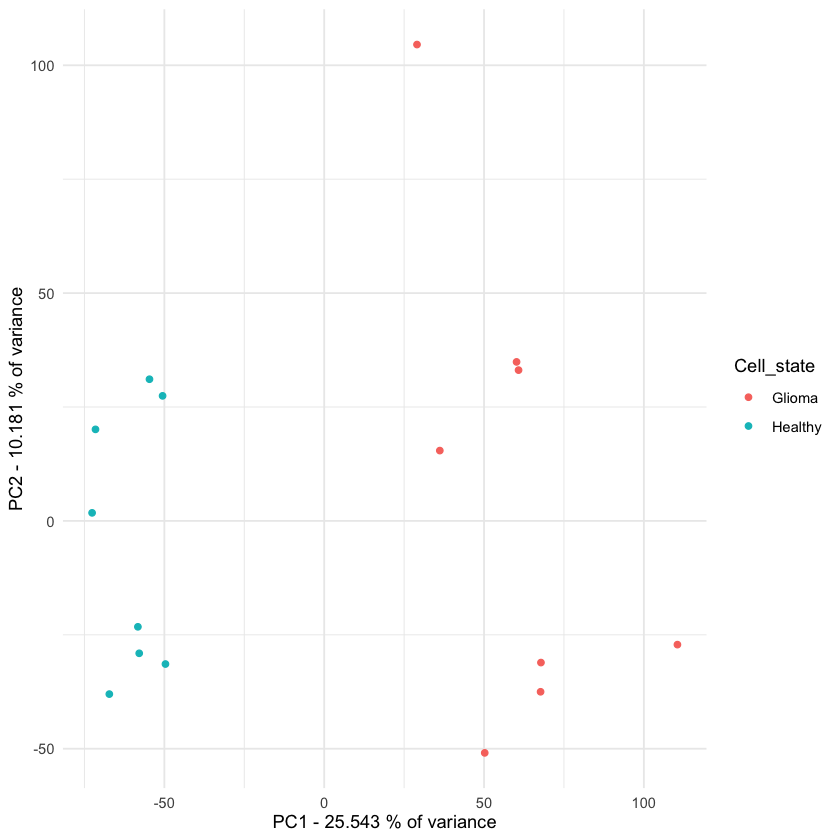

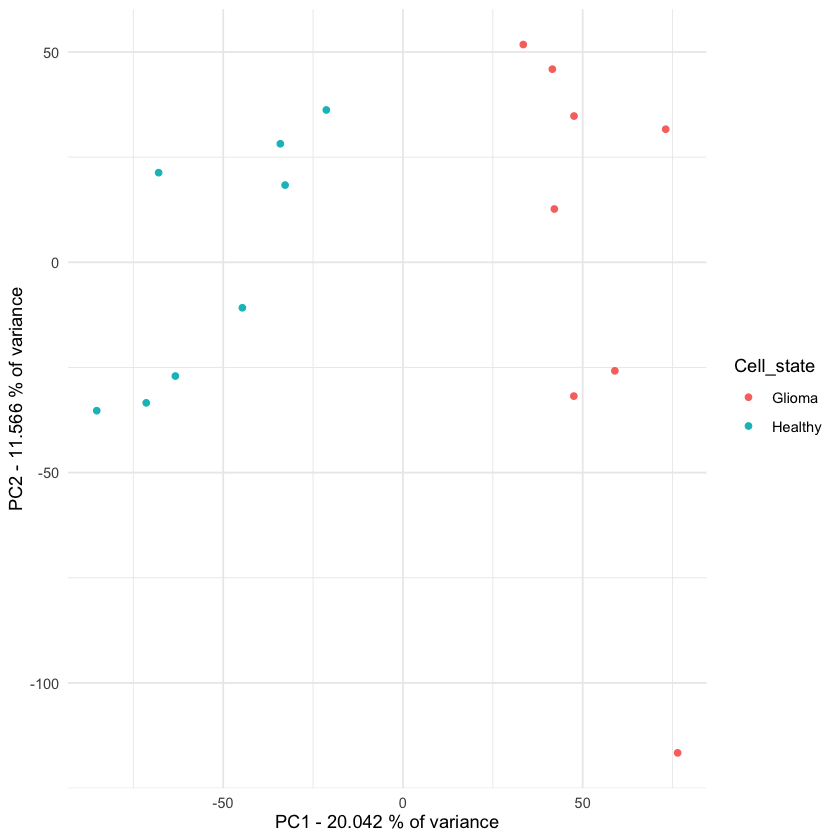

In [12]:
pca_by_state(countsTPM, anno)
pca_by_state(countsLOG, anno)
pca_by_state(countsRAW, anno)

In [13]:
# Define a function for PCA by treatment

pca_by_treatment <- function(x, anno){
  
  tpm_pca <- prcomp(t(as.matrix(x)), center = TRUE, scale = TRUE)
  
  # Get contributions of variance of each PC
  pc1 <- summary(tpm_pca)$importance[2,1]*100
  pc2 <- summary(tpm_pca)$importance[2,2]*100
  
  # Configure dataframe for PC1 and PC2 coordinates for all samples
  pcs_1_2 <- tpm_pca$x[,1:2]
  sample_info <- anno[rownames(pcs_1_2),c('Cell_state', 'Treatment', 'Replicate')]
  pcs_1_2_sample <- data.frame(cbind(pcs_1_2, rownames(pcs_1_2), sample_info))
  colnames(pcs_1_2_sample) <- c("PC1", "PC2", "Sample", "Cell_state", "Treatment", "Replicate")
  
  # Transform coordinates to values that can be calculated with
  pcs_1_2_sample$PC1 <- as.numeric(as.character(pcs_1_2_sample$PC1))
  pcs_1_2_sample$PC2 <- as.numeric(as.character(pcs_1_2_sample$PC2))
  
  # Plot data
  p <- ggplot(pcs_1_2_sample, aes(x = PC1, y = PC2, color = Treatment, shape = Cell_state))+
    geom_point()+
    theme_minimal()+
    xlab(paste0("PC1 - ", pc1, " % of variance"))+
    ylab(paste0("PC2 - ", pc2, " % of variance"))+
    theme(legend.position = "right")
  
  return(p)
}

Plot PCA with annotation of samples.

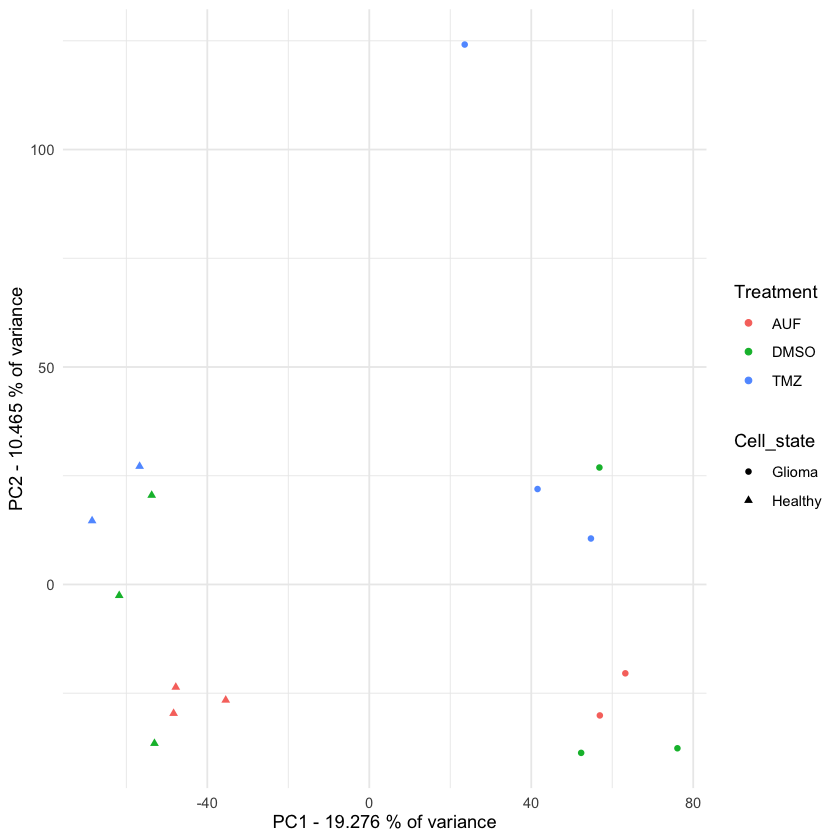

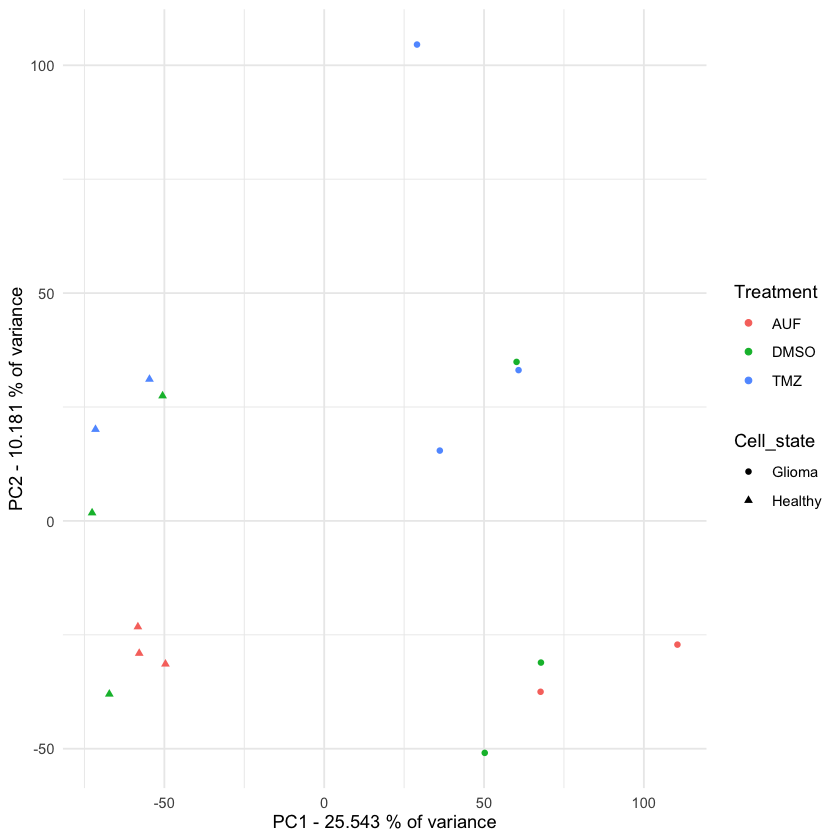

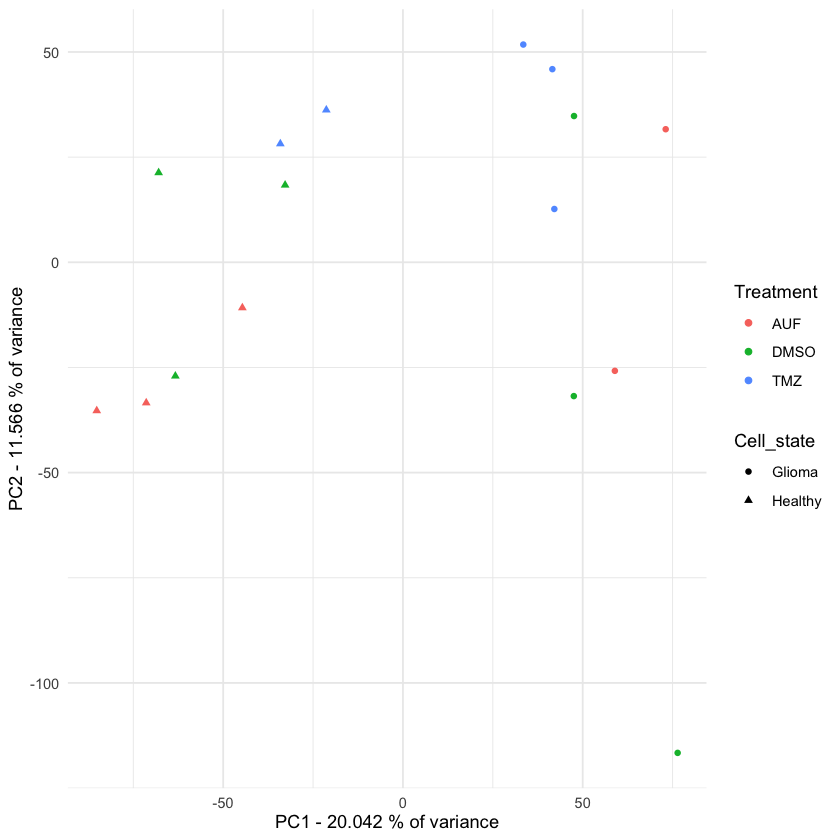

In [14]:
pca_by_treatment(countsTPM, anno)
pca_by_treatment(countsLOG, anno)
pca_by_treatment(countsRAW, anno)

# 3. Compare samples among each other by Pearson's correlation

Pearson's correlations measures the strength of a linear relatioship between 2 variables on a spectrum of -1 to 1. 

1 is a perfect positive relationship, -1 is a perfect negative relationship. 0 is no linear relationship.

Our conditions of interest are TMZ, AUF, and DMSO across HCs and Glioma oragnoids.

,Cell_state,Treatment
,<chr>,<chr>
B1-1,Healthy,DMSO
B1-2,Healthy,DMSO
B1-3,Healthy,DMSO
B2-1,Glioma,DMSO
B2-2,Glioma,DMSO
B2-3,Glioma,DMSO
C1-1,Healthy,AUF
C1-2,Healthy,AUF
C1-3,Healthy,AUF


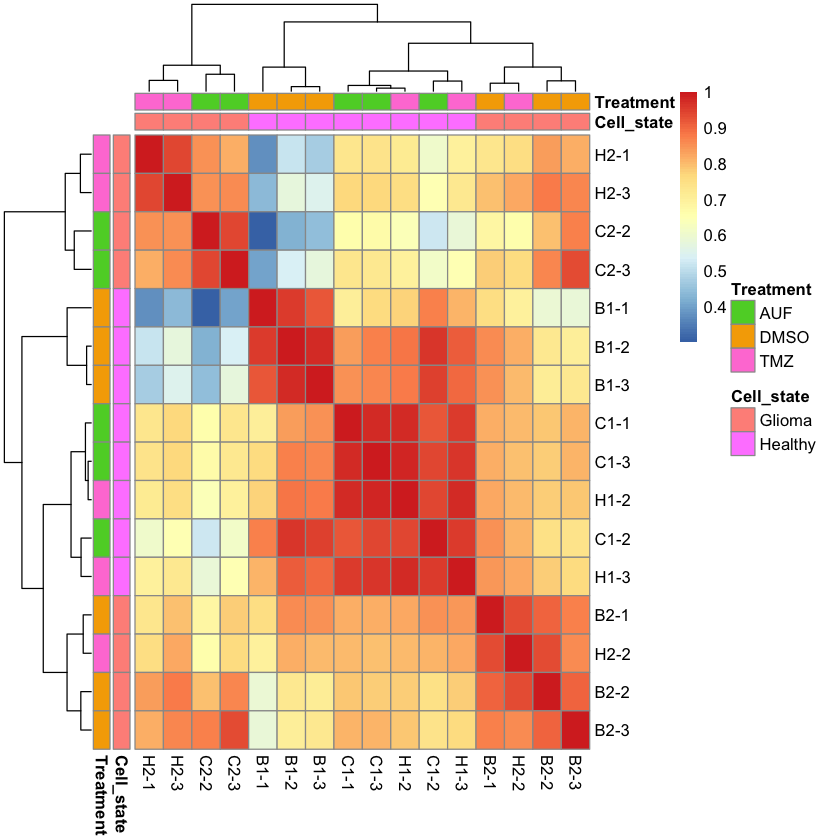

In [15]:
# Pearson Correleation between samples
res <- cor(countsTPM, method = 'pearson')

anno_for_res <- anno[rownames(res), c("Cell_state", "Treatment")]
anno_for_res

pheatmap(res, annotation_row = anno_for_res, annotation_col = anno_for_res)

# 4. Plot a heatmap

In a heatmap, one can visualize the overall expression of genes. Here, we filter out the 2,000 most variable genes and z-score-normalize each gene that across all samples.

Z score measures the distance of a gene expression value from the mean across samples (std). 

A sample value can 1, 2, or 3 std away from the mean. z > 0 shows a higher-than-average expression. and z < 0 shows lower than average expression for that gene. 

Basically: which samples have higher or lower expression relative to the gene’s mean.

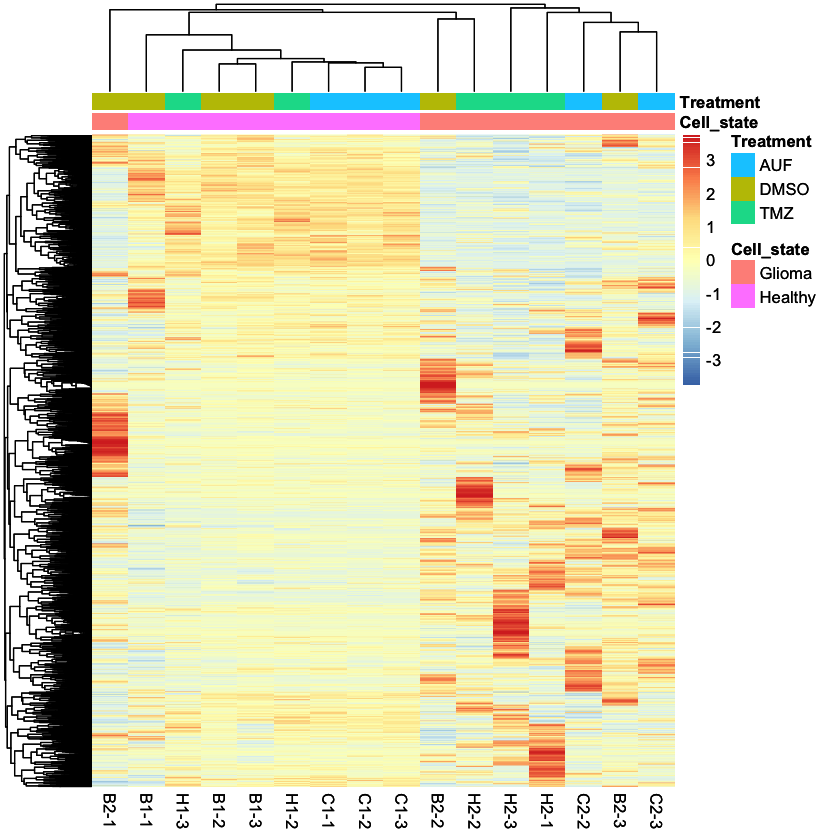

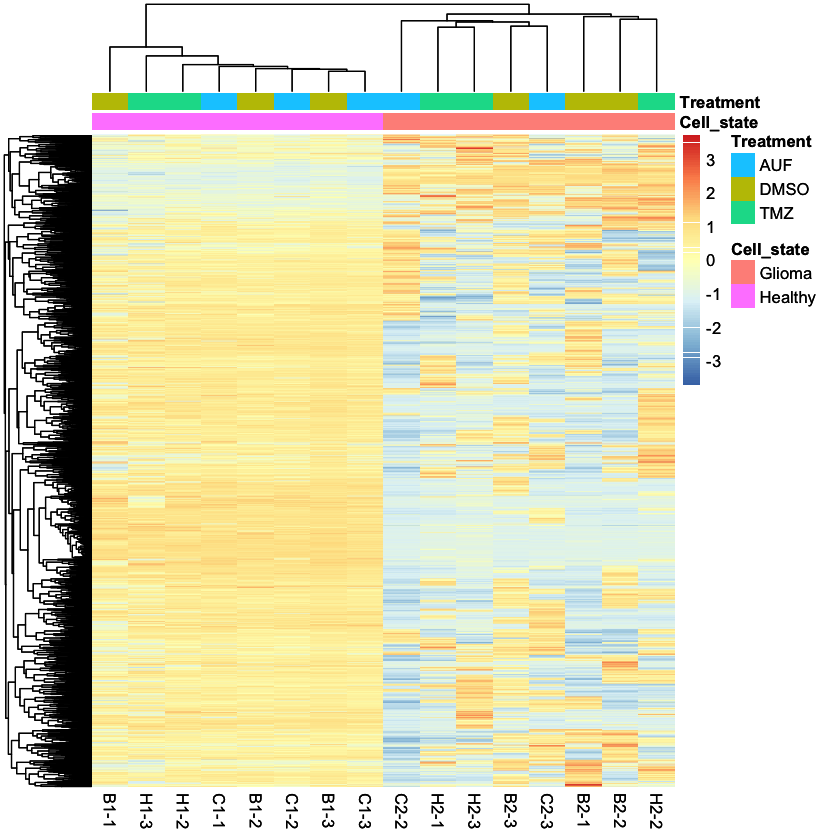

In [16]:
# Define function for filtering top expressing genes and plotting a heatmap

heatmap_plot <- function(x, anno, a="row", f=10){
  library(pheatmap)
  x <- x[order(rowVars(as.matrix(x), useNames = TRUE),decreasing=TRUE),]
  tpm_mat <- as.matrix(x)
  rownames(tpm_mat) <- rownames(x)
  tpm_mat_selected <- tpm_mat[1:2000,]
  #my_hclust_gene <- hclust(dist(tpm_mat_selected), method = "complete")
  #my_gene_col <- as.data.frame(cutree(tree = as.dendrogram(my_hclust_gene), k = f))
  #colnames(my_gene_col) <- "Cluster"
  anno_edit <- anno[colnames(tpm_mat_selected), c("Cell_state", "Treatment")]
  p <- pheatmap(tpm_mat_selected, scale=a, cluster_rows = T, cluster_cols = T, show_rownames = F, annotation_col = anno_edit)
  return(p)
}

#### z-normalize before clustering ####

# Heatmap for all samples with z-score
heatmap_plot(countsTPM, anno, "row", 10)
heatmap_plot(countsLOG, anno, "row", 10)

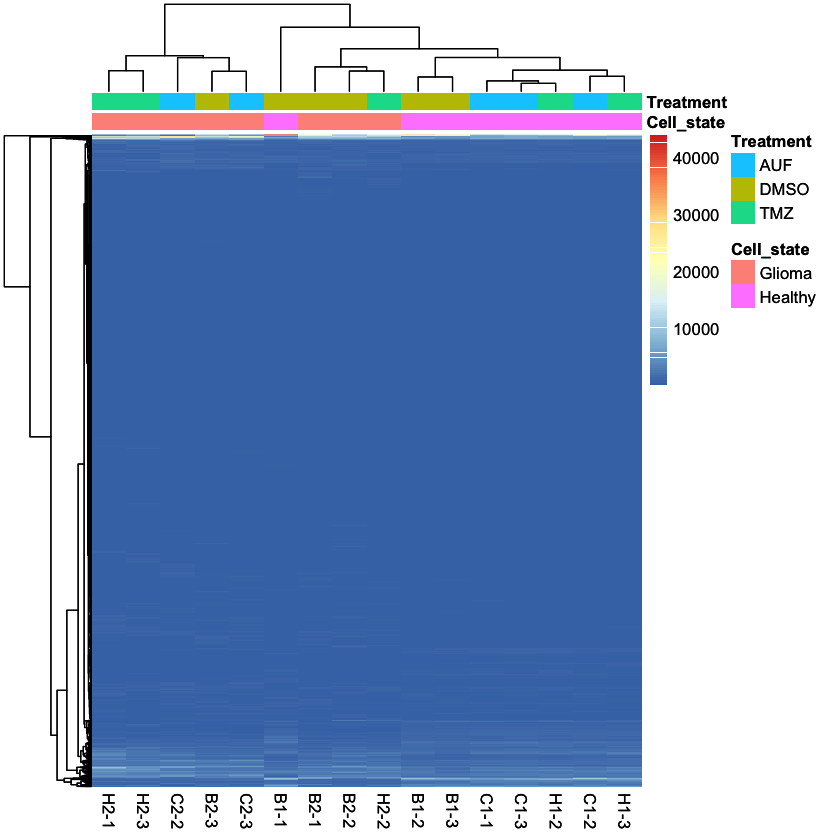

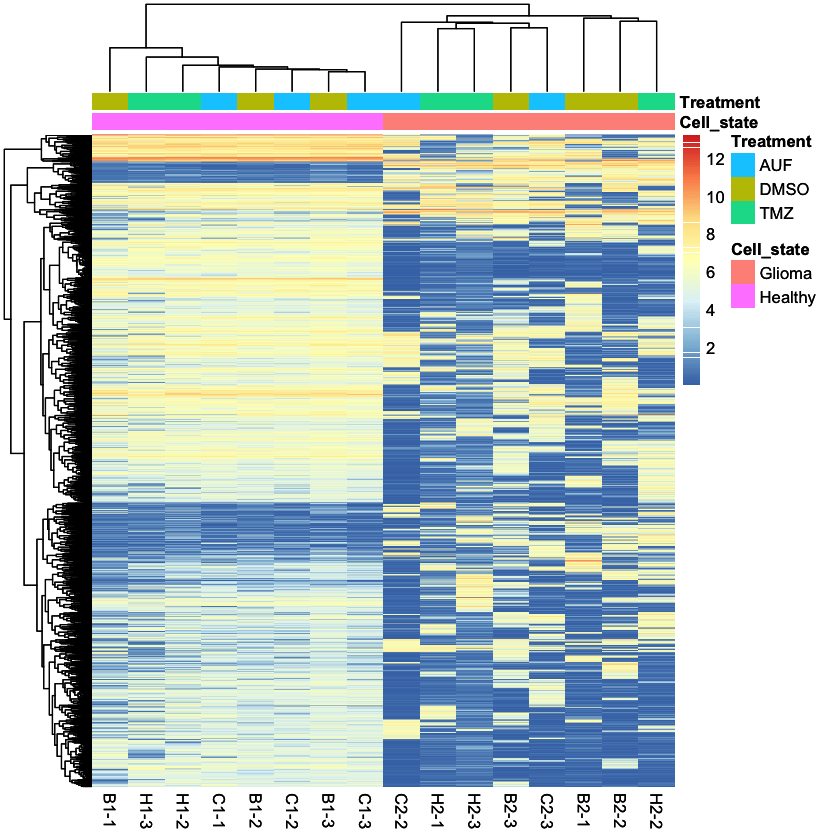

In [17]:
# Define function for filtering top expressing genes and plotting a heatmap

heatmap_plot_unscaled <- function(x, anno, f=10){
  library(pheatmap)
  x <- x[order(rowVars(as.matrix(x), useNames = TRUE),decreasing=TRUE),]
  tpm_mat <- as.matrix(x)
  rownames(tpm_mat) <- rownames(x)
  tpm_mat_selected <- tpm_mat[1:2000,]
  anno_edit <- anno[colnames(tpm_mat_selected), c("Cell_state", "Treatment")]
  
  # create heatmap without z score normalization 
  p <- pheatmap(tpm_mat_selected, cluster_rows = T, cluster_cols = T, show_rownames = F, annotation_col = anno_edit)
  return(p)
}

# Heatmap for all samples without z-score
heatmap_plot_unscaled(countsTPM, anno, 10)
heatmap_plot_unscaled(countsLOG, anno, 10)

## 4.1 Gene expression in individual cell types.

Now we take a look at each cell type in individual heatmaps. We will produce heatmaps according to both log and TPM normalization to extract as much global information as possible. 

In [18]:
# Slightly adjusted heatmap plot, selecting for a specified cell type
heatmap_plot <- function(x, anno, a="row", cellType){
  anno_edit <- anno[colnames(x), c("Cell_state", "Treatment", "ID")]
  cell_states <- c(anno_edit[which(anno_edit$Cell_state == cellType), c('ID')])
  df <- x[,cell_states]
  y <- df[order(rowVars(as.matrix(df), useNames = TRUE),decreasing=TRUE),order(colnames(df))]
  tpm_mat <- as.matrix(y)
  rownames(tpm_mat) <- rownames(y)
  tpm_mat_selected <- tpm_mat[1:1000,]
  anno_edit <- anno_edit[colnames(tpm_mat_selected), c("Cell_state", "Treatment")]
  p <- pheatmap(tpm_mat_selected, scale=a, cluster_rows = T, cluster_cols = T, show_rownames = F, annotation_col = anno_edit)
  return(p)
}

### 4.1.1 Healthy cells

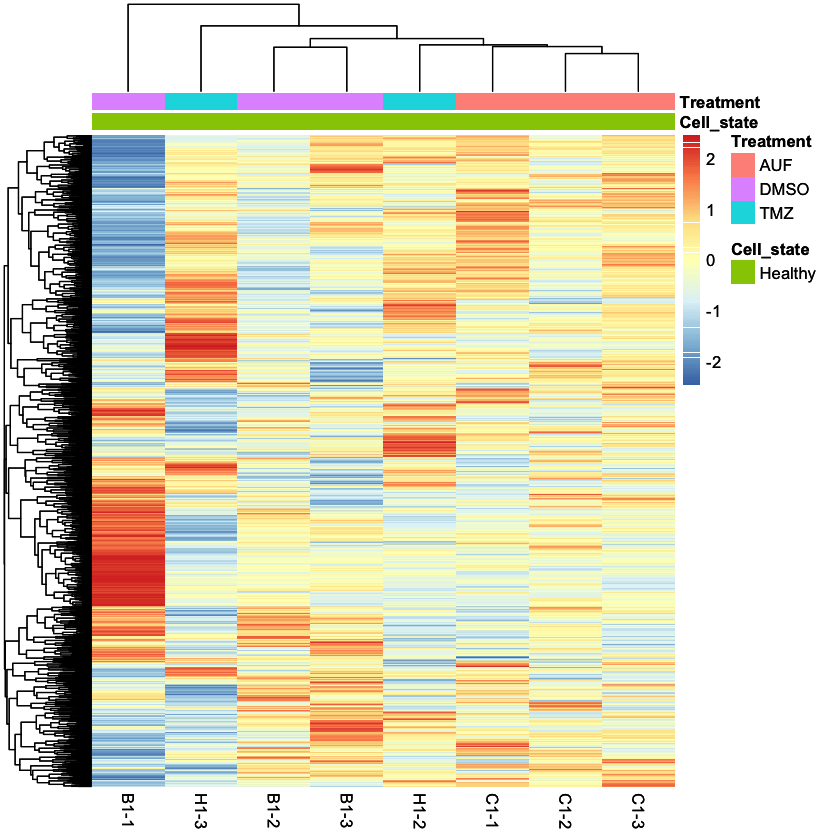

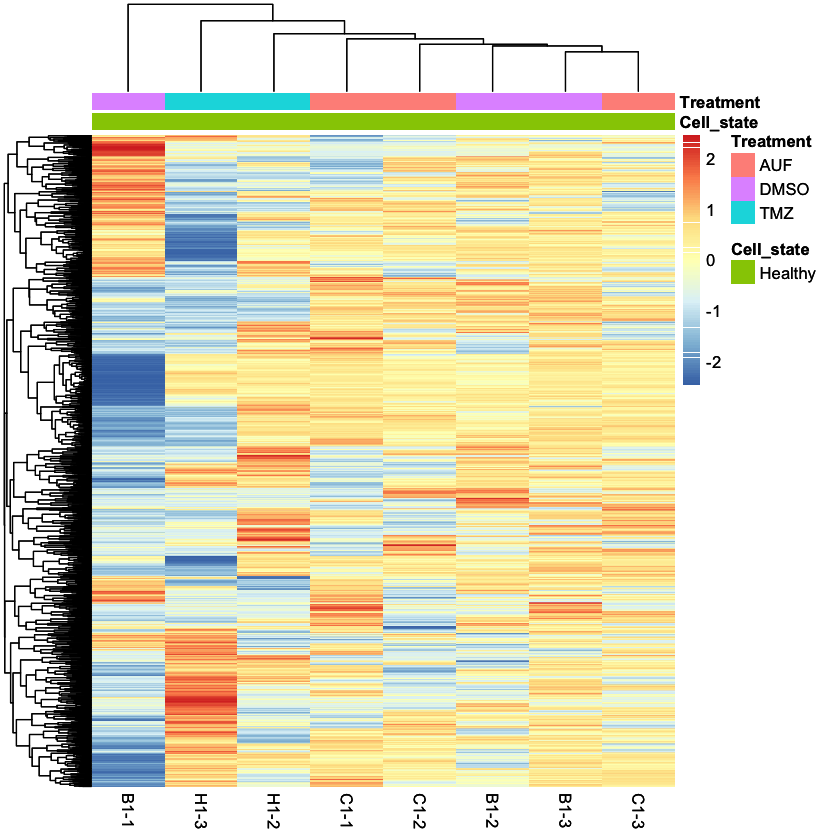

In [19]:
# Healthy cell state, based on TPM
heatmap_plot(countsTPM, anno, "row", cellType = 'Healthy')
# Healthy cell state, based on LOG
heatmap_plot(countsLOG, anno, "row", cellType = 'Healthy')

### 4.1.2 Glioma cells

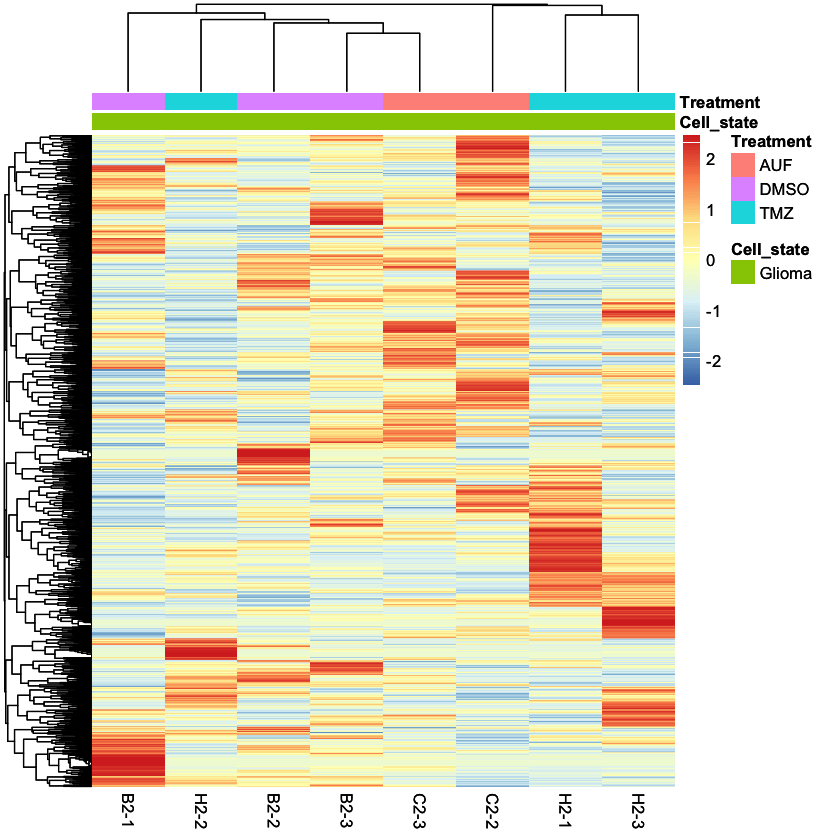

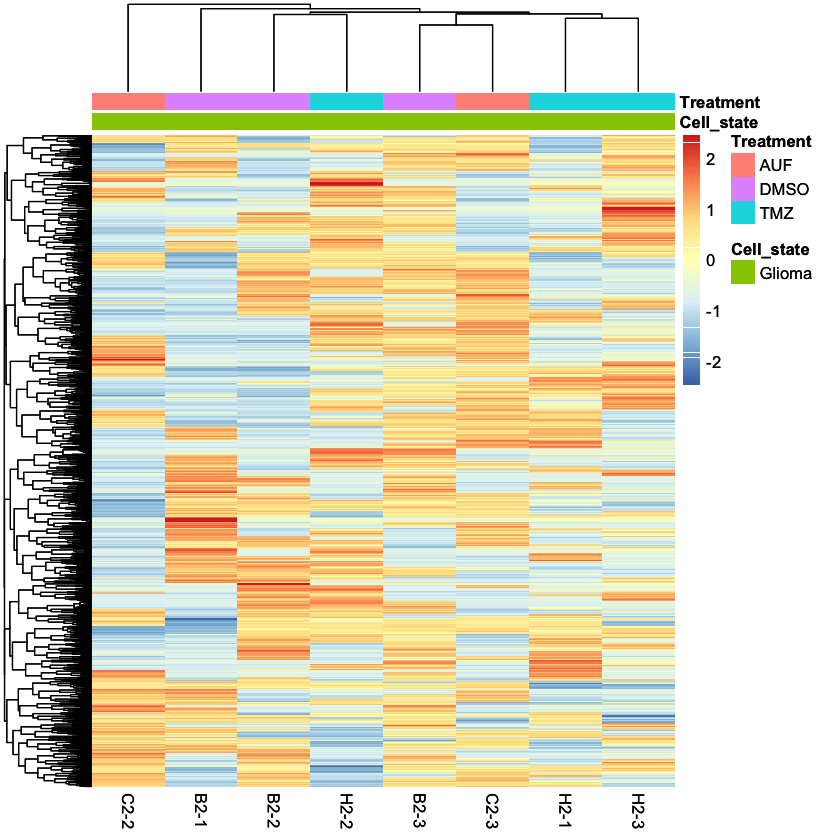

In [20]:
# Glioma cell state, based on TPM
heatmap_plot(countsTPM, anno, "row", cellType = 'Glioma')
# Glioma cell state, based on LOG
heatmap_plot(countsLOG, anno, "row", cellType = 'Glioma')

# 5. Analysis of cell type and marker-gene expression

Extracting glioma-specific markers from the literature and run analysis. Comparisons between TMZ, AUF, and DMSO groups. 

In [21]:
# Genes of interest
heatmap_plot <- function(x, anno, a="row", genes){
  anno_edit <- anno[colnames(x), c("Cell_state", "Treatment", "ID")]
  
  # Get samples for both cell states ordered by Cell_state then Treatment
  anno_ordered <- anno_edit[order(anno_edit$Cell_state, anno_edit$Treatment), ]
  
  df <- x[genes, rownames(anno_ordered)]
  tpm_mat <- as.matrix(df)
  rownames(tpm_mat) <- rownames(df)
  
  anno_col <- anno[colnames(tpm_mat), c("Cell_state", "Treatment")]
  
  if (a %in% c("row", "col")){
    p <- pheatmap(tpm_mat, scale=a, cluster_rows = F, cluster_cols = F, 
                  annotation_col = anno_col)
  } else {
    p <- pheatmap(tpm_mat, cluster_rows = F, cluster_cols = F, 
                  annotation_col = anno_col)
  }
  return(p)
}

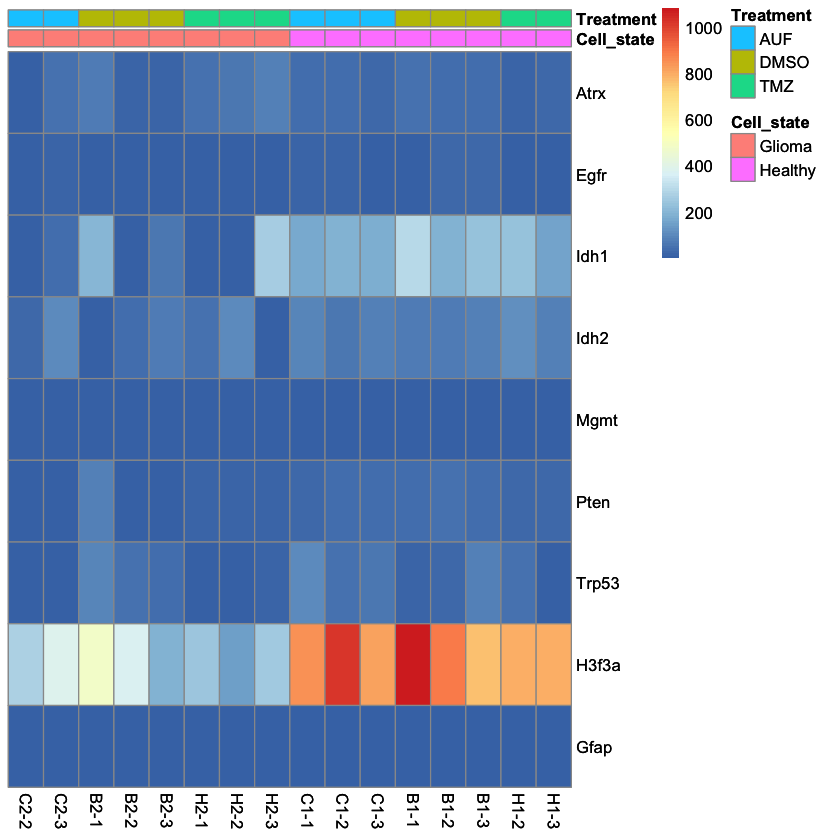

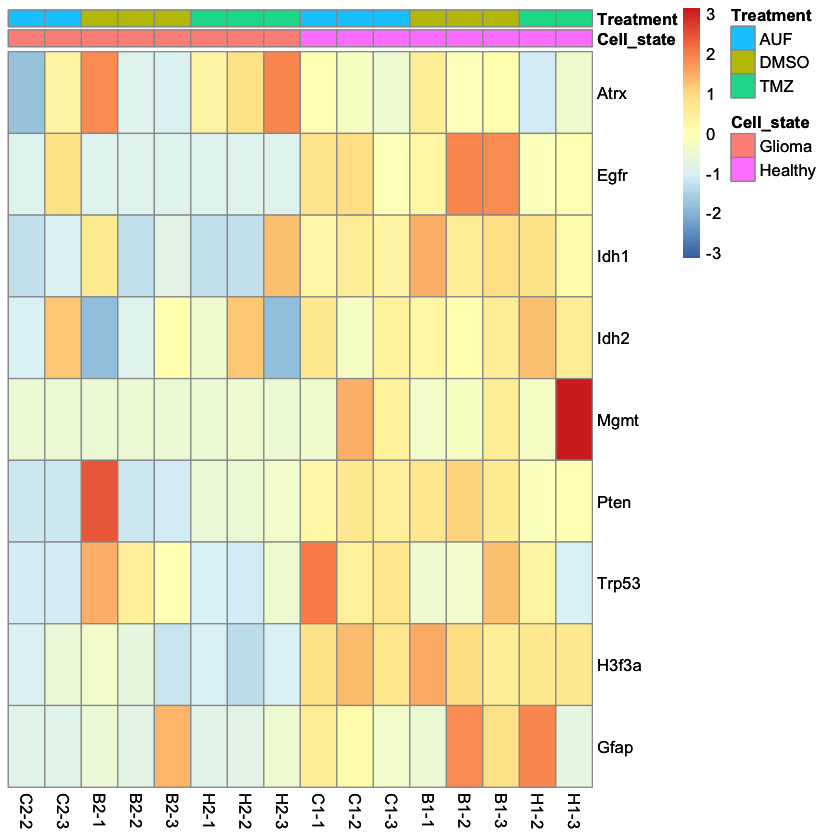

In [22]:
print(heatmap_plot(countsTPM, anno, "none", genes = c('Atrx', 'Egfr', 'Idh1', 'Idh2', 'Mgmt', 'Pten', 'Trp53', 'H3f3a', 'Gfap')))
print(heatmap_plot(countsTPM, anno, "row", genes = c('Atrx', 'Egfr', 'Idh1', 'Idh2', 'Mgmt', 'Pten', 'Trp53', 'H3f3a', 'Gfap')))

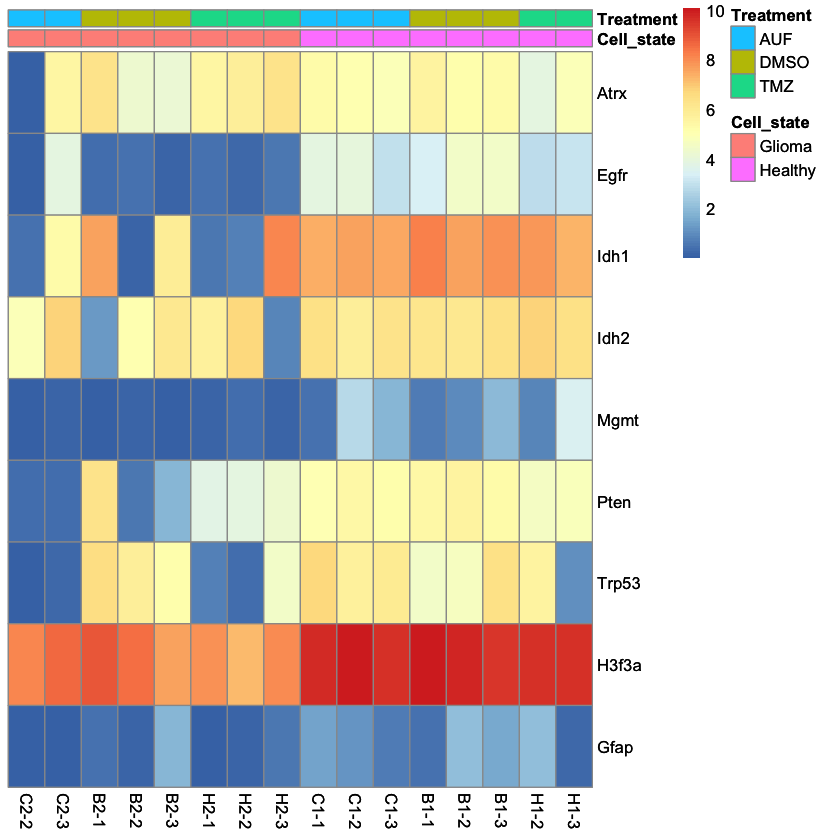

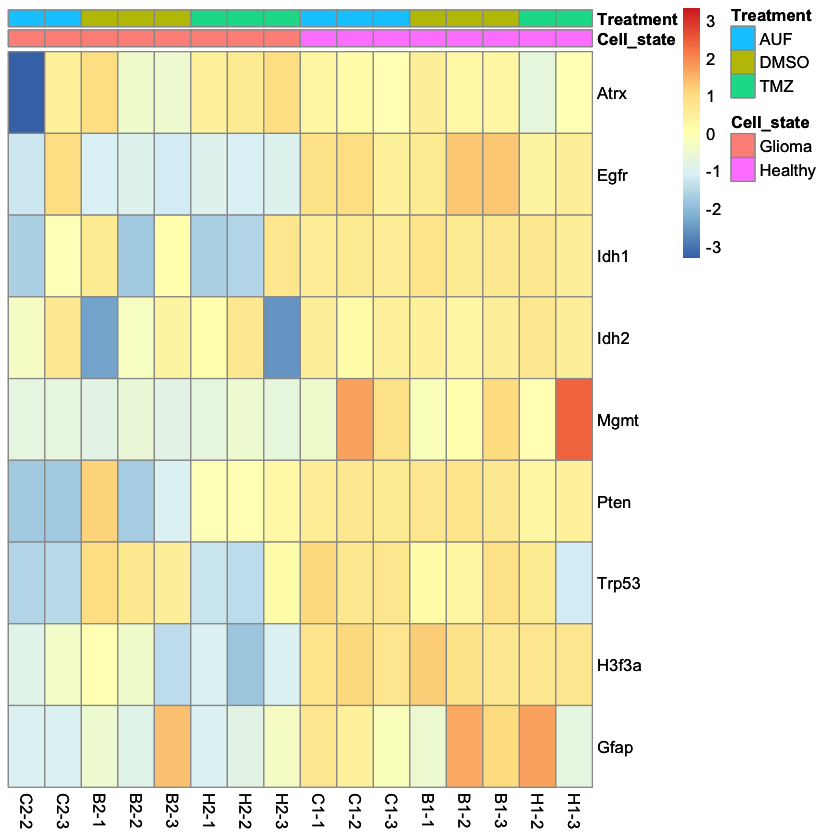

In [23]:
print(heatmap_plot(countsLOG, anno, "none", genes = c('Atrx', 'Egfr', 'Idh1', 'Idh2', 'Mgmt', 'Pten', 'Trp53', 'H3f3a', 'Gfap')))
print(heatmap_plot(countsLOG, anno, "row", genes = c('Atrx', 'Egfr', 'Idh1', 'Idh2', 'Mgmt', 'Pten', 'Trp53', 'H3f3a', 'Gfap')))

## 5.2 Marker-gene expression plots

In [24]:
plot_markers_combined <- function(x, anno, genes, scale = "linear") {
  
  # Keep relevant annotation
  anno_edit <- anno[colnames(x), c("Cell_state", "Treatment", "ID")]
  
  # Subset matrix
  df <- x[, anno_edit$ID]
  y <- df[genes, order(colnames(df))]
  y <- t(y)
  y <- as.data.frame(y)

  # Add metadata
  y$Sample <- rownames(y)
  y$Treatment <- anno_edit[y$Sample, "Treatment"]
  y$Cell_state <- anno_edit[y$Sample, "Cell_state"]

  # Melt
  df_melt <- reshape2::melt(y, id = c("Sample", "Treatment", "Cell_state"))
  colnames(df_melt) <- c('Sample', 'Treatment', 'Cell_state',
                         'Gene', 'TPM_normalized_expression')

  # Plot
  p <- ggplot(df_melt,
              aes(x = Cell_state,
                  y = TPM_normalized_expression,
                  fill = Treatment,
                  colour = Treatment)) +
    geom_dotplot(binaxis='y',
                 stackdir='center',
                 stackratio=1.5,
                 dotsize = 0.5) +
    facet_grid(~ Gene, switch = "x") +
    theme_minimal() +
    theme(panel.spacing.x = grid::unit(0, "mm"),
          strip.placement = "outside",
          strip.background = element_blank(),
          axis.text.x = element_text(angle = 45, hjust = 1)) +
    stat_summary(fun = mean,
                 geom="point",
                 shape=10,
                 size=3,
                 color="grey")


  if (scale == "log") {
    p <- p + scale_y_continuous(trans = 'log10')
  }

  return(p)
}

Bin width defaults to 1/30 of the range of the data. Pick better value with
`binwidth`.


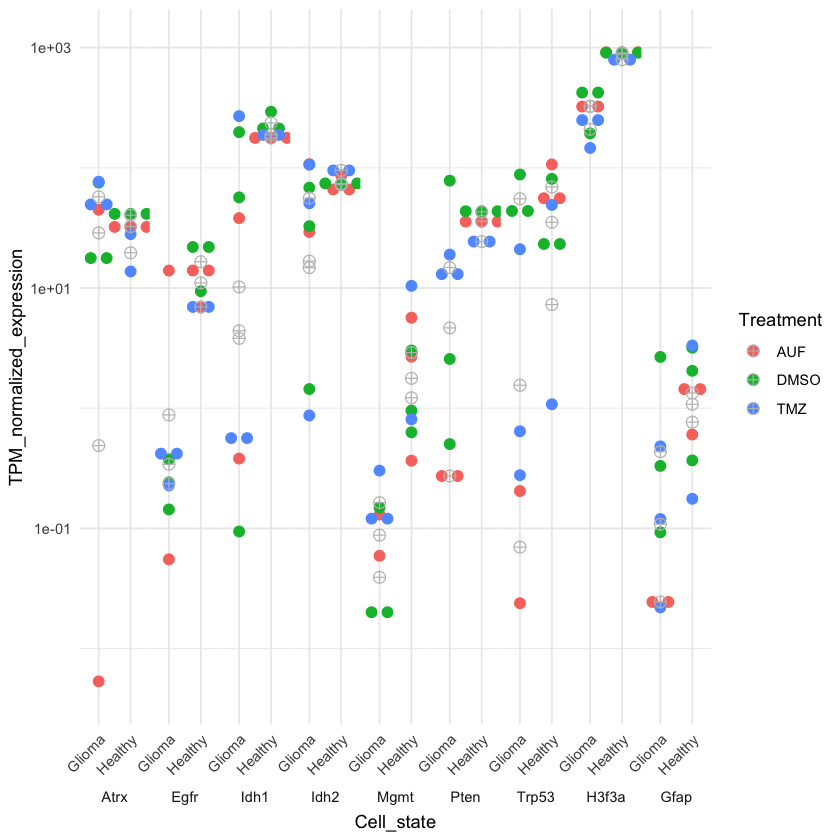

In [25]:
p <- plot_markers_combined(
  x = countsTPM,
  anno = anno,
  genes = c('Atrx', 'Egfr', 'Idh1', 'Idh2', 'Mgmt',
            'Pten', 'Trp53', 'H3f3a', 'Gfap'),
  scale = 'log'
)
p

- H3f3a — strongly upregulated in Glioma vs Healthy, which fits as H3F3A mutations are a hallmark of pediatric glioma. 
- Idh1/Idh2 — higher expression in Glioma, consistent with IDH mutations being a key glioma driver.
- Mgmt — very low/variable expression in Glioma, with some near-zero values. MGMT promoter methylation silencing expression is a known glioma feature, so this fits
- Other findigs are not specifically notable.

# 6. DE analysis

DESeq2 for identification of DE genes between conditions (for each cell type, compare treatements with each other). More info given in https://bioconductor.org/packages/3.21/bioc/vignettes/DESeq2/inst/doc/DESeq2.html#countmat.

Import the coldata that annotates the samples (colnames) and make sure they are in same order as in raw counts (only raw counts may be put into DESeq2).

DESeq analysis will be performed for each cell type individually here.

DE analysis statistically tests each gene to see whether the difference in expression between groups is larger than expected by random variation.

In [26]:
coldata <- anno
coldata <- coldata[colnames(countsRAW),]
coldata$Treatment <- factor(coldata$Treatment)
coldata$Cell_state <- factor(coldata$Cell_state)
coldata$Replicate <- factor(coldata$Replicate)
head(coldata)
dim(coldata)

,Cell_state,Treatment,ID_old,No_cells,ID,Replicate
,<fct>,<fct>,<chr>,<int>,<chr>,<fct>
B1-1,Healthy,DMSO,B1_1,5000,B1-1,1
B1-2,Healthy,DMSO,B1_2,5000,B1-2,2
B1-3,Healthy,DMSO,B1_3,5000,B1-3,3
B2-1,Glioma,DMSO,B2_1,600,B2-1,1
B2-2,Glioma,DMSO,B2_2,800,B2-2,2
B2-3,Glioma,DMSO,B2_3,1100,B2-3,3


[1] 16  6

Raw counts will be used for DE analysis.

In [27]:
head(countsRAW)

,B1-1,B1-2,B1-3,B2-1,B2-2,B2-3,C1-1,C1-2,C1-3,C2-2,C2-3,H1-2,H1-3,H2-1,H2-2,H2-3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Xkr4,29,19,13,2,10,2,6,23,12,7,9,30,20,7,6,5
Gm53491,20,19,10,5,5,0,9,18,7,0,10,9,18,4,1,1
Rp1,23,19,10,4,10,7,12,16,7,11,9,30,13,7,7,16
Sox17,15,23,2,6,0,0,19,27,7,0,0,16,27,3,2,4
Mrpl15,1422,906,1672,28,1213,1700,2563,1490,1964,3660,3842,1173,1177,98,69,2
Lypla1,696,237,394,6,77,6,667,440,310,0,358,363,311,3,1,5


## 6.1 DE objects for distinct cell states

Function to get results for specific contrasts (comparisons), plot MAplot and get list of DEgenes between conditions.

In [28]:
getDEanalysis <- function(dds, comparison, countData, coldata){
  res <- results(dds, contrast = comparison, alpha = 0.05) # significance threshold for adjusted p-value of 5 %
  plotMA(res, ylim = c(-8,8), main = paste0(comparison[2],"_vs_",comparison[3]))
  summary(res)
  print(paste0("Significant DE genes at adjusted p-value of 0.05: ", sum(res$padj < 0.05, na.rm=TRUE)))
  resOrdered <- res[order(res$padj),]
  resSig <- subset(resOrdered, padj < 0.05)
  df <- countData[rownames(resSig),order(colnames(countData))]
  anno <- coldata[colnames(df), c("Cell_state", "Treatment")]
  if ((length(rownames(resSig)) < 30) & (length(rownames(resSig)) > 1)){
    pheatmap(df, cluster_cols = FALSE, scale = "row", cluster_rows = TRUE, annotation_col = anno)
  } else if (length(rownames(resSig)) >= 30) {
    pheatmap(df, cluster_cols = FALSE, scale = "row", cluster_rows = TRUE, show_rownames = FALSE, annotation_col = anno)
  }
  
  return(resSig)
}

Function to perform a comprehensive DE and enrichment analysis 

In [39]:
getDEanalysisFull <- function(dds, comparison, countData, coldata, ontology = "BP",
                              nTopGO = 15) {

  library(topGO)
  library(org.Mm.eg.db)
  library(AnnotationDbi)
  library(ggplot2)
  library(pheatmap)

  ## ──────────────────────────────────────────────
  ## Differential expression
  ## ──────────────────────────────────────────────

  res <- results(dds, contrast = comparison, alpha = 0.05)
  res_shrunk <- DESeq2::lfcShrink(dds, contrast = comparison, type = "ashr")
  res_shrunk <- res_shrunk[!is.na(res_shrunk$log2FoldChange) & abs(res_shrunk$log2FoldChange) <= 10, ]
  resOrdered <- res_shrunk[order(res_shrunk$padj), ]
  resSig <- subset(resOrdered, padj < 0.05)

  message("Significant DE genes (padj < 0.05): ", nrow(resSig))

  ## Volcano plot
  res_df <- as.data.frame(res_shrunk)
  res_df$gene <- rownames(res_df)
  res_df$neglog10padj <- -log10(res_df$padj)
  res_df$sig <- ifelse(res_df$padj < 0.05, "Significant", "Not significant")

  volcano_plot <- ggplot(res_df, aes(x = log2FoldChange, y = neglog10padj, color = sig)) +
    geom_point(alpha=0.7) +
    scale_color_manual(values = c("grey", "#D55E00")) +
    ggrepel::geom_text_repel(
      data = subset(res_df, padj < 0.05),
      aes(label = gene),
      size = 2.5,
      max.overlaps = 20,
      color = "black"
    ) +
    labs(title="Volcano Plot", x="log2 Fold Change", y="-log10(adjusted p)") +
    theme_bw() +
    xlim(-10, 10) +
    ylim(0, 12.5)

  ## ──────────────────────────────────────────────
  ## Split into over- and under-expressed sets
  ## ──────────────────────────────────────────────
  res_over  <- subset(resSig, log2FoldChange > 0)
  res_under <- subset(resSig, log2FoldChange < 0)

  message("Over-expressed genes: ", nrow(res_over))
  message("Under-expressed genes: ", nrow(res_under))

  ## Helper function to perform topGO and generate plots
  run_topGO <- function(sigGenes, universeGenes, label) {

    if (length(sigGenes) < 5) {
      message("Skipping topGO for ", label, " — not enough significant genes.")
      return(list(results=NULL, bar=NULL, dot=NULL))
    }

    geneList <- factor(as.integer(universeGenes %in% sigGenes))
    names(geneList) <- universeGenes

    geneID2GO <- annFUN.org(
      whichOnto = ontology,
      feasibleGenes = universeGenes,
      mapping = "org.Mm.eg.db",
      ID = "SYMBOL"
    )

    GOdata <- new("topGOdata",
                  ontology = ontology,
                  allGenes = geneList,
                  annot = annFUN.GO2genes,
                  GO2genes = geneID2GO,
                  nodeSize = 5)

    resultFisher <- runTest(GOdata, algorithm="weight01", statistic="fisher")

    goRes <- GenTable(GOdata,
                      Fisher = resultFisher,
                      orderBy = "Fisher",
                      topNodes = length(score(resultFisher)),
                      numChar = 1000)
    goRes$Fisher <- as.numeric(goRes$Fisher)
    goRes <- goRes[goRes$Fisher < 0.05, ]

    if (nrow(goRes) == 0) {
      message("No GO terms enriched for ", label)
      return(list(results=goRes, bar=NULL, dot=NULL))
    }

    ## Select top N
    topN <- min(nTopGO, nrow(goRes))
    goTop <- goRes[1:topN, ]
    print("Inspect goTop object:")
    print(goTop)
    goTop$GeneRatio <- goTop$Significant / goTop$Annotated
    goTop$Term <- make.unique(as.character(goTop$Term))
    # goTop$Term <- factor(goTop$Term, levels = rev(goTop$Term))
    # Wrap long GO term names onto multiple lines
    goTop$Term_wrapped <- str_wrap(goTop$Term, width = 50)

    # Preserve plotting order
    goTop$Term_wrapped <- factor(goTop$Term_wrapped, levels = rev(goTop$Term_wrapped))

    ## Bar plot
    barplot <- ggplot(goTop, aes(x = Term_wrapped, y = -log10(Fisher))) +
      geom_bar(stat="identity", fill="#0072B2") +
      coord_flip() +
      labs(title=paste("Top", topN, ontology, "GO Terms —", label),
           y="-log10(p-value)", x="") +
      theme_bw()

    dotplot <- ggplot(goTop, aes(x = -log10(Fisher), y = Term_wrapped, size = GeneRatio)) +
  geom_point(color = "#D55E00") +
  scale_size_continuous(name = "Gene Ratio\n(DEGs/Annotated)") +
  labs(title = paste("GO Enrichment Dotplot —", label),
       x = "-log10(p-value)", y = "") +
  theme_bw()

    return(list(results=goRes, bar=barplot, dot=dotplot))
  }

  universe <- rownames(res_shrunk)

  ## Run GO for over- and under-expressed genes
  GO_over  <- run_topGO(rownames(res_over), universe, "Over-expressed")
  GO_under <- run_topGO(rownames(res_under), universe, "Under-expressed")

  ## Return everything
  return(list(
    DEgenes_over   = res_over,
    DEgenes_under  = res_under,
    GOresults_over = GO_over$results,
    GOresults_under = GO_under$results,
    GOplots = list(
      over = list(bar = GO_over$bar, dot = GO_over$dot),
      under = list(bar = GO_under$bar, dot = GO_under$dot)
    ),
    Volcanoplot = volcano_plot
  ))
}

Function to subset data to dataframe (tissue and treatments of interest) for creation of DESeq object

In [40]:
getDEresults <- function(df, coldata, tissue = "Healthy", treatment) {

  # subset to tissue (cell state)
  df_select <- df[, coldata$Cell_state == tissue, drop = FALSE]

  # metadata for the selected samples
  coldata_select <- coldata[colnames(df_select), c("Cell_state", "Treatment", "Replicate")]
  coldata_select <- dplyr::filter(coldata_select, Treatment %in% c("DMSO", treatment))

  # set factor levels so DESeq2 contrast works
  coldata_select$Treatment  <- factor(coldata_select$Treatment, levels = c("DMSO", treatment))
  coldata_select$Cell_state <- factor(coldata_select$Cell_state)
  coldata_select$Replicate  <- factor(coldata_select$Replicate)

  # reorder columns to match coldata_select row order
  df_select <- df_select[, rownames(coldata_select), drop = FALSE]

  # Gene filtering
  min_samples <- ceiling(ncol(df_select) * 0.5)
  keep <- rowSums(df_select > 10) >= min_samples
  df_select <- df_select[keep, ]

  # DESeq2
  dds <- DESeq2::DESeqDataSetFromMatrix(
    countData = round(df_select),
    colData   = coldata_select,
    design    = ~ Treatment
  )
  dds <- DESeq2::DESeq(dds)

  # return ONE object: a named list
  return(list(
    dds = dds,
    coldata_select = coldata_select,
    df = df_select
  ))
}

## 6.1.1 DESeq analysis for Healthy tissue

In [41]:
getAnywhere(getDEresults)

A single object matching ‘getDEresults’ was found
It was found in the following places
  .GlobalEnv
with value

function (df, coldata, tissue = "Healthy", treatment) 
{
    df_select <- df[, coldata$Cell_state == tissue, drop = FALSE]
    coldata_select <- coldata[colnames(df_select), c("Cell_state", 
        "Treatment", "Replicate")]
    coldata_select <- dplyr::filter(coldata_select, Treatment %in% 
        c("DMSO", treatment))
    coldata_select$Treatment <- factor(coldata_select$Treatment, 
        levels = c("DMSO", treatment))
    coldata_select$Cell_state <- factor(coldata_select$Cell_state)
    coldata_select$Replicate <- factor(coldata_select$Replicate)
    df_select <- df_select[, rownames(coldata_select), drop = FALSE]
    min_samples <- ceiling(ncol(df_select) * 0.5)
    keep <- rowSums(df_select > 10) >= min_samples
    df_select <- df_select[keep, ]
    dds <- DESeq2::DESeqDataSetFromMatrix(countData = round(df_select), 
        colData = coldata_select, design = ~Treat

converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



    B1-1     B1-2     B1-3     C1-1     C1-2     C1-3 
 9579166  6885817 10850871 11722036 12229472  9858959 

out of 14234 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 20, 0.14%
LFC < 0 (down)     : 23, 0.16%
outliers [1]       : 104, 0.73%
low counts [2]     : 1380, 9.7%
(mean count < 22)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results

[1] "Significant DE genes at adjusted p-value of 0.05: 43"


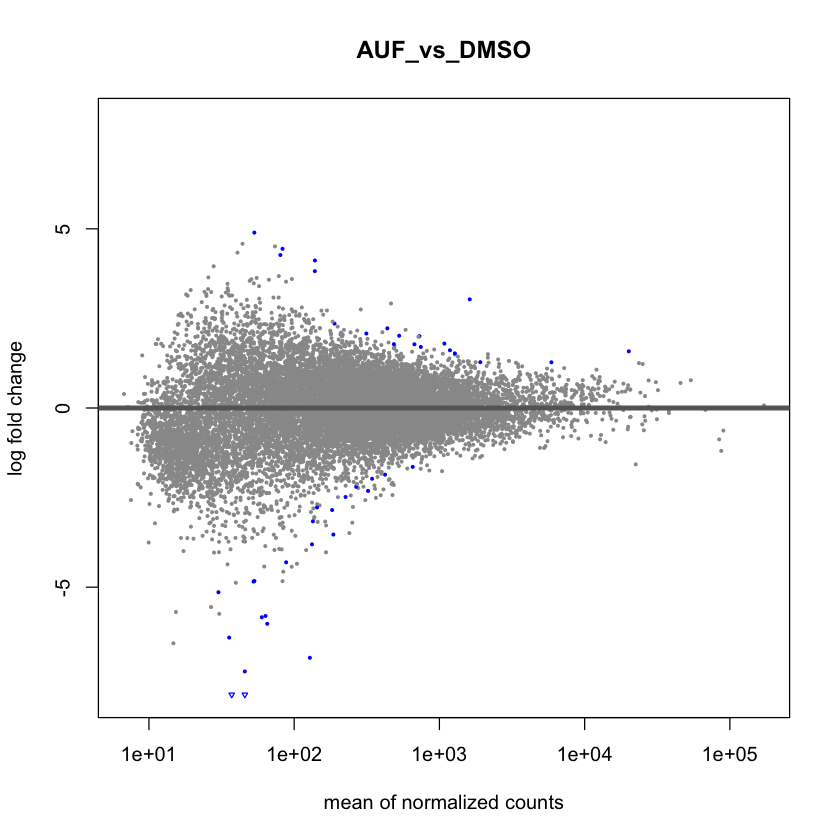

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

Significant DE genes (padj < 0.05): 39

Over-expressed genes: 18

Under-expressed genes: 21


Building most specific GOs .....

	( 11188 GO terms found. )


Build GO DAG topology ..........

	( 14232 GO terms and 31354 relations. )


Annotating nodes ...............

	( 12573 genes annotated to the GO terms. )


			 -- Weight01 Algorithm -- 

		 the algorithm is scoring 791 nontrivial nodes
		 parameters: 
			 test statistic: fisher


	 Level 16:	2 nodes to be scored	(0 eliminated genes)


	 Level 15:	4 nodes to be scored	(0 eliminated genes)


	 Level 14:	6 nodes to be scored	(33 eliminated genes)


	 Level 13:	10 nodes to be scored	(146 eliminated genes)


	 Level 12:	20 nodes to be scored	(317 eliminated genes)


	 Level 11:	36 nodes to be scored	(880 eliminated genes)


	 Level 1

[1] "Inspect goTop object:"
        GO.ID
1  GO:1901687
2  GO:0071638
3  GO:0051122
4  GO:0043651
5  GO:0043508
6  GO:0032691
7  GO:1904706
8  GO:0006693
9  GO:0032720
10 GO:0071671
11 GO:0006749
12 GO:0006805
13 GO:2001237
14 GO:0070373
15 GO:0071276
                                                                          Term
1                                  glutathione derivative biosynthetic process
2             negative regulation of monocyte chemotactic protein-1 production
3                                               hepoxilin biosynthetic process
4                                              linoleic acid metabolic process
5                                   negative regulation of JUN kinase activity
6                         negative regulation of interleukin-1 beta production
7  negative regulation of vascular associated smooth muscle cell proliferation
8                                              prostaglandin metabolic process
9                      negative regul


Building most specific GOs .....

	( 11188 GO terms found. )


Build GO DAG topology ..........

	( 14232 GO terms and 31354 relations. )


Annotating nodes ...............

	( 12573 genes annotated to the GO terms. )


			 -- Weight01 Algorithm -- 

		 the algorithm is scoring 664 nontrivial nodes
		 parameters: 
			 test statistic: fisher


	 Level 15:	1 nodes to be scored	(0 eliminated genes)


	 Level 14:	4 nodes to be scored	(0 eliminated genes)


	 Level 13:	7 nodes to be scored	(23 eliminated genes)


	 Level 12:	17 nodes to be scored	(252 eliminated genes)


	 Level 11:	34 nodes to be scored	(685 eliminated genes)


	 Level 10:	58 nodes to be scored	(1866 eliminated genes)


	 Level 9:	70 nodes to be scored	(3479 eliminated genes)


	 Level 8:	78 nodes to be scored	(5177 eliminated genes)


	 Level 7:	93 nodes to be scored	(6568 eliminated genes)


	 Level 6:	105 nodes to be scored	(7234 eliminated genes)


	 Level 5:	91 nodes to be scored	(8280 eliminated genes)


	 Level 4:	

[1] "Inspect goTop object:"
        GO.ID
1  GO:0044785
2  GO:0060527
3  GO:0043060
4  GO:0033087
5  GO:2000354
6  GO:0045835
7  GO:0072675
8  GO:0060631
9  GO:0044406
10 GO:2000726
11 GO:0015959
12 GO:0048840
13 GO:0033313
14 GO:1901994
15 GO:0030238
                                                                                        Term
1                                        metaphase/anaphase transition of meiotic cell cycle
2  prostate epithelial cord arborization involved in prostate glandular acinus morphogenesis
3                                        meiotic metaphase I homologous chromosome alignment
4                                       negative regulation of immature T cell proliferation
5                                                 regulation of ovarian follicle development
6                                            negative regulation of meiotic nuclear division
7                                                                          osteoclast fusion
8   

Warning message:
“Removed 932 rows containing missing values or values outside the scale range
(`geom_point()`).”


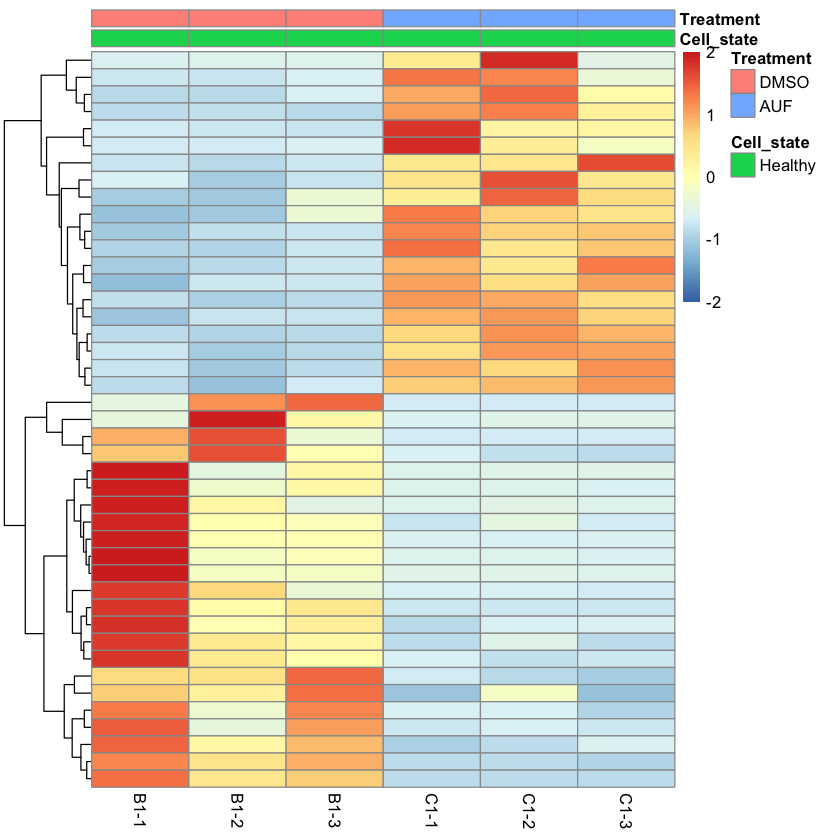

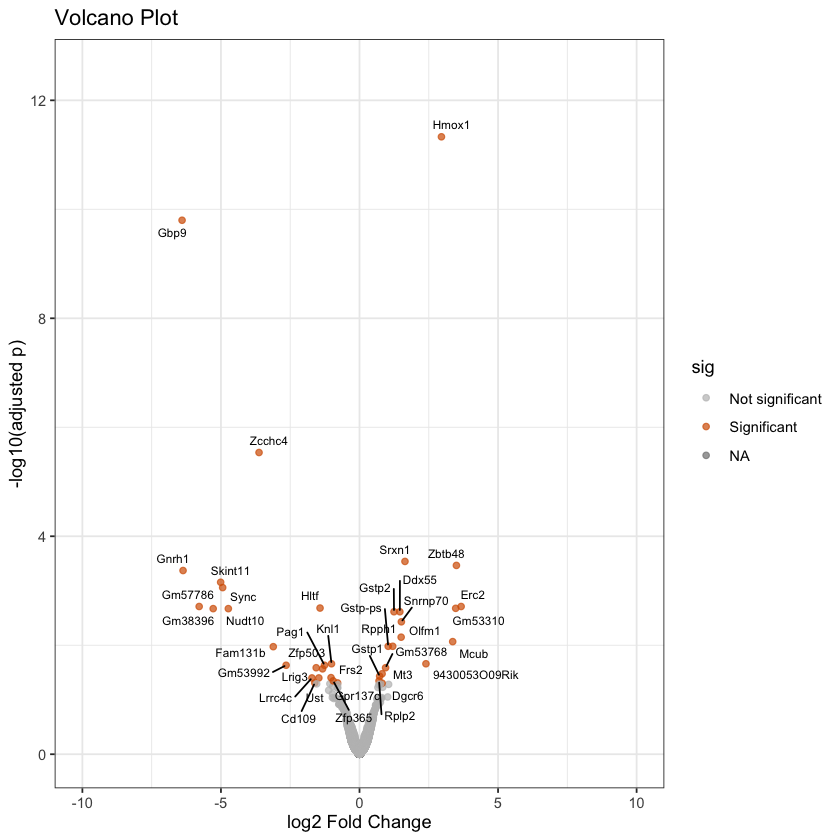

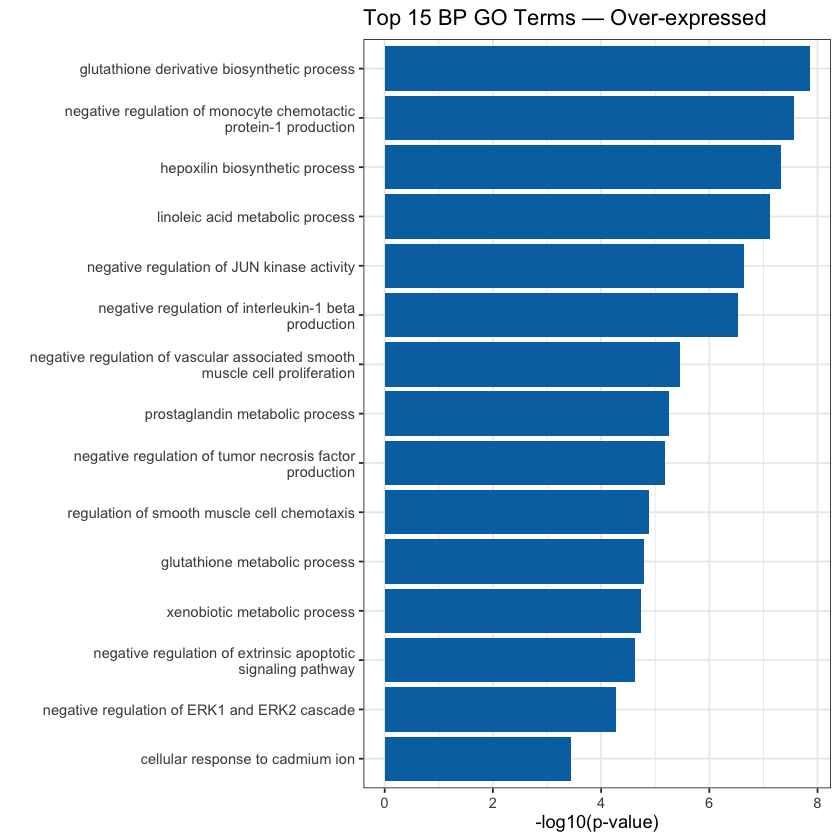

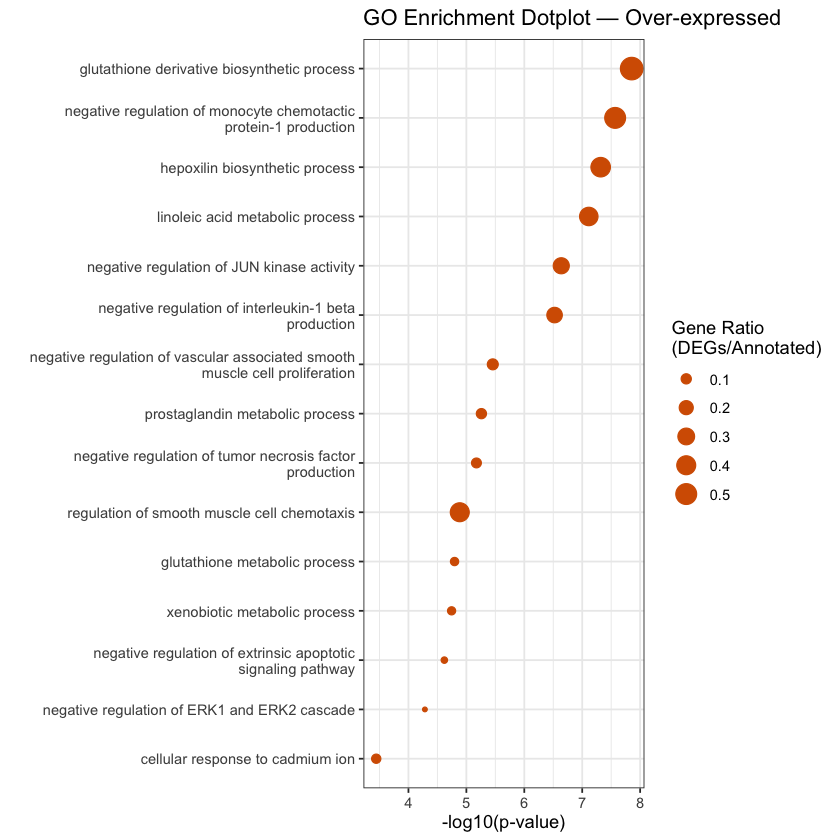

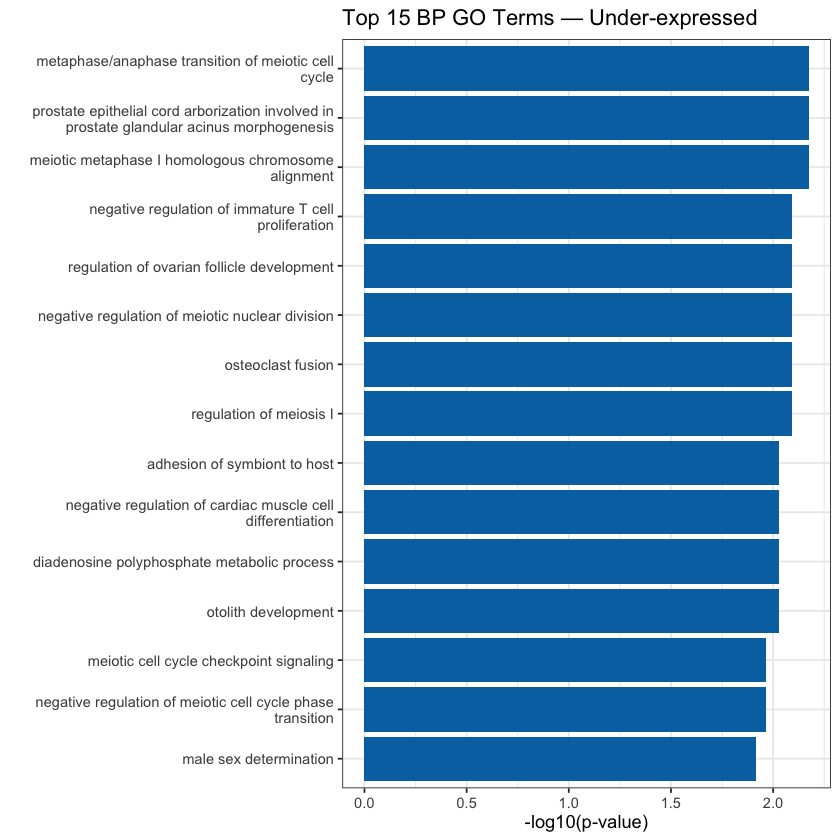

converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



    B1-1     B1-2     B1-3     H1-2     H1-3 
 9570904  6873545 10821001  6478317  5952464 


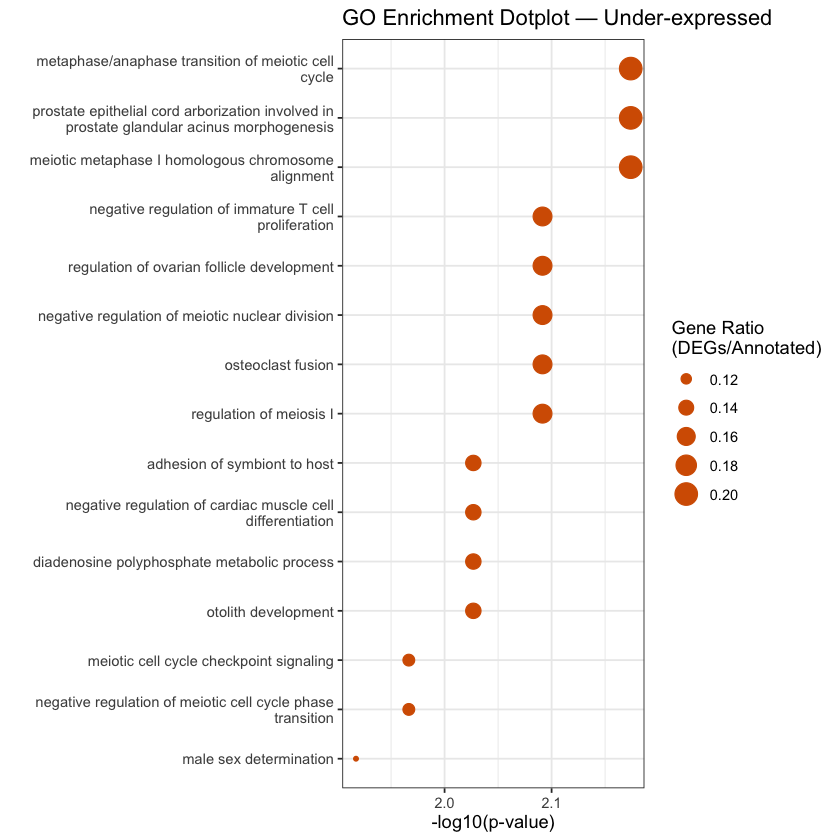


out of 13938 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 35, 0.25%
LFC < 0 (down)     : 260, 1.9%
outliers [1]       : 0, 0%
low counts [2]     : 1081, 7.8%
(mean count < 18)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results

[1] "Significant DE genes at adjusted p-value of 0.05: 295"


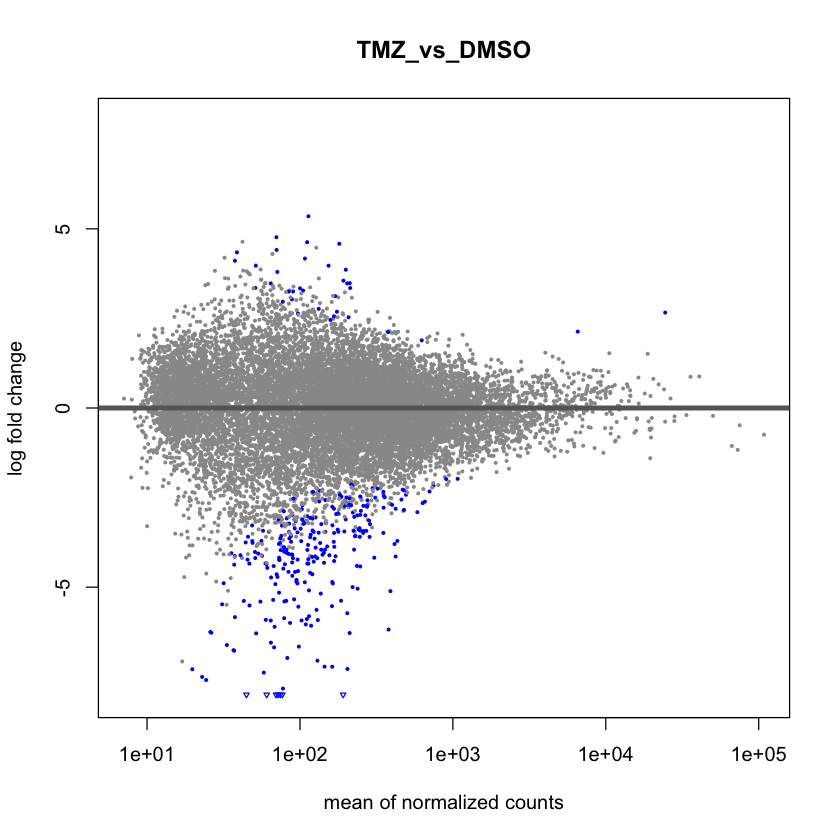

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

Significant DE genes (padj < 0.05): 297

Over-expressed genes: 36

Under-expressed genes: 261


Building most specific GOs .....

	( 11144 GO terms found. )


Build GO DAG topology ..........

	( 14217 GO terms and 31316 relations. )


Annotating nodes ...............

	( 12343 genes annotated to the GO terms. )


			 -- Weight01 Algorithm -- 

		 the algorithm is scoring 651 nontrivial nodes
		 parameters: 
			 test statistic: fisher


	 Level 14:	1 nodes to be scored	(0 eliminated genes)


	 Level 13:	4 nodes to be scored	(0 eliminated genes)


	 Level 12:	8 nodes to be scored	(188 eliminated genes)


	 Level 11:	23 nodes to be scored	(416 eliminated genes)


	 Level 10:	38 nodes to be scored	(1360 eliminated genes)


	 Level 9:	57 nodes to be scored	(3100 eliminated genes)


	 Lev

[1] "Inspect goTop object:"
        GO.ID
1  GO:0098535
2  GO:2001186
3  GO:0043376
4  GO:0006363
5  GO:0015822
6  GO:0089709
7  GO:0019541
8  GO:2000564
9  GO:1903401
10 GO:0042758
11 GO:0046340
12 GO:0070170
13 GO:0043568
14 GO:0031953
15 GO:0070593
                                                                                    Term
1  de novo centriole assembly involved in multi-ciliated epithelial cell differentiation
2                      negative regulation of CD8-positive, alpha-beta T cell activation
3                          regulation of CD8-positive, alpha-beta T cell differentiation
4                                          termination of RNA polymerase I transcription
5                                                                    ornithine transport
6                                                    L-histidine transmembrane transport
7                                                           propionate metabolic process
8                            regulat


Building most specific GOs .....

	( 11144 GO terms found. )


Build GO DAG topology ..........

	( 14217 GO terms and 31316 relations. )


Annotating nodes ...............

	( 12343 genes annotated to the GO terms. )


			 -- Weight01 Algorithm -- 

		 the algorithm is scoring 3447 nontrivial nodes
		 parameters: 
			 test statistic: fisher


	 Level 19:	1 nodes to be scored	(0 eliminated genes)


	 Level 18:	2 nodes to be scored	(0 eliminated genes)


	 Level 17:	3 nodes to be scored	(18 eliminated genes)


	 Level 16:	8 nodes to be scored	(35 eliminated genes)


	 Level 15:	21 nodes to be scored	(49 eliminated genes)


	 Level 14:	30 nodes to be scored	(163 eliminated genes)


	 Level 13:	50 nodes to be scored	(453 eliminated genes)


	 Level 12:	120 nodes to be scored	(907 eliminated genes)


	 Level 11:	223 nodes to be scored	(1753 eliminated genes)


	 Level 10:	370 nodes to be scored	(3745 eliminated genes)


	 Level 9:	439 nodes to be scored	(5734 eliminated genes)


	 Level 8

[1] "Inspect goTop object:"
        GO.ID
1  GO:0072757
2  GO:1990414
3  GO:0010569
4  GO:0060544
5  GO:0110135
6  GO:0060405
7  GO:2000563
8  GO:0014043
9  GO:0030207
10 GO:0061304
11 GO:0042793
12 GO:0001060
13 GO:0001059
14 GO:0071222
15 GO:0060070
                                                                        Term
1                                          cellular response to camptothecin
2  replication-born double-strand break repair via sister chromatid exchange
3      regulation of double-strand break repair via homologous recombination
4                                          regulation of necroptotic process
5                                                   Norrin signaling pathway
6                                              regulation of penile erection
7       positive regulation of CD4-positive, alpha-beta T cell proliferation
8                                   negative regulation of neuron maturation
9                         chondroitin sulfate proteogly

Warning message:
“Removed 1352 rows containing missing values or values outside the scale range
(`geom_point()`).”


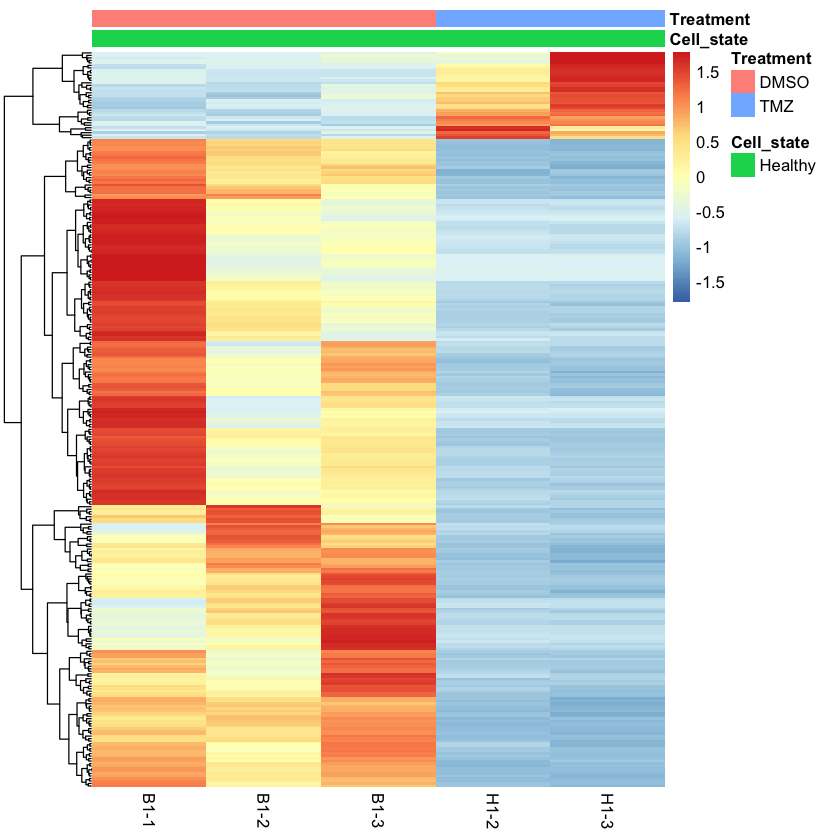

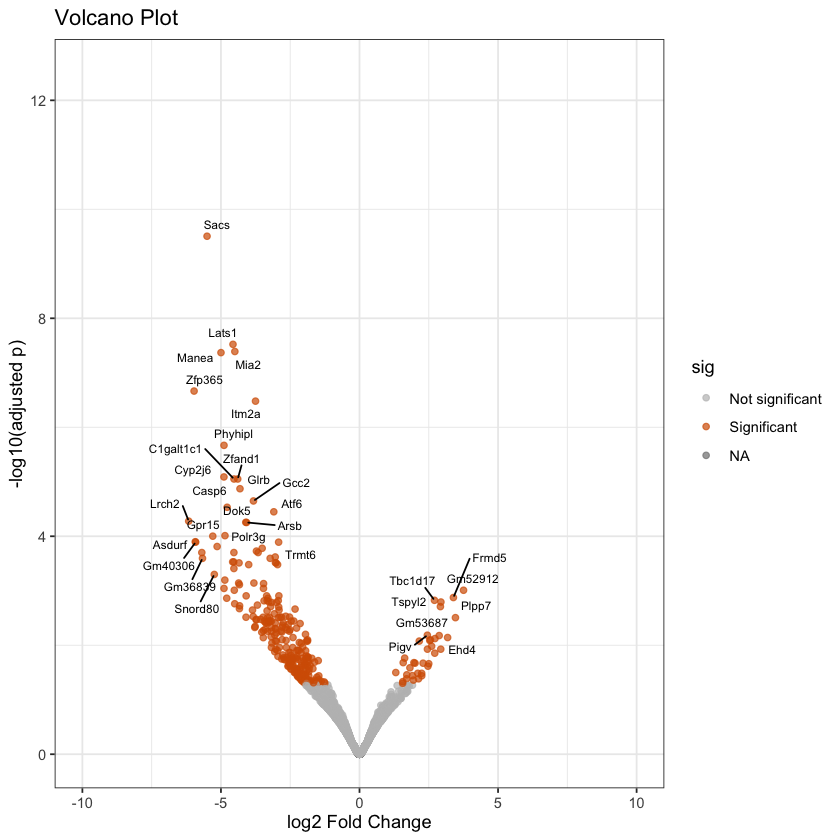

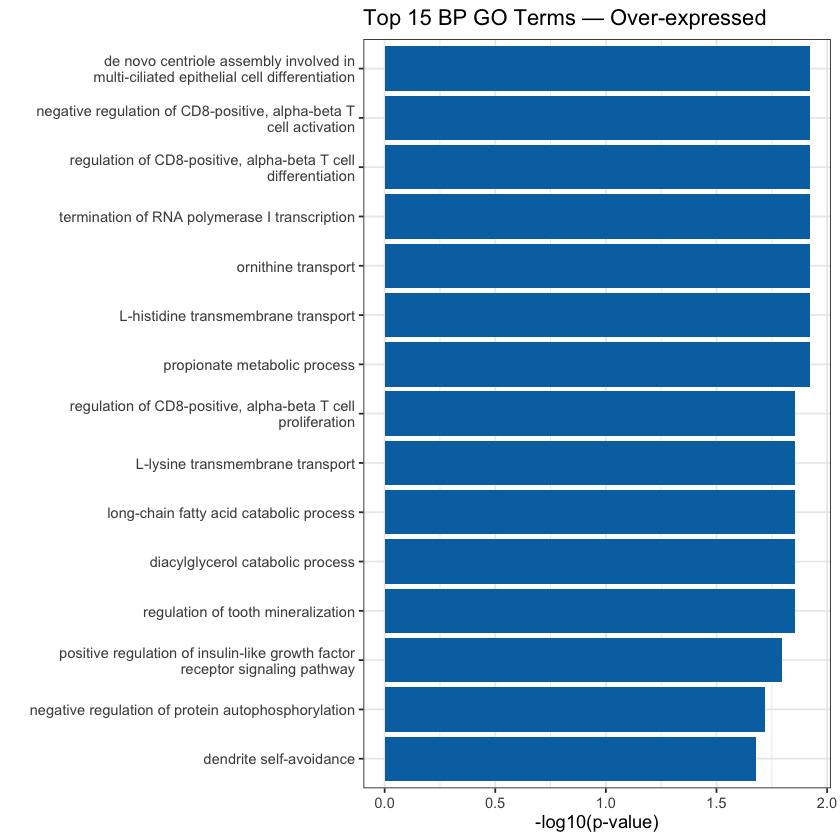

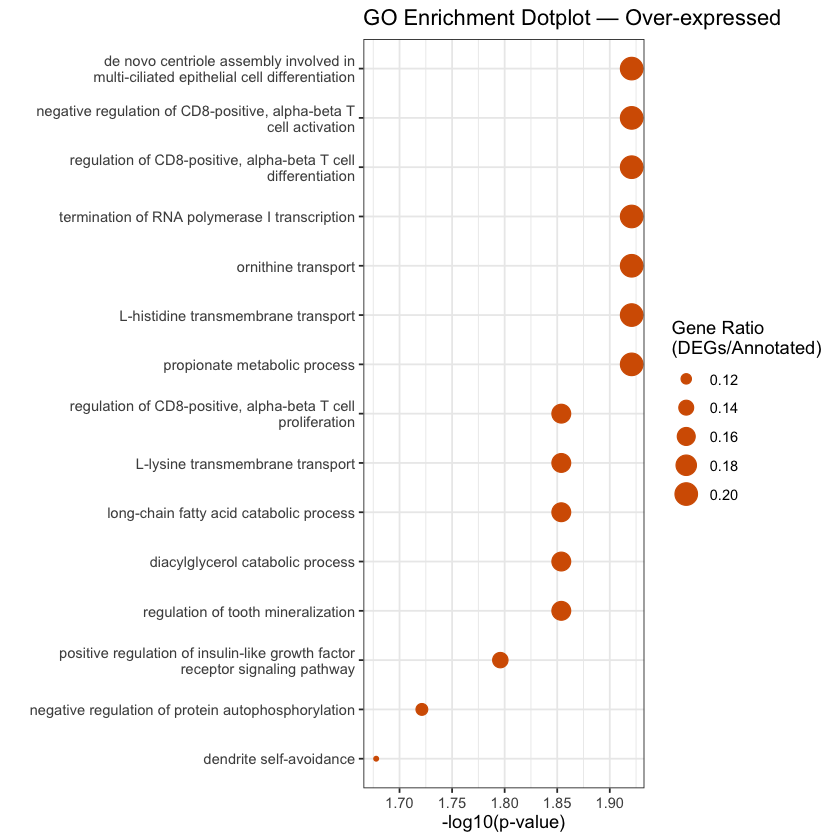

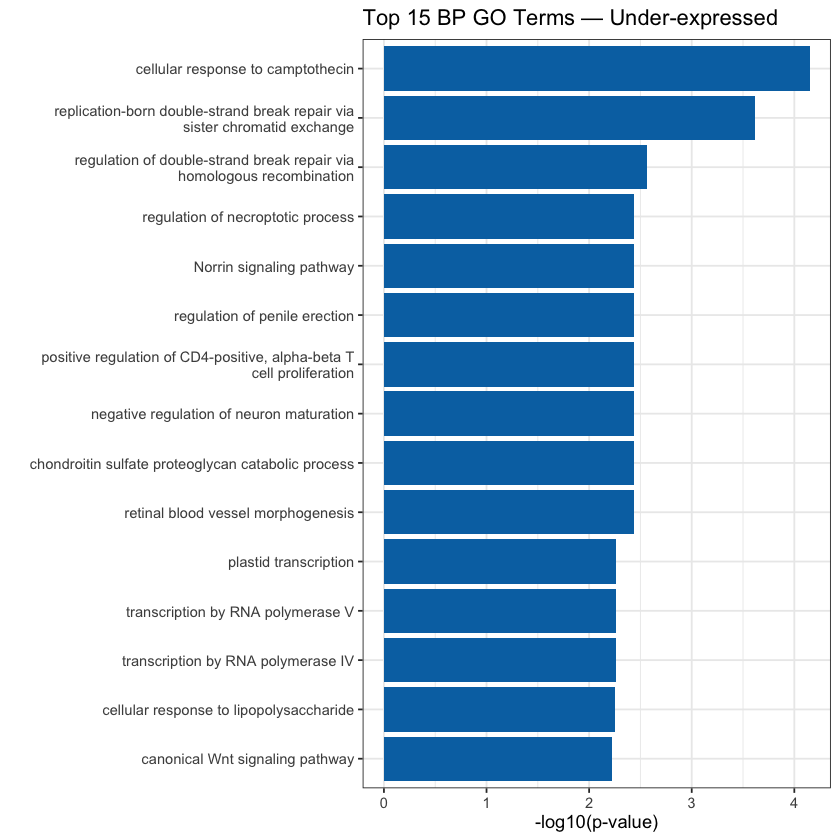

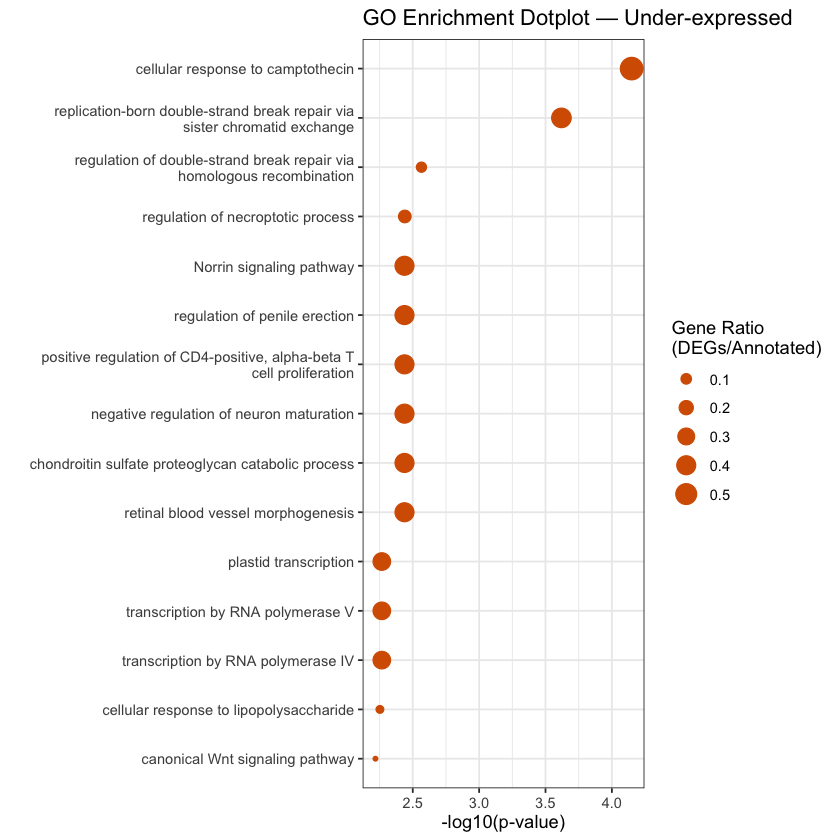

In [42]:
for (treatment in c("AUF", "TMZ")) {

  res <- getDEresults(countsRAW, coldata, "Healthy", treatment)
  dds <- res$dds
  coldata_select <- res$coldata_select
  df <- res$df

  print(colSums(df))

  contrast <- c("Treatment", treatment, "DMSO")
  sig <- getDEanalysis(dds, contrast, df, coldata_select)

  if (nrow(sig) > 0) {
    sig_new <- getDEanalysisFull(dds, contrast, df, coldata_select)
    print(sig_new$Volcanoplot)
    print(sig_new$GOplots$over$bar)
    print(sig_new$GOplots$over$dot)
    print(sig_new$GOplots$under$bar)
    print(sig_new$GOplots$under$dot)
  }
}

### Data analysis for AUF vs. TMZ in healthy organoids:
- Glutathione biosynthesis and negative regulation of nitric oxide overexpression in AUF treatment. Auranofin induces oxidative stress and activates NRF2‑dependent antioxidant gene expression including GSH pathway genes. Auranofin can also modulate iNOS/NO signaling via NRF2 and MAPK interactions.

## 6.1.2 DESeq analysis for Glioma tissue

converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing




out of 7640 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 229, 3%
LFC < 0 (down)     : 683, 8.9%
outliers [1]       : 409, 5.4%
low counts [2]     : 297, 3.9%
(mean count < 15)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results

[1] "Significant DE genes at adjusted p-value of 0.05: 912"


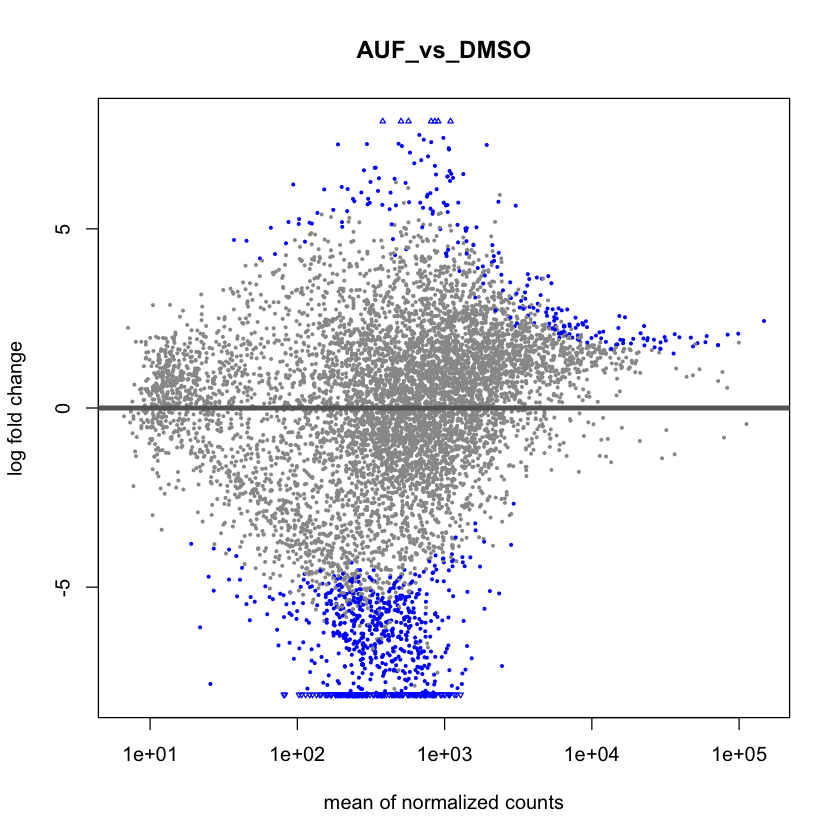

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

Significant DE genes (padj < 0.05): 897

Over-expressed genes: 222

Under-expressed genes: 675


Building most specific GOs .....

	( 9295 GO terms found. )


Build GO DAG topology ..........

	( 12581 GO terms and 27607 relations. )


Annotating nodes ...............

	( 6934 genes annotated to the GO terms. )


			 -- Weight01 Algorithm -- 

		 the algorithm is scoring 3218 nontrivial nodes
		 parameters: 
			 test statistic: fisher


	 Level 19:	1 nodes to be scored	(0 eliminated genes)


	 Level 18:	1 nodes to be scored	(0 eliminated genes)


	 Level 17:	4 nodes to be scored	(10 eliminated genes)


	 Level 16:	7 nodes to be scored	(16 eliminated genes)


	 Level 15:	14 nodes to be scored	(35 eliminated genes)


	 Level 14:	24 nodes to be scored	(95 eliminated genes)


	 Level 13:

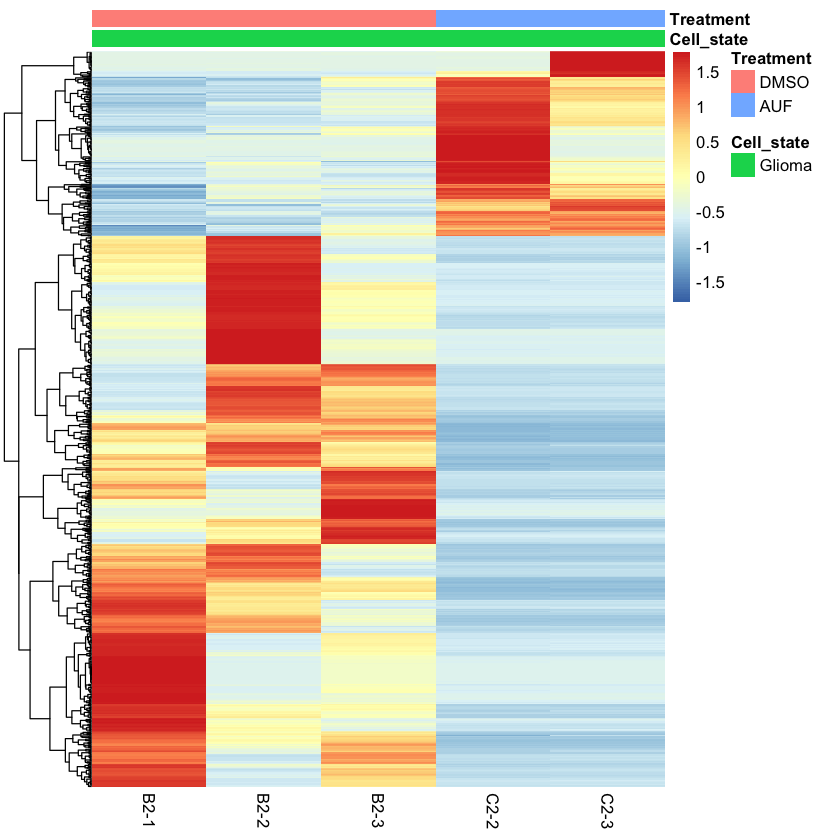

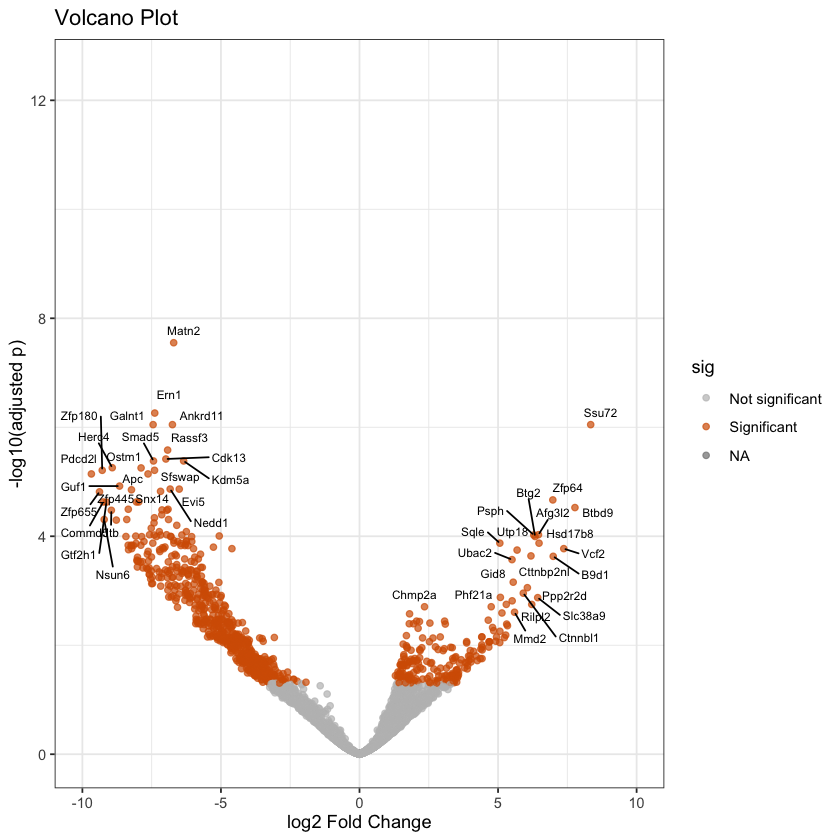

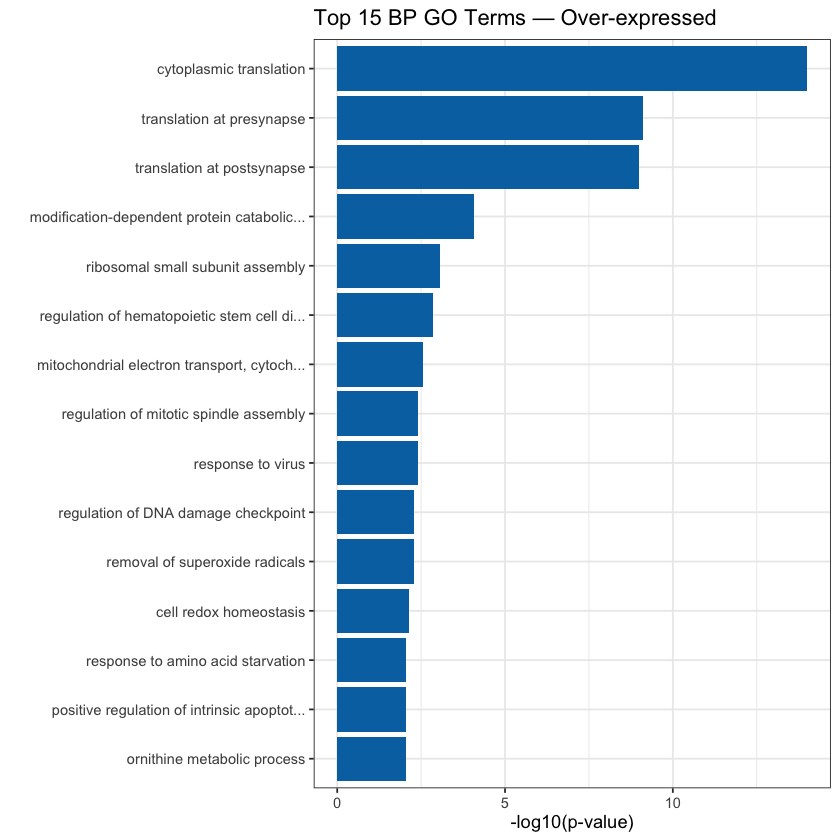

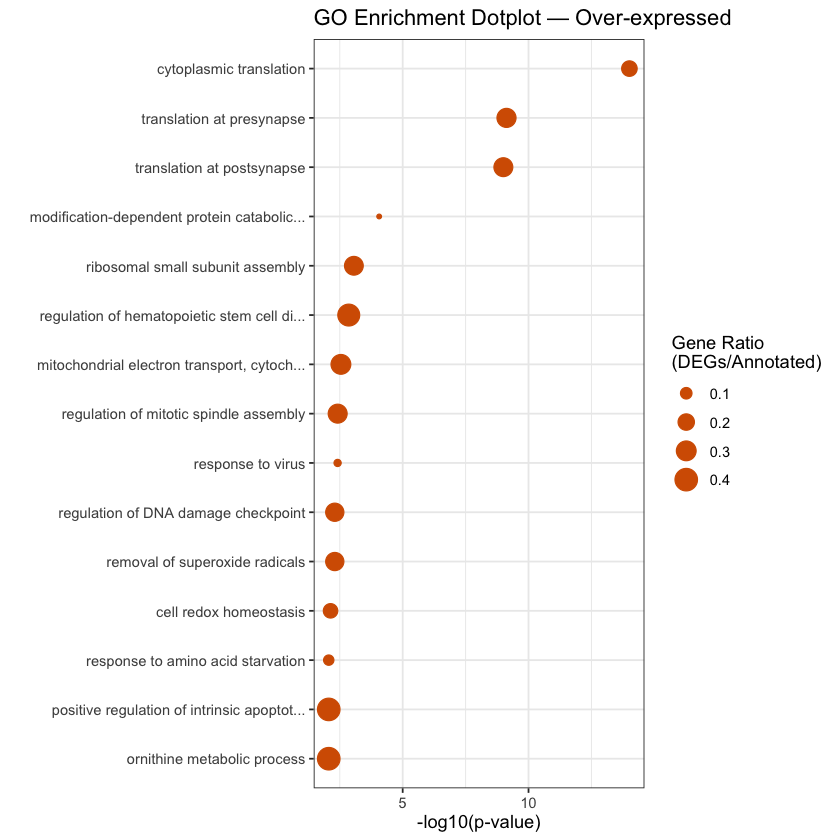

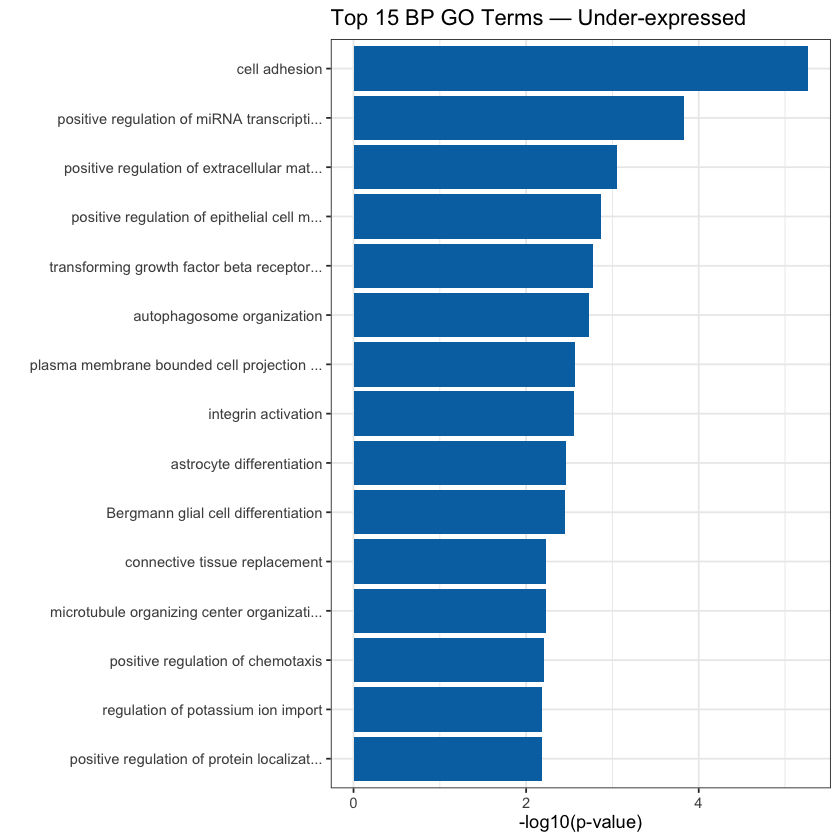

converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing



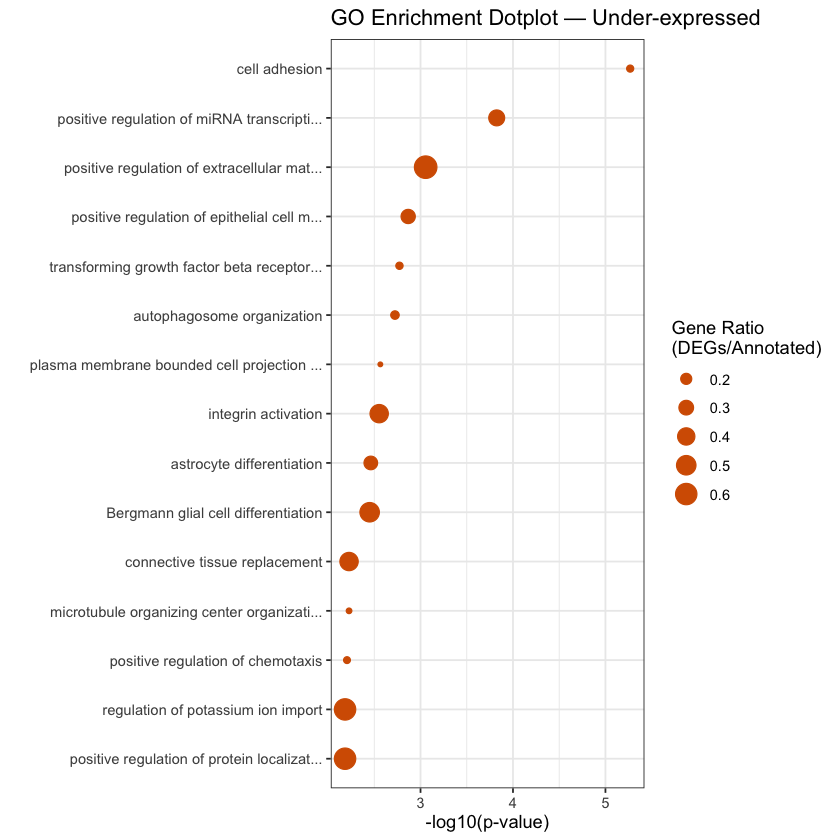


out of 9290 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 153, 1.6%
LFC < 0 (down)     : 172, 1.9%
outliers [1]       : 1062, 11%
low counts [2]     : 181, 1.9%
(mean count < 11)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results

[1] "Significant DE genes at adjusted p-value of 0.05: 325"


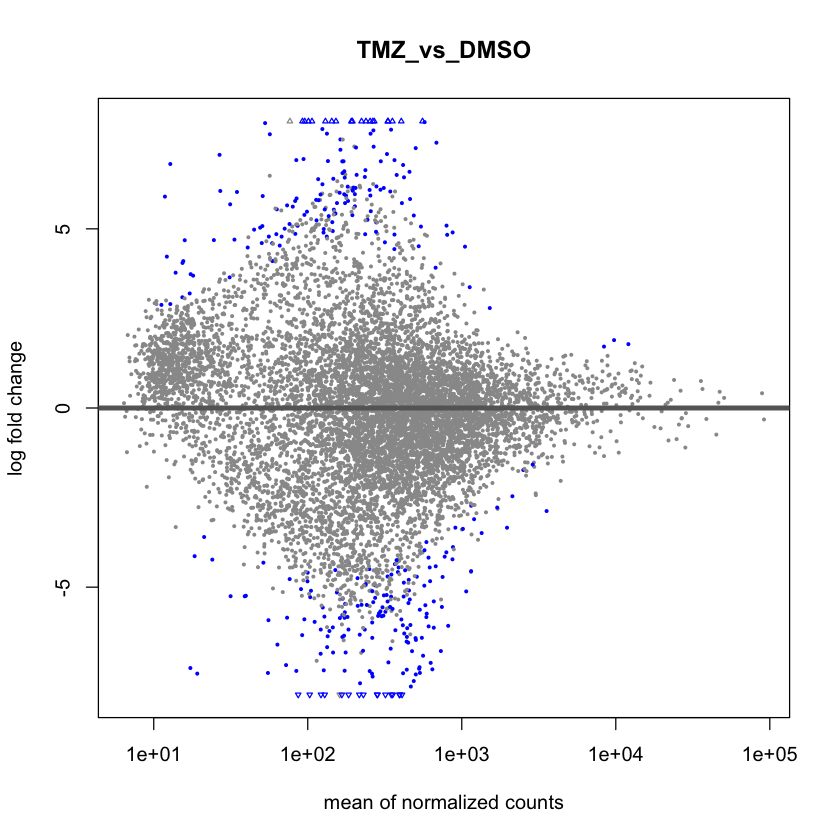

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

Significant DE genes (padj < 0.05): 322

Over-expressed genes: 152

Under-expressed genes: 170


Building most specific GOs .....

	( 9928 GO terms found. )


Build GO DAG topology ..........

	( 13118 GO terms and 28835 relations. )


Annotating nodes ...............

	( 8377 genes annotated to the GO terms. )


			 -- Weight01 Algorithm -- 

		 the algorithm is scoring 2359 nontrivial nodes
		 parameters: 
			 test statistic: fisher


	 Level 18:	2 nodes to be scored	(0 eliminated genes)


	 Level 17:	2 nodes to be scored	(0 eliminated genes)


	 Level 16:	7 nodes to be scored	(29 eliminated genes)


	 Level 15:	10 nodes to be scored	(41 eliminated genes)


	 Level 14:	20 nodes to be scored	(99 eliminated genes)


	 Level 13:	29 nodes to be scored	(258 eliminated genes)


	 Level 1

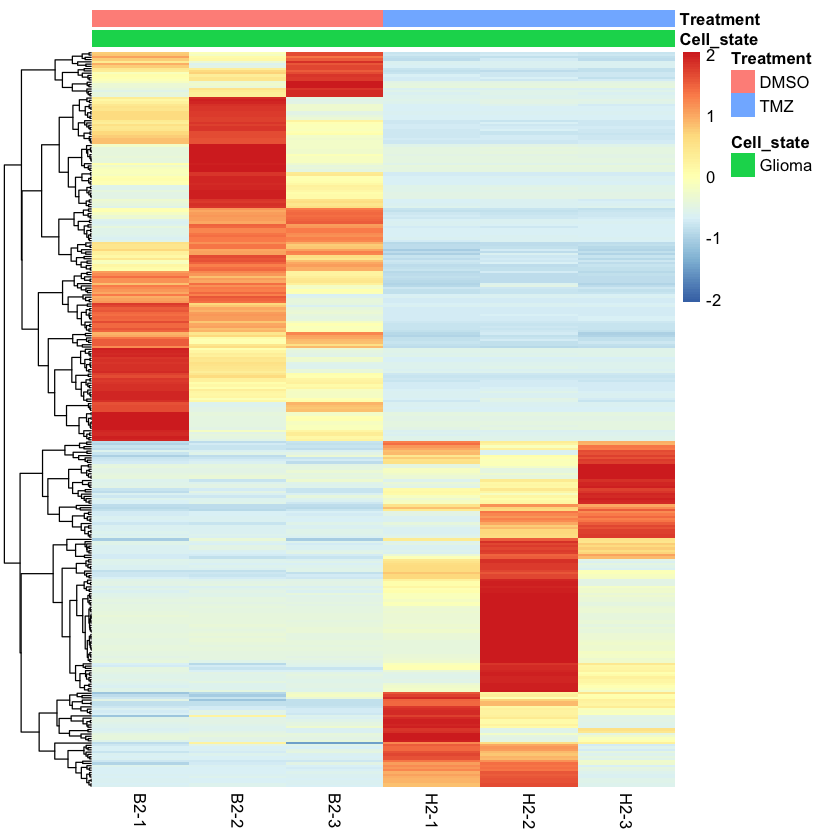

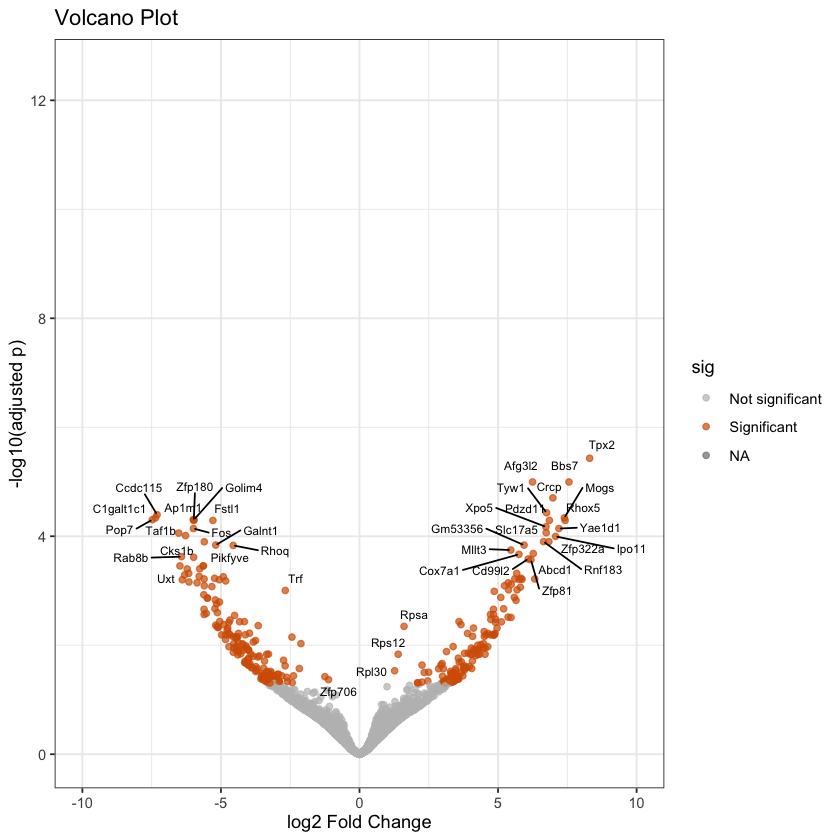

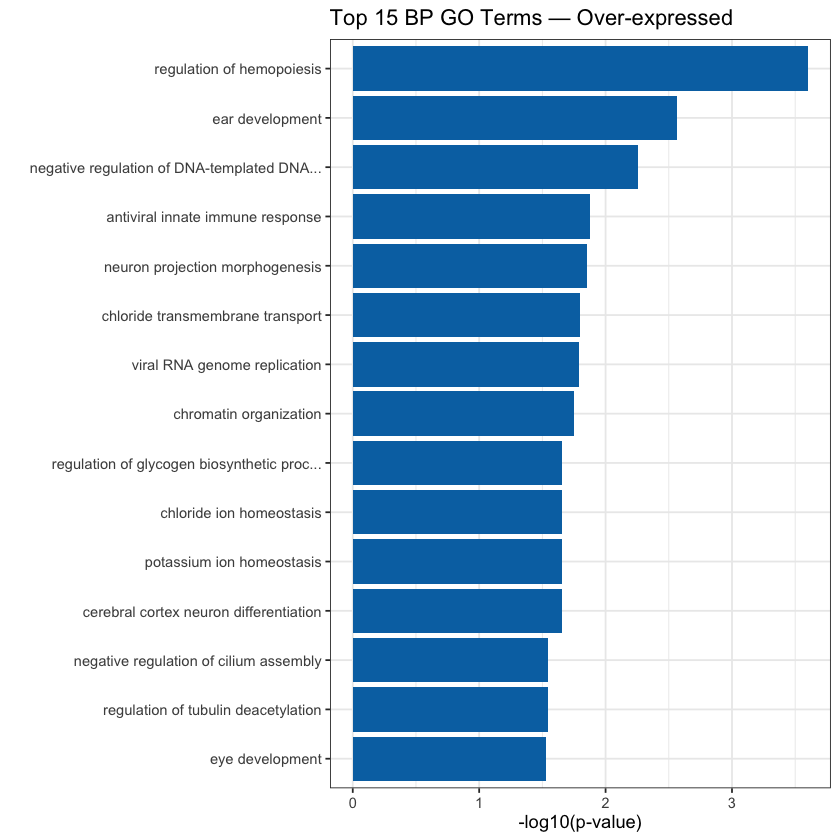

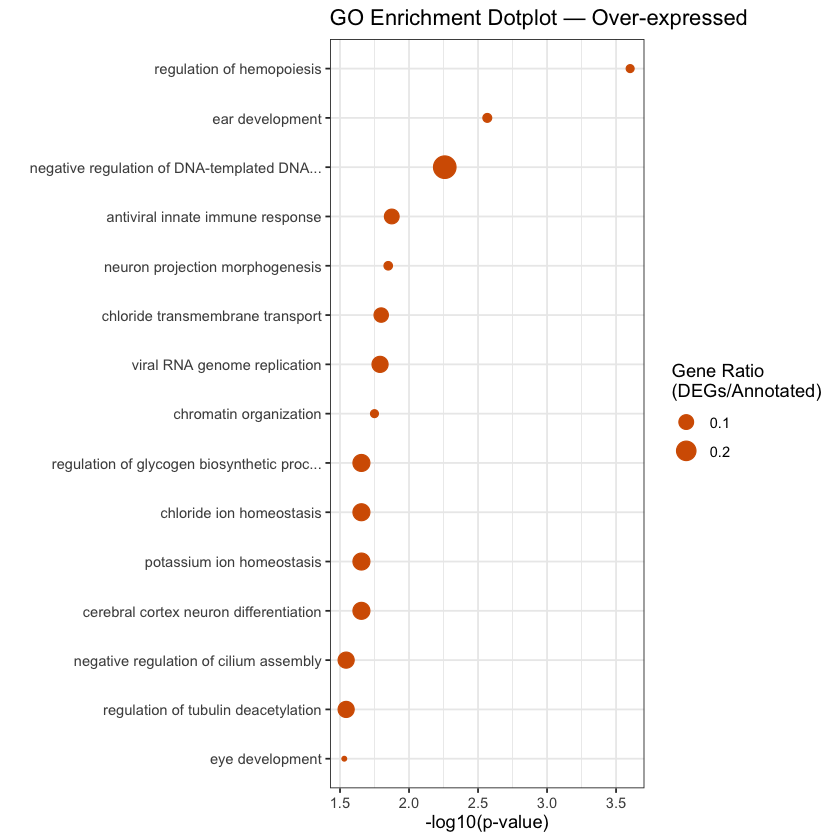

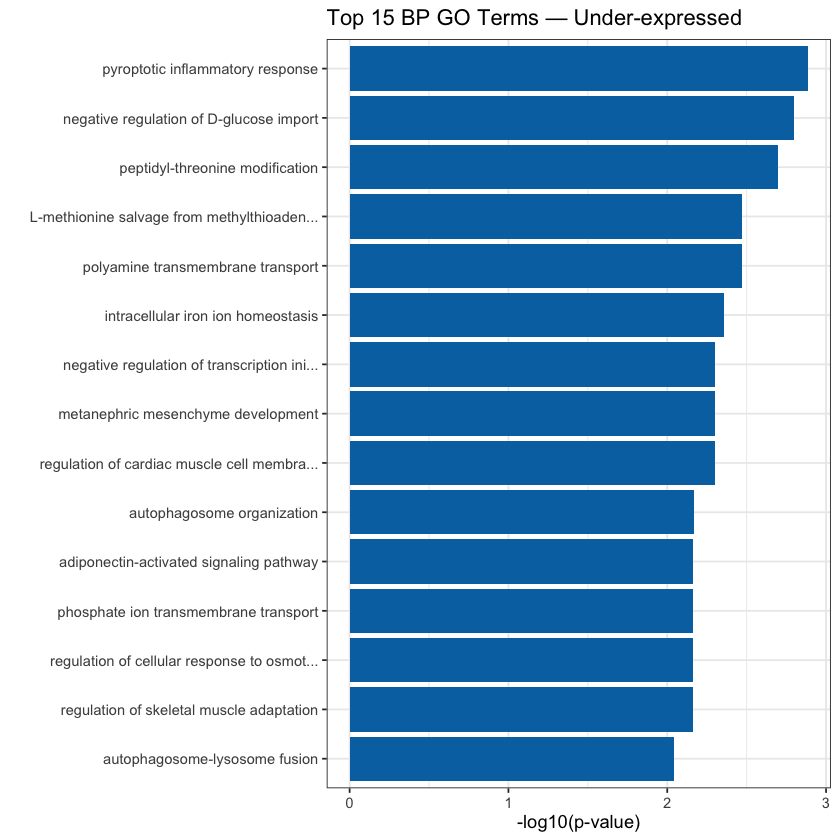

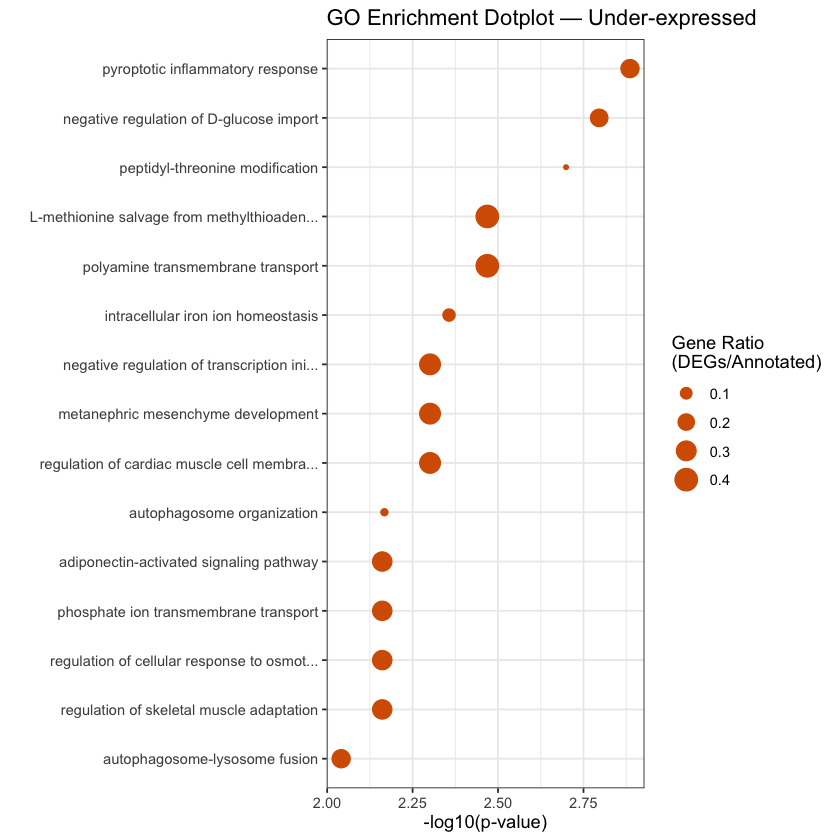

In [43]:
for (treatment in c("AUF", "TMZ")) {

  print("results for: " + treatment)

  res <- getDEresults(countsRAW, coldata, "Glioma", treatment)
  dds <- res$dds
  coldata_select <- res$coldata_select
  df <- res$df

  contrast <- c("Treatment", treatment, "DMSO")
  sig <- getDEanalysis(dds, contrast, df, coldata_select)

  if (nrow(sig) > 0) {
    sig_new <- getDEanalysisFull(dds, contrast, df, coldata_select)
    print(sig_new$Volcanoplot)
    print(sig_new$GOplots$over$bar)
    print(sig_new$GOplots$over$dot)
    print(sig_new$GOplots$under$bar)
    print(sig_new$GOplots$under$dot)
  }
}

In [75]:
packageVersion("topGO")

[1] ‘2.60.1’

### Data analysis for AUF vs. TMZ in glioma organoids:
- Glutamine transport and transcriptional regulation overexpression, and cell adhesion underexpression in AUF treatments. Likely reflects metabolic stress adaptation (shift toward glutamine use) and stress‑related transcriptional reprogramming, with repression of cell adhesion/invasiveness due to oxidative perturbation.
- Glucosylceramide and prostaglandin biosynthesis overexpression in TMZ treatment: Suggests reprogramming of lipid metabolism and stress signaling pathways, consistent with TMZ‑induced metabolic plasticity and processes implicated in resistance mechanisms.

# !!NOTE!! Downstream analysis hereafter is purely experimental

## 6.2 Use best/largest DE sets and plot heatmaps
Plot heatmaps for a specific cell type using DE genes from another to better identify patterns in the data.

In [49]:
# See what R thinks 'coldata' is
meta <- coldata
colnames(countsRAW)
rownames(meta)
ls()              # list all objects
class(coldata)    # should say "data.frame"
typeof(coldata)   # should say "list" for data.frame
class(counts)        # should say "data.frame" or "matrix"
class(meta)          # should say "data.frame"
class(df)            # <- this is key
coldata

[1] "B1-1" "B1-2" "B1-3" "B2-1" "B2-2" "B2-3" "C1-1" "C1-2" "C1-3" "C2-2"
[11] "C2-3" "H1-2" "H1-3" "H2-1" "H2-2" "H2-3"

[1] "B1-1" "B1-2" "B1-3" "B2-1" "B2-2" "B2-3" "C1-1" "C1-2" "C1-3" "C2-2"
[11] "C2-3" "H1-2" "H1-3" "H2-1" "H2-2" "H2-3"

[1] "anno"                  "anno_for_res"          "coldata"              
 [4] "coldata_select"        "contrast"              "countsLOG"            
 [7] "countsLOG_in"          "countsRAW"             "countsRAW_in"         
[10] "countsTPM"             "countsTPM_in"          "dds"                  
[13] "df"                    "getDEanalysis"         "getDEanalysisFull"    
[16] "getDEresults"          "heatmap_plot"          "heatmap_plot_unscaled"
[19] "meta"                  "p"                     "pca"                  
[22] "pca_by_state"          "pca_by_treatment"      "plot_markers_combined"
[25] "refined_heatmap"       "res"                   "sig"                  
[28] "sig_new"               "treatment"

[1] "data.frame"

[1] "list"

[1] "standardGeneric"
attr(,"package")
[1] "methods"

[1] "data.frame"

[1] "data.frame"

,Cell_state,Treatment,ID_old,No_cells,ID,Replicate
,<fct>,<fct>,<chr>,<int>,<chr>,<fct>
B1-1,Healthy,DMSO,B1_1,5000,B1-1,1
B1-2,Healthy,DMSO,B1_2,5000,B1-2,2
B1-3,Healthy,DMSO,B1_3,5000,B1-3,3
B2-1,Glioma,DMSO,B2_1,600,B2-1,1
B2-2,Glioma,DMSO,B2_2,800,B2-2,2
B2-3,Glioma,DMSO,B2_3,1100,B2-3,3
C1-1,Healthy,AUF,C1_1,5000,C1-1,1
C1-2,Healthy,AUF,C1_2,5000,C1-2,2
C1-3,Healthy,AUF,C1_3,5000,C1-3,3


In [50]:
refined_heatmap <- function(sig, cellType, countData){
  cols <- grep(cellType, colnames(countData))
  
  df <- countData[rownames(sig),cols]
  df <- df[,order(colnames(df))]
  
  if ((length(rownames(df)) < 30) & (length(rownames(df)) > 1)){
    pheatmap(df, scale = "row", cluster_cols = FALSE, cluster_rows = TRUE)
  } else if (length(rownames(df)) >= 30) {
    pheatmap(df, scale = "row", cluster_cols = FALSE, cluster_rows = TRUE, show_rownames = FALSE)
  }
}

In [51]:
# Check meta column names
colnames(meta)

# Check if Cell_state exists
"Cell_state" %in% colnames(meta)

# Check name alignment
head(colnames(counts))
head(rownames(meta))

# Check if tissue value exists in Cell_state
unique(meta$Cell_state)
table(meta$Cell_state)

[1] "Cell_state" "Treatment"  "ID_old"     "No_cells"   "ID"        
[6] "Replicate"

[1] TRUE

NULL

[1] "B1-1" "B1-2" "B1-3" "B2-1" "B2-2" "B2-3"

[1] Healthy Glioma 
Levels: Glioma Healthy


 Glioma Healthy 
      8       8 

In [52]:
class(countsRAW)
dim(countsRAW)
head(colnames(countsRAW))
all(colnames(countsRAW) %in% rownames(meta))  # should be TRUE

[1] "data.frame"

[1] 16453    16

[1] "B1-1" "B1-2" "B1-3" "B2-1" "B2-2" "B2-3"

[1] TRUE

In [53]:
getDEresults_safe <- function(df, meta, tissue = "Healthy", treatment = "AUF") {
  # Make sure rownames of meta match colnames of df
  if (!all(colnames(df) %in% rownames(meta))) stop("Column names of df must match rownames of meta")
  
  # Subset samples for the tissue of interest
  samples_of_interest <- rownames(meta)[meta$Cell_state == tissue]
  
  # Subset df for these samples
  df_select <- df[, samples_of_interest, drop = FALSE]
  
  # Subset meta for these samples and keep only DMSO and treatment
  meta_select <- meta[samples_of_interest, c("Cell_state", "Treatment", "Replicate")]
  meta_select <- dplyr::filter(meta_select, Treatment %in% c("DMSO", treatment))
  meta_select$Treatment <- factor(meta_select$Treatment, levels = c("DMSO", treatment))
  meta_select$Cell_state <- factor(meta_select$Cell_state)
  meta_select$Replicate <- factor(meta_select$Replicate)
  
  # Keep only columns in df_select that are still in meta_select
  df_select <- df_select[, rownames(meta_select), drop = FALSE]
  
  # Create DESeq dataset and run DESeq
  dds <- DESeq2::DESeqDataSetFromMatrix(
    countData = round(df_select),
    colData = meta_select,
    design = ~Treatment
  )
  dds <- DESeq2::DESeq(dds)
  
  return(list(dds = dds, meta_select = meta_select, df = df_select))
}

# Healthy Population Pathway Analysis

converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



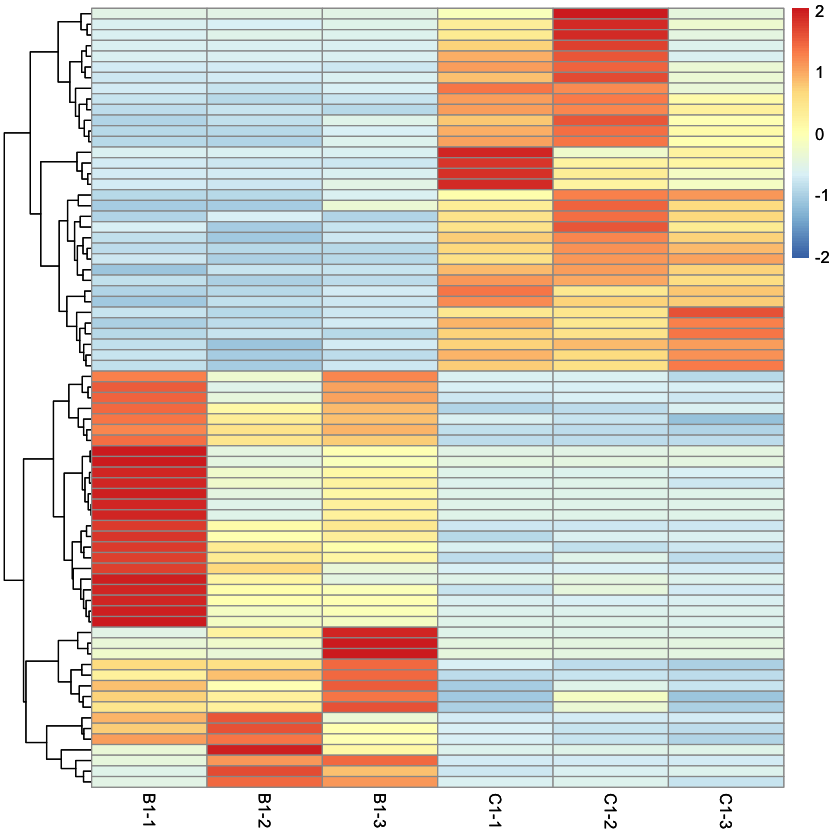

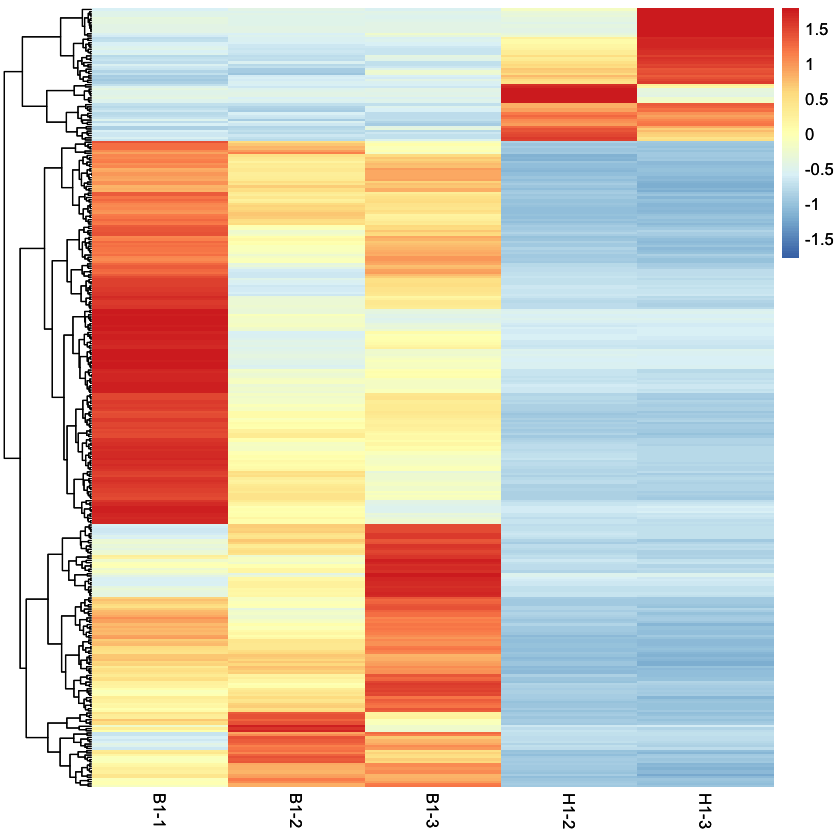

In [54]:
# AUF vs DMSO
de_out_auf <- getDEresults_safe(countsRAW, meta, tissue = "Healthy", treatment = "AUF")
res_auf <- DESeq2::results(de_out_auf$dds)
sig_genes_auf <- res_auf[!is.na(res_auf$padj) & res_auf$padj < 0.05, ]

# TMZ vs DMSO
de_out_tmz <- getDEresults_safe(countsRAW, meta, tissue = "Healthy", treatment = "TMZ")
res_tmz <- DESeq2::results(de_out_tmz$dds)
sig_genes_tmz <- res_tmz[!is.na(res_tmz$padj) & res_tmz$padj < 0.05, ]

# AUF heatmap
df_plot_auf <- de_out_auf$df[rownames(sig_genes_auf), order(colnames(de_out_auf$df))]
df_plot_auf <- df_plot_auf[apply(df_plot_auf, 1, function(x) all(is.finite(x))), ]
df_plot_auf <- df_plot_auf[apply(df_plot_auf, 1, var) > 0, ]
print(pheatmap(df_plot_auf, scale = "row", cluster_cols = FALSE,
               cluster_rows = TRUE, show_rownames = FALSE))

# TMZ heatmap
df_plot_tmz <- de_out_tmz$df[rownames(sig_genes_tmz), order(colnames(de_out_tmz$df))]
df_plot_tmz <- df_plot_tmz[apply(df_plot_tmz, 1, function(x) all(is.finite(x))), ]
df_plot_tmz <- df_plot_tmz[apply(df_plot_tmz, 1, var) > 0, ]
print(pheatmap(df_plot_tmz, scale = "row", cluster_cols = FALSE,
               cluster_rows = TRUE, show_rownames = FALSE))

In [55]:
# AUF - Up
up_auf <- sig_genes_auf[sig_genes_auf$log2FoldChange > 0, ]
rownames(up_auf[order(up_auf$padj), ])

# AUF - Down
down_auf <- sig_genes_auf[sig_genes_auf$log2FoldChange < 0, ]
rownames(down_auf[order(down_auf$padj), ])

# TMZ - Up
up_tmz <- sig_genes_tmz[sig_genes_tmz$log2FoldChange > 0, ]
rownames(up_tmz[order(up_tmz$padj), ])

# TMZ - Down
down_tmz <- sig_genes_tmz[sig_genes_tmz$log2FoldChange < 0, ]
rownames(down_tmz[order(down_tmz$padj), ])

[1] "Hmox1"         "Srxn1"         "Zbtb48"        "Ddx55"        
 [5] "Erc2"          "Olfm1"         "Gstp2"         "Gm53310"      
 [9] "Gstp-ps"       "Mcub"          "Snrnp70"       "Gm53768"      
[13] "Rpph1"         "Fus"           "Gstp1"         "Cep152"       
[17] "Emd"           "9430053O09Rik" "Gm35243"       "Fan1"         
[21] "Mt3"           "Polm"          "Mitf"          "Recql5"       
[25] "Rplp2"         "Erf"           "Uchl1"         "Nat14"        
[29] "Ankrd13d"      "Dgcr6"         "Clec11a"       "Zrsr2"        
[33] "Csf1"          "Acad10"

[1] "Gbp9"          "Zcchc4"        "Gnrh1"         "Hltf"         
 [5] "Skint11"       "Sync"          "Gm57786"       "Gm38396"      
 [9] "Nudt10"        "Fam131b"       "Knl1"          "Gm36298"      
[13] "Zfp503"        "Gm53992"       "Pag1"          "Msh5"         
[17] "Lrig3"         "Ctxn3"         "Gdap2"         "Bicral"       
[21] "Zfp365"        "Cd109"         "Frs2"          "Lrrc4c"       
[25] "Ahctf1"        "Gpr137c"       "1700022N22Rik" "Wdr47"        
[29] "Rapgef5"       "Iapp"          "Rslcan18"      "Arid3b"       
[33] "Gnpda1"        "Ust"           "Pgap3"         "Gm40180"      
[37] "Ccl28"         "Myorg"         "Neto1"

[1] "Opn3"          "Gm22043"       "Cdk3"          "Polr1has"     
 [5] "Gm52912"       "Gm50622"       "Frmd5"         "Tbc1d17"      
 [9] "Gm53687"       "Tspyl2"        "Gm36856"       "Gm35941"      
[13] "Flt3l"         "4930578L24Rik" "Plpp7"         "Pigv"         
[17] "Cbx8"          "Gm40694"       "Igfbp4"        "Lrrc45"       
[21] "Acss1"         "Cep152"        "Gfra2"         "Slc27a3"      
[25] "Slc25a29"      "Ehd4"          "Ccn6"          "Lzts1"        
[29] "Ndrg1"         "Zfp764l1"      "Gm26917"       "Il4i1"        
[33] "Efhd2"         "Lipe"          "Lzic"          "Rpph1"        
[37] "4930578M01Rik" "Gm12500"       "AY036118"      "Fndc1"        
[41] "Fam131a"       "Gm20559"       "Slc25a38"      "Prtg"         
[45] "Guca1a"        "Gm57777"       "Katnip"        "Aarsd1"       
[49] "Lbhd2"         "Slc4a2"        "Gfod2"         "Mrm3"         
[53] "Gm41829"       "Ccdc142"       "Marchf1"       "2610029K11Rik"
[57] "Msantd1"       "Zfp764"        "Nr1h4"         "Gm50596"

[1] "Sacs"          "Manea"         "Lats1"         "Mia2"         
  [5] "Zfp365"        "Itm2a"         "Phyhipl"       "Cyp2j6"       
  [9] "Zfand1"        "Glrb"          "C1galt1c1"     "Atf6"         
 [13] "Casp6"         "Gcc2"          "Dok5"          "Lrch2"        
 [17] "Arsb"          "Asdurf"        "Gm40306"       "Trmt6"        
 [21] "Glmn"          "Scaper"        "Polr3g"        "Gpr15"        
 [25] "Tmsb15b2"      "1110046J04Rik" "Maoa"          "Blm"          
 [29] "Rundc3b"       "Gm36839"       "Rarb"          "Slc44a1"      
 [33] "Zfp715"        "Heca"          "Snord80"       "Pcdhb18"      
 [37] "Pogz"          "Kbtbd7"        "Rpp25l"        "Rgcc"         
 [41] "Gm31690"       "2310067E19Rik" "Bid"           "Pus3"         
 [45] "Rnf167"        "Cln5"          "Gm6712"        "2310034G01Rik"
 [49] "Cdh10"         "Plcxd2"        "Dnajb14"       "Rnf138"       
 [53] "Bche"          "Csgalnact1"    "Klhl15"        "Epha4"        
 [57] "Ndp"           "Kdm1b"         "Cpt2"          "Phtf2"        
 [61] "Car11"         "Bicc1"         "Cmpk2"         "Ubap1"        
 [65] "Harbi1"        "Dock3"         "Gnrh1"         "2610316D01Rik"
 [69] "Cul2"          "Ttc39b"        "Ednrb"         "B230217C12Rik"
 [73] "Cenpl"         "Trim32"        "Cyb5a"         "Slc35b3"      
 [77] "Gemin8"        "Ube2e2"        "Faxc"          "Gpatch2l"     
 [81] "Fzd2"          "Rbak"          "F8"            "Usp54"        
 [85] "Cflar"         "Ppp1r1a"       "Fdxacb1"       "Slc7a11"      
 [89] "Liph"          "Gpr63"         "Mtrf1"         "Fam53c"       
 [93] "Zfp719"        "Lyrm7"         "Immp2l"        "Srfbp1"       
 [97] "Tfe3"          "Zcchc18"       "Golm2"         "Jade3"        
[101] "Tbl1xr1"       "Rin2"          "Nars2"         "Tnip1"        
[105] "Zfp51"         "Mrps10"        "Pde12"         "Plekhm3"      
[109] "Tars3"         "Gm53969"       "Kank4"         "Igip"         
[113] "Myorg"         "Esco1"         "Cep135"        "Septin6"      
[117] "Cept1"         "Nr3c1"         "6430503K07Rik" "Abraxas1"     
[121] "Ammecr1"       "Pibf1"         "Gm38639"       "Pcdh15"       
[125] "Zfp946"        "Lratd2"        "4921504A21Rik" "Bcl11a"       
[129] "Impg1"         "Vps35l"        "Bag2"          "Gm3325"       
[133] "Fam199x"       "Adk"           "9230105E05Rik" "Rasal2"       
[137] "Gm28777"       "Zfp420"        "2510009E07Rik" "Efcab7"       
[141] "Zfp712"        "Rad51"         "Ankrd29"       "Pdcd7"        
[145] "Kat6b"         "Gm4013"        "Plpp4"         "Chmp5"        
[149] "Plekha1"       "Gm57850"       "Cyb5r4"        "Armcx6"       
[153] "Casd1"         "Tk2"           "Pign"          "Bloc1s6os"    
[157] "C920021L13Rik" "Dus4l"         "Tbc1d23"       "Snord47"      
[161] "Kics2"         "Med11"         "Hars2"         "Fzd4"         
[165] "Pycr1"         "Zfp87"         "Ubxn2b"        "Gm24523"      
[169] "BC006965"      "Tmem38b"       "P2ry1"         "Nfatc1"       
[173] "Parpbp"        "Gpr137b"       "Apcdd1"        "Inafm2"       
[177] "Shroom2"       "Gm44097"       "Ifnar2"        "Mid2"         
[181] "Nsmaf"         "Gdpd2"         "Cracd"         "B3galt2"      
[185] "Cmtm5"         "Skint11"       "Rab9"          "Spata13"      
[189] "Rnf141"        "Zfp11"         "Kctd9"         "Klhl12"       
[193] "Peak1"         "Ganc"          "Pola1"         "Mapk14"       
[197] "Inafm1"        "Polr1b"        "Abca1"         "Pcdhb22"      
[201] "Prmt6"         "Prkcq"         "Vps50"         "Ppp1r15b"     
[205] "Gm12655"       "Acrbp"         "Myo6"          "Dact1"        
[209] "Star"          "Frs2"          "Bmi1"          "Gm31204"      
[213] "4931440P22Rik" "Gm26854"       "Zng1"          "Fancb"        
[217] "Slc25a53"      "6030407O03Rik" "Mafb"          "Pcmtd2"       
[221] "1700109H08Rik" "Gm57749"       "Isoc1"         "Ftx"          
[225] "Fignl1"        "Spata2"        "Iapp"          "1700003M07Rik"
[229] "Farp1

## AUF in Healthy Organoids

Genes found in sig_genes_auf: 58 
Genes not significant:  


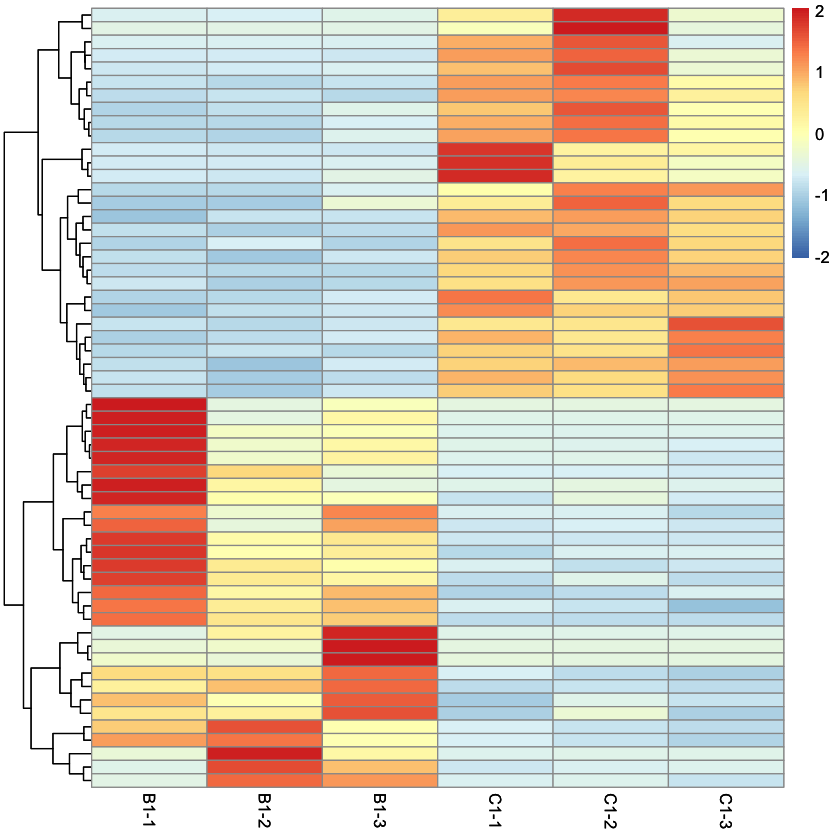

In [56]:
auf_up_oxidative_stress <- c("Hmox1",   # heme oxygenase-1; Nrf2 target
                               "Srxn1",   # sulfiredoxin; antioxidant / Nrf2 target
                               "Gstp1",   # glutathione S-transferase; ROS detox
                               "Gstp2",   # glutathione S-transferase; ROS detox
                               "Gstp-ps", # glutathione S-transferase pseudogene
                               "Mt3")     # metallothionein; oxidative stress

auf_up_dna_repair <- c("Fan1",    # Fanconi anemia nuclease; crosslink repair
                        "Polm",    # DNA polymerase mu; NHEJ
                        "Recql5",  # RecQ helicase; replication fork stability
                        "Cep152")  # centrosome; replication stress checkpoint

auf_up_rna_processing <- c("Ddx55",   # DEAD-box helicase; rRNA processing
                             "Snrnp70", # U1 snRNP; pre-mRNA splicing
                             "Zrsr2",   # U2AF-related; minor intron splicing
                             "Fus",     # RNA-binding protein; splicing / transcription
                             "Rpph1")   # RNase P RNA; tRNA processing

auf_up_transcription <- c("Zbtb48", # telomere regulation / transcriptional repressor
                           "Mitf",   # melanocyte / lysosome transcription factor
                           "Erf",    # ETS repressor; RAS/ERK target
                           "Dgcr6")  # DiGeorge locus; transcriptional

auf_up_ubiquitin_protein <- c("Uchl1",    # ubiquitin C-terminal hydrolase; deubiquitinase
                                "Ankrd13d") # ubiquitin-binding ANKRD protein

auf_up_mitochondrial <- c("Mcub",   # mitochondrial Ca2+ uniporter regulator
                           "Acad10") # acyl-CoA dehydrogenase; fatty acid beta-oxidation

auf_up_nuclear_structure <- c("Emd") # emerin; nuclear envelope / lamina

auf_up_cytoskeleton_scaffold <- c("Erc2") # ELKS/CAST; active zone scaffold

auf_up_secreted_extracellular <- c("Olfm1",   # olfactomedin; ECM glycoprotein
                                    "Clec11a", # C-type lectin; hematopoietic growth factor
                                    "Csf1")    # colony-stimulating factor 1; macrophage growth

auf_up_ribosome <- c("Rplp2") # ribosomal protein; translational regulation

auf_dn_immune_inflammation <- c("Gbp9",  # guanylate-binding protein; IFN-gamma / innate immunity
                                  "Ccl28", # chemokine; mucosal immunity
                                  "Cd109", # TGF-beta co-receptor; immune modulation
                                  "Pag1")  # Src/Csk scaffold; immune signaling

auf_dn_dna_repair_replication <- c("Msh5",   # mismatch repair / meiotic recombination
                                    "Hltf",   # E3 ligase; post-replication repair
                                    "Knl1",   # kinetochore; spindle assembly checkpoint
                                    "Ahctf1", # ELYS; nuclear pore / replication licensing
                                    "Bicral") # BRD4-interacting; chromatin remodeling

auf_dn_transcription_chromatin <- c("Arid3b", # ARID-domain; developmental transcription
                                     "Zfp503", # zinc finger transcription factor
                                     "Zfp365", # zinc finger; replication / transcription
                                     "Wdr47",  # WD-repeat; transcription co-factor
                                     "Rapgef5","Frs2") # RAS/MAPK transcriptional axis

auf_dn_signaling <- c("Frs2",    # FGF receptor adaptor; RAS/ERK
                       "Rapgef5", # Rap1 GEF; cAMP / MAPK
                       "Pag1",    # Src/Csk scaffold
                       "Lrig3",   # receptor tyrosine kinase regulator
                       "Gnrh1",   # neuroendocrine signaling
                       "Iapp",    # metabolic signaling
                       "Neto1",   # AMPA receptor auxiliary subunit
                       "Lrrc4c")  # netrin-G ligand; synaptic signaling

auf_dn_glycosylation_lipid <- c("Ust",    # uronyl 2-sulfotransferase; heparan sulfate
                                  "Pgap3",  # GPI-anchor remodeling; lipid modification
                                  "Gnpda1", # glucosamine-6-phosphate deaminase; hexosamine
                                  "Nudt10") # nudix hydrolase; nucleotide/lipid metabolism

auf_dn_cytoskeleton_morphology <- c("Sync",  # syncoilin; intermediate filament
                                     "Myorg", # myogenesis-regulating glycosidase
                                     "Wdr47", # microtubule organization
                                     "Gdap2") # ganglioside-induced differentiation

auf_dn_neuronal <- c("Lrrc4c",  # synapse organization
                      "Neto1",   # AMPA/kainate receptor modulator
                      "Ctxn3",   # cortexin; cortical neuron
                      "Lrig3",   # CNS receptor regulation
                      "Fam131b") # neuronal / calcium signaling

# Combine all
all_pathways_auf <- unique(c(auf_up_oxidative_stress, auf_up_dna_repair, auf_up_rna_processing,
                              auf_up_transcription, auf_up_ubiquitin_protein, auf_up_mitochondrial,
                              auf_up_nuclear_structure, auf_up_cytoskeleton_scaffold,
                              auf_up_secreted_extracellular, auf_up_ribosome,
                              auf_dn_immune_inflammation, auf_dn_dna_repair_replication,
                              auf_dn_transcription_chromatin, auf_dn_signaling,
                              auf_dn_glycosylation_lipid, auf_dn_cytoskeleton_morphology,
                              auf_dn_neuronal))

# Check significance
sig_subset_auf <- sig_genes_auf[rownames(sig_genes_auf) %in% all_pathways_auf, ]
cat("Genes found in sig_genes_auf:", nrow(sig_subset_auf), "\n")
cat("Genes not significant:", all_pathways_auf[!all_pathways_auf %in% rownames(sig_genes_auf)], "\n")

# Use full results to plot all pathway genes regardless of significance
pathway_subset_auf <- res_auf[rownames(res_auf) %in% all_pathways_auf, ]
df_plot_auf <- de_out_auf$df[rownames(pathway_subset_auf), order(colnames(de_out_auf$df))]

print(pheatmap(df_plot_auf, scale = "row", cluster_cols = FALSE,
               cluster_rows = TRUE, show_rownames = FALSE,
               fontsize_row = 7))

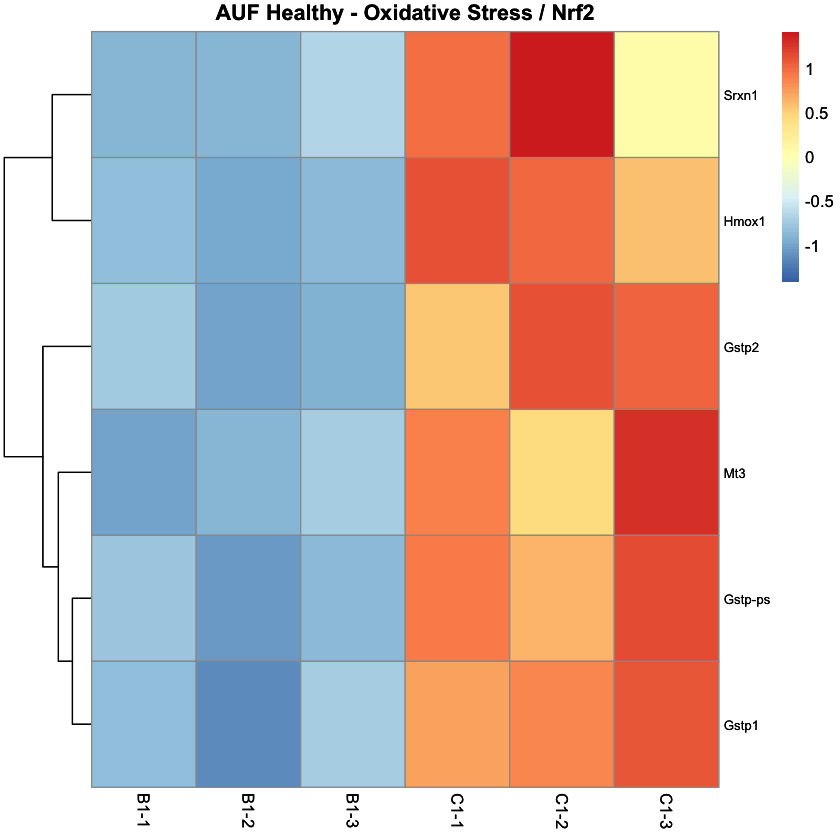

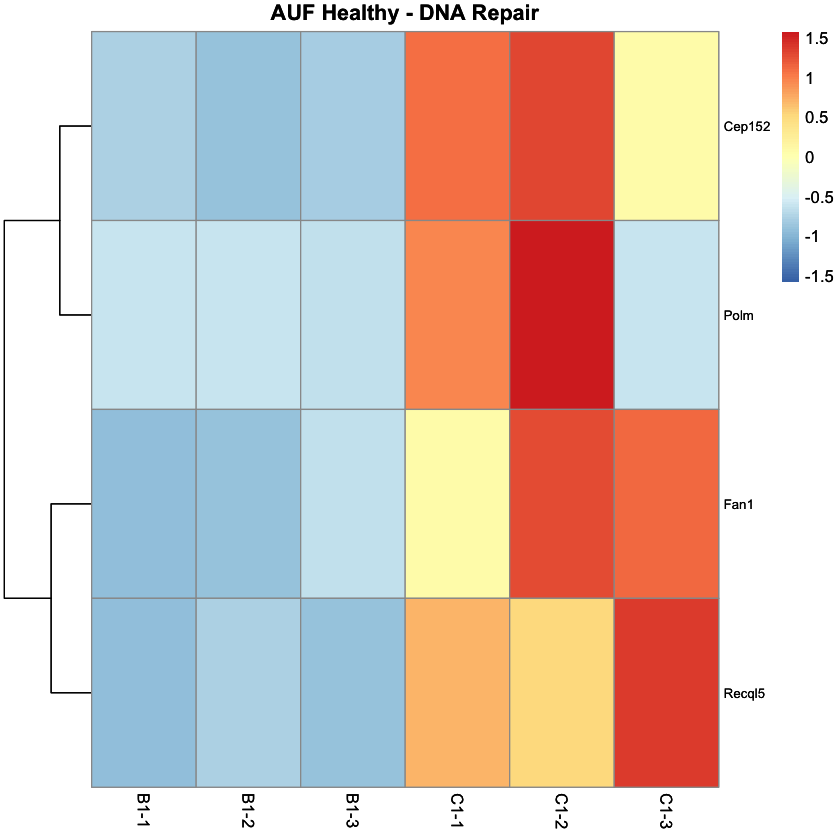

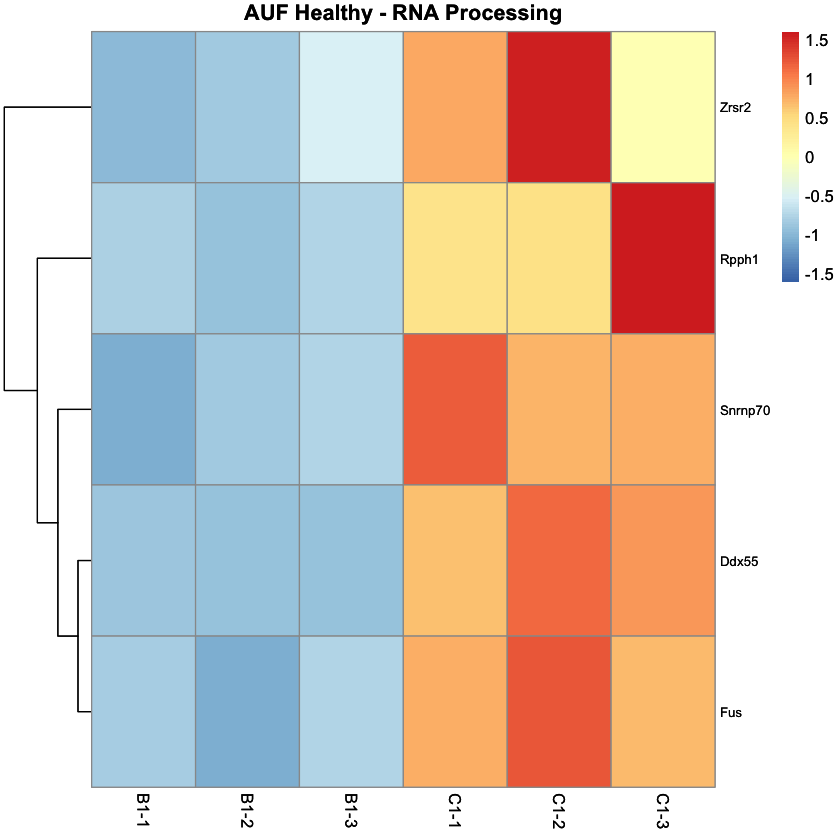

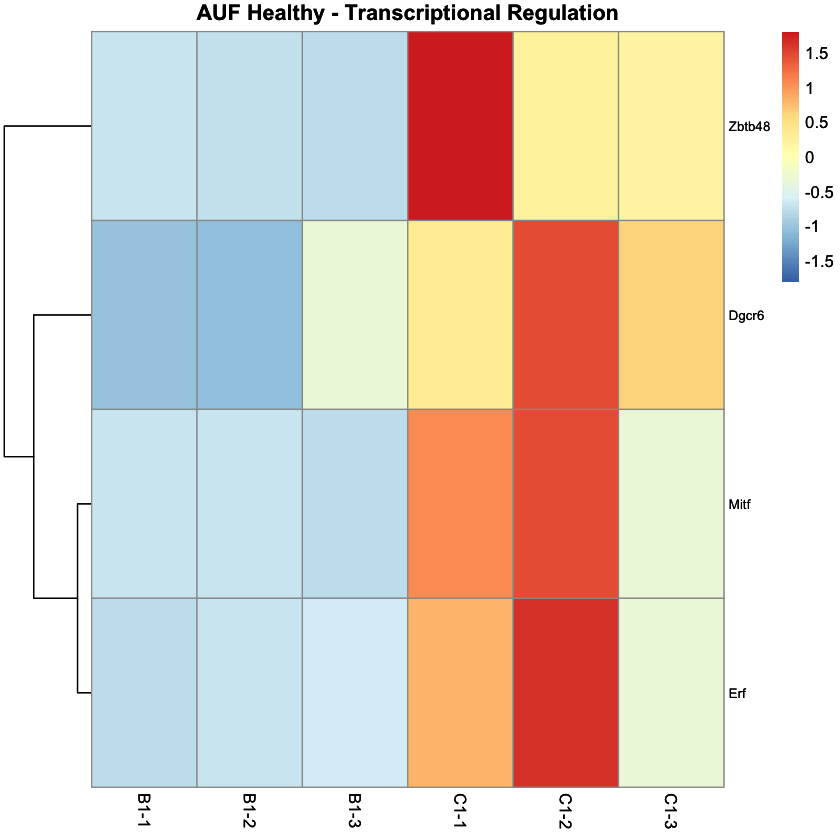

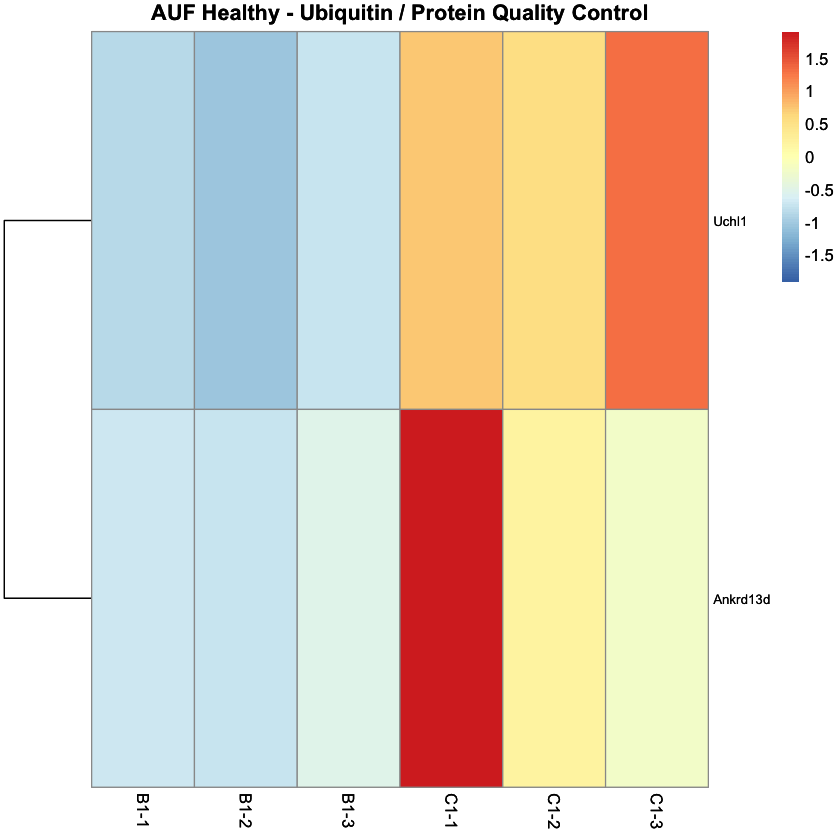

...

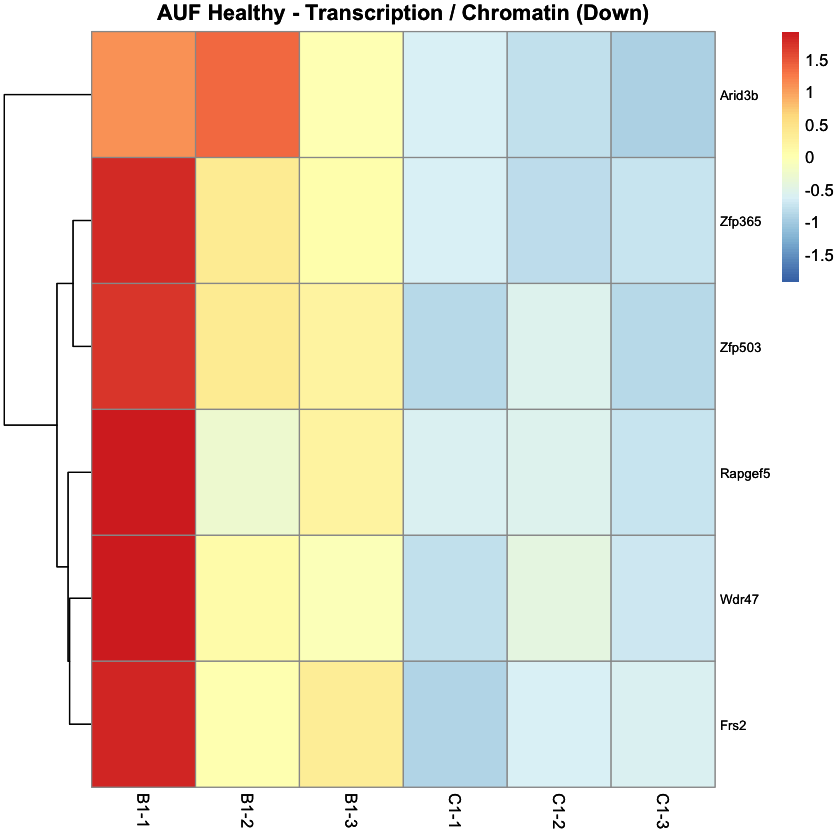

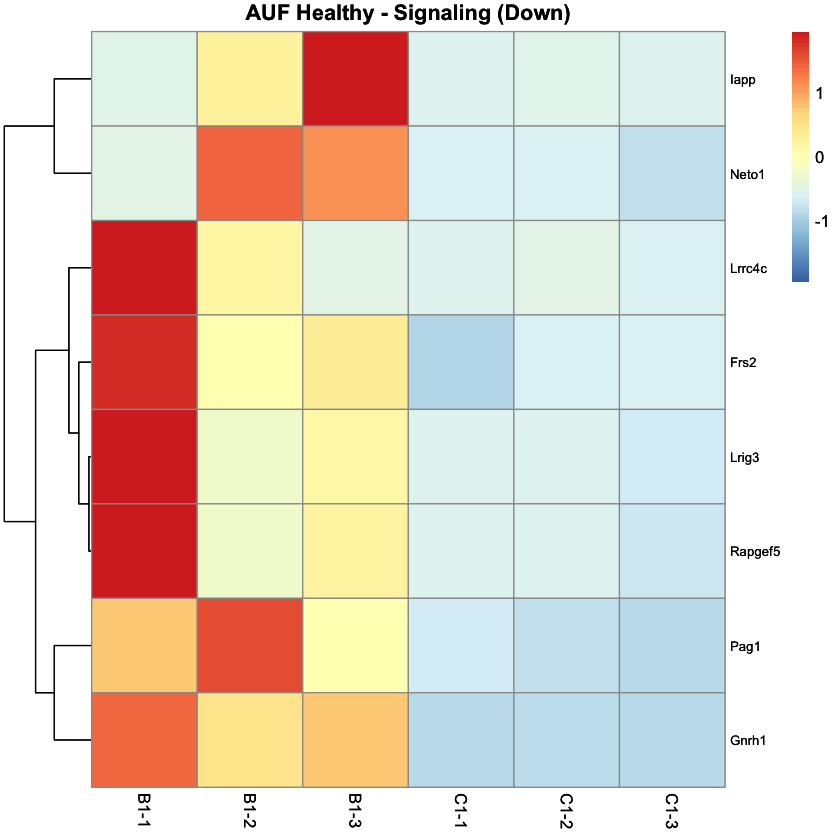

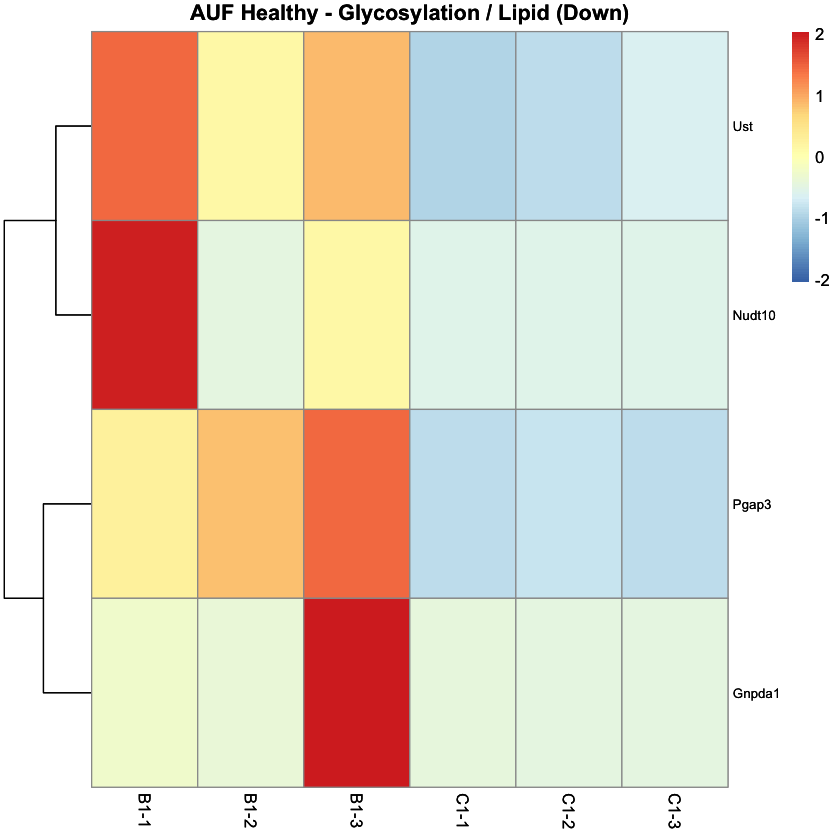

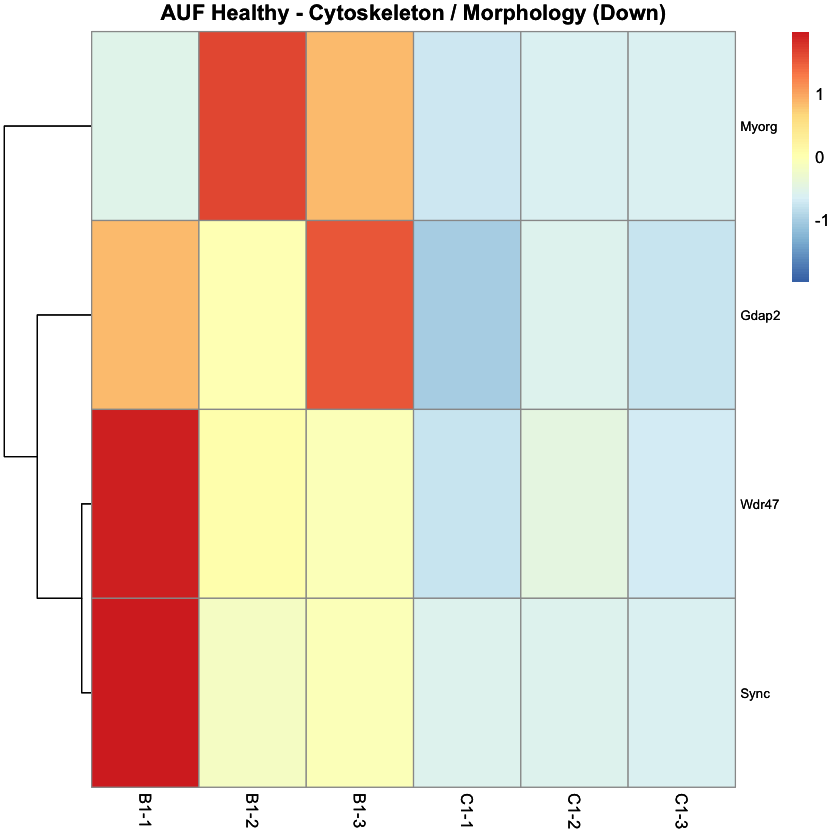

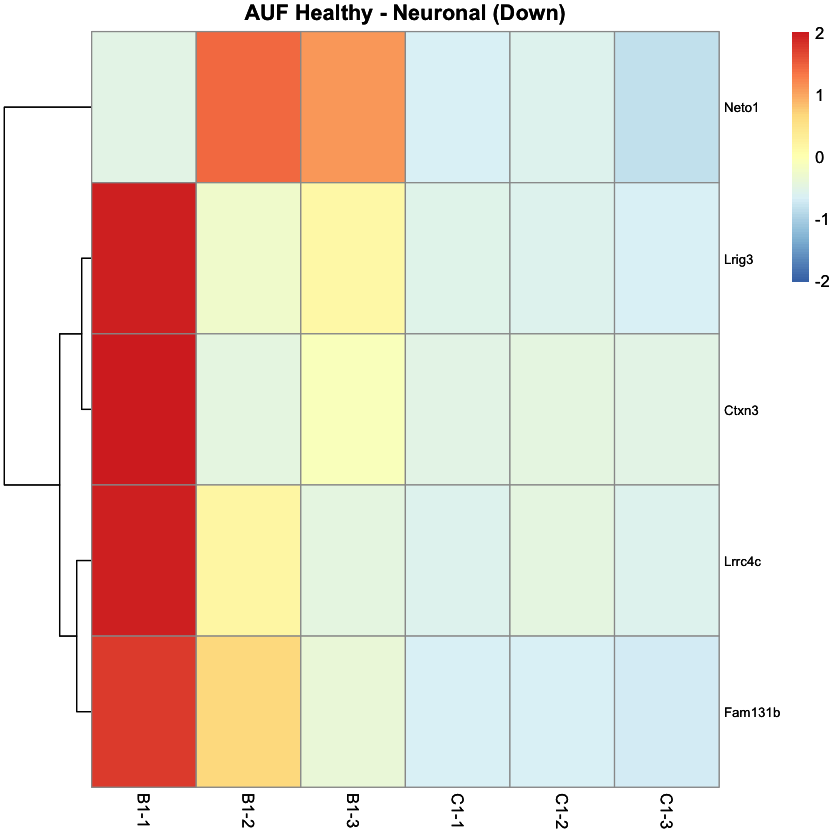

In [57]:
plot_pathway_heatmap <- function(genes, res, df, title) {
  subset <- res[rownames(res) %in% genes, ]
  df_plot <- df[rownames(subset), order(colnames(df))]
  df_plot <- df_plot[rowSums(df_plot) > 0, ]
  if (nrow(df_plot) == 0) {
    cat("No genes found for:", title, "\n")
    return(NULL)
  }
  # Disable row clustering if fewer than 2 rows
  do_cluster <- nrow(df_plot) >= 2
  print(pheatmap(df_plot, scale = "row", cluster_cols = FALSE,
                 cluster_rows = do_cluster, show_rownames = TRUE,
                 fontsize_row = 8, main = title))
}

# Plot each pathway separately
plot_pathway_heatmap(auf_up_oxidative_stress, res_auf, de_out_auf$df,
                     "AUF Healthy - Oxidative Stress / Nrf2")

plot_pathway_heatmap(auf_up_dna_repair, res_auf, de_out_auf$df,
                     "AUF Healthy - DNA Repair")

plot_pathway_heatmap(auf_up_rna_processing, res_auf, de_out_auf$df,
                     "AUF Healthy - RNA Processing")

plot_pathway_heatmap(auf_up_transcription, res_auf, de_out_auf$df,
                     "AUF Healthy - Transcriptional Regulation")

plot_pathway_heatmap(auf_up_ubiquitin_protein, res_auf, de_out_auf$df,
                     "AUF Healthy - Ubiquitin / Protein Quality Control")

plot_pathway_heatmap(auf_up_mitochondrial, res_auf, de_out_auf$df,
                     "AUF Healthy - Mitochondrial")

plot_pathway_heatmap(auf_up_nuclear_structure, res_auf, de_out_auf$df,
                     "AUF Healthy - Nuclear Structure")

plot_pathway_heatmap(auf_up_cytoskeleton_scaffold, res_auf, de_out_auf$df,
                     "AUF Healthy - Cytoskeleton / Scaffold")

plot_pathway_heatmap(auf_up_secreted_extracellular, res_auf, de_out_auf$df,
                     "AUF Healthy - Secreted / Extracellular")

plot_pathway_heatmap(auf_up_ribosome, res_auf, de_out_auf$df,
                     "AUF Healthy - Ribosome / Translation")

plot_pathway_heatmap(auf_dn_immune_inflammation, res_auf, de_out_auf$df,
                     "AUF Healthy - Immune / Inflammation (Down)")

plot_pathway_heatmap(auf_dn_dna_repair_replication, res_auf, de_out_auf$df,
                     "AUF Healthy - DNA Repair / Replication (Down)")

plot_pathway_heatmap(auf_dn_transcription_chromatin, res_auf, de_out_auf$df,
                     "AUF Healthy - Transcription / Chromatin (Down)")

plot_pathway_heatmap(auf_dn_signaling, res_auf, de_out_auf$df,
                     "AUF Healthy - Signaling (Down)")

plot_pathway_heatmap(auf_dn_glycosylation_lipid, res_auf, de_out_auf$df,
                     "AUF Healthy - Glycosylation / Lipid (Down)")

plot_pathway_heatmap(auf_dn_cytoskeleton_morphology, res_auf, de_out_auf$df,
                     "AUF Healthy - Cytoskeleton / Morphology (Down)")

plot_pathway_heatmap(auf_dn_neuronal, res_auf, de_out_auf$df,
                     "AUF Healthy - Neuronal (Down)")

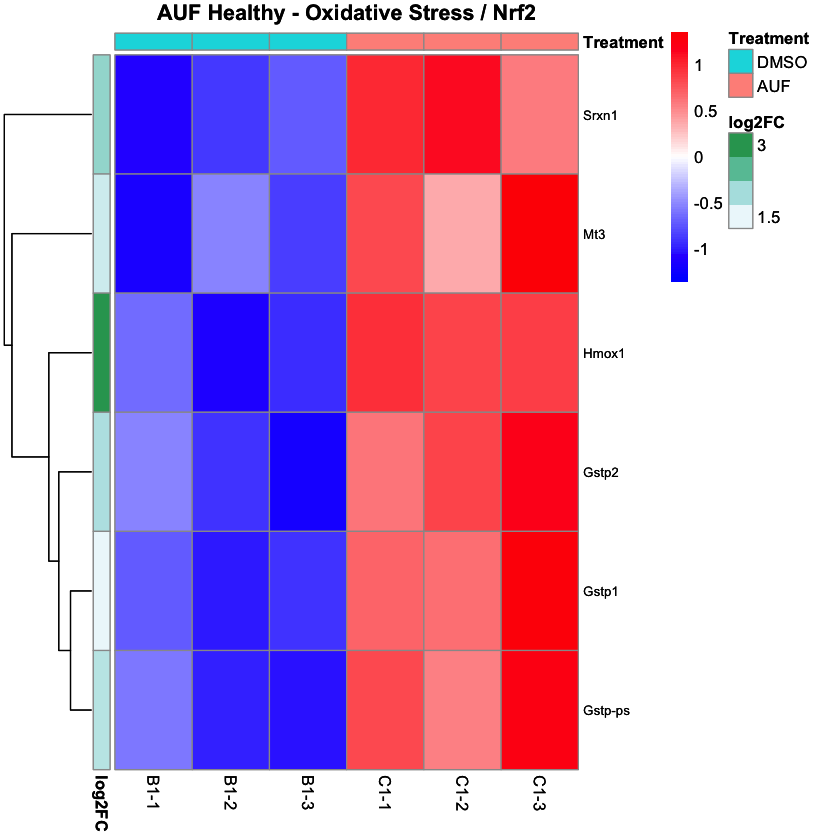

In [58]:
norm_counts_auf <- DESeq2::counts(de_out_auf$dds, normalized = TRUE)

# Create column annotation from meta
col_anno_auf <- data.frame(
  Treatment = de_out_auf$meta_select$Treatment,
  row.names = rownames(de_out_auf$meta_select)
)

plot_pathway_heatmap_lfc <- function(genes, norm_counts, res, title, col_anno) {
  genes <- unique(genes)
  genes_found <- genes[genes %in% rownames(norm_counts)]
  
  if (length(genes_found) == 0) {
    cat("No genes found for:", title, "\n")
    return(NULL)
  }
  
  df_plot <- log2(norm_counts[genes_found, , drop = FALSE] + 1)
  df_plot <- as.matrix(df_plot)
  df_plot <- df_plot[, order(colnames(df_plot)), drop = FALSE]
  df_plot <- df_plot[rowSums(df_plot) > 0, , drop = FALSE]
  
  if (nrow(df_plot) == 0) {
    cat("No expressed genes for:", title, "\n")
    return(NULL)
  }
  
  lfc_vals <- round(as.data.frame(res[rownames(df_plot), "log2FoldChange"]), 2)
  rownames(lfc_vals) <- rownames(df_plot)
  colnames(lfc_vals) <- "log2FC"
  
  # Match col_anno to current column order
  col_anno_matched <- col_anno[colnames(df_plot), , drop = FALSE]
  
  do_cluster <- nrow(df_plot) >= 2
  
  print(pheatmap(df_plot, cluster_cols = FALSE, cluster_rows = do_cluster,
                 show_rownames = TRUE, fontsize_row = 8, main = title,
                 scale = "row",
                 annotation_row = lfc_vals,
                 annotation_col = col_anno_matched,
                 color = colorRampPalette(c("blue", "white", "red"))(100)))
}

# Plot each pathway - note the added col_anno_auf argument
plot_pathway_heatmap_lfc(auf_up_oxidative_stress, norm_counts_auf, res_auf,
                          "AUF Healthy - Oxidative Stress / Nrf2", col_anno_auf)

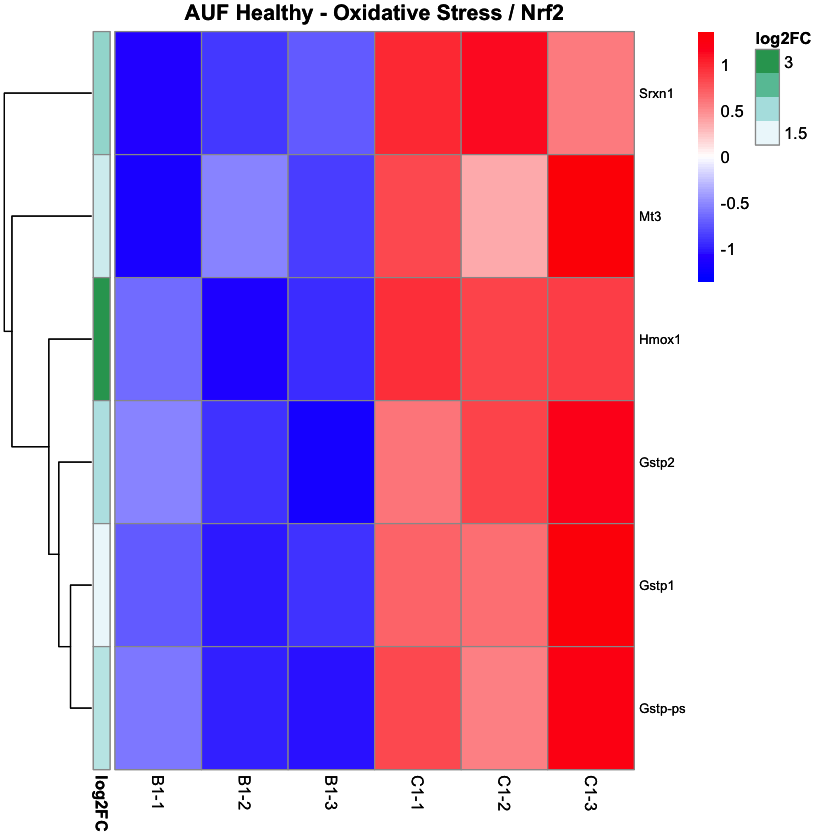

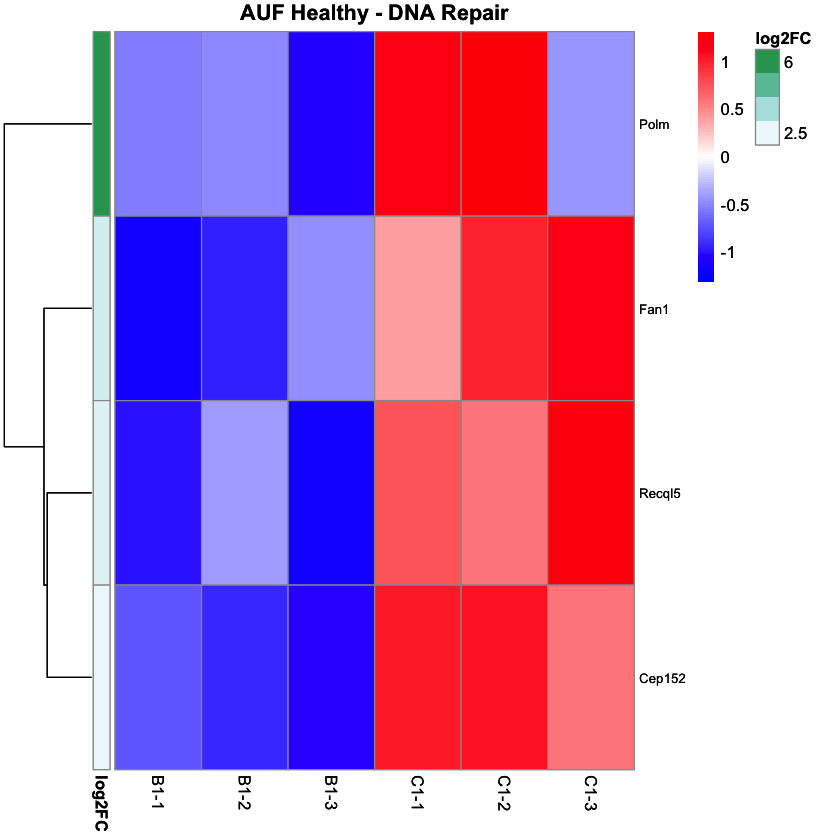

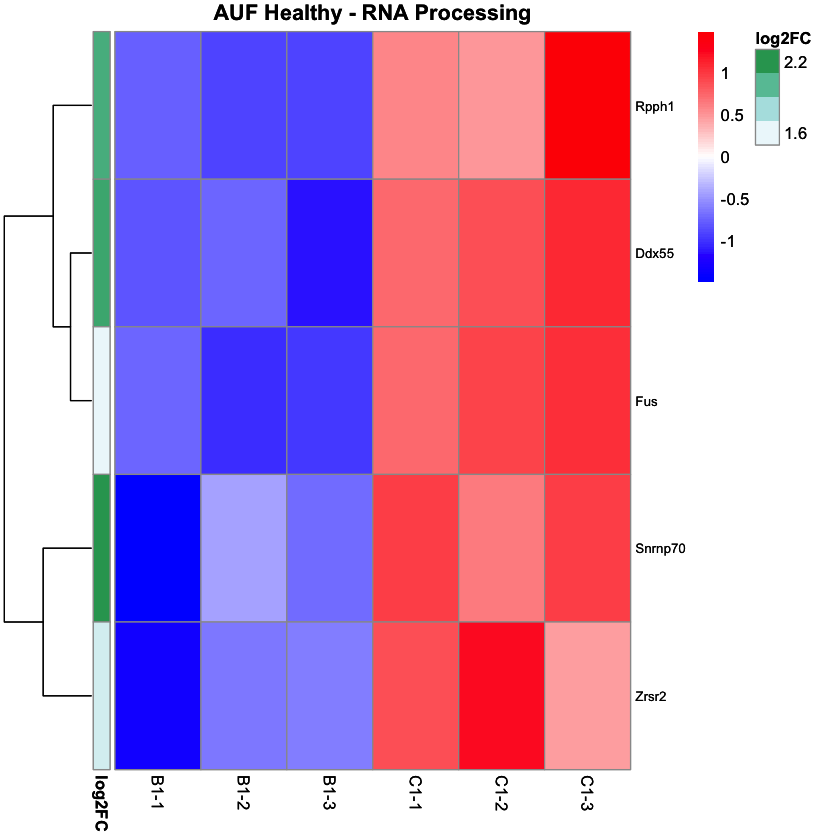

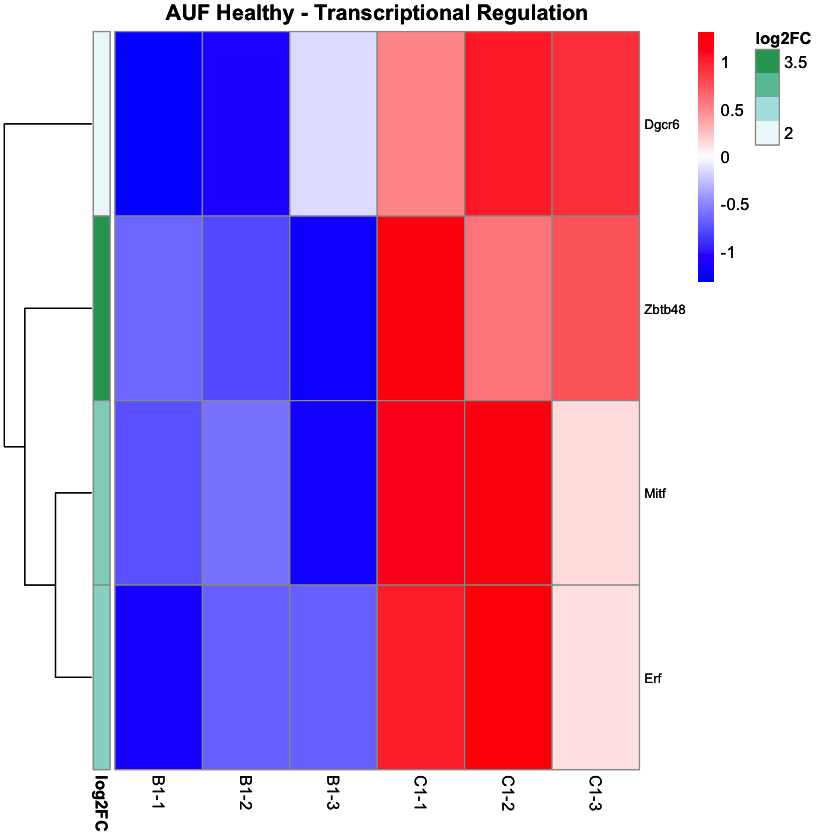

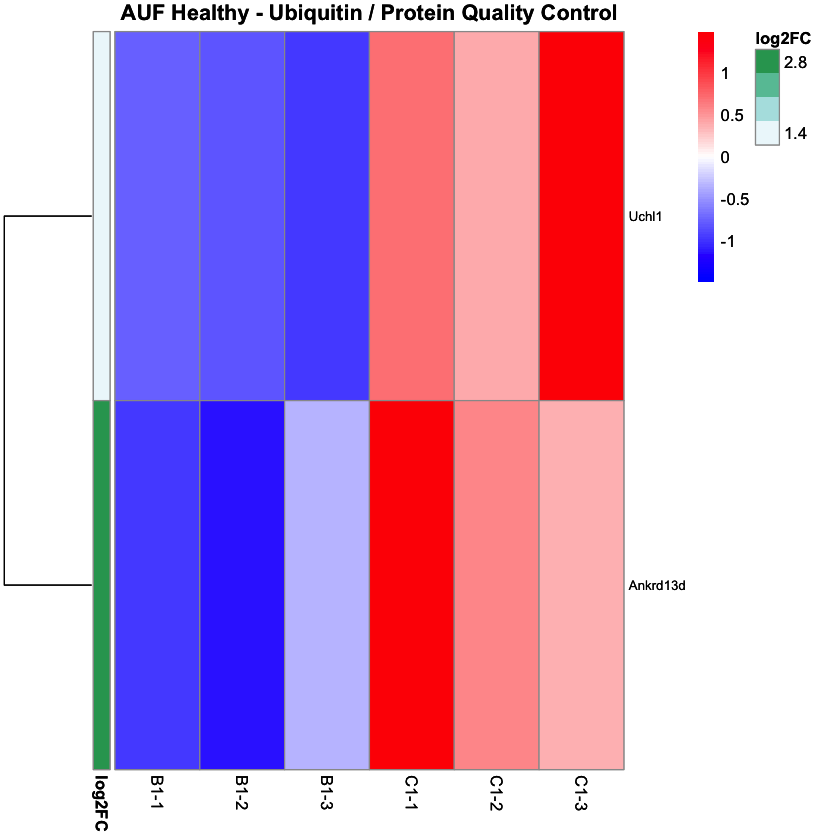

...

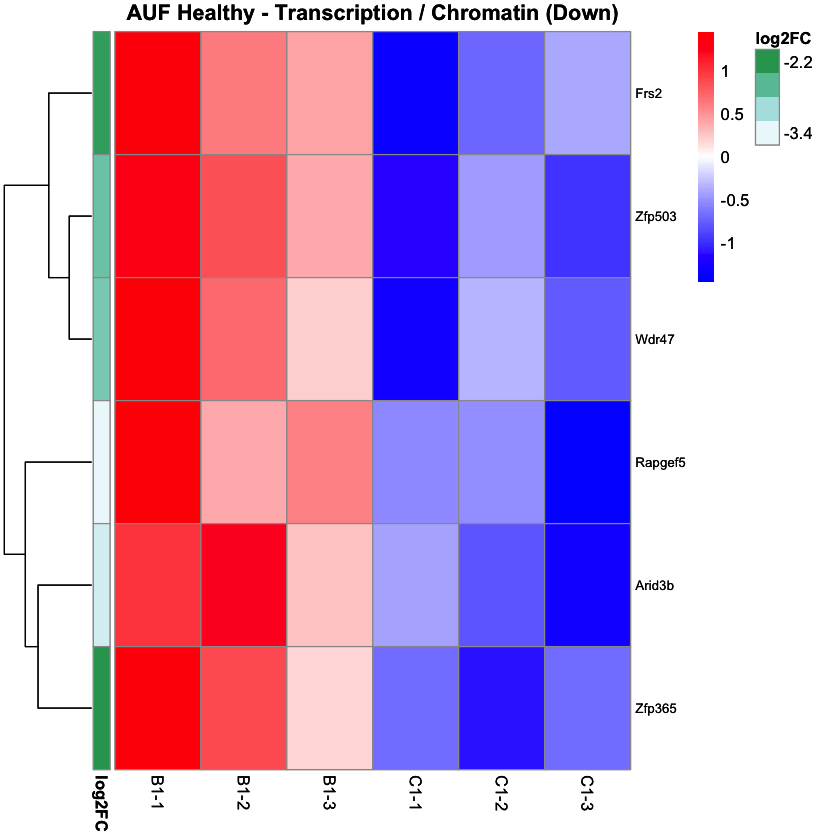

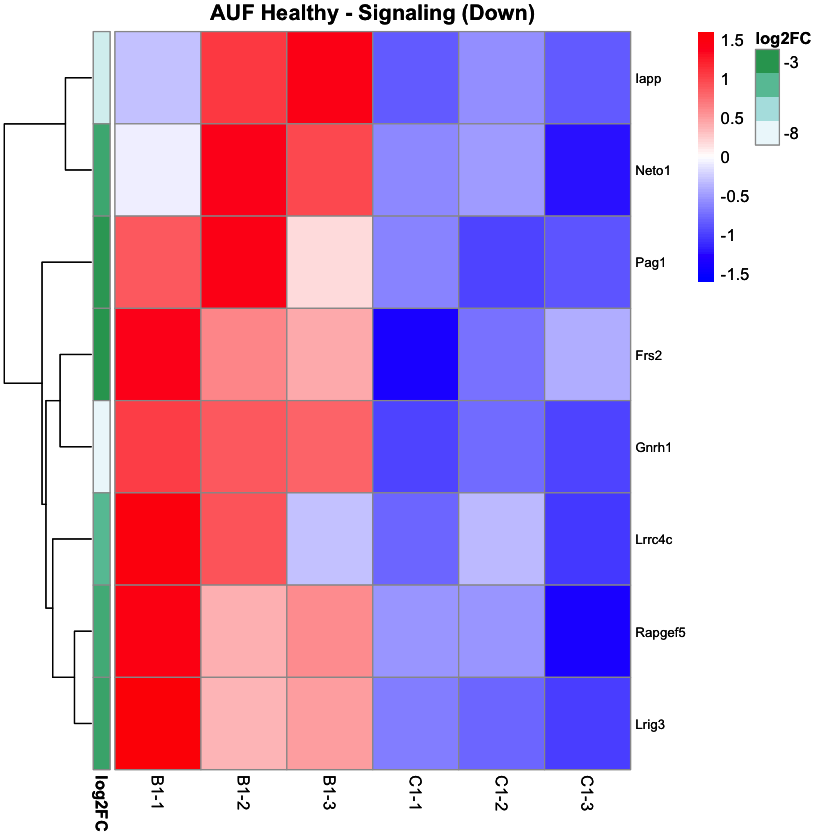

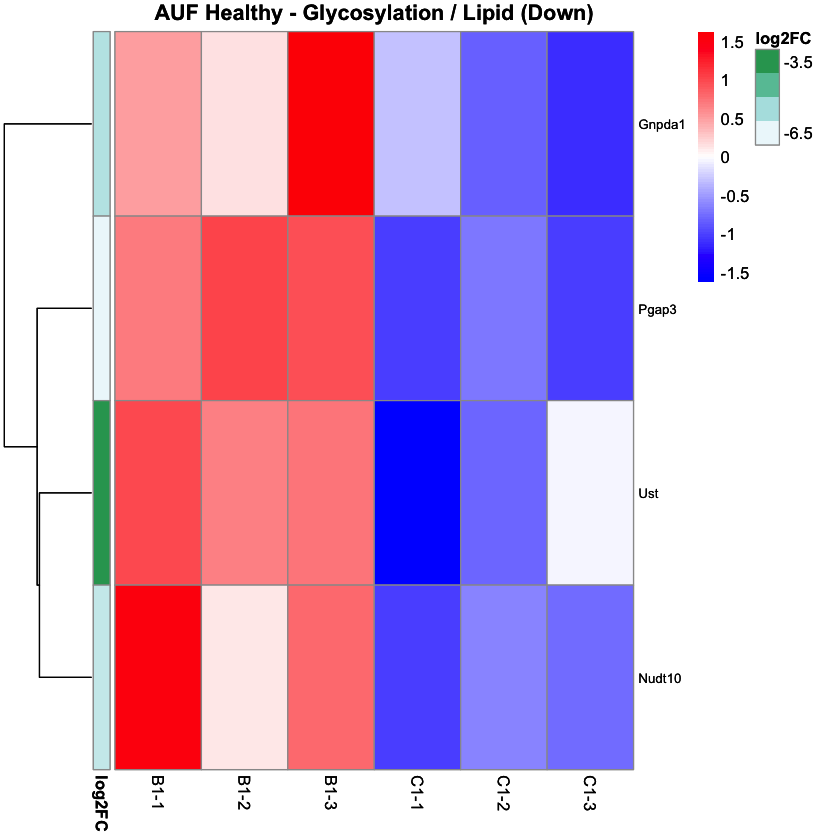

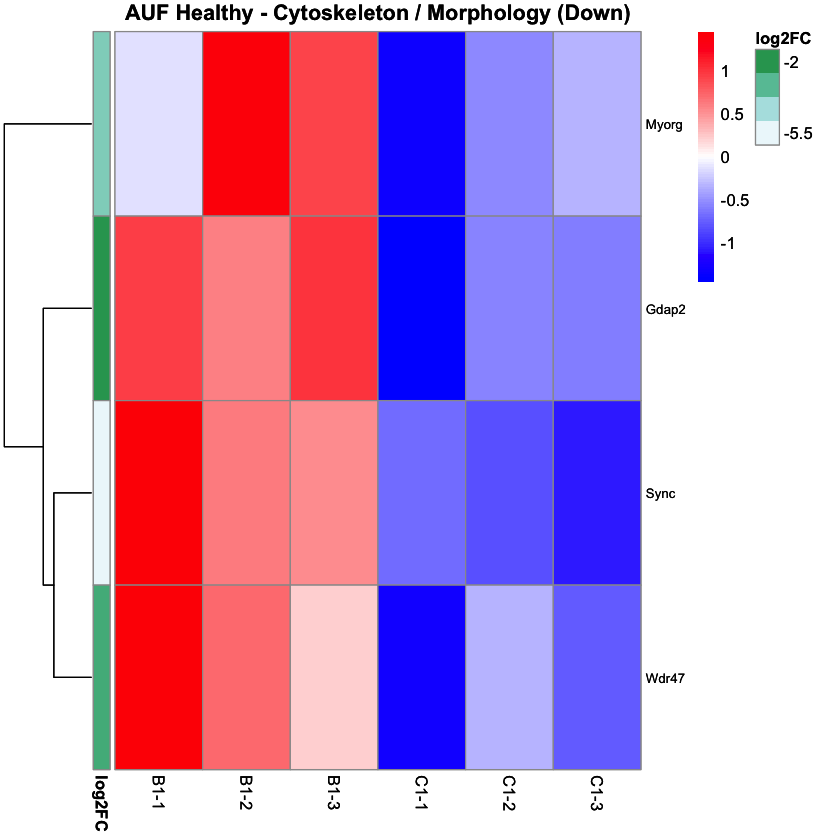

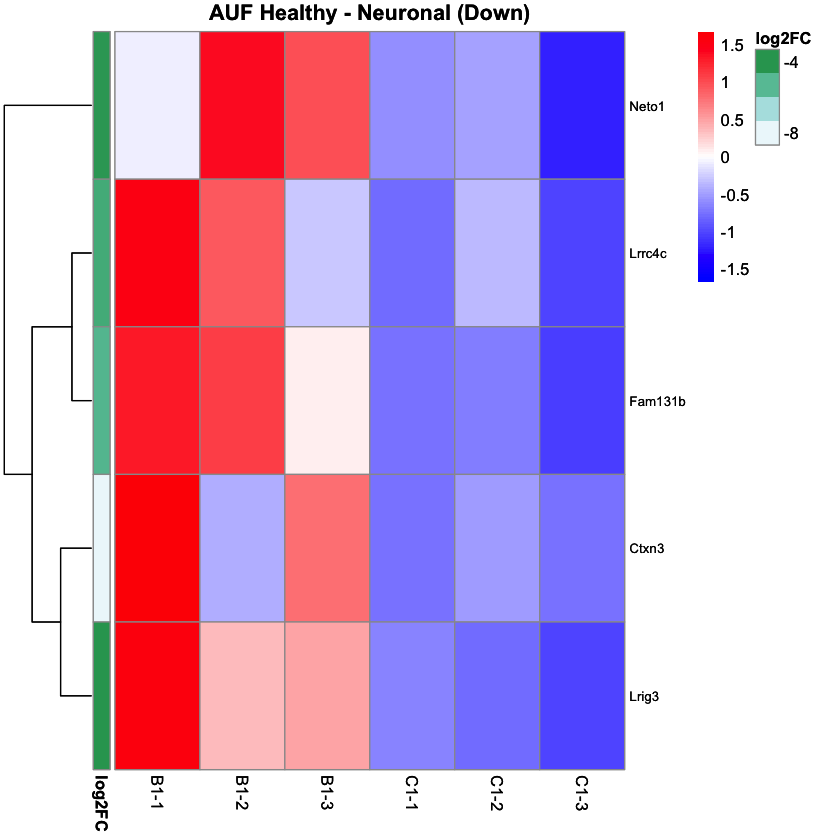

In [59]:
norm_counts_auf <- DESeq2::counts(de_out_auf$dds, normalized = TRUE)

plot_pathway_heatmap_lfc <- function(genes, norm_counts, res, title) {
  genes_found <- genes[genes %in% rownames(norm_counts)]
  
  if (length(genes_found) == 0) {
    cat("No genes found for:", title, "\n")
    return(NULL)
  }
  
  df_plot <- log2(norm_counts[genes_found, , drop = FALSE] + 1)
  df_plot <- as.matrix(df_plot)  # ensure plain matrix with colnames
  df_plot <- df_plot[, order(colnames(df_plot)), drop = FALSE]
  
  # Remove zero rows
  df_plot <- df_plot[rowSums(df_plot) > 0, , drop = FALSE]
  
  if (nrow(df_plot) == 0) {
    cat("No expressed genes for:", title, "\n")
    return(NULL)
  }
  
  lfc_vals <- round(as.data.frame(res[rownames(df_plot), "log2FoldChange"]), 2)
  rownames(lfc_vals) <- rownames(df_plot)
  colnames(lfc_vals) <- "log2FC"
  
  do_cluster <- nrow(df_plot) >= 2
  
  print(pheatmap(df_plot, cluster_cols = FALSE, cluster_rows = do_cluster,
                 show_rownames = TRUE, fontsize_row = 8, main = title,
                 scale = "row",
                 annotation_row = lfc_vals,
                 color = colorRampPalette(c("blue", "white", "red"))(100)))
}

# Plot each pathway
plot_pathway_heatmap_lfc(auf_up_oxidative_stress, norm_counts_auf, res_auf,
                          "AUF Healthy - Oxidative Stress / Nrf2")

plot_pathway_heatmap_lfc(auf_up_dna_repair, norm_counts_auf, res_auf,
                          "AUF Healthy - DNA Repair")

plot_pathway_heatmap_lfc(auf_up_rna_processing, norm_counts_auf, res_auf,
                          "AUF Healthy - RNA Processing")

plot_pathway_heatmap_lfc(auf_up_transcription, norm_counts_auf, res_auf,
                          "AUF Healthy - Transcriptional Regulation")

plot_pathway_heatmap_lfc(auf_up_ubiquitin_protein, norm_counts_auf, res_auf,
                          "AUF Healthy - Ubiquitin / Protein Quality Control")

plot_pathway_heatmap_lfc(auf_up_mitochondrial, norm_counts_auf, res_auf,
                          "AUF Healthy - Mitochondrial")

plot_pathway_heatmap_lfc(auf_up_nuclear_structure, norm_counts_auf, res_auf,
                          "AUF Healthy - Nuclear Structure")

plot_pathway_heatmap_lfc(auf_up_cytoskeleton_scaffold, norm_counts_auf, res_auf,
                          "AUF Healthy - Cytoskeleton / Scaffold")

plot_pathway_heatmap_lfc(auf_up_secreted_extracellular, norm_counts_auf, res_auf,
                          "AUF Healthy - Secreted / Extracellular")

plot_pathway_heatmap_lfc(auf_up_ribosome, norm_counts_auf, res_auf,
                          "AUF Healthy - Ribosome / Translation")

plot_pathway_heatmap_lfc(auf_dn_immune_inflammation, norm_counts_auf, res_auf,
                          "AUF Healthy - Immune / Inflammation (Down)")

plot_pathway_heatmap_lfc(auf_dn_dna_repair_replication, norm_counts_auf, res_auf,
                          "AUF Healthy - DNA Repair / Replication (Down)")

plot_pathway_heatmap_lfc(auf_dn_transcription_chromatin, norm_counts_auf, res_auf,
                          "AUF Healthy - Transcription / Chromatin (Down)")

plot_pathway_heatmap_lfc(auf_dn_signaling, norm_counts_auf, res_auf,
                          "AUF Healthy - Signaling (Down)")

plot_pathway_heatmap_lfc(auf_dn_glycosylation_lipid, norm_counts_auf, res_auf,
                          "AUF Healthy - Glycosylation / Lipid (Down)")

plot_pathway_heatmap_lfc(auf_dn_cytoskeleton_morphology, norm_counts_auf, res_auf,
                          "AUF Healthy - Cytoskeleton / Morphology (Down)")

plot_pathway_heatmap_lfc(auf_dn_neuronal, norm_counts_auf, res_auf,
                          "AUF Healthy - Neuronal (Down)")

## TMZ in Healthy Organoids

Genes found in sig_genes_tmz: 178 
Genes not significant:  


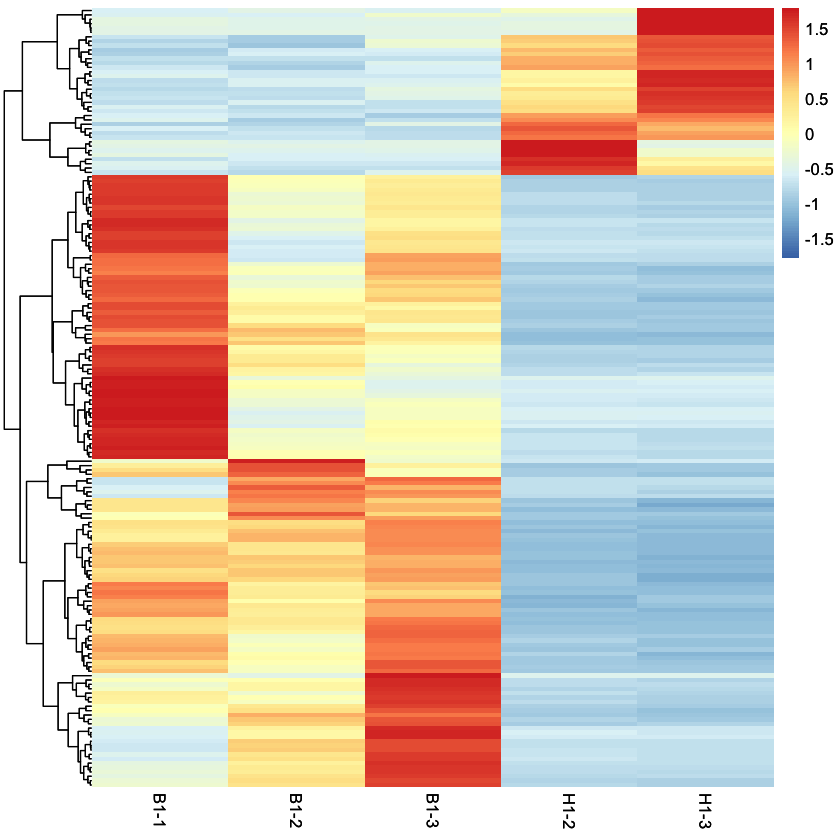

In [61]:
# ── TMZ UP-REGULATED ──────────────────────────────────────────────────────────

tmz_up_cell_cycle <- c("Cdk3",     # cyclin-dependent kinase; G1/S transition
                        "Cep152",   # centrosome biogenesis; replication stress
                        "Lrrc45",   # centriole elongation
                        "Katnip",   # microtubule severing; mitosis
                        "Lzts1")    # leucine zipper tumor suppressor; mitotic regulation

tmz_up_dna_repair <- c("Cep152",   # centrosome; replication stress checkpoint
                        "Tspyl2")   # TSPY-like; DNA damage response

tmz_up_rna_processing <- c("Rpph1",   # RNase P RNA; tRNA processing
                             "Mrm3",    # mitochondrial rRNA methyltransferase
                             "Aarsd1")  # alanyl-tRNA synthetase domain

tmz_up_lipid_metabolism <- c("Lipe",     # hormone-sensitive lipase; lipolysis
                               "Plpp7",   # phospholipid phosphatase
                               "Acss1",   # acyl-CoA synthetase; short-chain FA
                               "Slc27a3", # fatty acid transport
                               "Slc25a38",# mitochondrial transporter; heme/FA
                               "Slc25a29",# mitochondrial carnitine transporter
                               "Nr1h4")   # FXR nuclear receptor; bile acid/lipid

tmz_up_signaling <- c("Ndrg1",   # stress-responsive; MAPK / HIF target
                       "Efhd2",   # calcium-binding; actin / immune signaling
                       "Flt3l",   # cytokine; FLT3 receptor ligand
                       "Igfbp4",  # IGF binding protein; IGF signaling
                       "Il4i1",   # IL-4 induced; amino acid metabolism / immune
                       "Opn3",    # opsin; GPCR signaling
                       "Prtg",    # protogenin; axon guidance receptor
                       "Gfra2")   # GDNF receptor alpha; RET signaling

tmz_up_transcription <- c("Cbx8",     # polycomb repressor complex 1
                           "Zfp764",   # zinc finger transcription factor
                           "Zfp764l1", # zinc finger transcription factor
                           "Lzic",     # leucine zipper; transcriptional
                           "Msantd1")  # Myb/SANT domain; transcriptional

tmz_up_vesicle_trafficking <- c("Ehd4",    # EH-domain; endosomal recycling
                                  "Tbc1d17", # Rab GAP; vesicle trafficking
                                  "Marchf1") # E3 ubiquitin ligase; membrane trafficking

tmz_up_cytoskeleton <- c("Frmd5",  # FERM domain; actin cytoskeleton
                          "Katnip", # microtubule severing
                          "Ccdc142")# coiled-coil; cytoskeletal organization

tmz_up_extracellular_matrix <- c("Fndc1",  # fibronectin domain; ECM
                                   "Ccn6",  # CCN family; ECM / growth regulation
                                   "Guca1a")# guanylate cyclase activator

tmz_up_mitochondrial <- c("Slc25a29", # mitochondrial carnitine transporter
                           "Slc25a38", # mitochondrial transporter
                           "Mrm3",     # mitochondrial rRNA methyltransferase
                           "Gfod2")    # mitochondrial oxidoreductase
                           
# ── TMZ DOWN-REGULATED ────────────────────────────────────────────────────────

tmz_dn_dna_repair_replication <- c("Blm",      # RecQ helicase; DNA repair / replication
                                    "Rad51",    # homologous recombination
                                    "Fancb",    # Fanconi anemia; interstrand crosslink repair
                                    "Fignl1",   # fidgetin-like; DNA repair
                                    "Esco1",    # establishment of cohesion; replication
                                    "Pola1",    # DNA polymerase alpha; replication
                                    "Parpbp",   # PARP1-binding; DNA damage
                                    "Abraxas1", # BRCA1-A complex; DSB repair
                                    "Scaper",   # S-phase cyclin A-associated; replication
                                    "Tk2",      # thymidine kinase; nucleotide salvage
                                    "Cep135",   # centrosome; replication checkpoint
                                    "Pibf1")    # progesterone-induced blocking factor; G2/M

tmz_dn_cell_cycle <- c("Lats1",   # LATS1 kinase; Hippo pathway / G2-M
                        "Cenpl",   # kinetochore; chromosome segregation
                        "Scaper",  # S-phase cyclin A; cell cycle
                        "Cables1", # CDK5/ABL substrate; G1 checkpoint
                        "Rgcc",    # regulator of cell cycle
                        "Blm",     # replication fork; S-phase
                        "Bid")     # BH3-only; apoptosis / cell cycle crosstalk

tmz_dn_apoptosis <- c("Bid",     # BH3-only protein; apoptosis
                       "Casp6",   # caspase-6; apoptosis execution
                       "Cflar",   # c-FLIP; apoptosis inhibitor
                       "Nsmaf",   # neutral sphingomyelinase; TNF-induced apoptosis
                       "Tnip1",   # TNFAIP3-interacting; NF-kB / apoptosis
                       "Bcl11a")  # BCL11A; survival / lymphoid

tmz_dn_transcription_chromatin <- c("Bcl11a",  # transcriptional repressor; lymphoid
                                     "Mafb",    # bZIP transcription factor
                                     "Tfe3",    # MiT/TFE transcription factor; lysosome
                                     "Rarb",    # retinoic acid receptor beta
                                     "Nr3c1",   # glucocorticoid receptor
                                     "Nfatc1",  # NFAT; calcium-dependent transcription
                                     "Kat6b",   # histone acetyltransferase; chromatin
                                     "Kdm1b",   # histone demethylase; epigenetic
                                     "Pogz",    # heterochromatin; chromatin regulation
                                     "Jade3",   # histone H4 acetyltransferase complex
                                     "Prmt6",   # arginine methyltransferase; histone H3
                                     "Rbak",    # RB-associated KRAB; transcriptional
                                     "Pknox2",  # PREP/MEIS homeodomain factor
                                     "Zfp365",  # zinc finger; replication / transcription
                                     "Zfp715",  # zinc finger transcription factor
                                     "Zfp719",  # zinc finger transcription factor
                                     "Zfp51",   # zinc finger transcription factor
                                     "Zfp87",   # zinc finger transcription factor
                                     "Zfp101",  # zinc finger transcription factor
                                     "Zfp597",  # zinc finger transcription factor
                                     "Zfp960",  # zinc finger transcription factor
                                     "Zfp420",  # zinc finger transcription factor
                                     "Zfp712",  # zinc finger transcription factor
                                     "Zfp946",  # zinc finger transcription factor
                                     "Zfp11",   # zinc finger transcription factor
                                     "Zkscan8", # zinc finger SCAN domain
                                     "Bahcc1",  # BAH and coiled-coil; chromatin
                                     "Tbl1xr1") # transducin beta-like; NCoR/SMRT complex

tmz_dn_signaling <- c("Lats1",    # Hippo kinase
                       "Mapk14",   # p38-MAPK; stress signaling
                       "Frs2",     # FGF receptor substrate; RAS/ERK
                       "Prkcq",    # PKC-theta; T cell / NF-kB signaling
                       "Prkacb",   # PKA catalytic subunit
                       "Prkg1",    # PKG; cGMP signaling
                       "Camk2d",   # CaMKII delta; calcium signaling
                       "Ppm1e",    # PP2C phosphatase; CaMK regulation
                       "Rasal2",   # RAS GAP; RAS/MAPK
                       "Rin2",     # RIN2 Rab5 GEF; endosomal signaling
                       "Dock3",    # DOCK family GEF; Rac1 signaling
                       "Tgfbr2",   # TGF-beta receptor II
                       "Fzd2",     # Frizzled-2; Wnt signaling
                       "Fzd4",     # Frizzled-4; Wnt signaling
                       "Atf6",     # ATF6; UPR / ER stress
                       "Iapp",     # metabolic signaling
                       "Gnrh1",    # neuroendocrine signaling
                       "Peak1",    # pseudokinase; focal adhesion signaling
                       "Smurf1")   # SMAD ubiquitin ligase; TGF-beta

tmz_dn_ubiquitin_proteasome <- c("Rnf167",  # RING E3 ligase
                                   "Rnf138",  # RING E3 ligase; DNA repair
                                   "Rnf141",  # RING E3 ligase
                                   "Trim32",  # TRIM E3 ligase; ubiquitin
                                   "Trim23",  # TRIM E3 ligase
                                   "Cul2",    # cullin-2; CRL E3 complex
                                   "Fbxo10",  # F-box; SCF E3 complex
                                   "Klhl12",  # Kelch; Cullin3 adaptor
                                   "Klhl15",  # Kelch; Cullin3 adaptor
                                   "Kbtbd7",  # BTB-Kelch; Cullin3 adaptor
                                   "Usp54",   # deubiquitinase
                                   "Ube2e2",  # E2 ubiquitin-conjugating enzyme
                                   "Bag2",    # BAG family; proteasome / chaperone
                                   "Ubap1")   # ubiquitin-associated protein

tmz_dn_lipid_metabolism <- c("Cpt2",    # carnitine palmitoyltransferase II; FA oxidation
                               "Cyb5a",   # cytochrome b5; fatty acid desaturation
                               "Cyb5r4",  # cytochrome b5 reductase; lipid metabolism
                               "Liph",    # lipase H; phospholipid catabolism
                               "Gdpd2",   # glycerophosphodiester phosphodiesterase
                               "Cept1",   # choline/ethanolamine phosphotransferase; PE/PC
                               "Slc7a11", # cystine/glutamate transporter; redox
                               "Abca1",   # ABC transporter; cholesterol efflux
                               "Plpp4",   # phospholipid phosphatase
                               "Mthfd2l") # methyleneTHF dehydrogenase; one-carbon/lipid

tmz_dn_glycosylation <- c("Manea",     # mannosidase; N-glycan processing
                            "C1galt1c1", # T-synthase chaperone; O-glycosylation
                            "Galns",     # galactosamine-6-sulfatase; GAG degradation
                            "Arsb",      # arylsulfatase B; GAG degradation
                            "Csgalnact1",# chondroitin sulfate GalNAc transferase
                            "Slc35b3",   # UDP-GlcUA transporter; GAG synthesis
                            "Slc35d1",   # UDP-GlcUA/GalNAc transporter
                            "B3galt2",   # beta-1,3-galactosyltransferase
                            "Gnpda1",    # glucosamine-6P deaminase; hexosamine
                            "Ust",       # uronyl 2-sulfotransferase; heparan sulfate
                            "Ganc",      # glucoamylase; glycan catabolism
                            "Edem3")     # ER mannosidase; glycoprotein folding/ERAD

tmz_dn_mitochondrial <- c("Cpt2",     # FA beta-oxidation
                           "Cyb5a",    # electron transport
                           "Cyb5r4",   # electron transport
                           "Nars2",    # mitochondrial asparaginyl-tRNA synthetase
                           "Hars2",    # mitochondrial histidyl-tRNA synthetase
                           "Tars3",    # mitochondrial threonyl-tRNA synthetase
                           "Mrps10",   # mitochondrial ribosomal protein
                           "Pde12",    # mitochondrial 2',5'-oligoadenylate degradation
                           "Lyrm7",    # complex III assembly factor
                           "Immp2l",   # inner mitochondrial membrane peptidase
                           "Rtn4ip1",  # reticulon; mitochondrial / ER contact
                           "Fdxacb1",  # ferredoxin; mitochondrial steroidogenesis
                           "Tk2",      # thymidine kinase 2; mtDNA maintenance
                           "Isoc1",    # isochorismatase; TCA-related
                           "Mtrf1")    # mitochondrial release factor

tmz_dn_neuronal_synaptic <- c("Epha4",   # ephrin receptor; axon guidance
                                "Ncam2",  # neural cell adhesion molecule
                                "Cdh10",  # cadherin-10; neuronal adhesion
                                "Pcdh15", # protocadherin-15; synapse / hair cell
                                "Pcdhb14","Pcdhb18","Pcdhb22", # clustered protocadherins
                                "Pcdh18", # protocadherin-18; neuronal
                                "Gabbr1", # GABA-B receptor
                                "Adgrl3", # latrophilin-3; synapse organization
                                "Dock3",  # Rac1 GEF; axon outgrowth
                                "Ednrb",  # endothelin receptor B; neural crest
                                "Iapp",   # neuropeptide / metabolic
                                "Gnrh1",  # neuroendocrine
                                "Jakmip2",# microtubule; neuronal transport
                                "Thsd7a") # thrombospondin; synapse

tmz_dn_rna_processing <- c("Gemin8",  # SMN complex; snRNP assembly
                             "Rnpc3",   # minor spliceosome; U12-type introns
                             "Shq1",    # H/ACA snoRNP assembly
                             "Rpp25l",  # RNase P subunit; tRNA processing
                             "Pus3",    # pseudouridine synthase; tRNA
                             "Trmt6",   # tRNA methyltransferase
                             "Trmt2b",  # tRNA methyltransferase
                             "Dus4l",   # dihydrouridine synthase; tRNA
                             "Snord47", # snoRNA; rRNA modification
                             "Snord80", # snoRNA; rRNA modification
                             "Ctif",    # cap-dependent translation initiation
                             "Polr3g",  # RNA pol III subunit; tRNA transcription
                             "Polr1b")  # RNA pol I subunit; rRNA transcription

# ── Combine all ───────────────────────────────────────────────────────────────

all_pathways_tmz <- unique(c(
  tmz_up_cell_cycle, tmz_up_dna_repair, tmz_up_rna_processing,
  tmz_up_lipid_metabolism, tmz_up_signaling, tmz_up_transcription,
  tmz_up_vesicle_trafficking, tmz_up_cytoskeleton, tmz_up_extracellular_matrix,
  tmz_up_mitochondrial,
  tmz_dn_dna_repair_replication, tmz_dn_cell_cycle, tmz_dn_apoptosis,
  tmz_dn_transcription_chromatin, tmz_dn_signaling, tmz_dn_ubiquitin_proteasome,
  tmz_dn_lipid_metabolism, tmz_dn_glycosylation, tmz_dn_mitochondrial,
  tmz_dn_neuronal_synaptic, tmz_dn_rna_processing))

# ── Check significance ────────────────────────────────────────────────────────

sig_subset_tmz <- sig_genes_tmz[rownames(sig_genes_tmz) %in% all_pathways_tmz, ]
cat("Genes found in sig_genes_tmz:", nrow(sig_subset_tmz), "\n")
cat("Genes not significant:", all_pathways_tmz[!all_pathways_tmz %in% rownames(sig_genes_tmz)], "\n")

# ── Heatmap ───────────────────────────────────────────────────────────────────

pathway_subset_tmz <- res_tmz[rownames(res_tmz) %in% all_pathways_tmz, ]
df_plot_tmz <- de_out_tmz$df[rownames(pathway_subset_tmz), order(colnames(de_out_tmz$df))]

print(pheatmap(df_plot_tmz, scale = "row", cluster_cols = FALSE,
               cluster_rows = TRUE, show_rownames = FALSE,
               fontsize_row = 7))

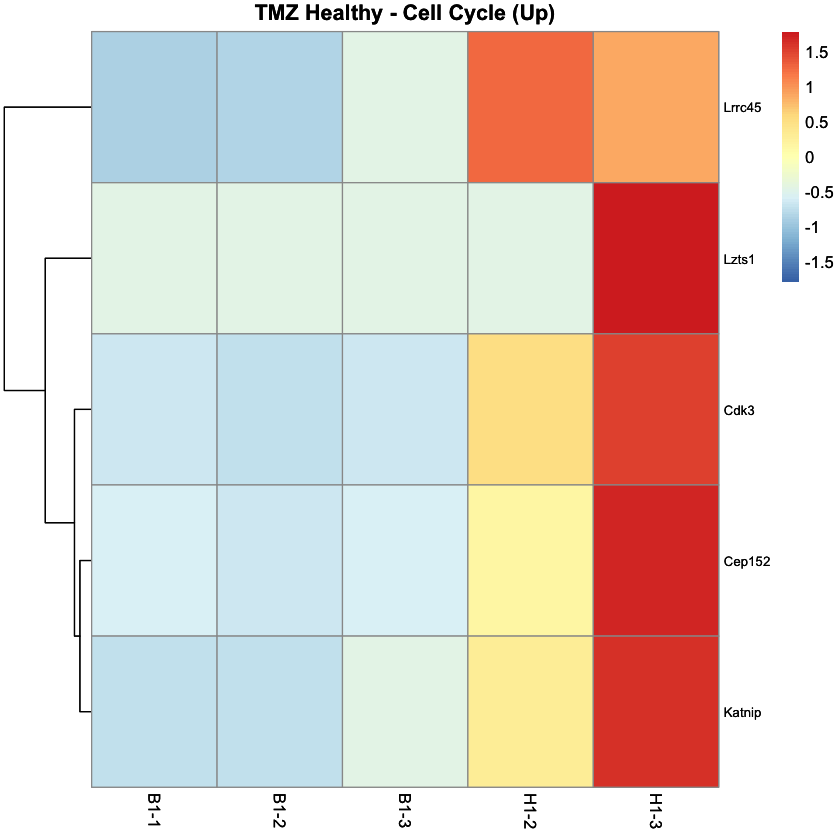

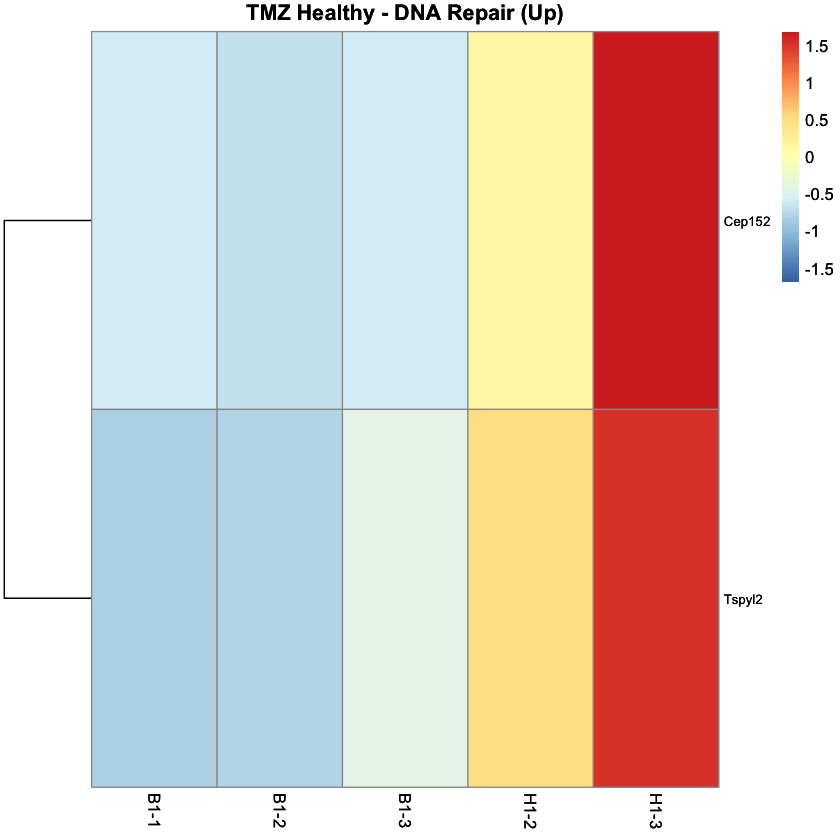

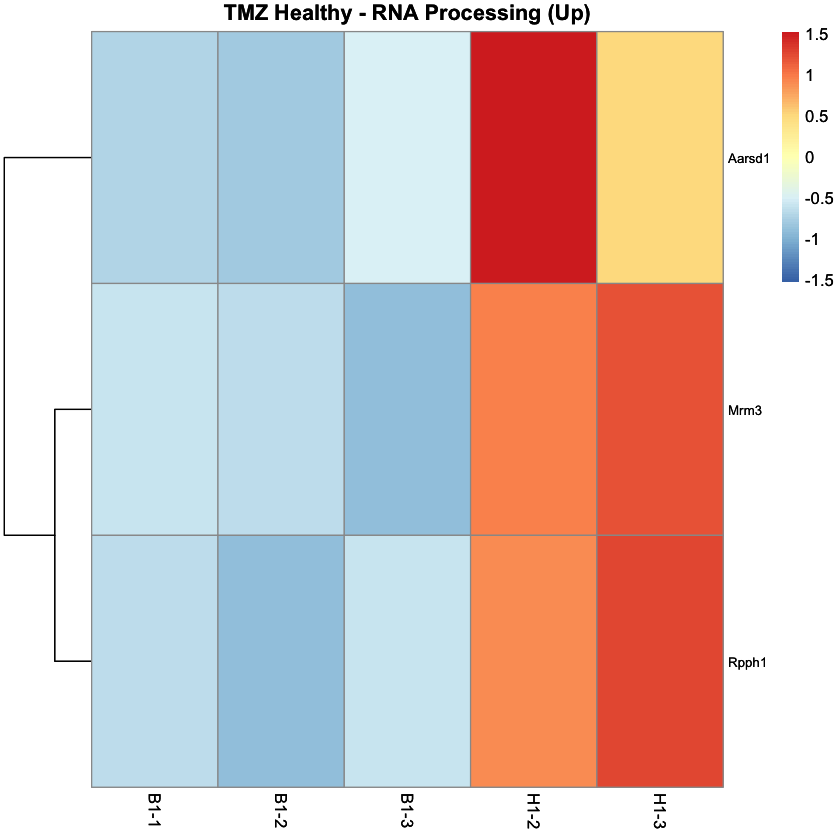

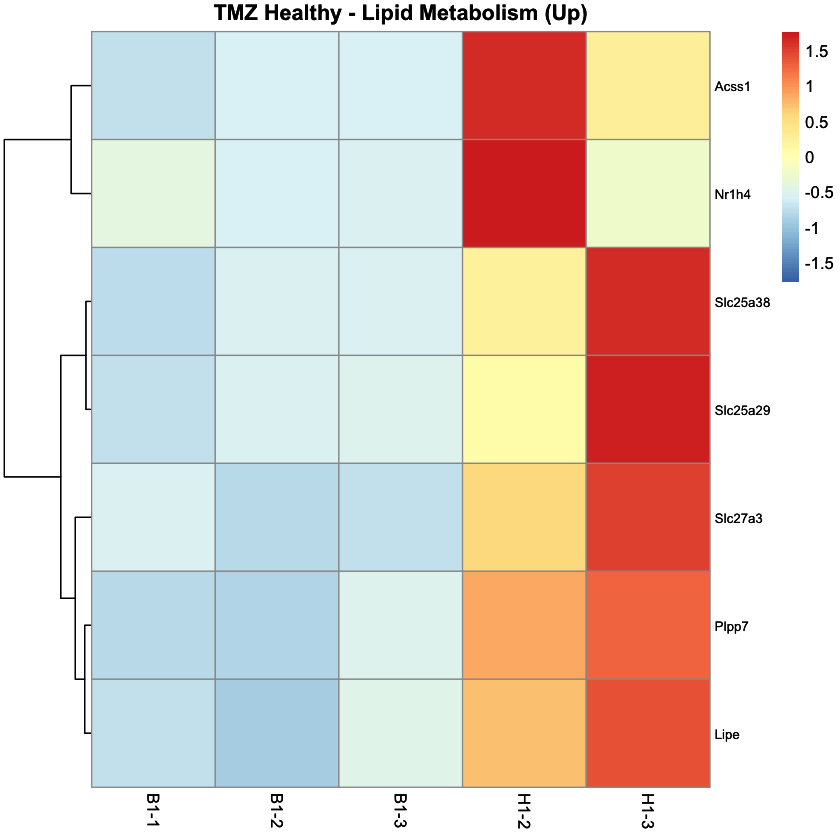

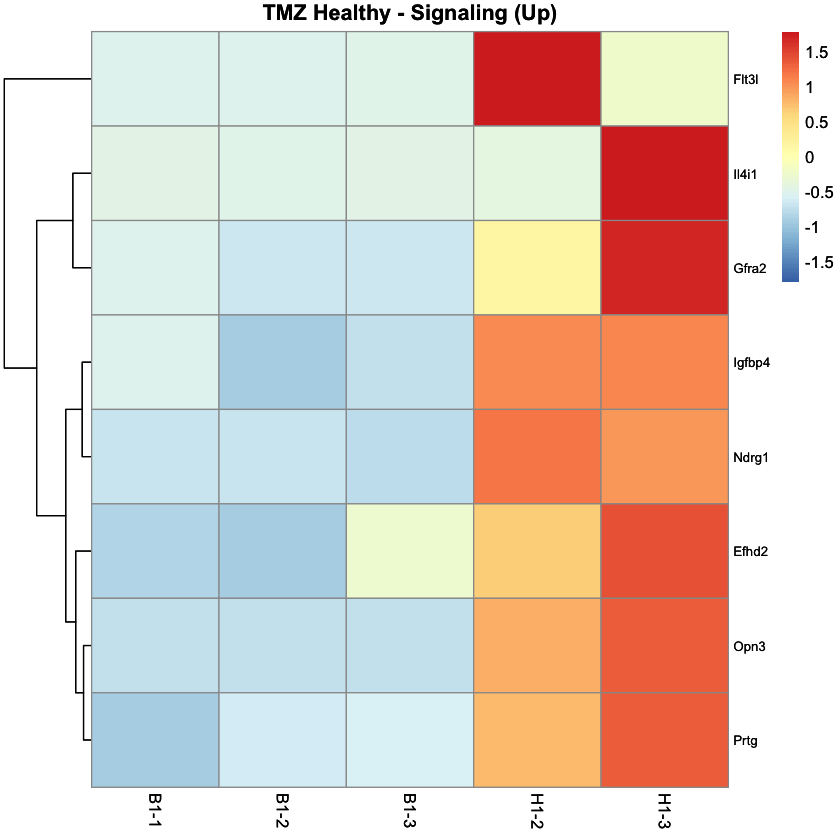

...

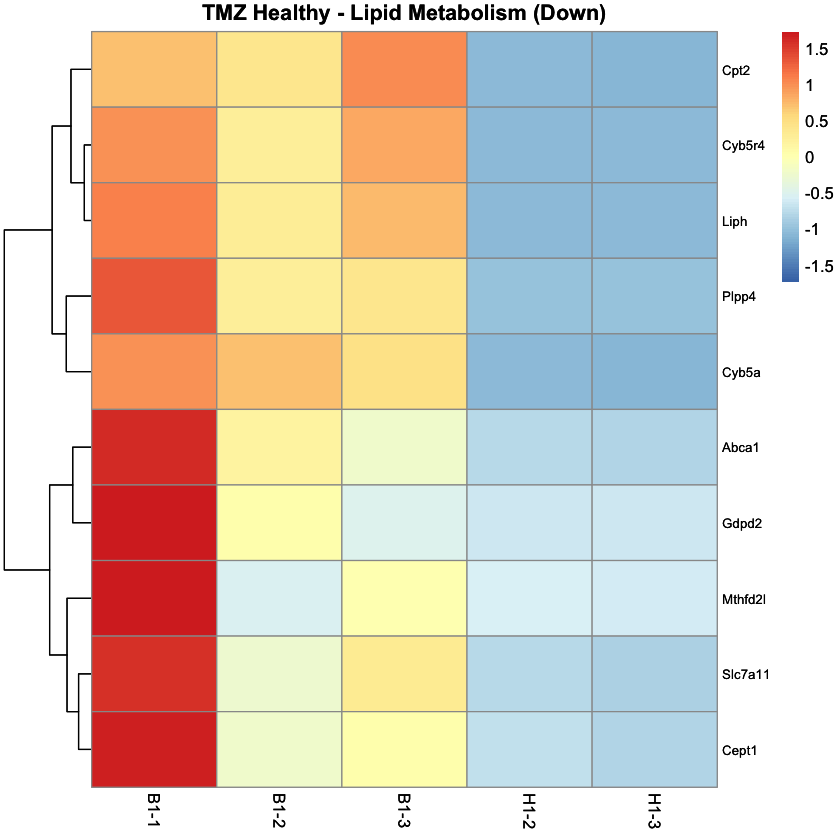

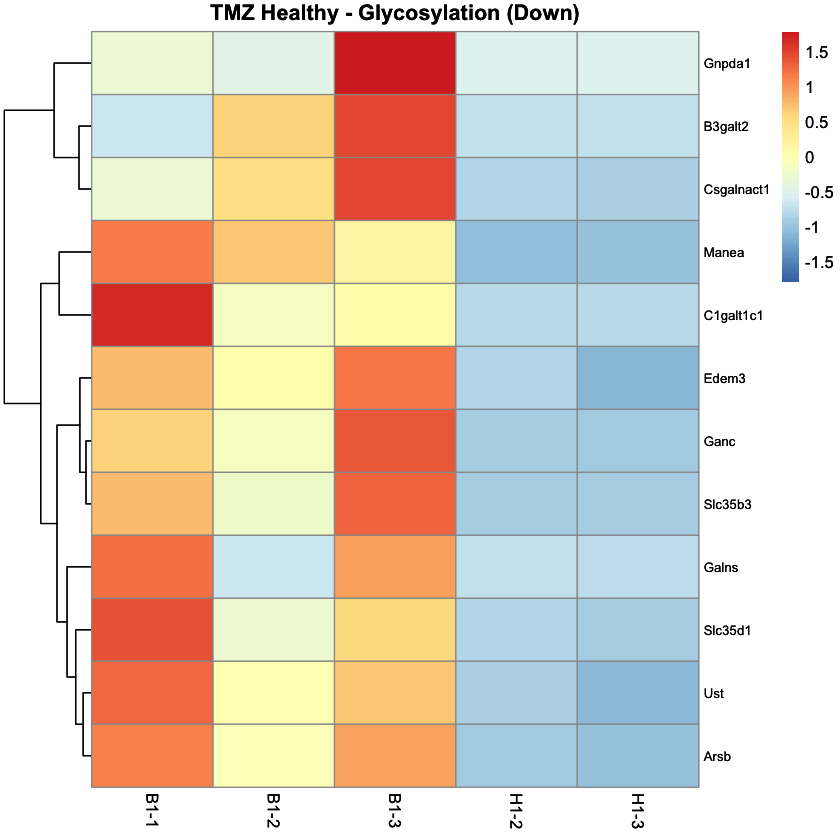

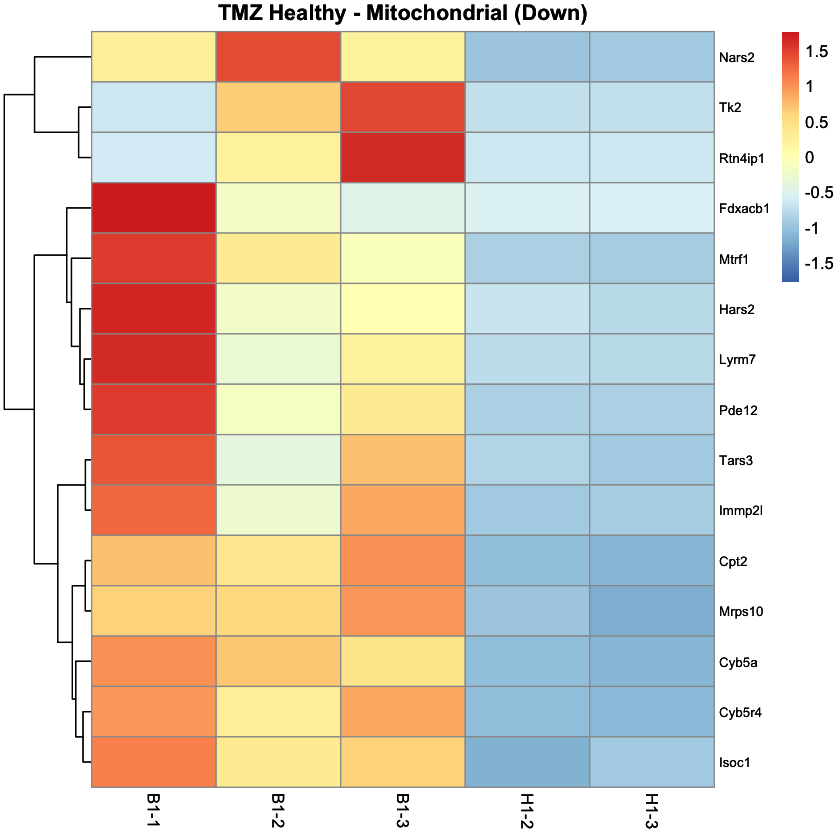

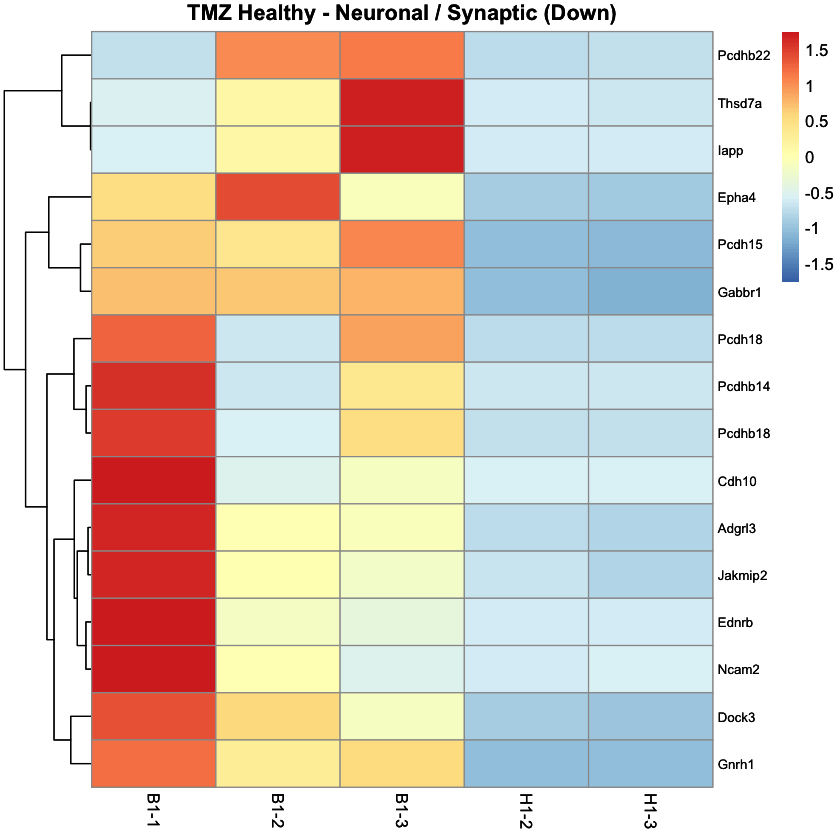

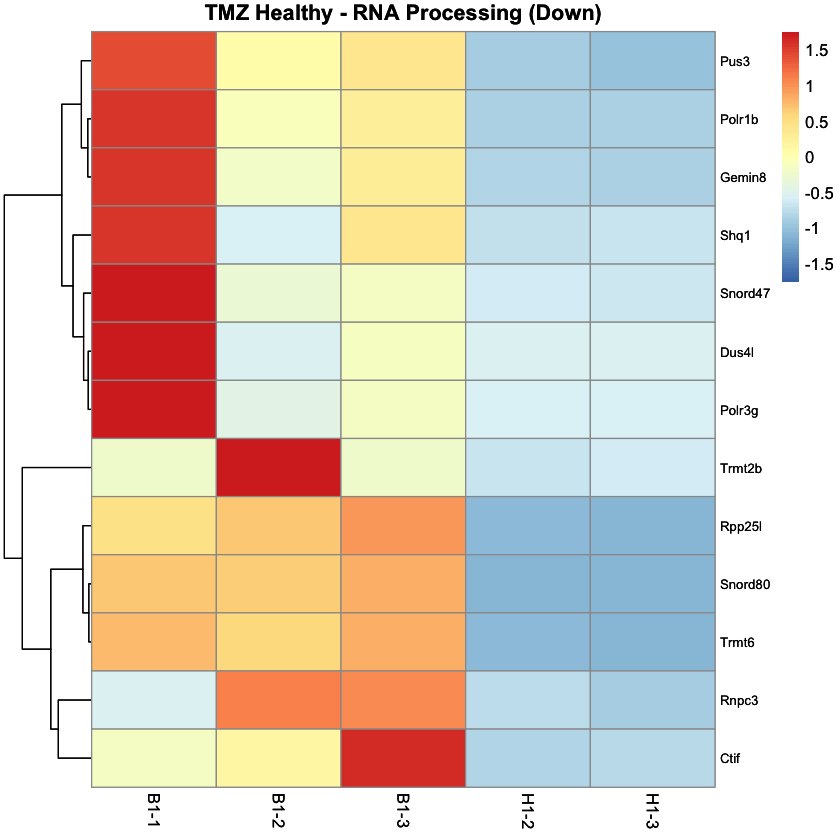

In [62]:
plot_pathway_heatmap <- function(genes, res, df, title) {
  subset <- res[rownames(res) %in% genes, ]
  df_plot <- df[rownames(subset), order(colnames(df))]
  df_plot <- df_plot[rowSums(df_plot) > 0, ]
  if (nrow(df_plot) == 0) {
    cat("No genes found for:", title, "\n")
    return(NULL)
  }
  do_cluster <- nrow(df_plot) >= 2
  print(pheatmap(df_plot, scale = "row", cluster_cols = FALSE,
                 cluster_rows = do_cluster, show_rownames = TRUE,
                 fontsize_row = 8, main = title))
}

plot_pathway_heatmap(tmz_up_cell_cycle, res_tmz, de_out_tmz$df,
                     "TMZ Healthy - Cell Cycle (Up)")

plot_pathway_heatmap(tmz_up_dna_repair, res_tmz, de_out_tmz$df,
                     "TMZ Healthy - DNA Repair (Up)")

plot_pathway_heatmap(tmz_up_rna_processing, res_tmz, de_out_tmz$df,
                     "TMZ Healthy - RNA Processing (Up)")

plot_pathway_heatmap(tmz_up_lipid_metabolism, res_tmz, de_out_tmz$df,
                     "TMZ Healthy - Lipid Metabolism (Up)")

plot_pathway_heatmap(tmz_up_signaling, res_tmz, de_out_tmz$df,
                     "TMZ Healthy - Signaling (Up)")

plot_pathway_heatmap(tmz_up_transcription, res_tmz, de_out_tmz$df,
                     "TMZ Healthy - Transcription (Up)")

plot_pathway_heatmap(tmz_up_vesicle_trafficking, res_tmz, de_out_tmz$df,
                     "TMZ Healthy - Vesicle Trafficking (Up)")

plot_pathway_heatmap(tmz_up_cytoskeleton, res_tmz, de_out_tmz$df,
                     "TMZ Healthy - Cytoskeleton (Up)")

plot_pathway_heatmap(tmz_up_extracellular_matrix, res_tmz, de_out_tmz$df,
                     "TMZ Healthy - Extracellular Matrix (Up)")

plot_pathway_heatmap(tmz_up_mitochondrial, res_tmz, de_out_tmz$df,
                     "TMZ Healthy - Mitochondrial (Up)")

plot_pathway_heatmap(tmz_dn_dna_repair_replication, res_tmz, de_out_tmz$df,
                     "TMZ Healthy - DNA Repair / Replication (Down)")

plot_pathway_heatmap(tmz_dn_cell_cycle, res_tmz, de_out_tmz$df,
                     "TMZ Healthy - Cell Cycle (Down)")

plot_pathway_heatmap(tmz_dn_apoptosis, res_tmz, de_out_tmz$df,
                     "TMZ Healthy - Apoptosis (Down)")

plot_pathway_heatmap(tmz_dn_transcription_chromatin, res_tmz, de_out_tmz$df,
                     "TMZ Healthy - Transcription / Chromatin (Down)")

plot_pathway_heatmap(tmz_dn_signaling, res_tmz, de_out_tmz$df,
                     "TMZ Healthy - Signaling (Down)")

plot_pathway_heatmap(tmz_dn_ubiquitin_proteasome, res_tmz, de_out_tmz$df,
                     "TMZ Healthy - Ubiquitin / Proteasome (Down)")

plot_pathway_heatmap(tmz_dn_lipid_metabolism, res_tmz, de_out_tmz$df,
                     "TMZ Healthy - Lipid Metabolism (Down)")

plot_pathway_heatmap(tmz_dn_glycosylation, res_tmz, de_out_tmz$df,
                     "TMZ Healthy - Glycosylation (Down)")

plot_pathway_heatmap(tmz_dn_mitochondrial, res_tmz, de_out_tmz$df,
                     "TMZ Healthy - Mitochondrial (Down)")

plot_pathway_heatmap(tmz_dn_neuronal_synaptic, res_tmz, de_out_tmz$df,
                     "TMZ Healthy - Neuronal / Synaptic (Down)")

plot_pathway_heatmap(tmz_dn_rna_processing, res_tmz, de_out_tmz$df,
                     "TMZ Healthy - RNA Processing (Down)")

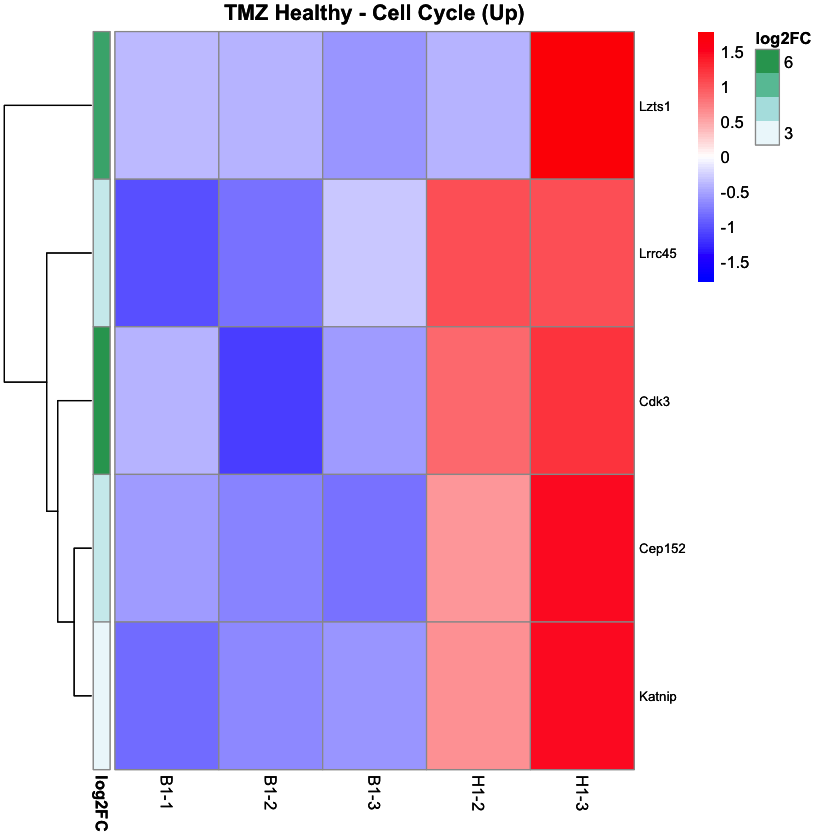

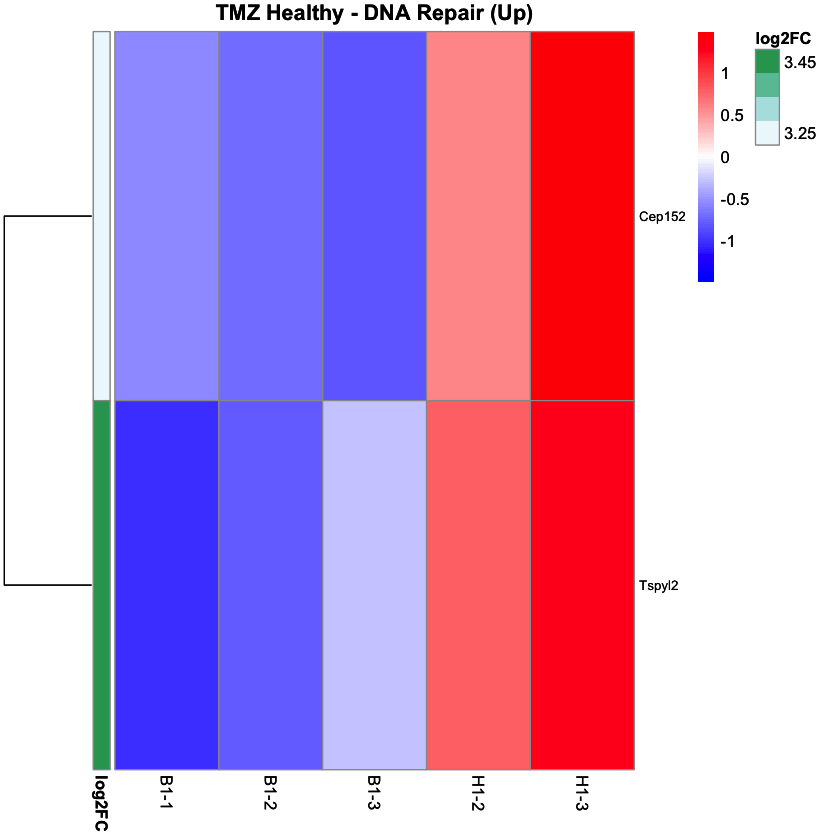

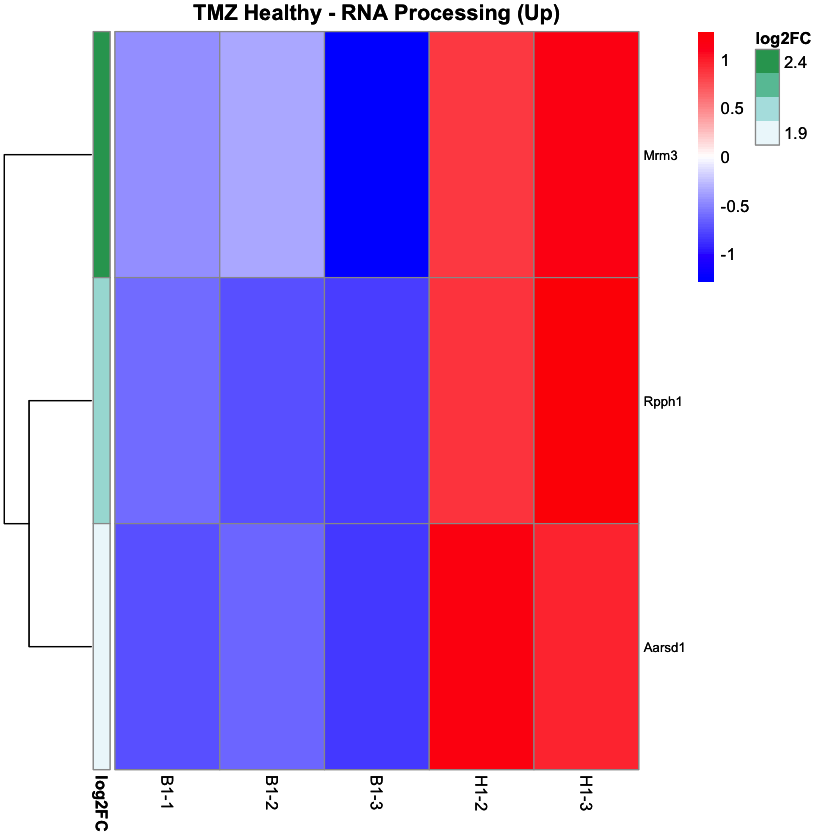

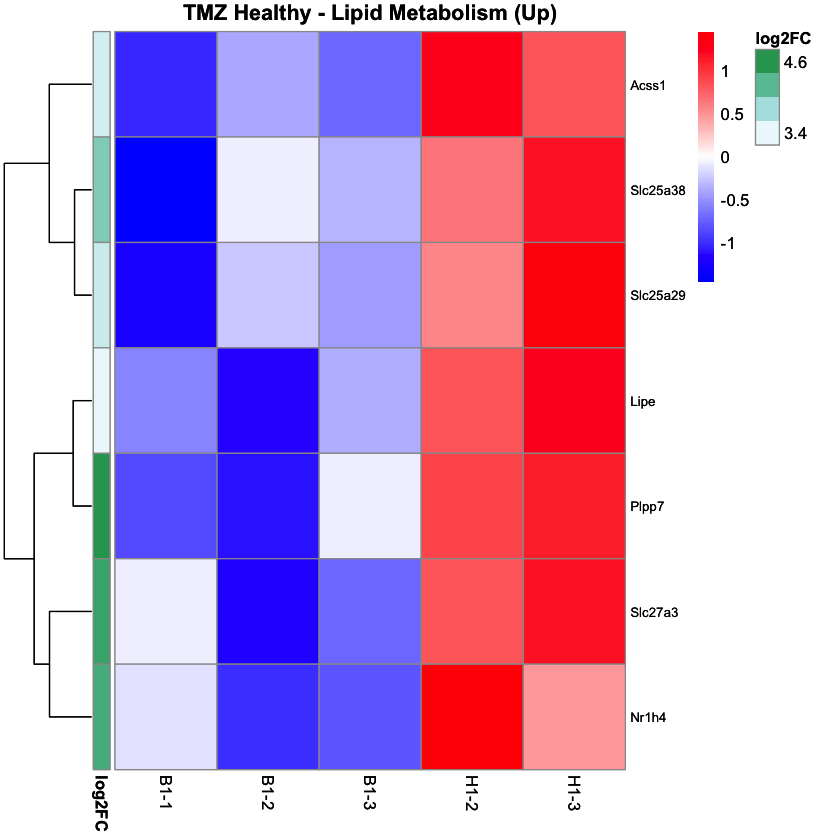

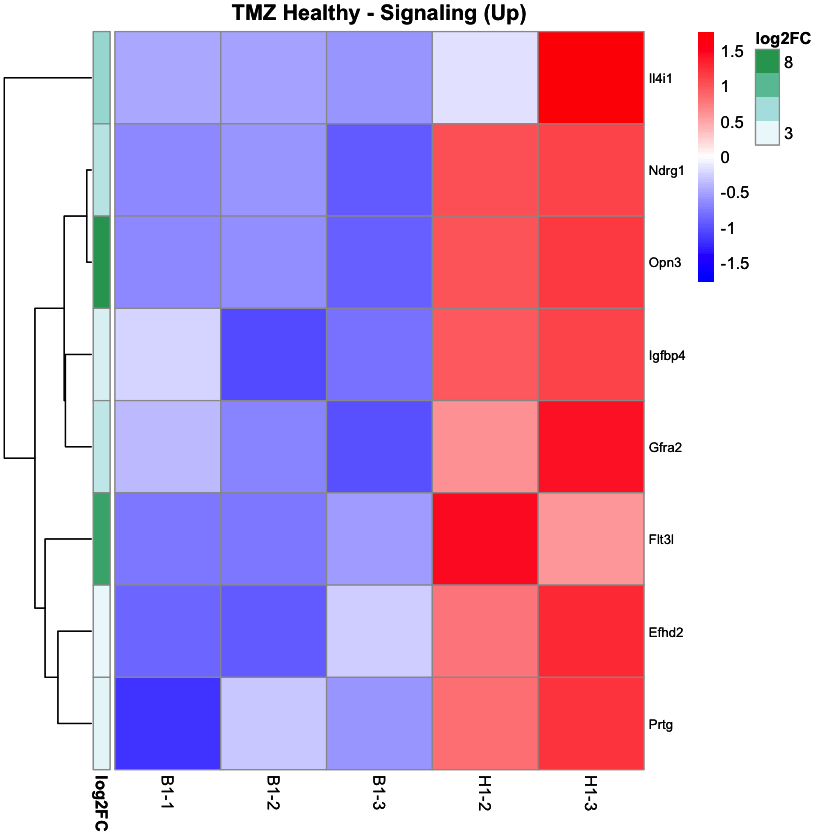

...

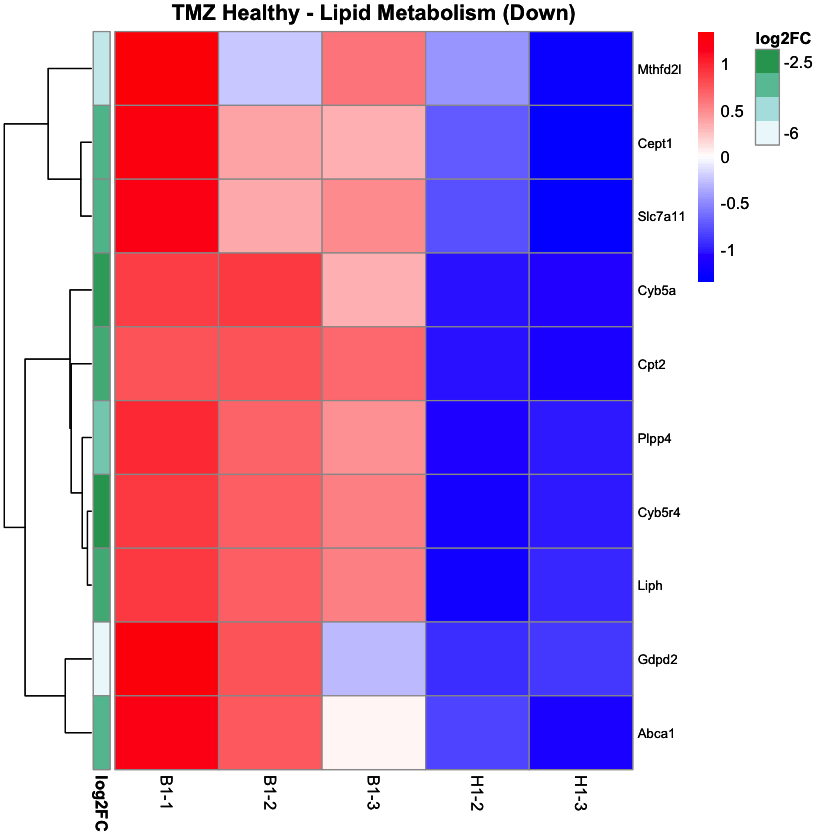

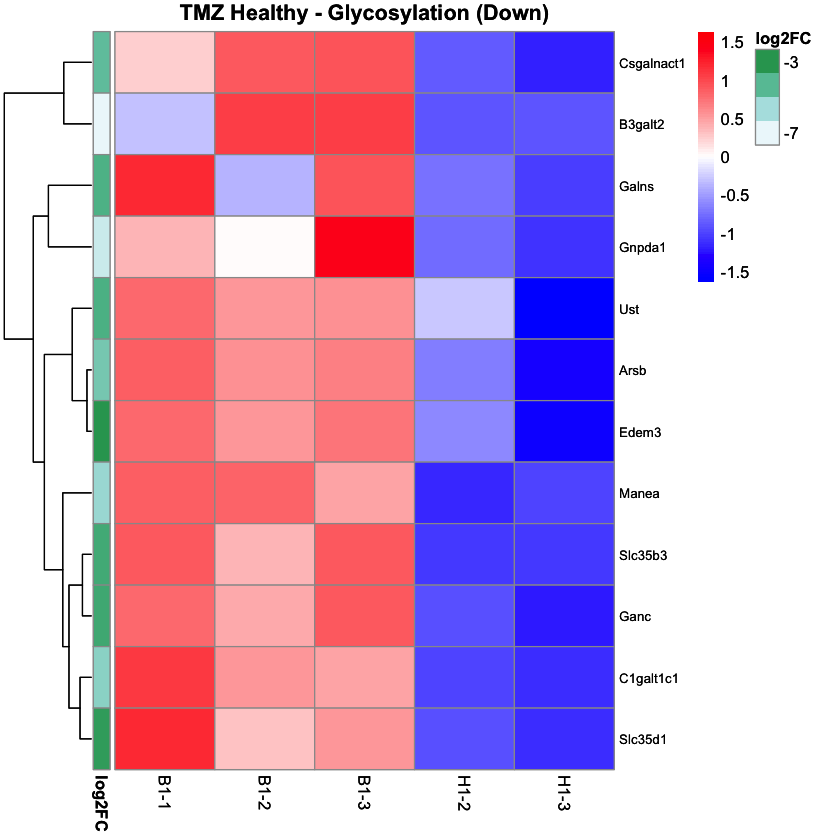

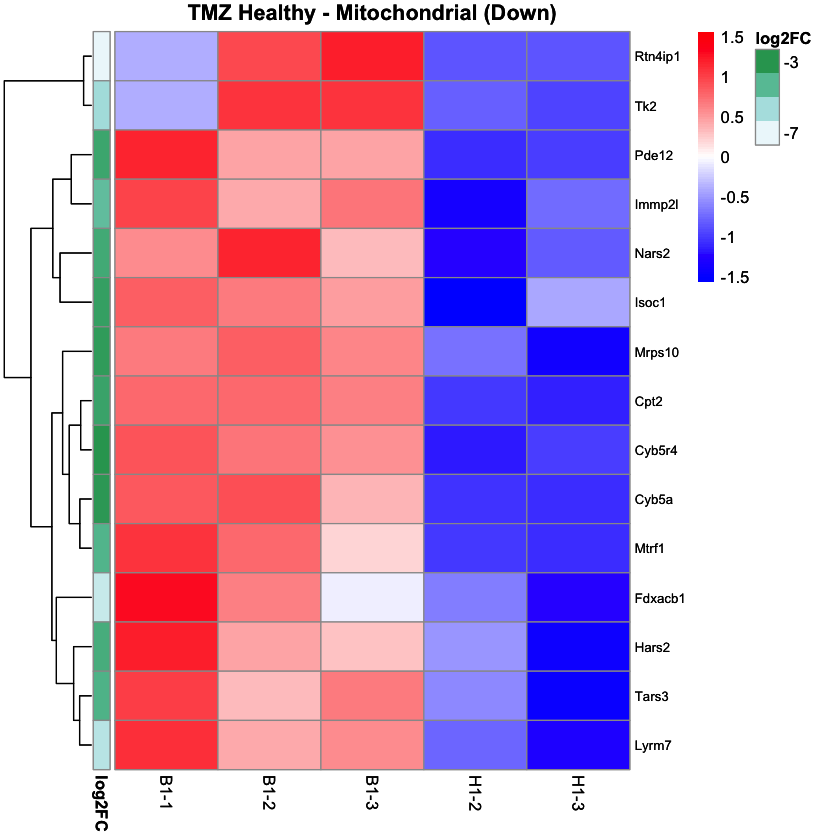

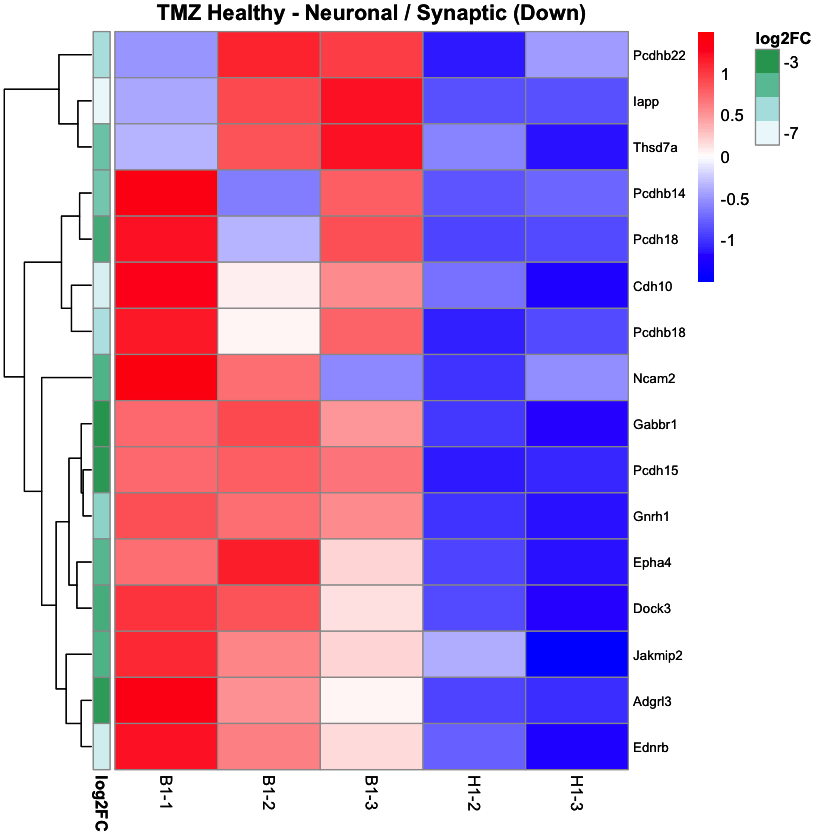

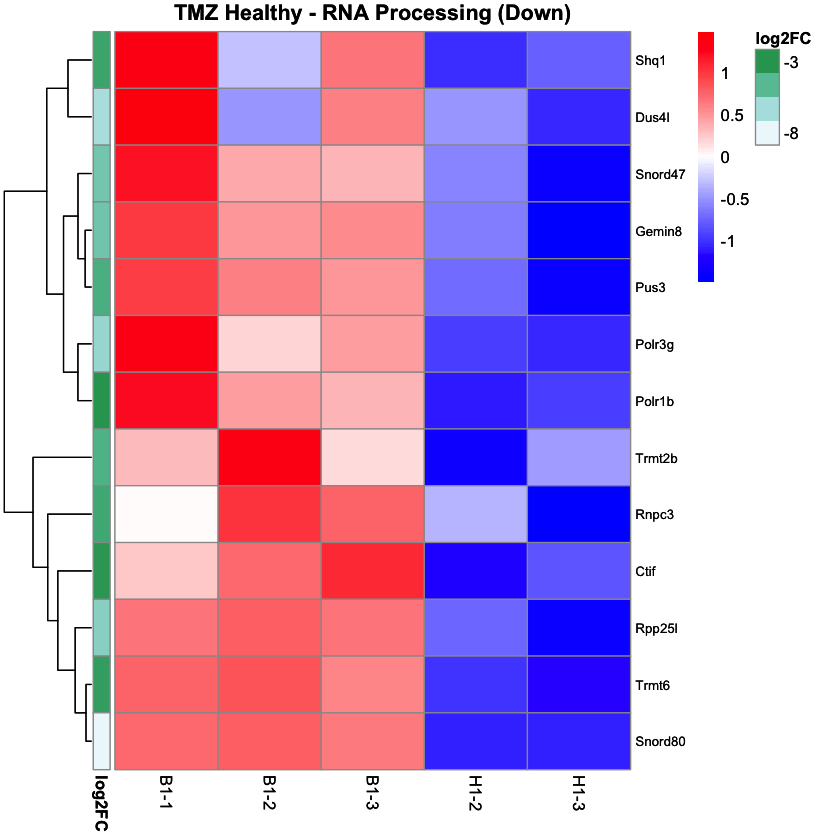

In [63]:
norm_counts_tmz <- DESeq2::counts(de_out_tmz$dds, normalized = TRUE)

plot_pathway_heatmap_lfc <- function(genes, norm_counts, res, title) {
  genes_found <- genes[genes %in% rownames(norm_counts)]
  
  if (length(genes_found) == 0) {
    cat("No genes found for:", title, "\n")
    return(NULL)
  }
  
  df_plot <- log2(norm_counts[genes_found, , drop = FALSE] + 1)
  df_plot <- as.matrix(df_plot)
  df_plot <- df_plot[, order(colnames(df_plot)), drop = FALSE]
  df_plot <- df_plot[rowSums(df_plot) > 0, , drop = FALSE]
  
  if (nrow(df_plot) == 0) {
    cat("No expressed genes for:", title, "\n")
    return(NULL)
  }
  
  lfc_vals <- round(as.data.frame(res[rownames(df_plot), "log2FoldChange"]), 2)
  rownames(lfc_vals) <- rownames(df_plot)
  colnames(lfc_vals) <- "log2FC"
  
  do_cluster <- nrow(df_plot) >= 2
  
  print(pheatmap(df_plot, cluster_cols = FALSE, cluster_rows = do_cluster,
                 show_rownames = TRUE, fontsize_row = 8, main = title,
                 scale = "row",
                 annotation_row = lfc_vals,
                 color = colorRampPalette(c("blue", "white", "red"))(100)))
}

plot_pathway_heatmap_lfc(tmz_up_cell_cycle, norm_counts_tmz, res_tmz,
                          "TMZ Healthy - Cell Cycle (Up)")

plot_pathway_heatmap_lfc(tmz_up_dna_repair, norm_counts_tmz, res_tmz,
                          "TMZ Healthy - DNA Repair (Up)")

plot_pathway_heatmap_lfc(tmz_up_rna_processing, norm_counts_tmz, res_tmz,
                          "TMZ Healthy - RNA Processing (Up)")

plot_pathway_heatmap_lfc(tmz_up_lipid_metabolism, norm_counts_tmz, res_tmz,
                          "TMZ Healthy - Lipid Metabolism (Up)")

plot_pathway_heatmap_lfc(tmz_up_signaling, norm_counts_tmz, res_tmz,
                          "TMZ Healthy - Signaling (Up)")

plot_pathway_heatmap_lfc(tmz_up_transcription, norm_counts_tmz, res_tmz,
                          "TMZ Healthy - Transcription (Up)")

plot_pathway_heatmap_lfc(tmz_up_vesicle_trafficking, norm_counts_tmz, res_tmz,
                          "TMZ Healthy - Vesicle Trafficking (Up)")

plot_pathway_heatmap_lfc(tmz_up_cytoskeleton, norm_counts_tmz, res_tmz,
                          "TMZ Healthy - Cytoskeleton (Up)")

plot_pathway_heatmap_lfc(tmz_up_extracellular_matrix, norm_counts_tmz, res_tmz,
                          "TMZ Healthy - Extracellular Matrix (Up)")

plot_pathway_heatmap_lfc(tmz_up_mitochondrial, norm_counts_tmz, res_tmz,
                          "TMZ Healthy - Mitochondrial (Up)")

plot_pathway_heatmap_lfc(tmz_dn_dna_repair_replication, norm_counts_tmz, res_tmz,
                          "TMZ Healthy - DNA Repair / Replication (Down)")

plot_pathway_heatmap_lfc(tmz_dn_cell_cycle, norm_counts_tmz, res_tmz,
                          "TMZ Healthy - Cell Cycle (Down)")

plot_pathway_heatmap_lfc(tmz_dn_apoptosis, norm_counts_tmz, res_tmz,
                          "TMZ Healthy - Apoptosis (Down)")

plot_pathway_heatmap_lfc(tmz_dn_transcription_chromatin, norm_counts_tmz, res_tmz,
                          "TMZ Healthy - Transcription / Chromatin (Down)")

plot_pathway_heatmap_lfc(tmz_dn_signaling, norm_counts_tmz, res_tmz,
                          "TMZ Healthy - Signaling (Down)")

plot_pathway_heatmap_lfc(tmz_dn_ubiquitin_proteasome, norm_counts_tmz, res_tmz,
                          "TMZ Healthy - Ubiquitin / Proteasome (Down)")

plot_pathway_heatmap_lfc(tmz_dn_lipid_metabolism, norm_counts_tmz, res_tmz,
                          "TMZ Healthy - Lipid Metabolism (Down)")

plot_pathway_heatmap_lfc(tmz_dn_glycosylation, norm_counts_tmz, res_tmz,
                          "TMZ Healthy - Glycosylation (Down)")

plot_pathway_heatmap_lfc(tmz_dn_mitochondrial, norm_counts_tmz, res_tmz,
                          "TMZ Healthy - Mitochondrial (Down)")

plot_pathway_heatmap_lfc(tmz_dn_neuronal_synaptic, norm_counts_tmz, res_tmz,
                          "TMZ Healthy - Neuronal / Synaptic (Down)")

plot_pathway_heatmap_lfc(tmz_dn_rna_processing, norm_counts_tmz, res_tmz,
                          "TMZ Healthy - RNA Processing (Down)")

# Glioma Population Pathway Analysis

converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



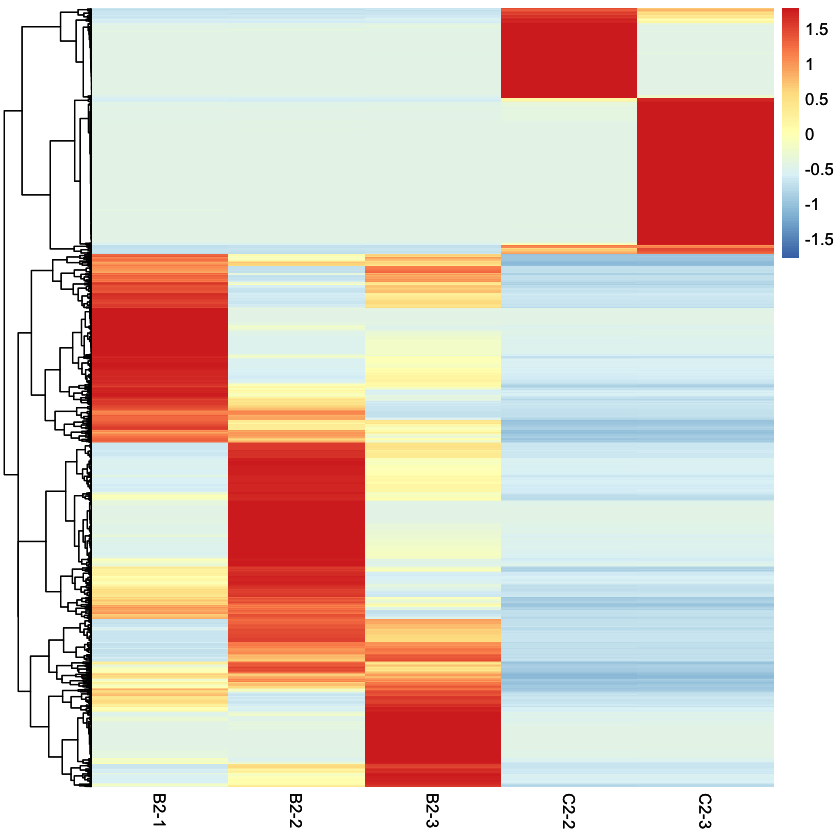

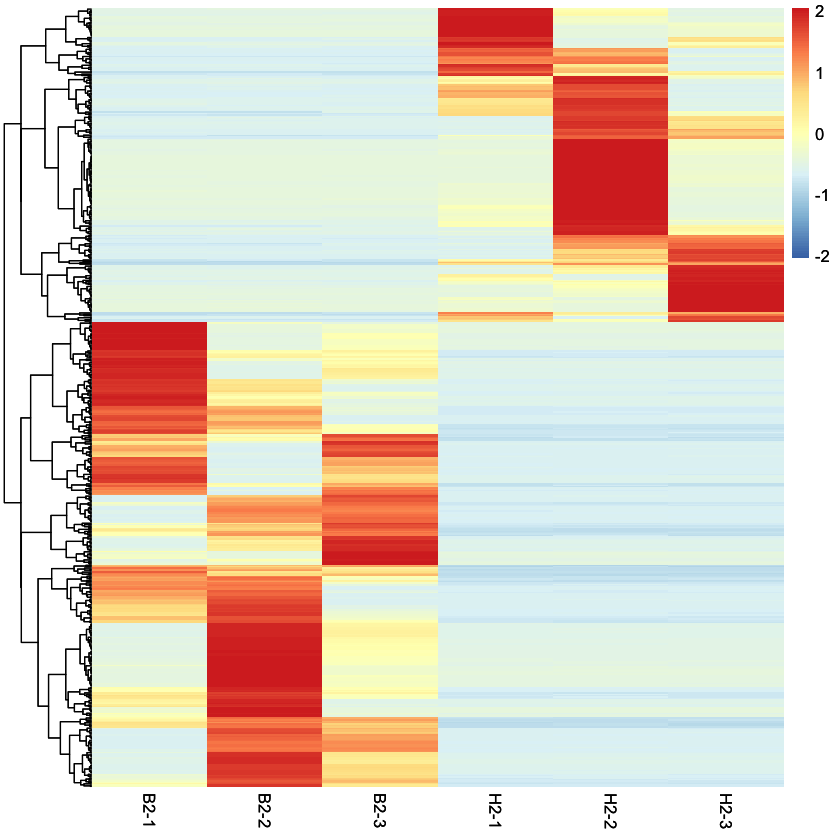

In [64]:
# AUF vs DMSO
de_out_auf <- getDEresults_safe(countsRAW, meta, tissue = "Glioma", treatment = "AUF")
res_auf <- DESeq2::results(de_out_auf$dds)
sig_genes_auf <- res_auf[!is.na(res_auf$padj) & res_auf$padj < 0.05, ]

# TMZ vs DMSO
de_out_tmz <- getDEresults_safe(countsRAW, meta, tissue = "Glioma", treatment = "TMZ")
res_tmz <- DESeq2::results(de_out_tmz$dds)
sig_genes_tmz <- res_tmz[!is.na(res_tmz$padj) & res_tmz$padj < 0.05, ]

# AUF heatmap
df_plot_auf <- de_out_auf$df[rownames(sig_genes_auf), order(colnames(de_out_auf$df))]
df_plot_auf <- df_plot_auf[apply(df_plot_auf, 1, function(x) all(is.finite(x))), ]
df_plot_auf <- df_plot_auf[apply(df_plot_auf, 1, var) > 0, ]
print(pheatmap(df_plot_auf, scale = "row", cluster_cols = FALSE,
               cluster_rows = TRUE, show_rownames = FALSE))

# TMZ heatmap
df_plot_tmz <- de_out_tmz$df[rownames(sig_genes_tmz), order(colnames(de_out_tmz$df))]
df_plot_tmz <- df_plot_tmz[apply(df_plot_tmz, 1, function(x) all(is.finite(x))), ]
df_plot_tmz <- df_plot_tmz[apply(df_plot_tmz, 1, var) > 0, ]
print(pheatmap(df_plot_tmz, scale = "row", cluster_cols = FALSE,
               cluster_rows = TRUE, show_rownames = FALSE))

In [65]:
# Up
up_auf <- sig_genes_auf[sig_genes_auf$log2FoldChange > 0, ]
rownames(up_auf[order(up_auf$padj), ])

# Down
down_auf <- sig_genes_auf[sig_genes_auf$log2FoldChange < 0, ]
rownames(down_auf[order(down_auf$padj), ])

[1] "Usp18"         "Fbxl15"        "Fosl1"         "2010016I18Rik"
  [5] "Smim20"        "Lbx2"          "A030001D20Rik" "Gm11769"      
  [9] "Rslcan18"      "Fxn"           "Zcchc12"       "Gm38951"      
 [13] "Gm41077"       "Rhebl1"        "Ipo11-lrrc70"  "Spc25"        
 [17] "Fdxacb1"       "Gm57523"       "Gm40935"       "Gdpd2"        
 [21] "Bcdin3d"       "Gm51484"       "Nmral1"        "Eef1akmt4"    
 [25] "Serp2"         "Mm2pr"         "Gm33106"       "Gm32934"      
 [29] "Gm26787"       "Arl11"         "Pierce2"       "1700010B08Rik"
 [33] "Zfp472"        "Gm36809"       "Gm39337"       "Gm46004"      
 [37] "Has2os"        "Zkscan14"      "Fjx1"          "Gm39717"      
 [41] "4930542D17Rik" "Gm52601"       "LOC118567864"  "LOC115487221" 
 [45] "Gm30074"       "Gm54019"       "Rasl11b"       "Gm8273"       
 [49] "Gm46252"       "Gm39526"       "Scnm1"         "Ifit3"        
 [53] "Camk2n2"       "Prss36"        "Ptcd2"         "Gpank1"       
 [57] "Nudt14"        "1500002C15Rik" "Apool"         "Spns1"        
 [61] "Mettl15"       "Ifit3b"        "Pnp2"          "Fbxo28"       
 [65] "Ccdc181"       "Cd93"          "Prcp"          "G730013B05Rik"
 [69] "Ssu72"         "Stambp"        "Gm38499"       "Csta2"        
 [73] "Sugct"         "Tfpt"          "Gm33989"       "Rwdd2a"       
 [77] "Ppp1r14a"      "Hps1"          "Dtd2"          "Mrps6"        
 [81] "Amdhd2"        "Zfp825"        "Gm33302"       "Cyth2"        
 [85] "Zfp64"         "Fut10"         "Tspan2"        "Firrm"        
 [89] "Aurka"         "Ipo11"         "Btbd9"         "Kat2a"        
 [93] "Tamm41"        "Gramd2b"       "Tlcd1"         "Rab35"        
 [97] "Gm20522"       "Rgs19"         "Afg3l2"        "Zfp280b"      
[101] "Osr2"          "Il15ra"        "Hsd17b8"       "Ints11"       
[105] "Tifa"          "LOC118568635"  "Rom1"          "Nat2"         
[109] "Coa4"          "Gm46093"       "Layn"          "Plvap"        
[113] "Rita1"         "Slc22a23"      "Cttnbp2nl"     "Fbln5"        
[117] "Gbp9"          "Snx7"          "Gm11517"       "B9d1"         
[121] "Gm39442"       "Thoc6"         "Pdlim1"        "B4gat1"       
[125] "Mgme1"         "Gm39099"       "Arhgdig"       "Mogs"         
[129] "Smarcal1"      "Cda"           "Rdm1"          "A730008H23Rik"
[133] "Pex10"         "Nxt2"          "Golm1"         "Jrkl"         
[137] "Zfp57"         "Vcf2"          "Arf2"          "Psph"         
[141] "Crcp"          "Tmie"          "Mospd1"        "Ptn"          
[145] "Rfc3"          "Gm40855"       "Slc30a7"       "Naa60"        
[149] "Dnajc17"       "Zfp423"        "Syce2"         "Gm34878"      
[153] "Slc38a1"       "Nmnat1"        "Egfl7"         "Map2"         
[157] "Pla2g1b"       "Ptpn23"        "Nhlrc3"        "Rcor2"        
[161] "Snrpn"         "H4c8"          "Pkp2"          "G0s2"         
[165] "Gm52702"       "Anapc7"        "Fam174c"       "Phyhipl"      
[169] "Slc38a9"       "Pstpip2"       "Camk1"         "Mrgbp"        
[173] "Spout1"        "Acvr2b"        "Polr3gl"       "Pgap4"        
[177] "Stpg1"         "Tbc1d5"        "Ctnnbl1"       "Gsto2"        
[181] "0610009L18Rik" "Enah"          "Dus2"          "Cep135"       
[185] "Echdc3"        "Gm30820"       "Cabp2"         "Abcf3"        
[189] "Pir"           "Btg2"          "Cep72"         "Ncbp2"        
[193] "Gm51877"       "Gm53577"       "Lurap1"        "Gm15545"      
[197] "Myg1"          "Gm53845"       "Gm38469"       "Rilpl2"       
[201] "Bcas1"         "Mmp15"         "Clip3"         "Lsm12"        
[205] "Gm40780"       "Hhat"          "Gm11110"       "Fbxw17"       
[209] "Hacl1"         "Ighmbp2"       "2410012E07Rik" "Ankrd29"      
[213] "Ncdn"          "D030055H07Rik" "Snurf"         "Gm17484"      
[217] "Sp140"         "Nudt2"         "Rexo4"         "Trpm4"        
[221] "Ppp2r2d"       "Gmnn"          "Srbd1"         "Herc6"        
[225] "Vac14"         "Utp18"         "Pdzd11"        "Gm30364"      
[229] "Ubac2

[1] "Nhej1"         "Gm40761"       "Gm31223"       "Gm38557"      
   [5] "Gm15471"       "Gm21814"       "Gm34016"       "Gm12530"      
   [9] "Gm16523"       "Chn1os3"       "Gm2560"        "4632427E13Rik"
  [13] "Gm51797"       "Gm52185"       "D330050I16Rik" "Gm27510"      
  [17] "G630016G05Rik" "Ovca2"         "Cfp"           "Snord14d"     
  [21] "Cyp2u1"        "Gm36298"       "Tmsb15b1"      "Gm24507"      
  [25] "Gm8094"        "Snord14c"      "Gm25862"       "Gm25395"      
  [29] "1700071M16Rik" "Gm23182"       "Ankrd53"       "Gm22301"      
  [33] "EU599041"      "Gm41917"       "Gm24494"       "Ssxb5"        
  [37] "Zfp932"        "Zfp972"        "Gm49566"       "Lrrc57"       
  [41] "Pigw"          "Marchf11"      "Zfp566"        "Gm25791"      
  [45] "Snora41"       "Gm47112"       "Snord99"       "Gm24924"      
  [49] "Gm23547"       "E130304I02Rik" "Gm16596"       "Snora81"      
  [53] "B230217C12Rik" "Gm38516"       "Gm19439"       "8030443G20Rik"
  [57] "Gm15446"       "Gm24523"       "Tmsb15l"       "Gm51739"      
  [61] "Cox6a2"        "Ufsp1"         "Gm39547"       "Plekhf1"      
  [65] "E130102H24Rik" "Mettl24"       "Coq6"          "Zfp961"       
  [69] "Dubr"          "2210408F21Rik" "Snord14e"      "Gm32092"      
  [73] "Pdcd2l"        "Zfp655"        "Zfp180"        "Gtf2h1"       
  [77] "Commd5"        "Herc4"         "Jtb"           "Guf1"         
  [81] "Trafd1"        "Apc"           "Fam135a"       "Haus7"        
  [85] "Pigb"          "Nsun6"         "Galnt1"        "Smad5"        
  [89] "Snx14"         "Bloc1s6"       "Zfp445"        "Ern1"         
  [93] "C1galt1c1"     "Dcp1a"         "Anln"          "Trim26"       
  [97] "Zscan12"       "Sfswap"        "Sco2"          "Rdh11"        
 [101] "Gpcpd1"        "2010001A14Rik" "Iws1"          "Ostm1"        
 [105] "Zfp410"        "Col9a3"        "Nudcd3"        "Eloa"         
 [109] "Cenpc1"        "Ccdc127"       "Bloc1s4"       "Slc66a3"      
 [113] "Lsm10"         "Zfp12"         "Cdk13"         "Cep57"        
 [117] "Rassf3"        "Gdap2"         "Car6"          "Adgra3"       
 [121] "Gm44264"       "Crnkl1"        "Ccdc117"       "Ankrd11"      
 [125] "Parl"          "Cd82"          "Nkx2-2"        "Zfp87"        
 [129] "Atosa"         "Hltf"          "Pop7"          "Cog2"         
 [133] "Zfp30"         "Trp53"         "Nedd1"         "Chd8"         
 [137] "Bora"          "Nsun3"         "Gm39467"       "Twsg1"        
 [141] "Sdr39u1"       "Agk"           "Tmem9"         "Pkp4"         
 [145] "Lnpk"          "Hps3"          "Camk2g"        "Rnf167"       
 [149] "Alg10b"        "Tmem106b"      "Lemd2"         "Camsap2"      
 [153] "Stau1"         "Suv39h1"       "Ltbp4"         "Ccdc66"       
 [157] "Lrrc1"         "Rnf149"        "Zfp260"        "Rbmx2"        
 [161] "Ndufaf4"       "Fkbp15"        "Cmtm6"         "Pcgf3"        
 [165] "Mdm4"          "Paqr6"         "Mir17hg"       "Cbfa2t2"      
 [169] "Myc"           "Kctd18"        "2700062C07Rik" "Lrp6"         
 [173] "Ppme1"         "Siae"          "Slc49a4"       "Sfxn1"        
 [177] "Cerkl"         "Trmt13"        "Lysmd3"        "2610316D01Rik"
 [181] "Gcc2"          "Tle1"          "Suclg2"        "Entpd4"       
 [185] "Gbf1"          "9430069I07Rik" "Fbxl12"        "Kdm1a"        
 [189] "Klc3"          "Lrrc39"        "Gm53399"       "Slc25a37"     
 [193] "Ten1"          "Prep"          "Ank"           "Nt5dc2"       
 [197] "4930503L19Rik" "Slc35e2"       "Cpeb3"         "Gm54289"      
 [201] "Ddx41"         "Ccnj"          "Epb41l3"       "Gm53700"      
 [205] "Marcksl1"      "AI662270"      "Pank2"         "Enoph1"       
 [209] "Gm16973"       "Matn2"         "Kdm5a"         "Mtx1"         
 [213] "Tedc2"         "Fam32a"        "Rgs14"         "Lrch3"        
 [217] "Gm53331"       "Gm48551"       "Nelfe"         "Lxn"          
 [221] "Zfp160"        "Setd7"         "Rasgrf1"       "Xiap"         
 [225] "Phlpp2"        "Rsr

In [66]:
# Up
up_tmz <- sig_genes_tmz[sig_genes_tmz$log2FoldChange > 0, ]
rownames(up_tmz[order(up_tmz$padj), ])

# Down
down_tmz <- sig_genes_tmz[sig_genes_tmz$log2FoldChange < 0, ]
rownames(down_tmz[order(down_tmz$padj), ])

[1] "Tpx2"          "Bbs7"          "Crcp"          "Mogs"         
  [5] "Gm53356"       "Slc17a5"       "Pdzd11"        "Cox7a1"       
  [9] "Rhox5"         "Xpo5"          "Ankrd54"       "Afg3l2"       
 [13] "Rnf183"        "Yae1d1"        "Zfp322a"       "Spc25"        
 [17] "Cd99l2"        "Abcd1"         "Tyw1"          "Ipo11"        
 [21] "Zkscan14"      "Gm33938"       "Osbpl1a"       "Pcnx3"        
 [25] "Zfp81"         "Gm50617"       "Mllt3"         "Hoxc6"        
 [29] "Rep15"         "Foxc2"         "Gm9856"        "Dnase1l1"     
 [33] "Abhd14a"       "Dnm3os"        "Pilra"         "Isg20l2"      
 [37] "Gmnn"          "Mns1"          "Mrps6"         "Endod1"       
 [41] "Prrg2"         "Gm57779"       "Rgs19"         "Magohb"       
 [45] "Nubpl"         "A030001D20Rik" "Usp11"         "Mtmr7"        
 [49] "Btbd9"         "Usb1"          "1500002C15Rik" "Gm34607"      
 [53] "Ankrd27"       "Mmp24os1"      "Trak1"         "1110059G10Rik"
 [57] "Kat2a"         "B4gat1"        "Hells"         "Pygb"         
 [61] "Rnf26"         "Nbea"          "Hgh1"          "Sin3a"        
 [65] "Gpd1l"         "Rgs17"         "Ptpn23"        "Lyl1"         
 [69] "Fam193b"       "Foxk1"         "Hps1"          "Tbc1d2b"      
 [73] "Racgap1"       "Fxyd7"         "Rad51ap1"      "Bivm"         
 [77] "Harbi1"        "Snord21"       "Zcwpw1"        "Srd5a3"       
 [81] "Lmnb2"         "Coro2b"        "Adamtsl5"      "Polr3gl"      
 [85] "Zfp58"         "Acaca"         "Ppp3cc"        "Tgfbrap1"     
 [89] "Pusl1"         "Dtd2"          "Pak4"          "Ssu72"        
 [93] "Ptges2"        "Gba2"          "Strada"        "Poglut1"      
 [97] "Herc6"         "Lrp11"         "Tacc2"         "Rab11fip4"    
[101] "Col5a3"        "Qsox1"         "Crmp1"         "Aste1"        
[105] "Zfr2"          "Ankzf1"        "Shroom2"       "Fez2"         
[109] "Rab11fip2"     "Vav2"          "Dync1li2"      "Atpsckmt"     
[113] "Mettl15"       "Pou3f1"        "Nemp1"         "Mmp24"        
[117] "Nsun7"         "Cyth2"         "Gm22753"       "Gm36123"      
[121] "Ints11"        "F630206G17Rik" "Ogfod2"        "Nudt2"        
[125] "Dcaf15"        "Rlig1"         "Galm"          "Fh1"          
[129] "Spns1"         "Lrch1"         "Irak2"         "Zc3h12b"      
[133] "Prss36"        "Akr1b10"       "Gm51700"       "Cep68"        
[137] "Tamm41"        "Brip1"         "Wrap73"        "Atg16l2"      
[141] "Gda"           "Qng1"          "Nol12"         "Tmem167b"     
[145] "Arl15"         "Abcf3"         "Pcdh11x"       "Tex52"        
[149] "Pde12"         "Gm50600"       "Zfp560"        "Atg7"         
[153] "Tex9"          "Rexo4"         "Tesk1"         "Gm45935"      
[157] "Npcd"          "Gm53953"       "Zdhhc23"       "1700040D17Rik"
[161] "Ece1"          "Podnl1"        "Sh3glb2"       "Klf14"        
[165] "Eif2ak2"       "Snora65"       "Ip6k3"         "Ogg1"         
[169] "P3h3"          "Thap4"         "Sobp"          "Cacng4"       
[173] "Fa2h"          "Spa17"         "Unc13d"        "Ccdc136"      
[177] "Gpr19"         "Nhsl1"         "Nubp1"         "Entpd6"       
[181] "E330033B04Rik" "Ptges"         "Faap24"        "Trim34b"      
[185] "1700060J05Rik" "4931403G20Rik" "Pou3f2"        "Ing5"         
[189] "Psd3"          "Dhx37"         "Airn"          "Adat1"        
[193] "Lsm12"         "Ifit3"         "Pvt1"          "Nudt14"       
[197] "Gm52118"       "Clcn7"         "Nop14"         "Phf21a"       
[201] "Smg9"          "Rrm2"          "Meis2"         "Slc12a9"      
[205] "Noa1"          "Dmxl2"         "Fign"          "Pdlim2"       
[209] "Camk1"         "Zfp335"        "Gm11201"       "Mplkip"       
[213] "Abcg2"         "Gm32064"       "Fam184b"       "Daglb"        
[217] "Zfp472"        "Inpp5k"        "Pank1"         "Zscan22"      
[221] "Itga10"        "Gm36753"       "Zfp82"         "Gm52380"      
[225] "Herc3"         "Ccdc28b"       "Homer1"        "Pdzd2"        
[229] "Trim3

[1] "Ccdc115"       "Pop7"          "Fos"           "C1galt1c1"    
  [5] "Golim4"        "Ap1m1"         "Taf1b"         "Fstl1"        
  [9] "Scamp4"        "Nelfe"         "Cks1b"         "Uxt"          
 [13] "Rab8b"         "Zfp180"        "Zdhhc13"       "Mtpap"        
 [17] "Pclaf"         "Ccdc127"       "Irgq"          "Rcbtb1"       
 [21] "Zfyve27"       "Coprs"         "2610316D01Rik" "Gm6654"       
 [25] "Commd4"        "Gemin2"        "Rad21"         "Sdhaf1"       
 [29] "Prep"          "Slc4a7"        "Casp6"         "Rfc4"         
 [33] "Eogt"          "Galnt1"        "Thumpd2"       "Pikfyve"      
 [37] "Map2k1"        "Phactr1"       "Pole3"         "Ank"          
 [41] "Snx5"          "Ndufaf6"       "Slc25a23"      "Adipor2"      
 [45] "Ttll4"         "Stip1"         "Eeig1"         "Xpr1"         
 [49] "Pvr"           "Zfp282"        "Hadha"         "Gtf3a"        
 [53] "Ift80"         "Wdr74"         "Zfand4"        "Kctd18"       
 [57] "Mtif3"         "Uqcrfs1"       "Pigb"          "Gm4524"       
 [61] "Suv39h1"       "Arl14ep"       "Mtfr1l"        "Dhx8"         
 [65] "Spata7"        "Tmem176b"      "Hdac10"        "Abraxas1"     
 [69] "Mier3"         "Snx16"         "Zfp637"        "Pde6d"        
 [73] "Xpc"           "Prorp"         "Zfp52"         "Inafm1"       
 [77] "Lrrc51"        "Cln3"          "Adpgk"         "Ythdc2"       
 [81] "Rtn2"          "Hspa13"        "Cdkl5"         "Zfp280d"      
 [85] "Nme6"          "Psmd6"         "Gm57579"       "Senp1"        
 [89] "Sinhcaf"       "Hmgxb3"        "1600014C10Rik" "Ciart"        
 [93] "Cmip"          "Wasf1"         "Gm12258"       "Timm9"        
 [97] "Zfp1004"       "Rab1b"         "H2ac8"         "Mppe1"        
[101] "Gdap2"         "Naxd"          "Dcp1a"         "Bex2"         
[105] "Cyp2j9"        "Fabp3"         "Gm54289"       "Supt3"        
[109] "Caap1"         "Dancr"         "Mrpl36"        "Apmap"        
[113] "Prmt6"         "Tbl2"          "Gm34872"       "Apip"         
[117] "Abtb1"         "Txnrd2"        "Trim44"        "Snora64"      
[121] "Cpox"          "Stk17b"        "Lrrc41"        "Rcor3"        
[125] "Rhoq"          "Osgepl1"       "Stat6"         "B230216N24Rik"
[129] "Slc8b1"        "Wwp1"          "Ccpg1"         "Plscr1"       
[133] "Serpinf1"      "Rgp1"          "Coq7"          "Ubr1"         
[137] "Gm26590"       "H2ac18"        "Zfp507"        "Morn1"        
[141] "Eif1a"         "Impa1"         "Rpa3"          "Bltp3a"       
[145] "Map3k20"       "5033406O09Rik" "Mmgt1"         "Myc"          
[149] "Focad"         "Slc26a1"       "Gm46416"       "Gabbr1"       
[153] "Pigf"          "Ethe1"         "Thap12"        "Cog3"         
[157] "Tango2"        "Dhodh"         "Urb2"          "H2ac19"       
[161] "Gm44264"       "Zmat3"         "Tfcp2l1"       "Pcid2"        
[165] "Rab20"         "Gm22879"       "Tinf2"         "Zfp1"         
[169] "5430400D12Rik" "2010001A14Rik" "Atp13a2"       "Ubxn2b"       
[173] "Cep104"        "Cd68"          "Rnaseh1"       "Vamp7"        
[177] "Atp13a3"       "Umad1"         "Rabl2"         "Dcxr"         
[181] "Tspan14"       "Rnf115"        "Dennd10"       "Ccnj"         
[185] "Gm30091"       "Utp15"         "Blzf1"         "E330020D12Rik"
[189] "Msantd7"       "Stam"          "Osbpl2"        "Zcchc10"      
[193] "Arhgap6"       "Reps2"         "Tbc1d9b"       "Dr1"          
[197] "Mgarp"         "Dand5"         "Ankrd16"       "Cox18"        
[201] "Ncs1"          "Snx27"         "Faxc"          "Tmem107"      
[205] "Gm22455"       "Snrpa1"        "Ccng1"         "Tbc1d10a"     
[209] "Kdm2b"         "Arhgap1"       "Ankrd13d"      "Gm54079"      
[213] "Rps6ka1"       "Six4"          "Coro7"         "Snta1"        
[217] "Gm4129"        "Scai"          "Bmi1"          "Wwc2"         
[221] "Cfap68"        "Fbxo34"        "Nab2"          "Zfp266"       
[225] "Rev1"          "Bpnt1"         "Rida"          "Cnppd1"       
[229] "Gm810

## From DE analysis: 

### AUF

- Interferon/immune response — Usp18, Ifit3, Ifit3b suggesting innate immune activation
- Ubiquitin/proteasome pathway — multiple USP and FBX genes indicating protein degradation dysregulation
- MAPK/stress kinase signalling — Mapkapk2, Map2k5, Pak3/4 suggesting cellular stress response
- DNA repair — Nhej1, Ogg1, Mlh3 indicating DNA damage response
- Glycosylation — Galnt1, Ugcg, C1galt1c1 suggesting altered glycan biosynthesis
- Wnt/TGF-β signalling — Apc, Smad5, Bmpr2 indicating developmental pathway disruption
- Transcriptional regulation — Kdm6a, Kat6a, chromatin modifiers suggesting epigenetic reprogramming
- Mitochondrial/metabolism — Cox6a2, Coq6, Dhodh indicating metabolic stress

### TMZ

- Cell cycle/proliferation — strong signature with Tpx2, Rrm2, Cdc20 consistent with TMZ's DNA alkylating mechanism
- DNA repair — Xpc, Ercc2, Ogg1, Rev1 reflecting direct response to TMZ-induced DNA damage
- Glycosylceramide metabolism — near-complete pathway representation including Ugcg, B4gat1, Galnt1
- mTOR/autophagy — Mtor, Pik3c3, Pikfyve suggesting survival signalling activation
- Transcriptional regulation — broad reprogramming via Fos, Hdac10, Kat2a, Suv39h1
- JNK/MAPK — Mapk8, Map2k1, Camk1 indicating stress-induced kinase activation
- Prostaglandin/lipid metabolism — Fa2h, Daglb, Acaca suggesting membrane remodelling
- Cell adhesion — Wasf1, Pvr, Itga10 indicating cytoskeletal and adhesion changes
- Solute transport — multiple SLC transporters suggesting altered nutrient uptake

## AUF treated Glioma

Genes found in sig_genes_auf: 190 
Genes not significant: Stampbp 


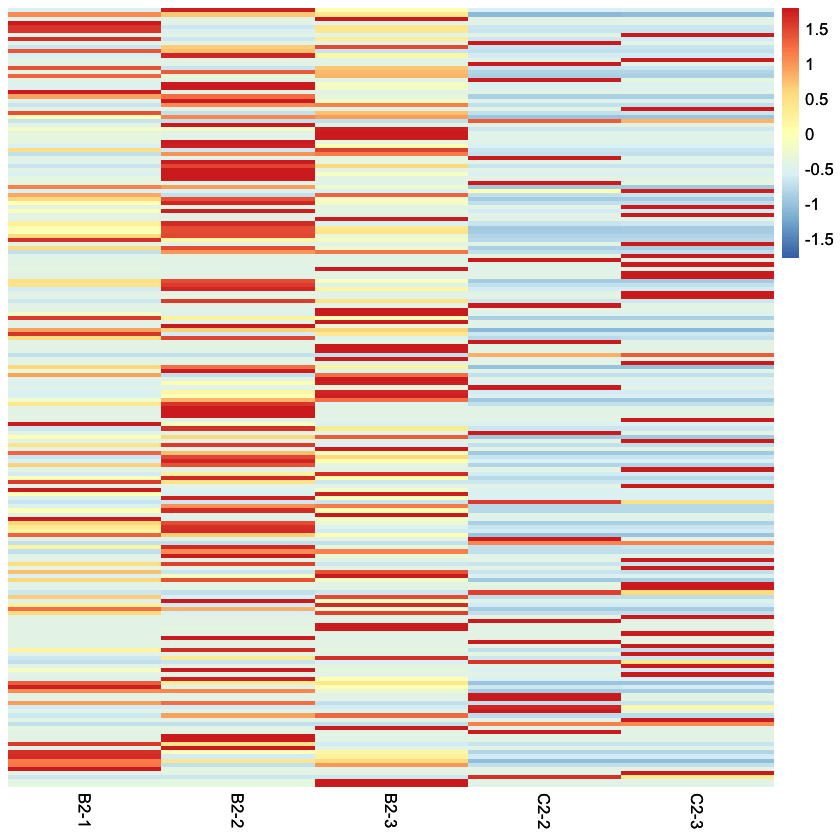

In [67]:
# Define pathway genes - AUF specific
interferon_immune <- c("Usp18", "Usp3", "Usp54", "Ifit3", "Ifit3b", "Trafd1",
                        "Trim26", "Trim34a", "Trim47", "Cr1l","Cfp", "Cd93")  
        

ubiquitin_proteasome <- c("Usp18", "Usp3", "Usp54", "Fbxl15", "Fbxo28", "Sharpin", "Stampbp",
                           "Fbxo17", "Ube3b", "Herc4", "Ubr5")

wnt_tgfb <- c("Apc", "Wls", "Smad5", "Bmpr2")

mapk_stress <- c("Mapkapk2", "Map2k5", "Pak3", "Pak4", "Stk25", 
                  "Ptpn11", "Ptpn13")

dna_repair <- c("Nhej1",     # Non-homologous end joining factor 1
        "Ogg1",      # Base excision repair; 8-oxoguanine glycosylase
        "Mlh3",      # Mismatch repair
        "Poll",      # DNA polymerase lambda; NHEJ / BER
        "Chtf8",     # Chromosome transmission fidelity; sister chromatid cohesion
        "Gtf2h1",    # TFIIH subunit; nucleotide excision repair
        "Ascc3", 
        "Spns1",     # Spinster 1; lysosomal transporter linked to autophagy
        "Vps18",     # HOPS complex; autophagosome-lysosome fusion
        "Stx6")     # Alkylation repair

glycosylation <- c("Galnt1",    # GalNAc-transferase 1; O-glycosylation
        "Galnt18",   # GalNAc-transferase 18; O-glycosylation
        "Pomgnt1",   # O-linked mannose GlcNAc transferase; dystroglycan glycosylation
        "C1galt1c1", # Core 1 synthase molecular chaperone; O-glycan synthesis
        "B3gntl1",   # Beta-1,3-N-acetylglucosaminyltransferase-like
        "Extl1",     # Exostosin-like 1; heparan sulfate biosynthesis
        "Col9a3",    # Collagen type IX alpha 3; extracellular matrix
        "Col20a1",   # Collagen type XX alpha 1; extracellular matrix
        "Arsa",      # Arylsulfatase A; sulfatide degradation (lysosomal)
        "Gba1",      # Glucocerebrosidase; glycosphingolipid catabolism (lysosomal)
        "Has2os")

cell_cycle <- c("Spc25",     # Kinetochore component (NDC80 complex)
        "Cenpc1",    # Centromere protein C; kinetochore assembly
        "Cenpi",     # Centromere protein I
        "Cep57",     # Centrosomal protein; spindle pole assembly
        "Cep85",     # Centrosomal protein
        "Haus7",     # Augmin complex; spindle assembly
        "Anln",      # Anillin; cytokinesis / cleavage furrow
        "Cdca3",     # Cell division cycle associated; APC/C substrate
        "Prr11",     # Cell cycle progression
        "Mad2l1bp",  # MAD2L1-binding protein; spindle assembly checkpoint
        "Cdk13",     # Cyclin-dependent kinase
        "Ssx2ip",    # Spindle assembly
        "Pmf1",      # Spindle midzone / microtubule associated
        "Kif4",      # Kinesin; chromosome segregation
        "Kif13b",    # Kinesin; vesicle transport / mitosis
        "Terf1")     # Telomere repeat binding factor 1

transcriptional_regulation <- c("Fosl1",     # AP-1 transcription factor (Fos family)
        "Eloa",      # Elongin A; transcription elongation
        "Iws1",      # Transcription elongation factor
        "Gtf2f1",    # General transcription factor IIF subunit
        "Gtf2h1",    # TFIIH; transcription / NER
        "Kat6a",     # Histone acetyltransferase (KAT6A / MOZ)
        "Kdm6a",     # Histone H3K27 demethylase (UTX)
        "Uhrf2",     # Ubiquitin-like with PHD/RING; epigenetic silencing
        "Nsun6",     # RNA methyltransferase; tRNA modification
        "Mettl15",   # Mitochondrial rRNA methyltransferase
        "Mettl24",   # Methyltransferase-like
        "Eef1akmt4", # EEF1A lysine methyltransferase
        "Camkmt",    # Calmodulin methyltransferase
        "Bcdin3d",   # RNA 5-prime methylphosphate capping enzyme
        "Zfp12",     # Zinc finger transcription factor
        "Zfp24",     # Zinc finger transcription factor
        "Zfp180",    # Zinc finger transcription factor
        "Zfp410",    # Zinc finger transcription factor
        "Zfp438",    # Zinc finger transcription factor
        "Zfp445",    # Zinc finger transcription factor
        "Zfp472",    # Zinc finger transcription factor
        "Zfp524",    # Zinc finger transcription factor
        "Zfp566",    # Zinc finger transcription factor
        "Zfp580",    # Zinc finger transcription factor
        "Zfp626",    # Zinc finger transcription factor
        "Zfp655",    # Zinc finger transcription factor
        "Zfp772",    # Zinc finger transcription factor
        "Zfp825",    # Zinc finger transcription factor
        "Zfp932",    # Zinc finger transcription factor
        "Zfp961",    # Zinc finger transcription factor
        "Zfp972",    # Zinc finger transcription factor
        "Zfp974",    # Zinc finger transcription factor
        "Zfx",       # Zinc finger X-linked transcription factor
        "Zkscan14",  # Zinc finger KRAB/SCAN domain
        "Zscan12",   # Zinc finger / SCAN domain
        "Nr2c1",     # Nuclear receptor subfamily 2; TR2
        "Foxh1",     # Forkhead box H1; Nodal signaling transcription factor
        "Ssbp3",     # Single-stranded DNA binding protein; transcription
        "Sfswap",    # Splicing factor; gene expression regulation
        "Med9",      # Mediator complex subunit
        "Nap1l4",    # Nucleosome assembly protein
        "Rwdd2a",    # RWD domain; transcription-associated
        "Shq1",      # H/ACA snoRNP assembly factor
        "Ssxb5")     # SSX family member; chromatin remodeling

mitochondrial <- c("Fxn",       # Frataxin; Fe-S cluster assembly; Friedreich's ataxia
        "Cox6a2",    # Cytochrome c oxidase subunit VIa; Complex IV
        "Sco2",      # COX assembly factor; copper insertion into Complex IV
        "Coq6",      # Coenzyme Q (ubiquinone) biosynthesis
        "Pdss1",     # Polyprenyl diphosphate synthase; CoQ biosynthesis
        "Pdss2",     # Polyprenyl diphosphate synthase; CoQ biosynthesis
        "Dhodh",     # Dihydroorotate dehydrogenase; pyrimidine biosynthesis / mitochondrial ETC
        "Apool",     # MINOS complex; mitochondrial inner membrane organization
        "Mpv17l2",   # Mitochondrial inner membrane; mtDNA maintenance
        "Fdxacb1",   # Adrenodoxin-like; mitochondrial electron transfer
        "Lyrm1",     # LYR motif protein; Complex I assembly
        "Guf1")

RNA_processing <- c("Lsm10",     # LSm protein; snRNP / U7 snRNP
        "Scnm1",     # Splice site modifier
        "Dcp1a",     # mRNA decapping enzyme
        "Rrp36",     # rRNA processing
        "Efl1",      # Ribosome biogenesis GTPase
        "Guf1",      # Mitochondrial ribosome biogenesis GTPase
        "Pdcd2l",    # Pre-40S ribosome assembly
        "Ssu72",     # RNA polymerase II CTD phosphatase; cleavage / polyadenylation
        "Snord14c",  # C/D box snoRNA
        "Snord14d",  # C/D box snoRNA
        "Snord14e",  # C/D box snoRNA
        "Snord19",   # C/D box snoRNA
        "Snord99",   # C/D box snoRNA
        "Snora41",   # H/ACA box snoRNA
        "Snora81",   # H/ACA box snoRNA
        "Mrps6",     # Mitochondrial ribosomal protein (small subunit)
        "Ptcd2",     # Mitochondrial RNA processing
        "Ints9",     # Integrator complex; snRNA 3-prime processing
        "Ints12",    # Integrator complex
        "Rbm12b2",   # RNA binding motif protein
        "Zc3h4",     # Zinc finger CCCH; RNA binding
        "Alkbh6",    # AlkB homolog; RNA demethylation
        "Trub1",     # Pseudouridine synthase; tRNA modification
        "Dtd2",      # D-aminoacyl-tRNA deacylase
        "Yars2",     # Mitochondrial tyrosyl-tRNA synthetase
        "Fars2",     # Mitochondrial phenylalanyl-tRNA synthetase
        "Gfm1",      # Mitochondrial translation elongation factor
        "Ybey")

vesicle_trafficking <- c("Vps4a",     # AAA-ATPase; ESCRT-III / MVB pathway
        "Vps18",     # HOPS complex; endosome-lysosome fusion
        "Stx6",      # Syntaxin 6; trans-Golgi / endosomal trafficking
        "Snap29",    # SNARE protein; vesicle fusion
        "Tbc1d12",   # Rab GAP; vesicle trafficking
        "Tbc1d17",   # Rab GAP; vesicle trafficking
        "Spns1",     # Lysosomal transporter
        "Cln5",      # Neuronal ceroid lipofuscinosis protein; lysosomal
        "Bloc1s4",   # BLOC-1 complex; lysosome-related organelle biogenesis
        "Bloc1s6",   # BLOC-1 complex
        "Hps1",      # Hermansky-Pudlak syndrome; lysosome biogenesis
        "Ostm1",     # Osteoclast stimulatory transmembrane protein; lysosomal Cl- channel
        "Plekhm1",   # Rab7 effector; late endosome / lysosome
        "Plekhf1",   # Pleckstrin homology domain; endosome
        "Snx14",     # Sorting nexin; endosomal membrane curvature
        "Bin3",      # BAR domain; membrane tubulation
        "Tango6")

signalling <- c("Ptpn11",    # SHP2 phosphatase; RAS/MAPK, cytokine signaling
        "Ptpn13",    # Protein tyrosine phosphatase
        "Map2k5",    # MEK5; ERK5 / MAPK pathway
        "Mapkapk2",  # MAPKAP-K2; p38-MAPK downstream kinase
        "Pak3",      # p21-activated kinase; Rho GTPase effector
        "Pak4",      # p21-activated kinase
        "Stk25",     # Sterile-20-like kinase; Hippo-related
        "Arrb1",     # beta-Arrestin 1; GPCR desensitization / signaling
        "Deptor",    # mTOR complex inhibitor (DEPTOR)
        "Rhebl1",    # Ras homolog enriched in brain-like; mTORC1 activator
        "Ppp1r14a",  # PP1 regulatory subunit (inhibitor-2 family)
        "Ppp1r21",   # PP1 regulatory subunit
        "Ppp1r3c",   # PP1 regulatory subunit; glycogen metabolism
        "Ppp4r1l-ps",# PP4 regulatory subunit pseudogene
        "Rassf3",    # Ras-association domain family; apoptosis / Hippo
        "Rassf7",    # Ras-association domain family
        "Rasl11b",   # RAS-like GTPase
        "Arl11",     # ADP-ribosylation factor-like; apoptosis
        "Trafd1",    # TRAF-domain; NF-kB signaling
        "Smad5",     # TGF-beta / BMP signaling
        "Bmpr2",     # BMP receptor type 2; TGF-beta superfamily
        "Lefty1",    # TGF-beta superfamily; Nodal signaling antagonist
        "Efr3a",     # Ypp1/FAM126; PI4-kinase complex scaffold
        "Inpp5b",    # Inositol polyphosphate 5-phosphatase
        "Gpcpd1")

lipid_metabolism <- c("Sqle",      # Squalene epoxidase; cholesterol biosynthesis
        "Ugcg",      # UDP-glucose ceramide glucosyltransferase; glycosphingolipid synthesis
        "Cyp2u1",    # Cytochrome P450; fatty acid hydroxylation
        "Gdpd2",     # Glycerophosphodiester phosphodiesterase; lipid metabolism
        "Pisd",      # Phosphatidylserine decarboxylase; mitochondrial PE synthesis
        "Slc25a20",  # Carnitine-acylcarnitine translocase; mitochondrial FA transport
        "Acss1",     # Acyl-CoA synthetase; short-chain fatty acids
        "Lypla2",    # Acyl-protein thioesterase 2; palmitoylation cycle
        "Zdhhc9",    # DHHC-type palmitoyl transferase
        "Rdh11")

apoptosis_autophagy <- c("Rassf3",    # Pro-apoptotic Ras effector
        "Arl11",     # Tumor suppressor GTPase; apoptosis
        "Nsmaf",     # Neutral sphingomyelinase activation-associated factor; TNF-induced apoptosis
        "Trafd1",    # TRAF domain; NF-kB and apoptosis
        "Jtb")

# Combine all
all_pathways_auf <- (c(interferon_immune, ubiquitin_proteasome, wnt_tgfb,
                              mapk_stress, dna_repair, glycosylation, cell_cycle,
                              transcriptional_regulation, mitochondrial, RNA_processing, vesicle_trafficking, signalling, lipid_metabolism, apoptosis_autophagy))

# Check significance
sig_subset_auf <- sig_genes_auf[rownames(sig_genes_auf) %in% all_pathways_auf, ]
cat("Genes found in sig_genes_auf:", nrow(sig_subset_auf), "\n")
cat("Genes not significant:", all_pathways_auf[!all_pathways_auf %in% rownames(sig_genes_auf)], "\n")

# Use full results to plot all pathway genes regardless of significance
pathway_subset_auf <- res_auf[rownames(res_auf) %in% all_pathways_auf, ]
df_plot_auf <- de_out_auf$df[rownames(pathway_subset_auf), order(colnames(de_out_auf$df))]

print(pheatmap(df_plot_auf, scale = "row", cluster_cols = FALSE,
               cluster_rows = FALSE, show_rownames = FALSE,
               fontsize_row = 7))

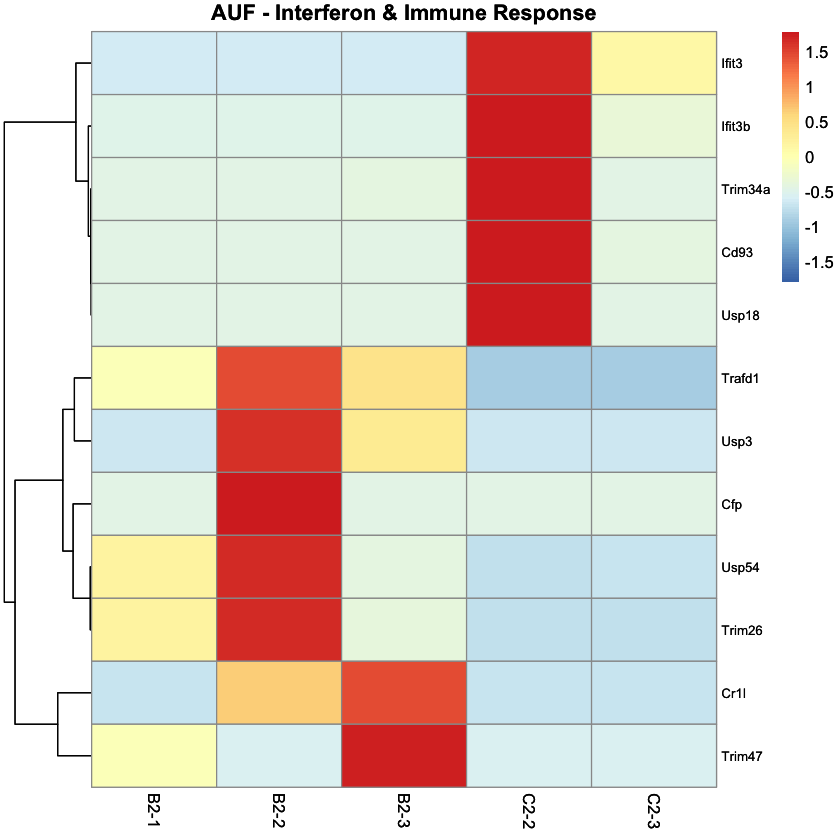

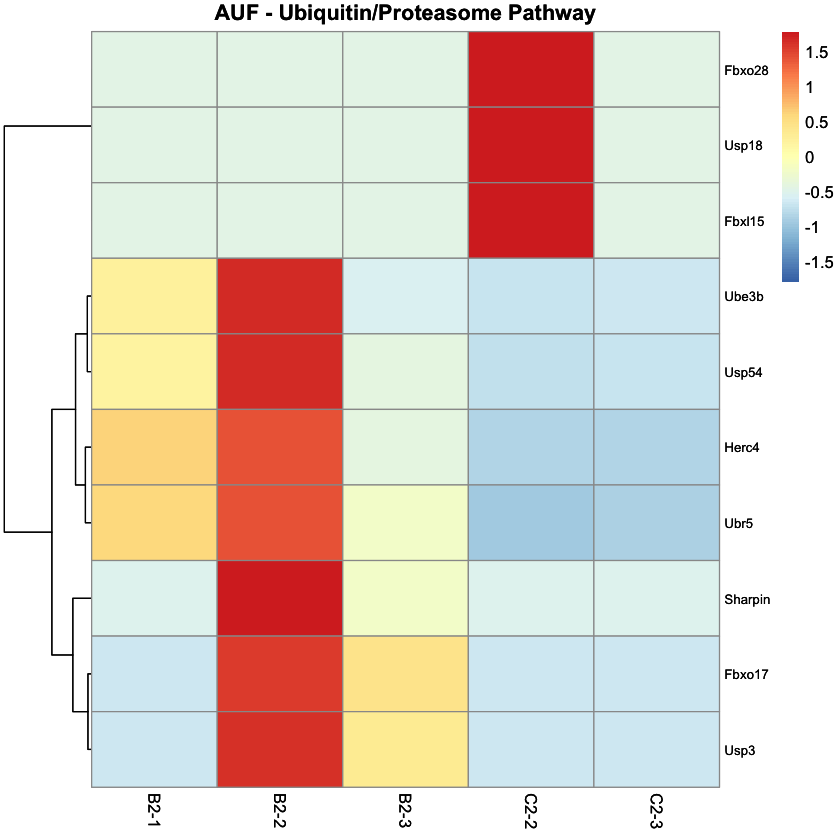

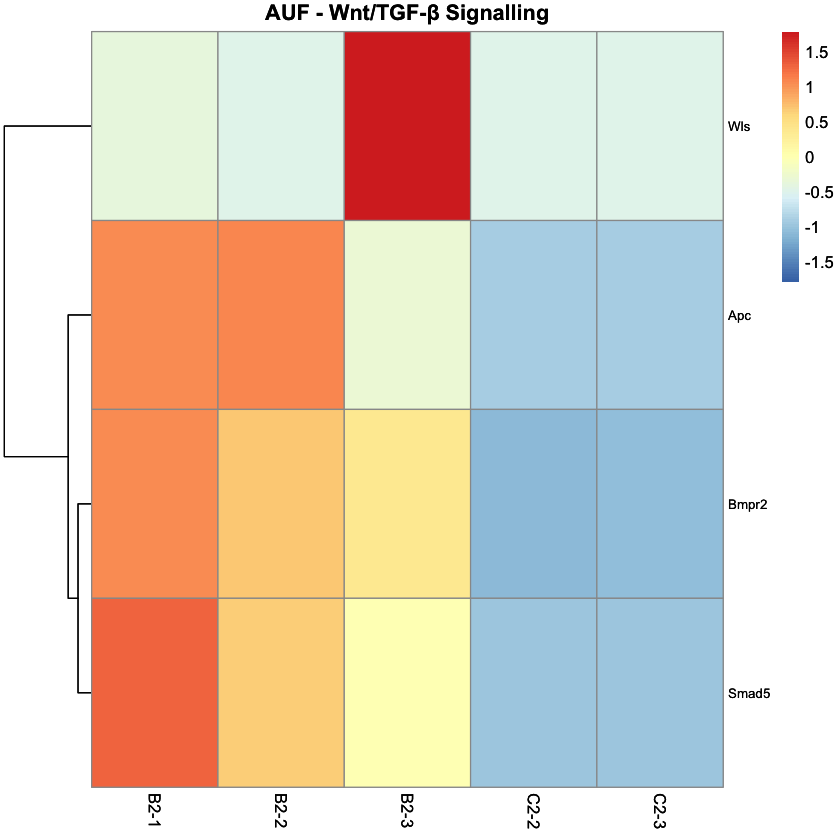

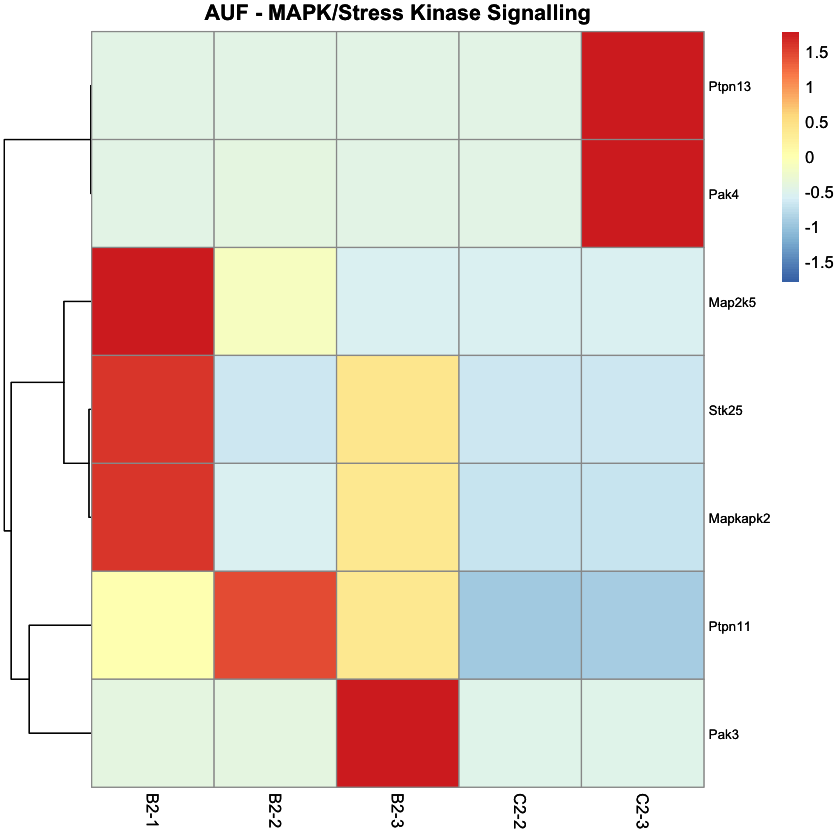

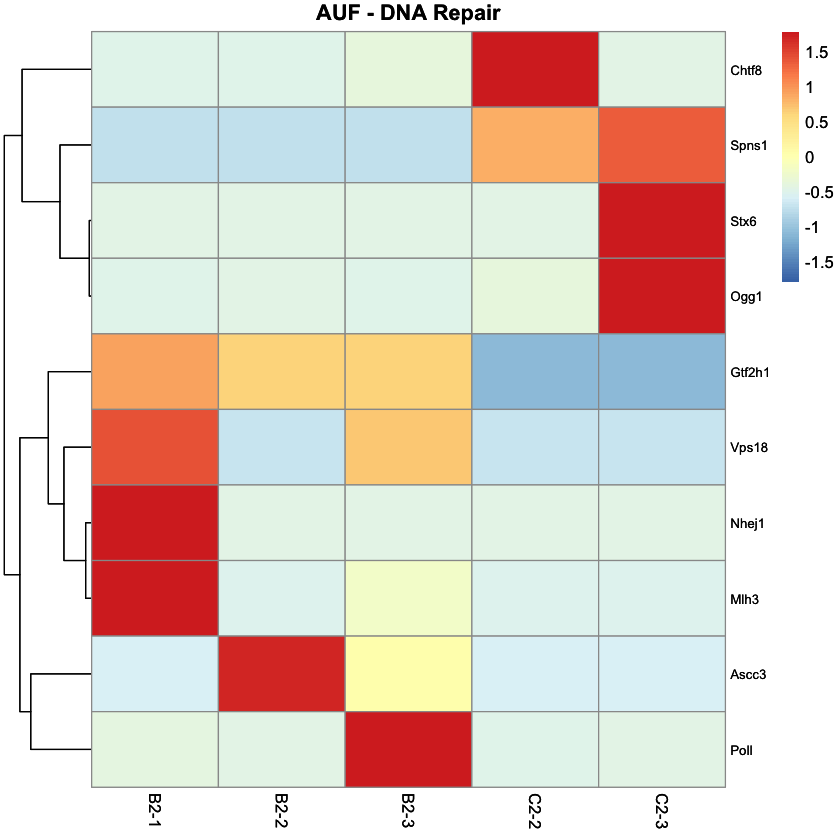

...

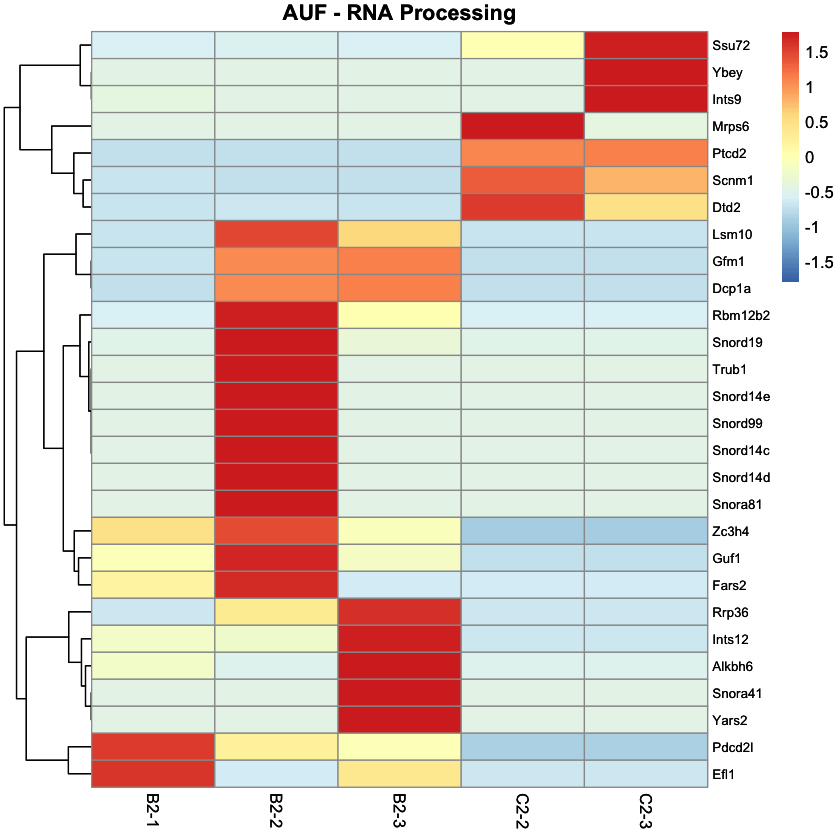

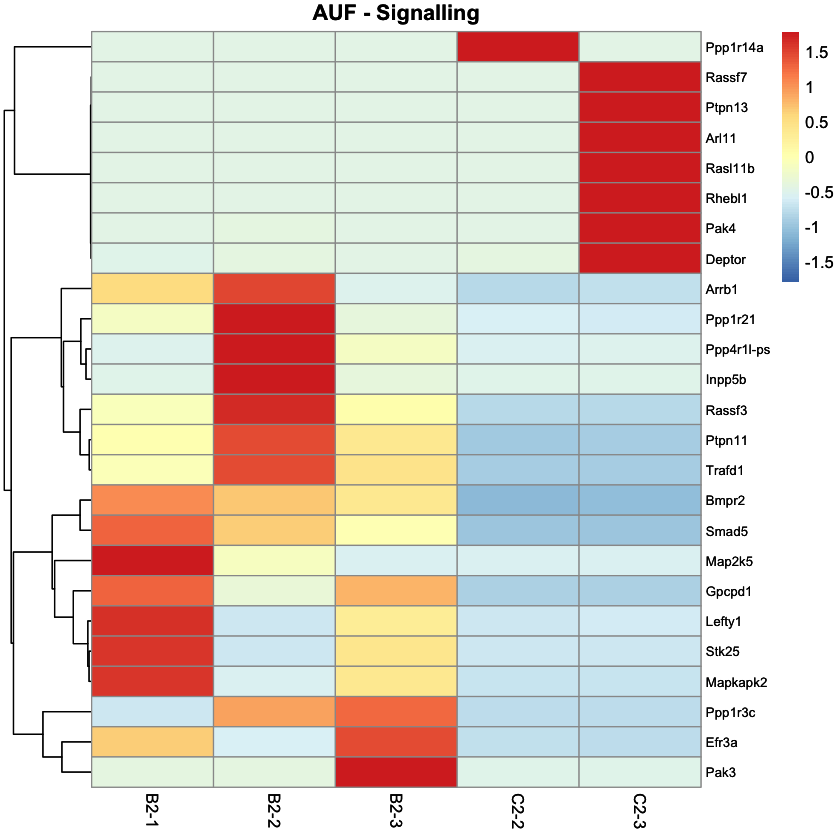

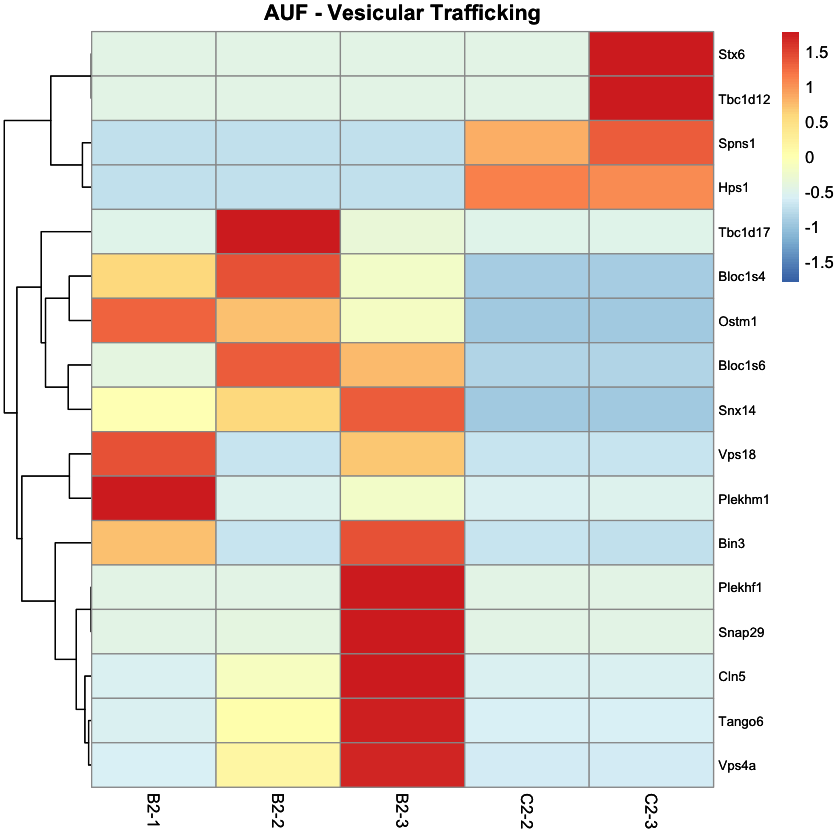

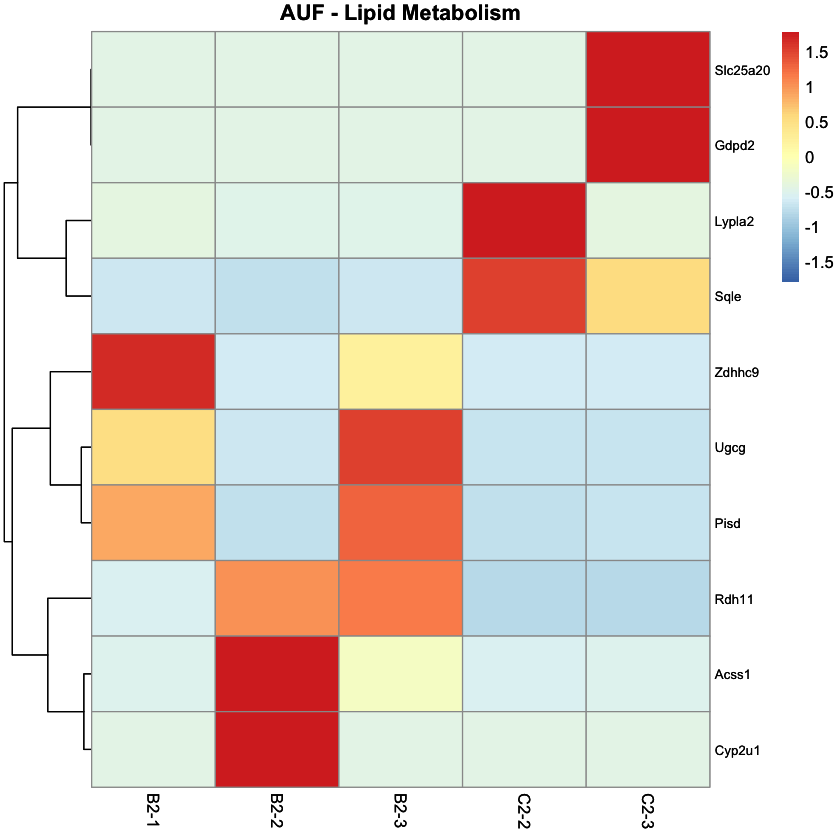

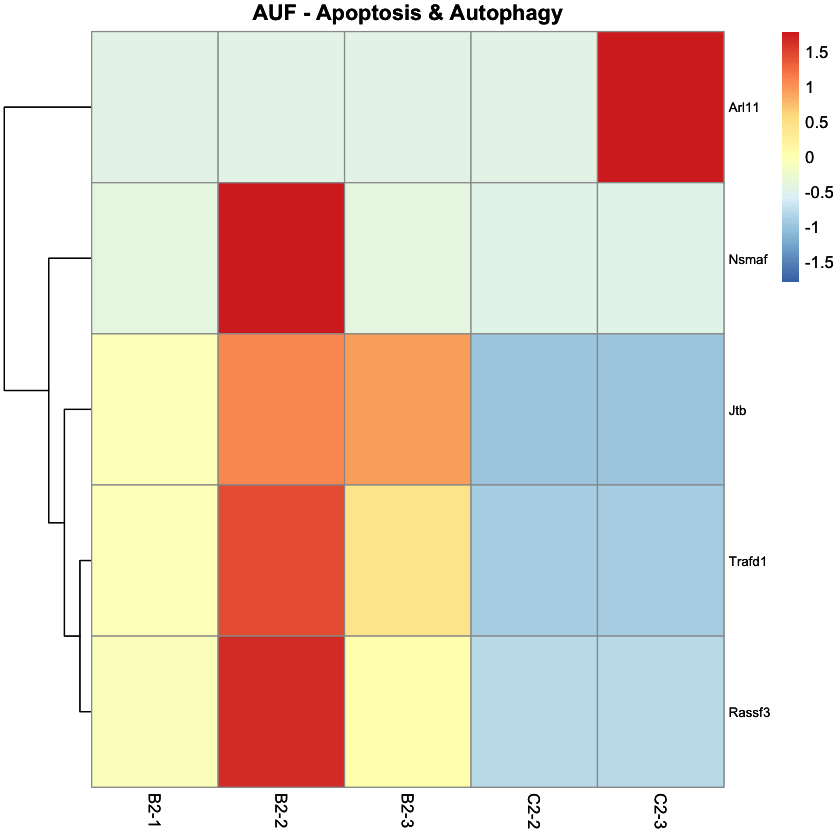

In [68]:
# Helper function for pathway heatmaps
plot_pathway_heatmap <- function(genes, res, df, title) {
  subset <- res[rownames(res) %in% genes, ]
  df_plot <- df[rownames(subset), order(colnames(df))]
  df_plot <- df_plot[rowSums(df_plot) > 0, ]  # remove zero rows
  if (nrow(df_plot) == 0) {
    cat("No genes found for:", title, "\n")
    return(NULL)
  }
  print(pheatmap(df_plot, scale = "row", cluster_cols = FALSE,
                 cluster_rows = TRUE, show_rownames = TRUE,
                 fontsize_row = 8, main = title))
}

# Plot each pathway separately
plot_pathway_heatmap(interferon_immune, res_auf, de_out_auf$df, 
                     "AUF - Interferon & Immune Response")

plot_pathway_heatmap(ubiquitin_proteasome, res_auf, de_out_auf$df, 
                     "AUF - Ubiquitin/Proteasome Pathway")

plot_pathway_heatmap(wnt_tgfb, res_auf, de_out_auf$df, 
                     "AUF - Wnt/TGF-β Signalling")

plot_pathway_heatmap(mapk_stress, res_auf, de_out_auf$df, 
                     "AUF - MAPK/Stress Kinase Signalling")

plot_pathway_heatmap(dna_repair, res_auf, de_out_auf$df, 
                     "AUF - DNA Repair")

plot_pathway_heatmap(glycosylation, res_auf, de_out_auf$df, 
                     "AUF - Glycosylation")

plot_pathway_heatmap(cell_cycle, res_auf, de_out_auf$df, 
                     "AUF - Cell Cycle")

plot_pathway_heatmap(transcriptional_regulation, res_auf, de_out_auf$df, 
                     "AUF - Transcriptional Regulation")

plot_pathway_heatmap(mitochondrial, res_auf, de_out_auf$df, 
                     "AUF - Mitochondrial/Metabolism")

plot_pathway_heatmap(RNA_processing, res_auf, de_out_auf$df, 
                     "AUF - RNA Processing")

plot_pathway_heatmap(signalling, res_auf, de_out_auf$df, 
                     "AUF - Signalling")

plot_pathway_heatmap(vesicle_trafficking, res_auf, de_out_auf$df, 
                     "AUF - Vesicular Trafficking")

plot_pathway_heatmap(lipid_metabolism, res_auf, de_out_auf$df, 
                    "AUF - Lipid Metabolism")

plot_pathway_heatmap(apoptosis_autophagy, res_auf, de_out_auf$df, 
                    "AUF - Apoptosis & Autophagy")

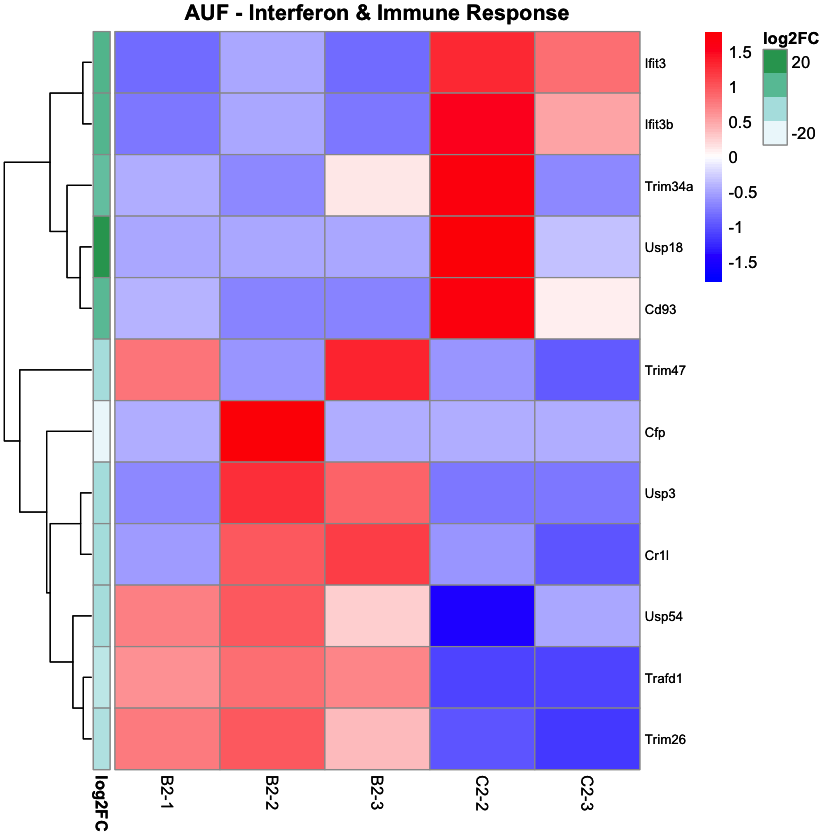

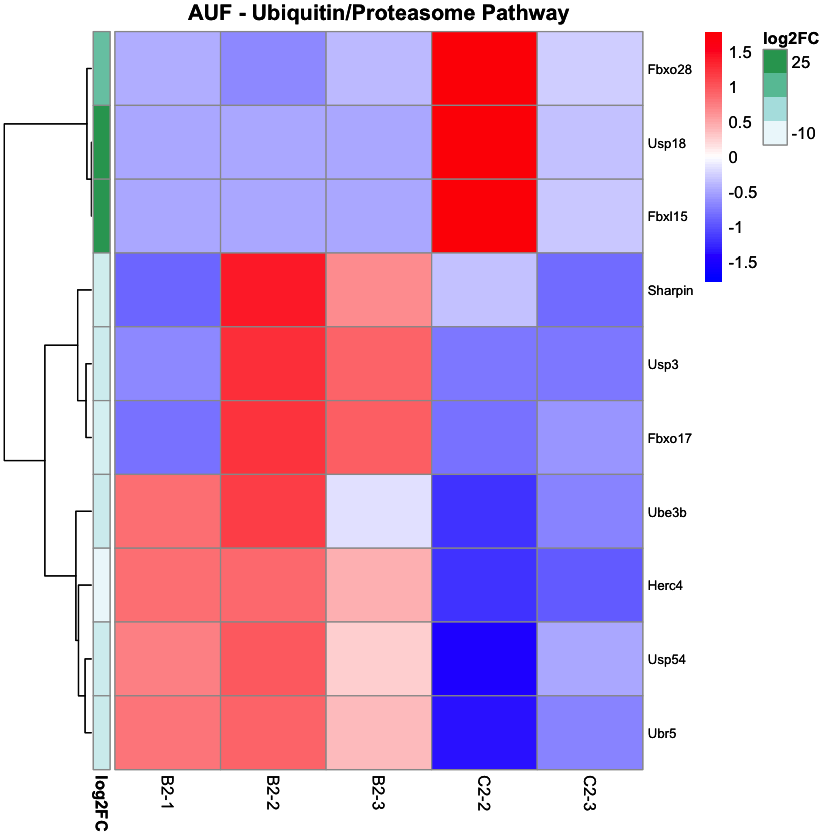

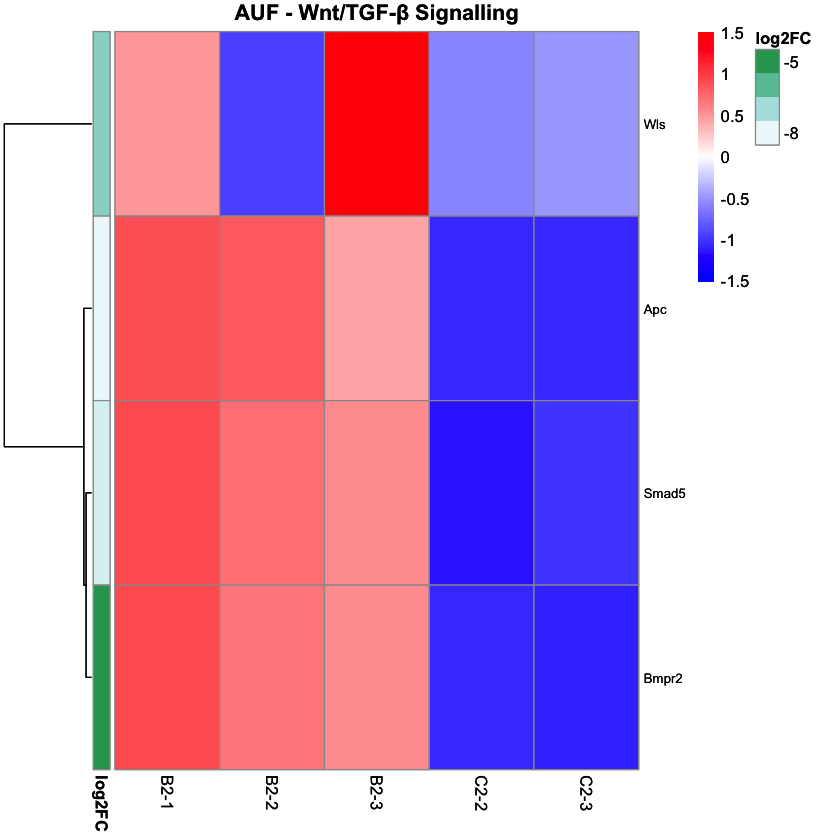

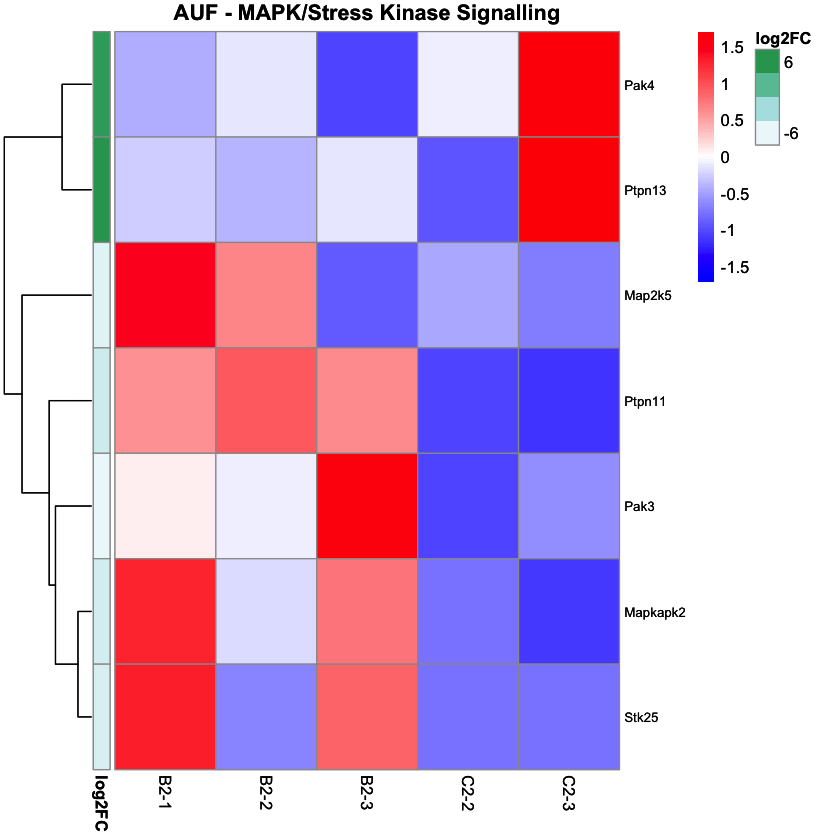

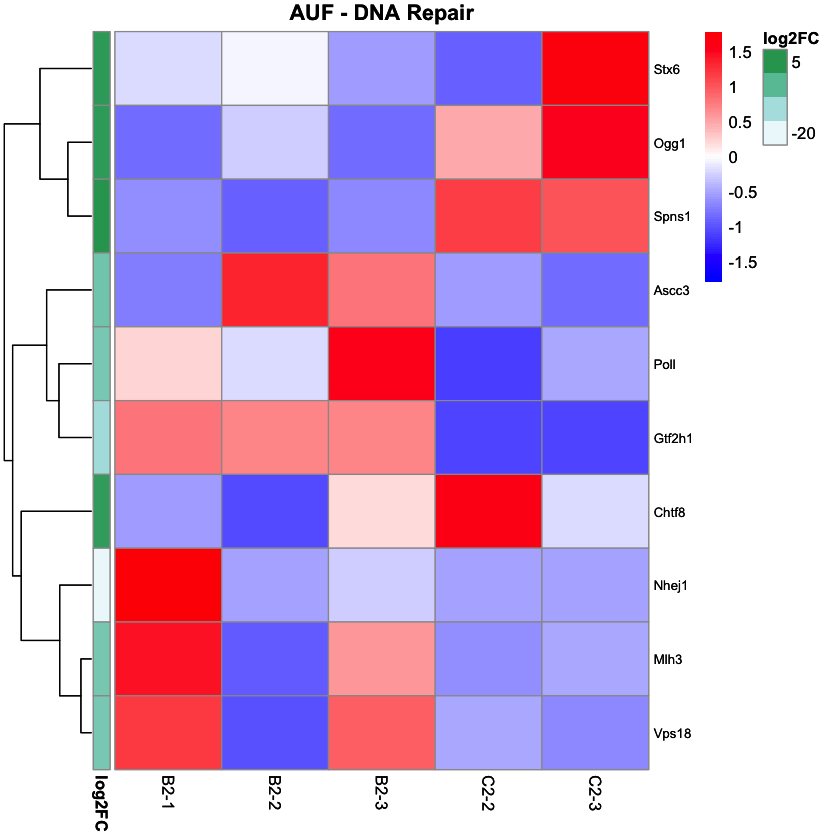

...

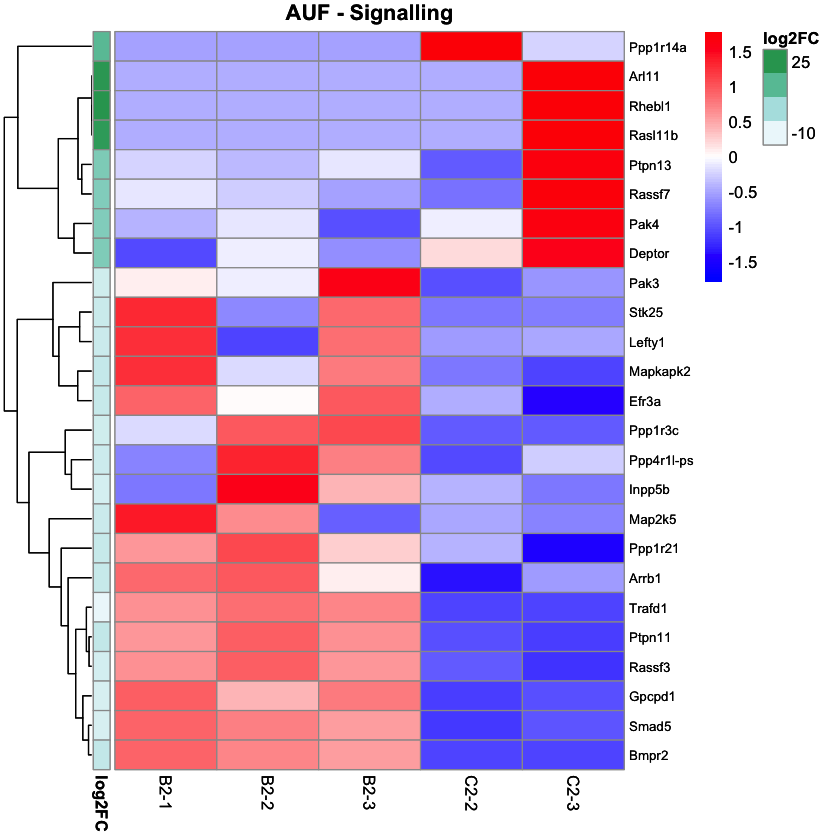

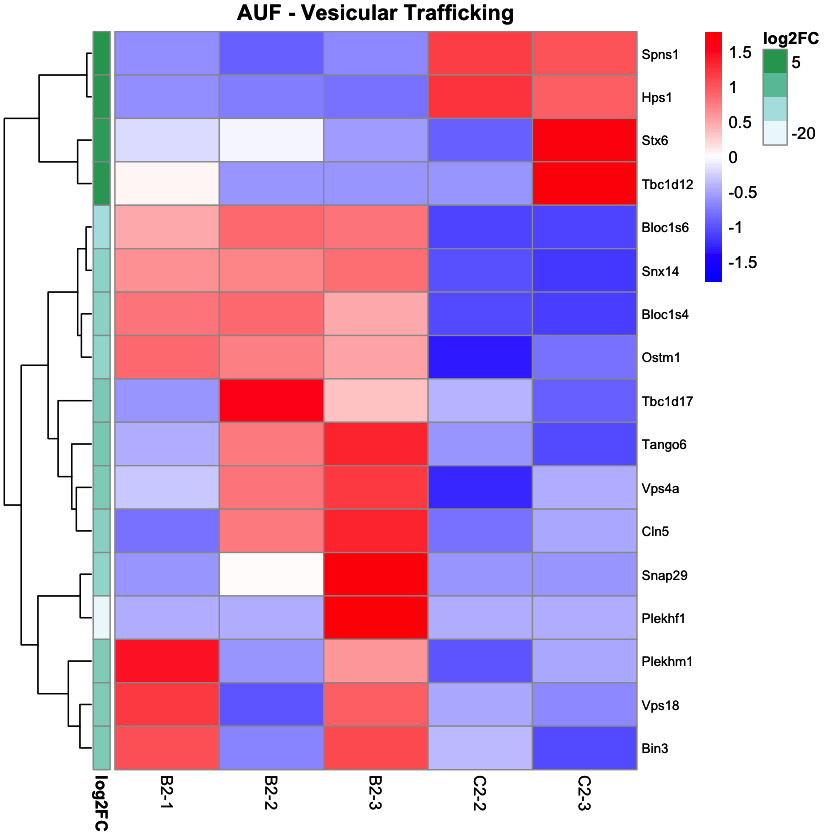

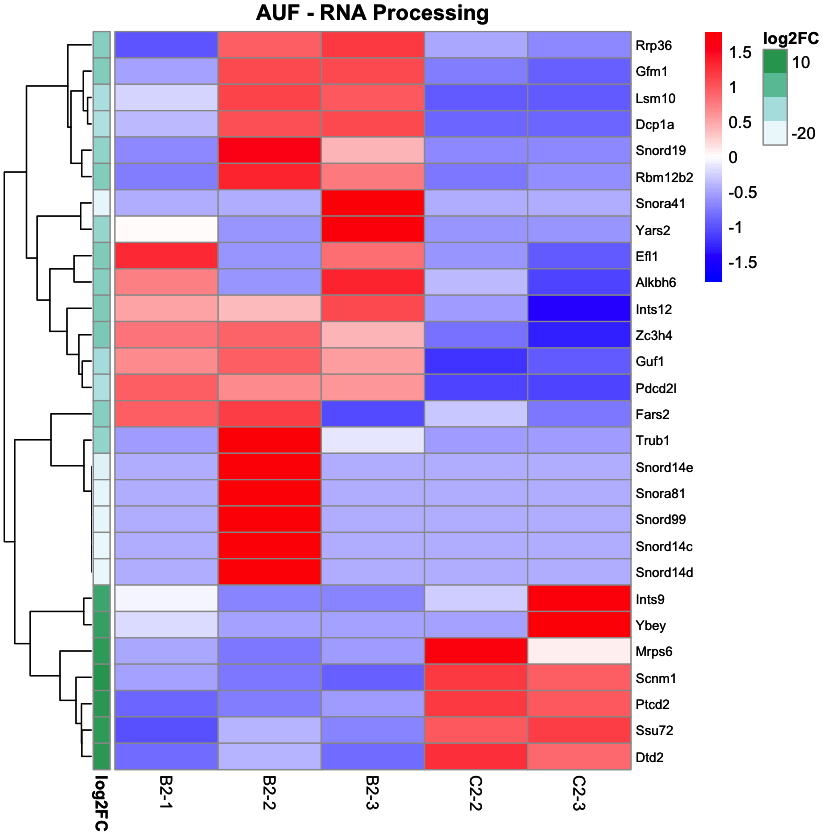

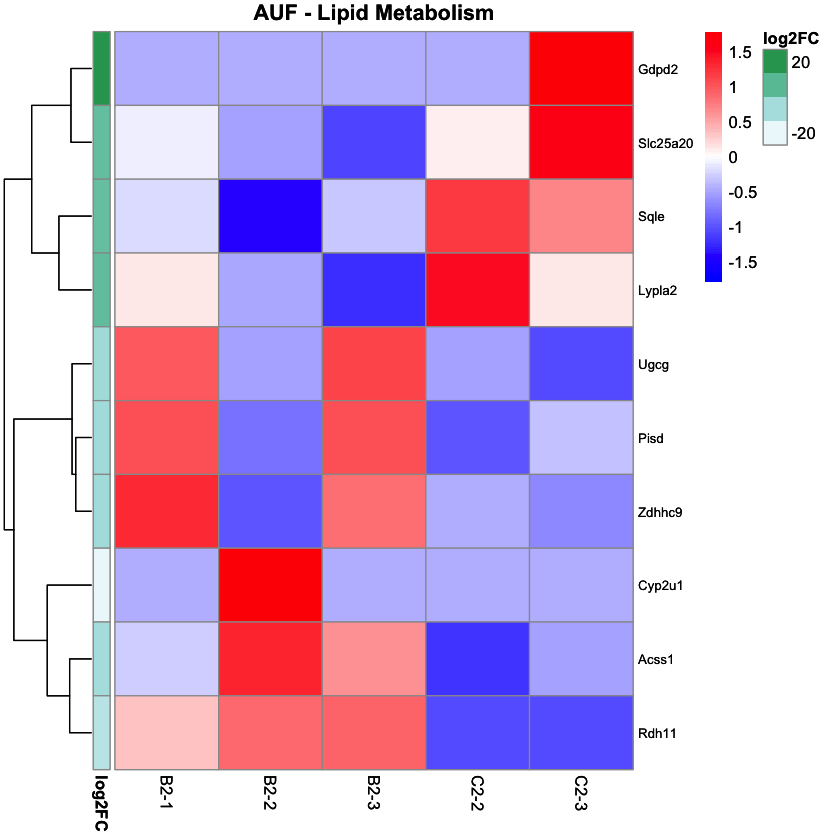

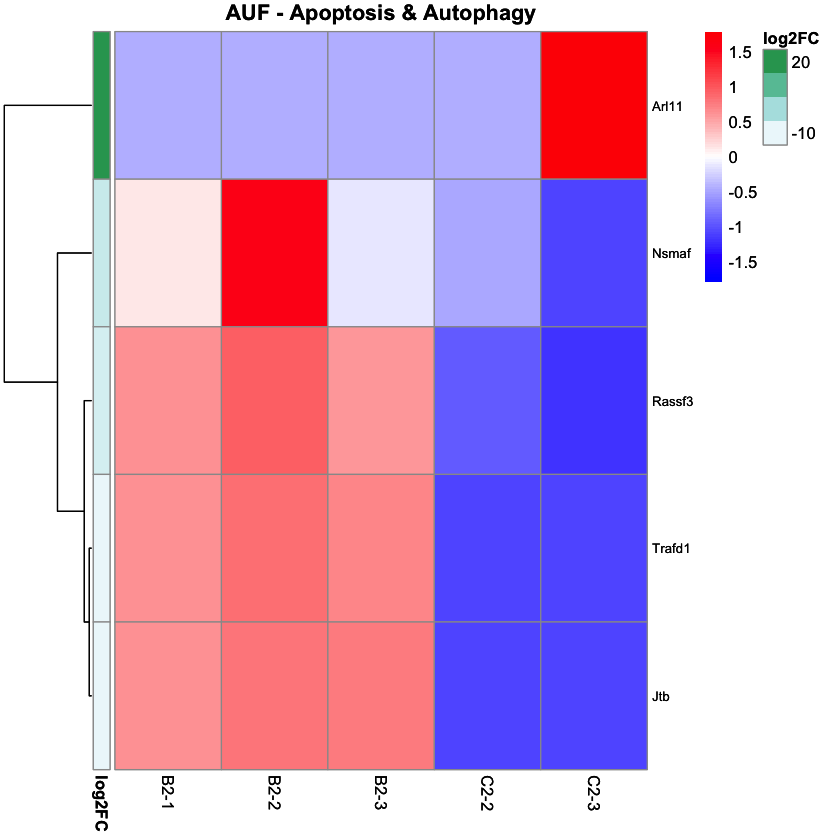

In [69]:
# Get normalized counts from DESeq2
norm_counts_auf <- DESeq2::counts(de_out_auf$dds, normalized = TRUE)

# Helper function
plot_pathway_heatmap_lfc <- function(genes, norm_counts, res, title) {
  # Get genes present in both
  genes_found <- genes[genes %in% rownames(norm_counts)]
  
  if (length(genes_found) == 0) {
    cat("No genes found for:", title, "\n")
    return(NULL)
  }
  
  # Subset and log transform
  df_plot <- log2(norm_counts[genes_found, ] + 1)
  df_plot <- df_plot[, order(colnames(df_plot))]
  
  # Get LFC for annotation
  lfc_vals <- round(as.data.frame(res[genes_found, "log2FoldChange"]), 2)
  rownames(lfc_vals) <- genes_found
  colnames(lfc_vals) <- "log2FC"
  
  print(pheatmap(df_plot, cluster_cols = FALSE, cluster_rows = TRUE,
                 show_rownames = TRUE, fontsize_row = 8, main = title,
                 scale = "row",
                 annotation_row = lfc_vals,
                 color = colorRampPalette(c("blue", "white", "red"))(100)))
}

# Plot each pathway
plot_pathway_heatmap_lfc(interferon_immune, norm_counts_auf, res_auf, "AUF - Interferon & Immune Response")
plot_pathway_heatmap_lfc(ubiquitin_proteasome, norm_counts_auf, res_auf, "AUF - Ubiquitin/Proteasome Pathway")
plot_pathway_heatmap_lfc(wnt_tgfb, norm_counts_auf, res_auf, "AUF - Wnt/TGF-β Signalling")
plot_pathway_heatmap_lfc(mapk_stress, norm_counts_auf, res_auf, "AUF - MAPK/Stress Kinase Signalling")
plot_pathway_heatmap_lfc(dna_repair, norm_counts_auf, res_auf, "AUF - DNA Repair")
plot_pathway_heatmap_lfc(glycosylation, norm_counts_auf, res_auf, "AUF - Glycosylation")
plot_pathway_heatmap_lfc(cell_cycle, norm_counts_auf, res_auf, "AUF - Cell Cycle")
plot_pathway_heatmap_lfc(transcriptional_regulation, norm_counts_auf, res_auf, "AUF - Transcriptional Regulation")
plot_pathway_heatmap_lfc(mitochondrial, norm_counts_auf, res_auf, "AUF - Mitochondrial/Metabolism")
plot_pathway_heatmap_lfc(signalling, norm_counts_auf, res_auf, "AUF - Signalling")
plot_pathway_heatmap_lfc(vesicle_trafficking, norm_counts_auf, res_auf, "AUF - Vesicular Trafficking")
plot_pathway_heatmap_lfc(RNA_processing, norm_counts_auf, res_auf, "AUF - RNA Processing")
plot_pathway_heatmap_lfc(lipid_metabolism, norm_counts_auf, res_auf, "AUF - Lipid Metabolism")
plot_pathway_heatmap_lfc(apoptosis_autophagy, norm_counts_auf, res_auf, "AUF - Apoptosis & Autophagy")

### TMZ Treating Glioma 

Genes found in sig_genes_tmz: 177 
Genes not significant:  


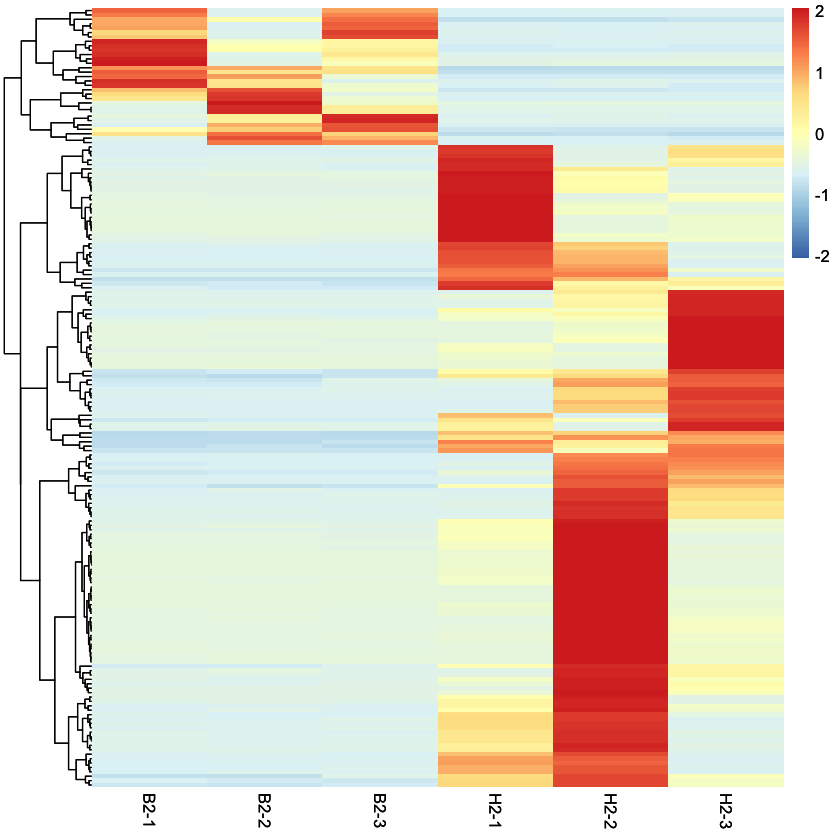

In [70]:

# Define pathway genes - confirmed in TMZ list
prostaglandin <- c("Fa2h", "Daglb", "Acaca", "Hadha", "Ptges")

glycosylceramide <- c("B4gat1", "Ugcg", "Galnt1", "Galnt11", "Mogs",
                       "C1galt1c1", "Alg2", "Pmm2", "Pgap1", "Pgap2", "Galm", "Pygb", "Nudt2", "Nudt14")

cell_cycle <- c("Tpx2", "Spc25", "Gmnn", "Racgap1", "Rad51ap1", "Lmnb2",
                         "Tacc2", "Rrm2", "Brip1", "Hells", "Cep68")

dna_repair <- c("Ogg1", "Faap24", "Brip1", "Wrap73", "Rad51ap1", "Usp11",
                 "Eif2ak2", "Mplkip")

mtor_autophagy <- c("Mtor", "Pik3c3", "Pikfyve", "Rnf183", "Rnf26", "Herc6", "Herc3", "Usp11",
                            "Trim34a", "Trim34b", "Dcaf15", "Atg7", "Atg16l2", "Spns1", "Clcn7", "Sh3glb2")

transcriptional <- c("Fos", "Hdac10",
                     "Egr2", "Bmi1", "Nab2", "Sinhcaf", "Zmym3", "Tiparp",
                     "Sin3a", "Kat2a", "Phf21a", "Ing5", "Zfp335",
                               "Hells", "Zcwpw1", "Mllt3", "Thap4", "Lyl1",
                               "Foxk1", "Foxc2", "Klf14", "Pou3f1", "Pou3f2",
                               "Meis2", "Hoxc6", "Zfp322a", "Zfp81", "Zfp58",
                               "Zfp560", "Zfp472", "Zfp82", "Zscan22", "Zkscan14",
                               "Zfr2", "Sobp", "Pvt1")

jnk_mapk <- c("Mapk8", "Map2k1", "Rps6ka1", "Camk1", "Stip1")

cell_adhesion <- c("Wasf1", "Pvr", "Cd276", "Itga10", "Tns1", "Coro2b", "Shroom2", "Dync1li2", "Fez2", "Crmp1",
                    "Pak4", "Vav2", "Cyth2", "Tesk1", "Mns1", "Col5a3", "Adamtsl5", "Mmp24", "Qsox1", "Podnl1", "Pcdh11x", "Nhsl1", "Foxc2", "Lrch1")

glutamine_transport <- c("Slc2a12", "Slc12a9", "Slc4a7", "Slc17a5", "Abcg2", "Abcd4")

rna_processing <- c("Magohb", "Usb1", "Smg9", "Lsm12", "Isg20l2", "Adat1",
                     "Nol12", "Nop14", "Dhx37", "Pde12", "Rexo4", "Nsun7",
                     "Mettl15", "Ints11", "Ogfod2", "Snord21", "Snora65",
                     "Airn", "Dnm3os")

nuclear_transport <- c("Xpo5", "Ipo11", "Ankrd54")

interferon <- c("Ifit3", "Herc6", "Pilra", "Trim34a", "Trim34b",
                         "Eif2ak2", "Zc3h12b")

lipid_metabolism <- c("Acaca", "Abcd1", "Fa2h", "Daglb", "Osbpl1a",
                        "Gba2", "Srd5a3", "Pank1", "Ptges", "Ptges2")

mitochondrial <- c("Cox7a1", "Afg3l2", "Nubpl", "Mrps6", "Noa1",
                           "Tamm41", "Atpsckmt", "Gpd1l", "Fh1", "Pusl1", "Dtd2", "Gda", "Abhd14a")

signaling <- c("Pak4", "Camk1", "Strada", "Rgs19", "Rgs17", "Ppp3cc",
                 "Irak2", "Mtmr7", "Inpp5k", "Ip6k3", "Vav2")

epigenetic <- c("Kat2a", "Sin3a", "Phf21a", "Zcwpw1", "Ing5", "Zfp335")

neuronal <- c("Homer1", "Cacng4", "Fxyd7", "Fez2", "Crmp1",
                         "Nbea", "Dmxl2", "Camk1", "Pou3f1", "Pou3f2")

# Combine all
all_pathways_tmz <- (c(prostaglandin, glycosylceramide, cell_cycle,
                              dna_repair, mtor_autophagy, transcriptional,
                              jnk_mapk, cell_adhesion, glutamine_transport, 
                              rna_processing, nuclear_transport, interferon, 
                              lipid_metabolism, mitochondrial, signaling, epigenetic, neuronal))

# Check significance
sig_subset_tmz <- sig_genes_tmz[rownames(sig_genes_tmz) %in% all_pathways_tmz, ]
cat("Genes found in sig_genes_tmz:", nrow(sig_subset_tmz), "\n")
cat("Genes not significant:", all_pathways_tmz[!all_pathways_tmz %in% rownames(sig_genes_tmz)], "\n")

# Plot using full results regardless of significance
pathway_subset_tmz <- res_tmz[rownames(res_tmz) %in% all_pathways_tmz, ]
df_plot_tmz <- de_out_tmz$df[rownames(pathway_subset_tmz), order(colnames(de_out_tmz$df))]

print(pheatmap(df_plot_tmz, scale = "row", cluster_cols = FALSE,
               cluster_rows = TRUE, show_rownames = FALSE,
               fontsize_row = 7))

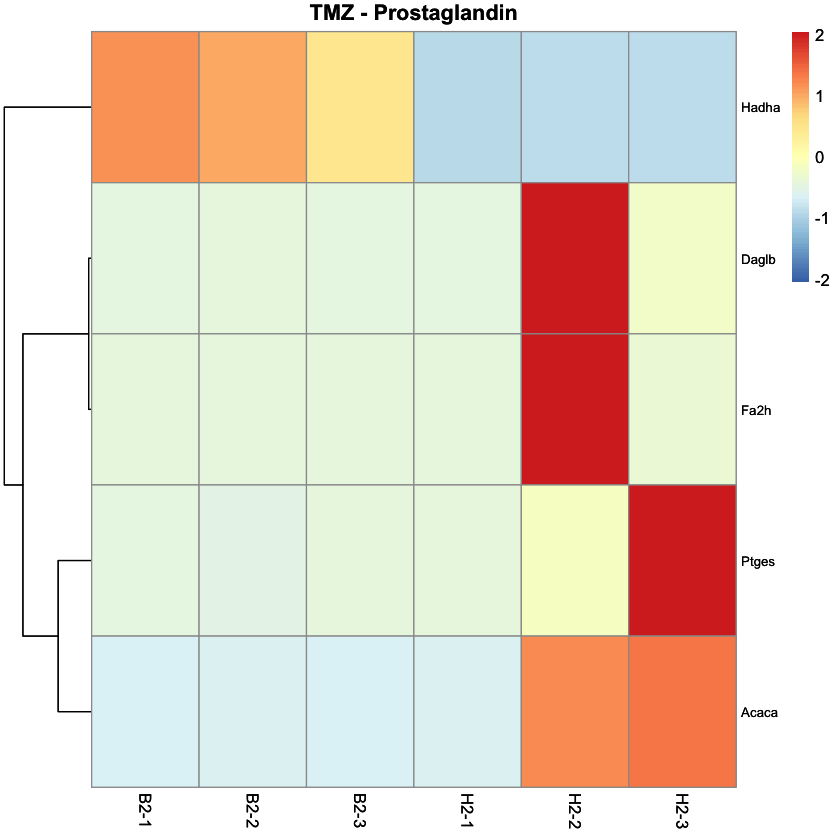

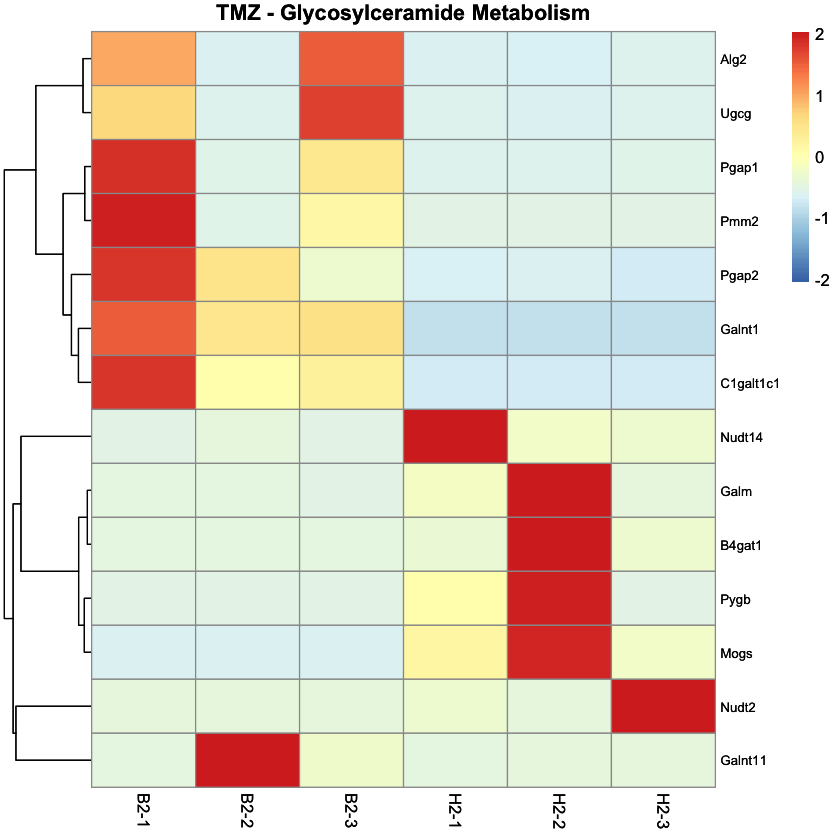

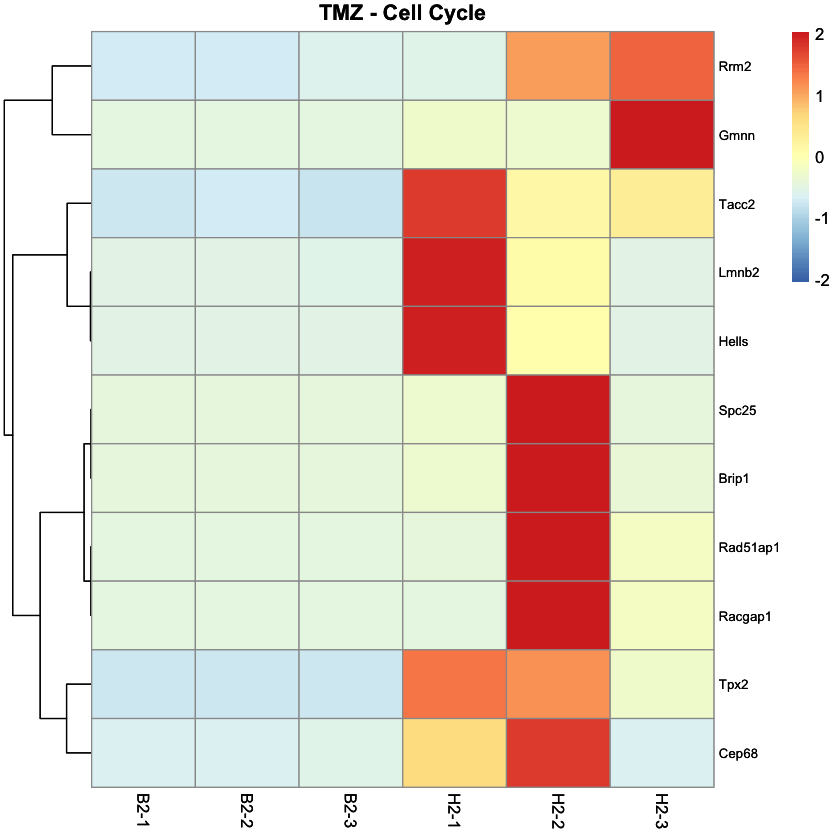

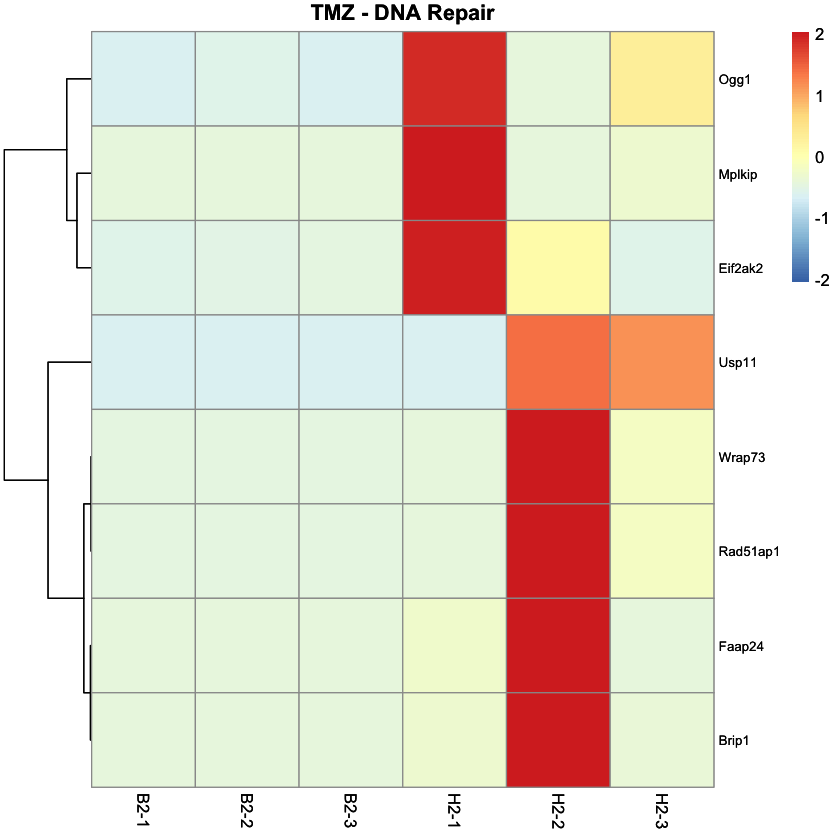

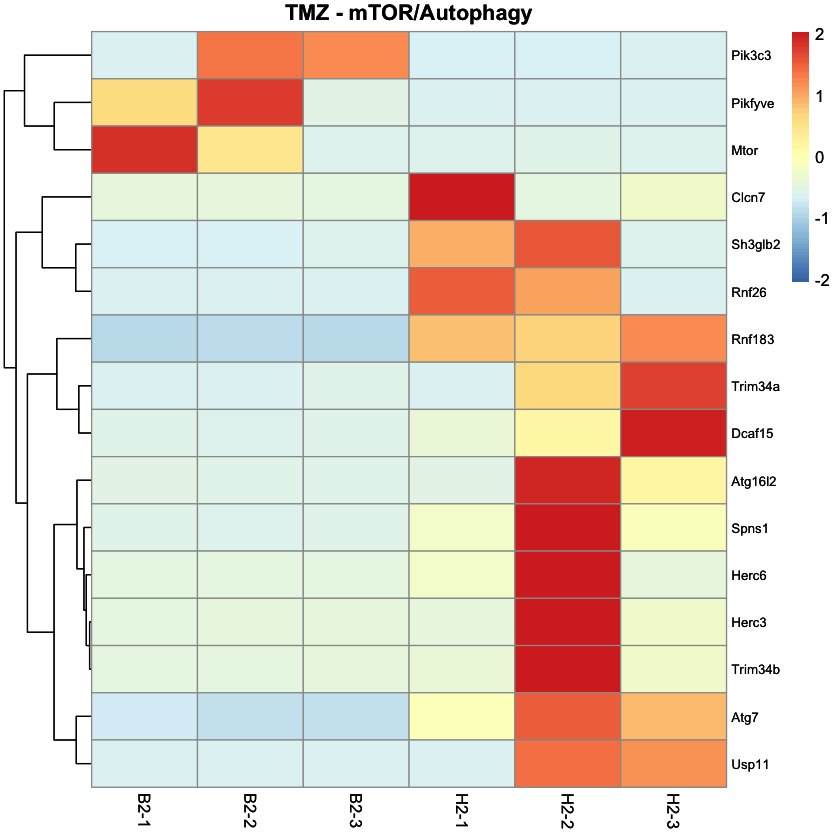

...

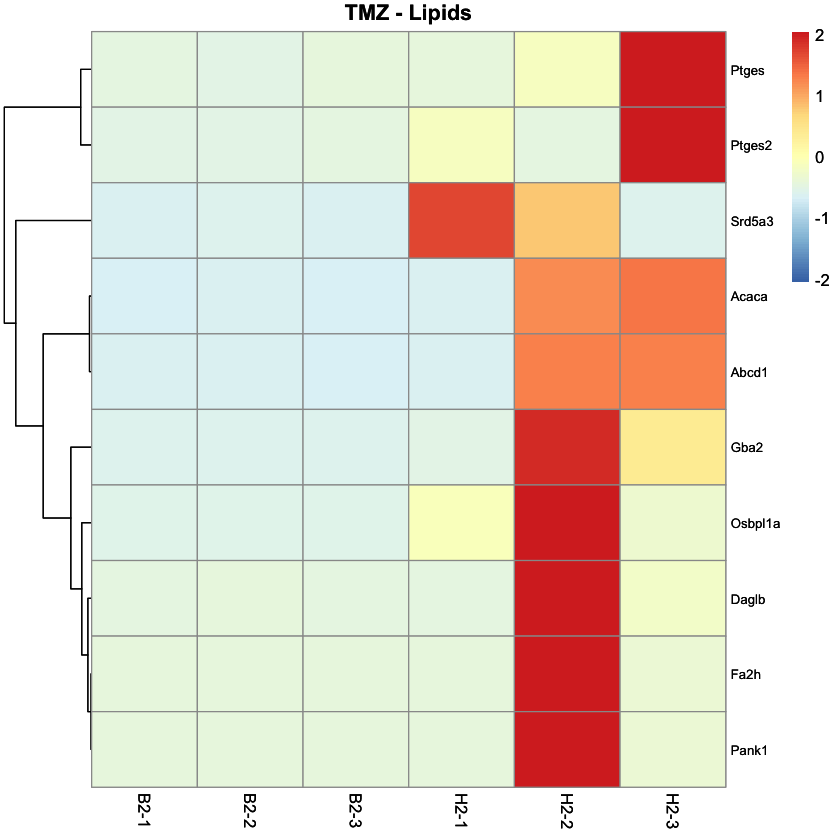

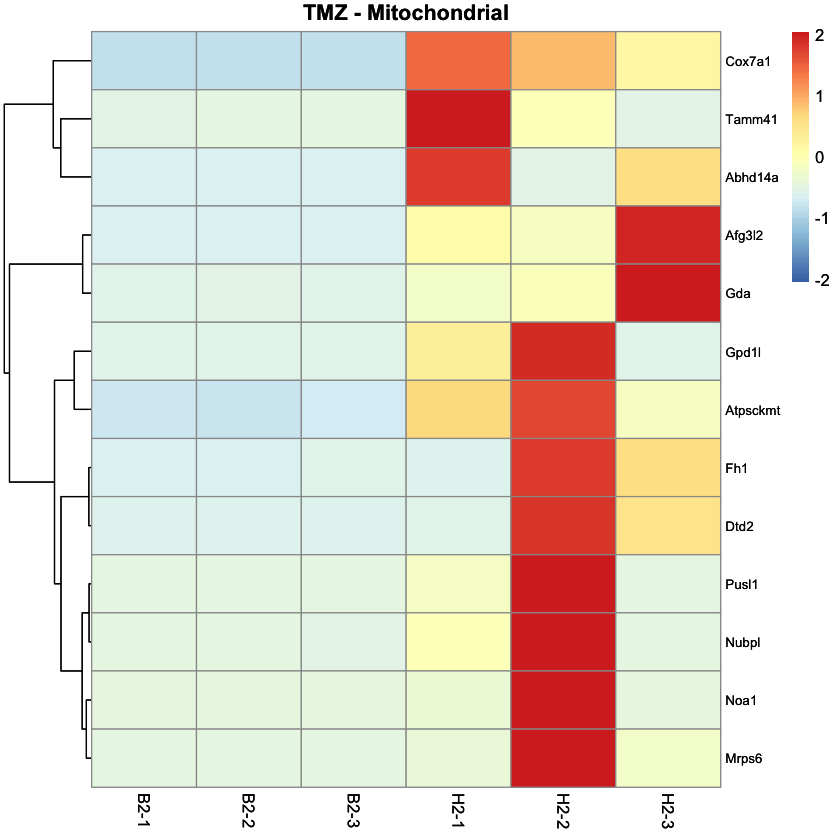

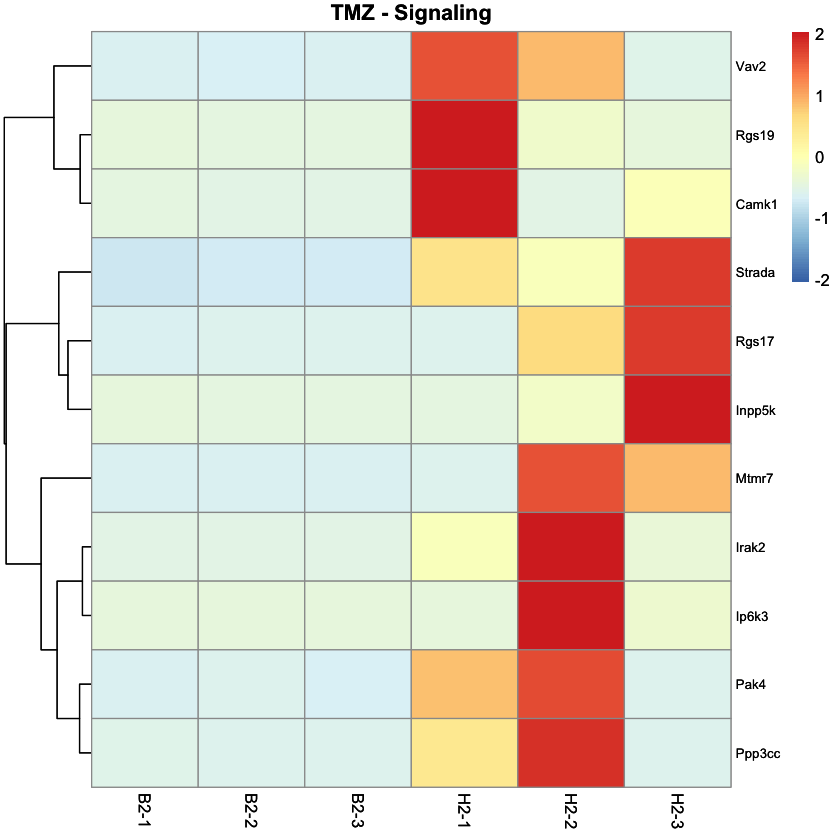

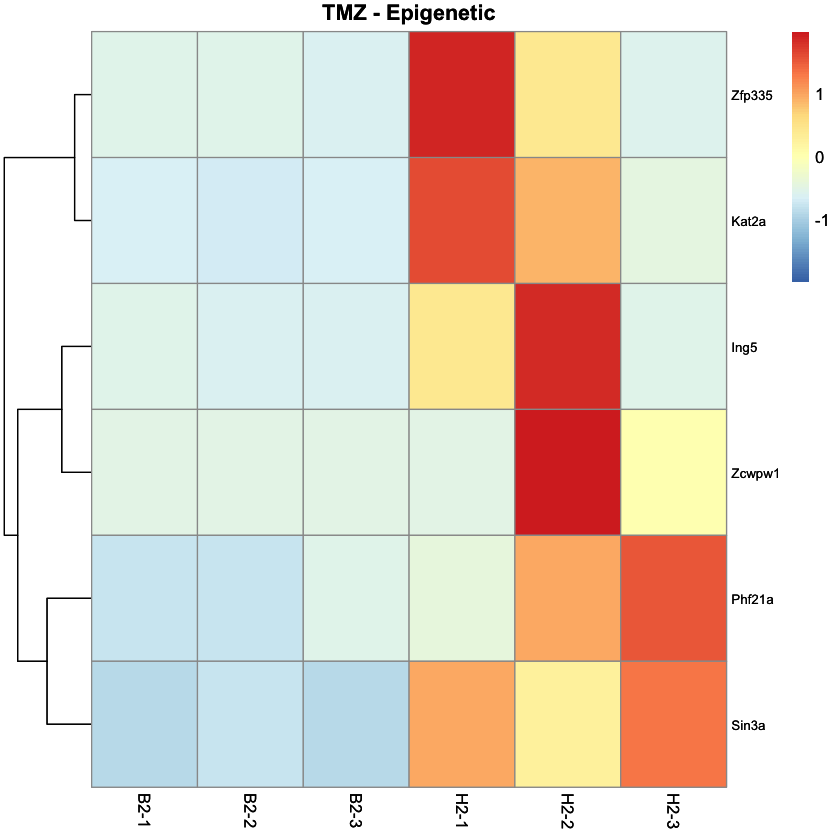

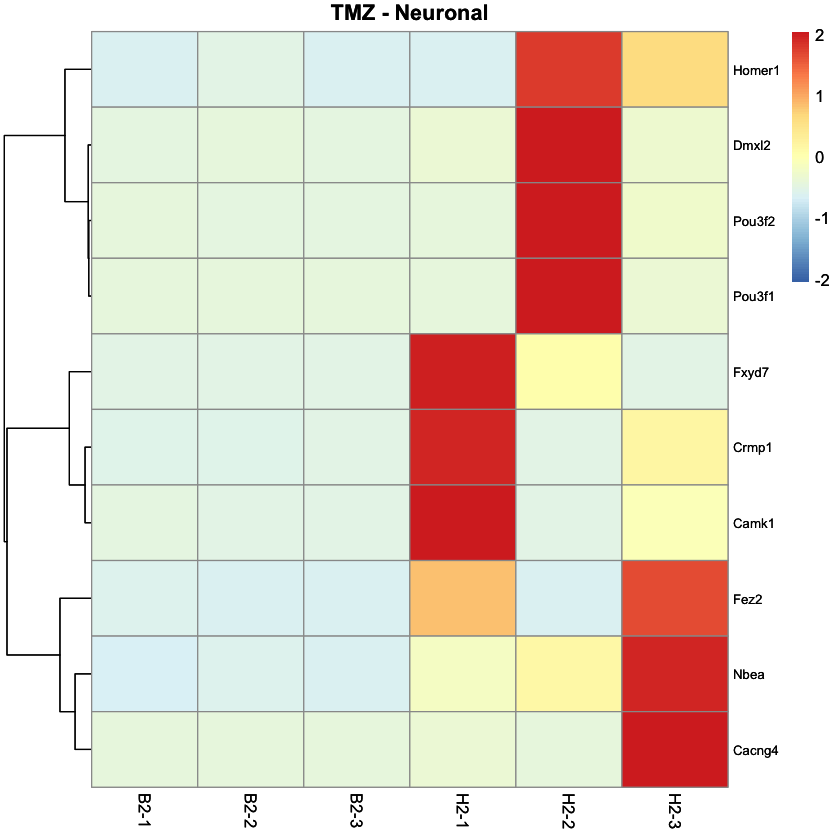

In [ ]:
# Z-score pathway heatmaps - TMZ
plot_pathway_heatmap_zscore <- function(genes, res, df, title) {
  subset <- res[rownames(res) %in% genes, ]
  df_plot <- df[rownames(subset), order(colnames(df))]
  df_plot <- df_plot[rowSums(df_plot) > 0, ]
  if (nrow(df_plot) == 0) {
    cat("No genes found for:", title, "\n")
    return(NULL)
  }
  print(pheatmap(df_plot, scale = "row", cluster_cols = FALSE,
                 cluster_rows = TRUE, show_rownames = TRUE,
                 fontsize_row = 8, main = title))
}

plot_pathway_heatmap_zscore(prostaglandin, res_tmz, de_out_tmz$df, "TMZ - Prostaglandin")
plot_pathway_heatmap_zscore(glycosylceramide, res_tmz, de_out_tmz$df, "TMZ - Glycosylceramide Metabolism")
plot_pathway_heatmap_zscore(cell_cycle, res_tmz, de_out_tmz$df, "TMZ - Cell Cycle")
plot_pathway_heatmap_zscore(dna_repair, res_tmz, de_out_tmz$df, "TMZ - DNA Repair")
plot_pathway_heatmap_zscore(mtor_autophagy, res_tmz, de_out_tmz$df, "TMZ - mTOR/Autophagy")
plot_pathway_heatmap_zscore(transcriptional, res_tmz, de_out_tmz$df, "TMZ - Transcriptional Regulation")
plot_pathway_heatmap_zscore(jnk_mapk, res_tmz, de_out_tmz$df, "TMZ - JNK/MAPK Signalling")
plot_pathway_heatmap_zscore(cell_adhesion, res_tmz, de_out_tmz$df, "TMZ - Cell Adhesion")
plot_pathway_heatmap_zscore(glutamine_transport, res_tmz, de_out_tmz$df, "TMZ - Glutamine Transport")
plot_pathway_heatmap_zscore(rna_processing, res_tmz, de_out_tmz$df, "TMZ - RNA Processing")
plot_pathway_heatmap_zscore(nuclear_transport, res_tmz, de_out_tmz$df, "TMZ - Nuclear Transport")
plot_pathway_heatmap_zscore(interferon, res_tmz, de_out_tmz$df, "TMZ - Immune Response")
plot_pathway_heatmap_zscore(lipid_metabolism, res_tmz, de_out_tmz$df, "TMZ - Lipids")
plot_pathway_heatmap_zscore(mitochondrial, res_tmz, de_out_tmz$df, "TMZ - Mitochondrial")
plot_pathway_heatmap_zscore(signaling, res_tmz, de_out_tmz$df, "TMZ - Signaling")
plot_pathway_heatmap_zscore(epigenetic, res_tmz, de_out_tmz$df, "TMZ - Epigenetic")
plot_pathway_heatmap_zscore(neuronal, res_tmz, de_out_tmz$df, "TMZ - Neuronal")

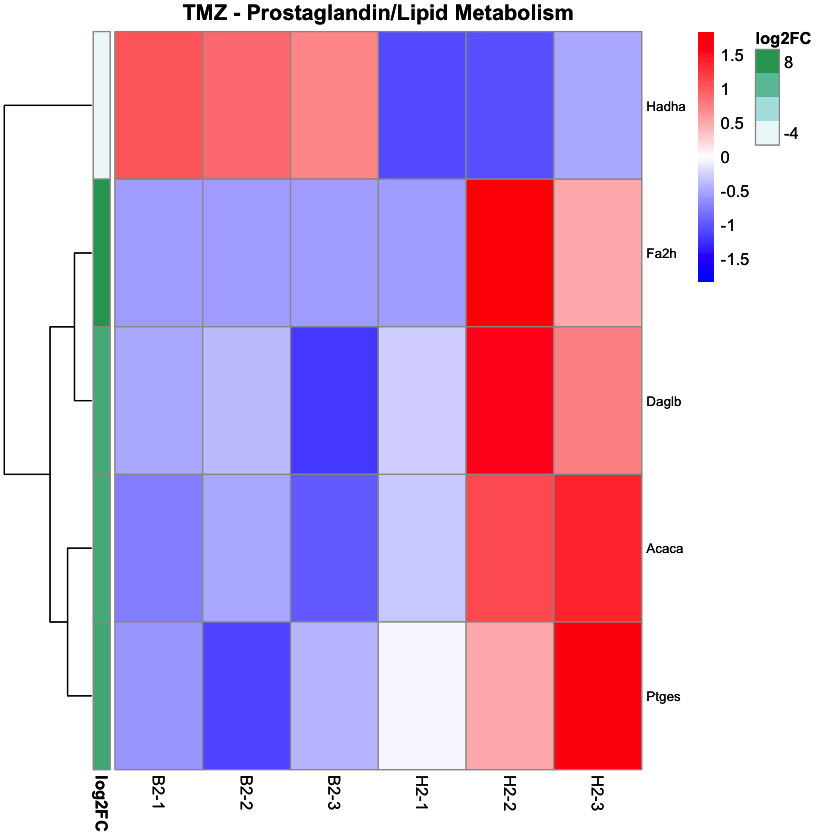

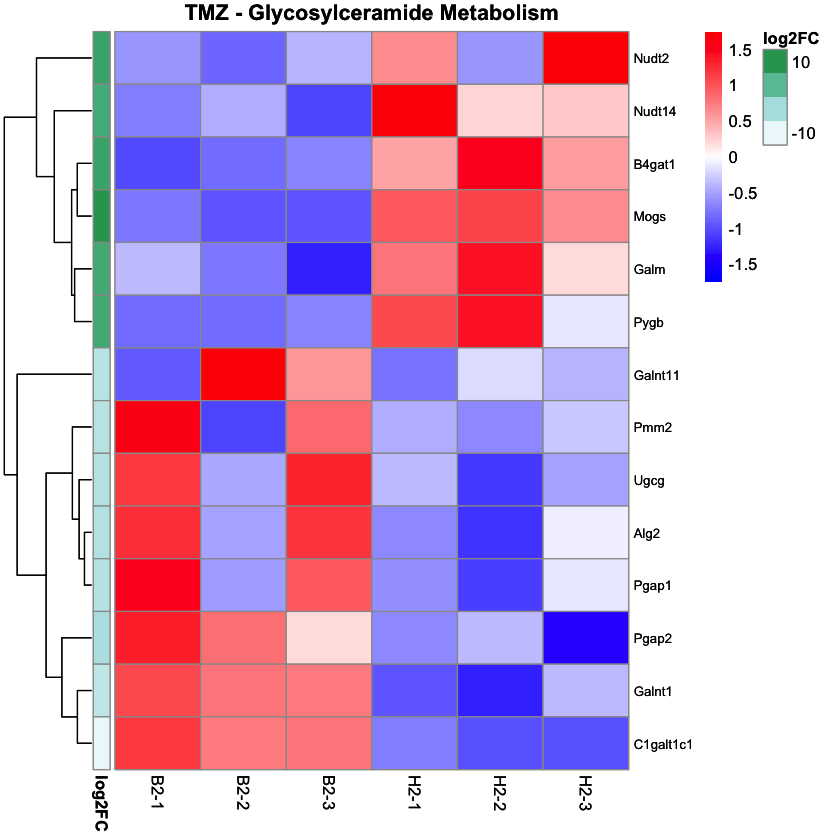

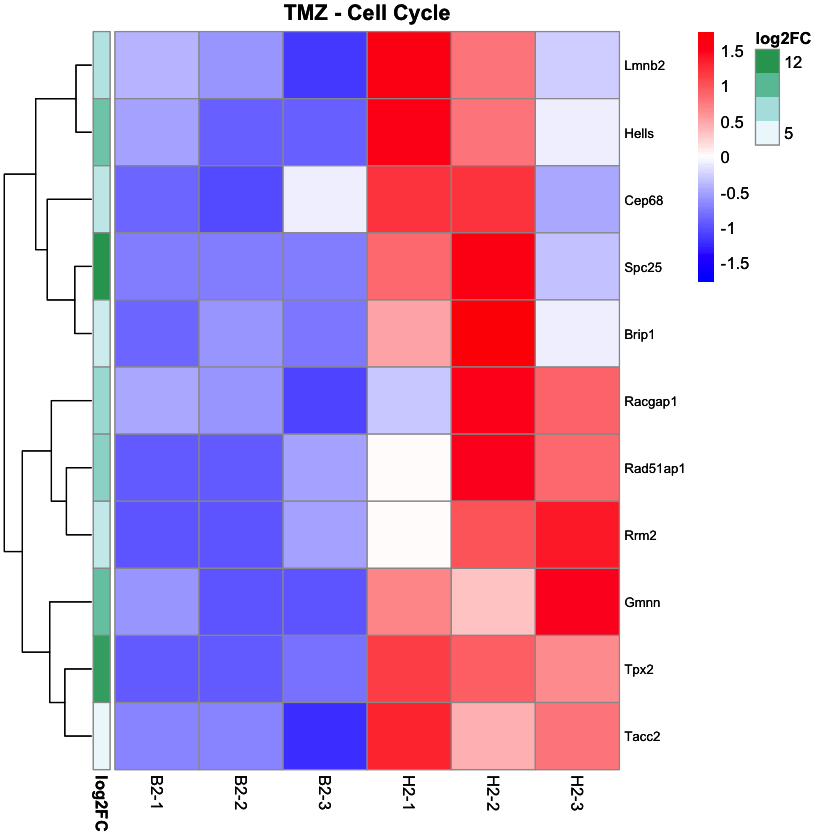

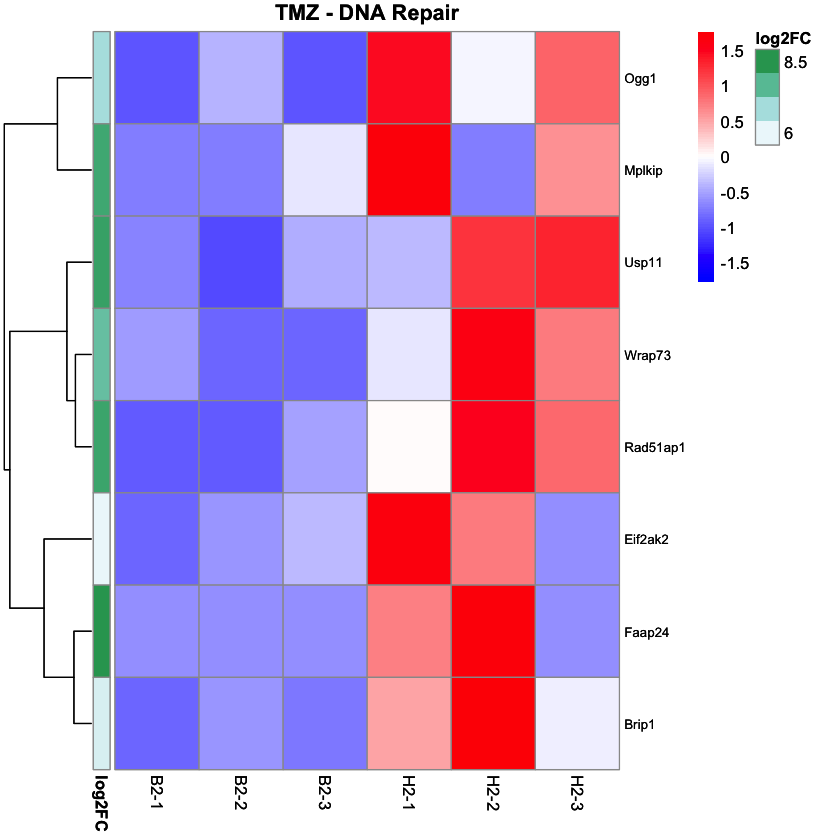

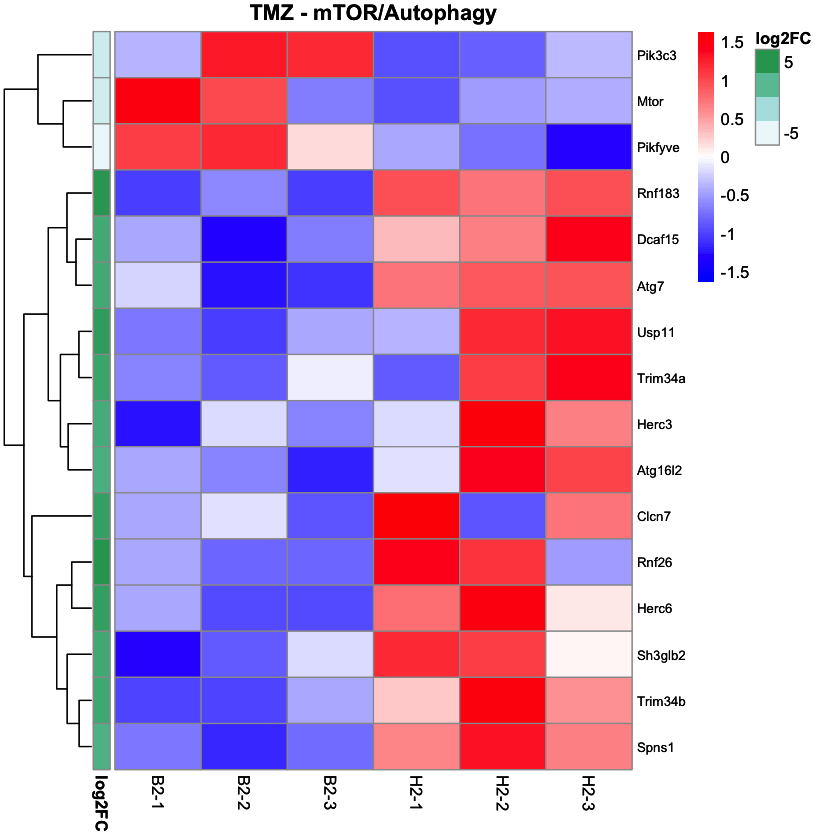

...

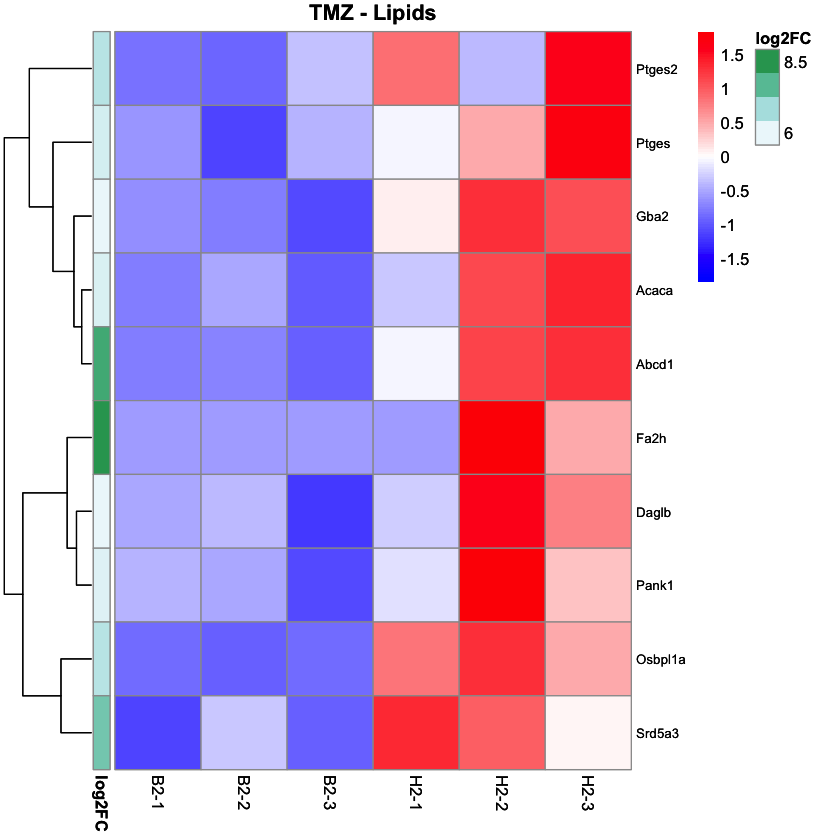

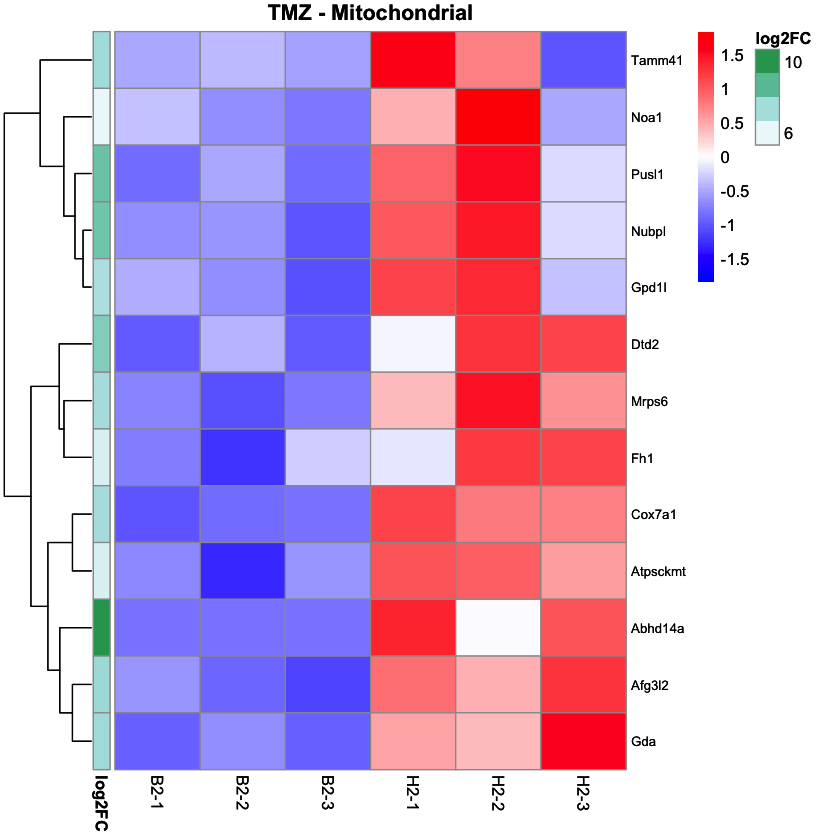

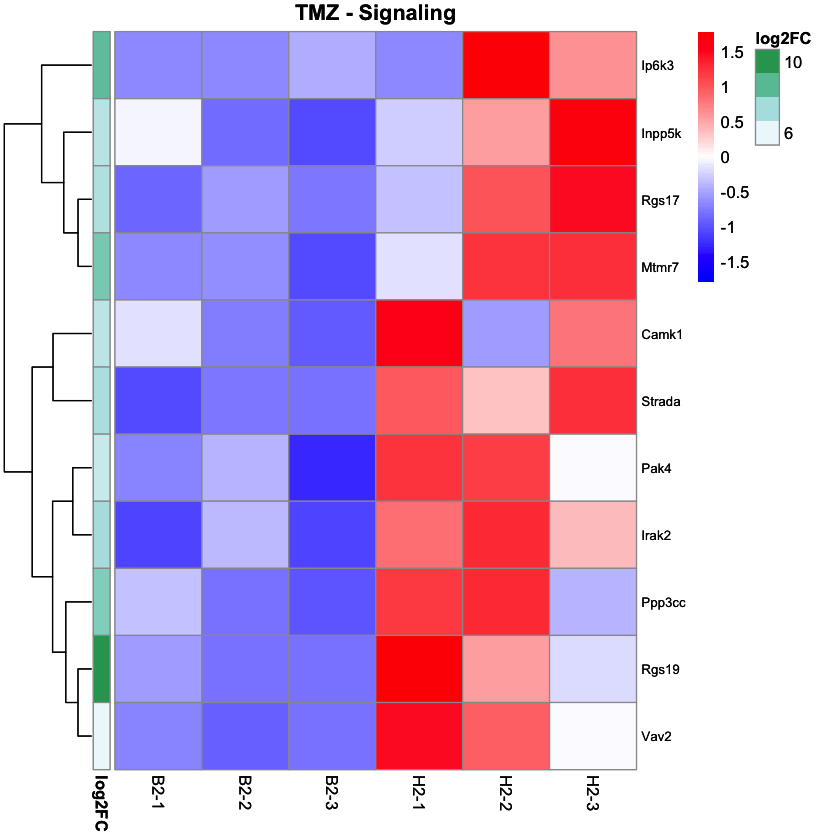

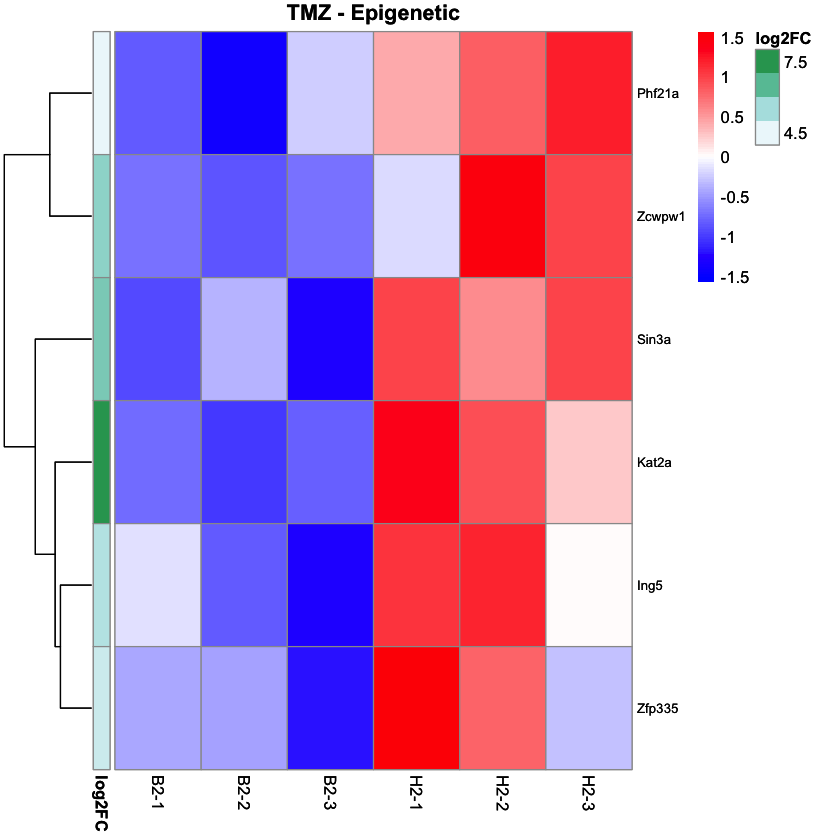

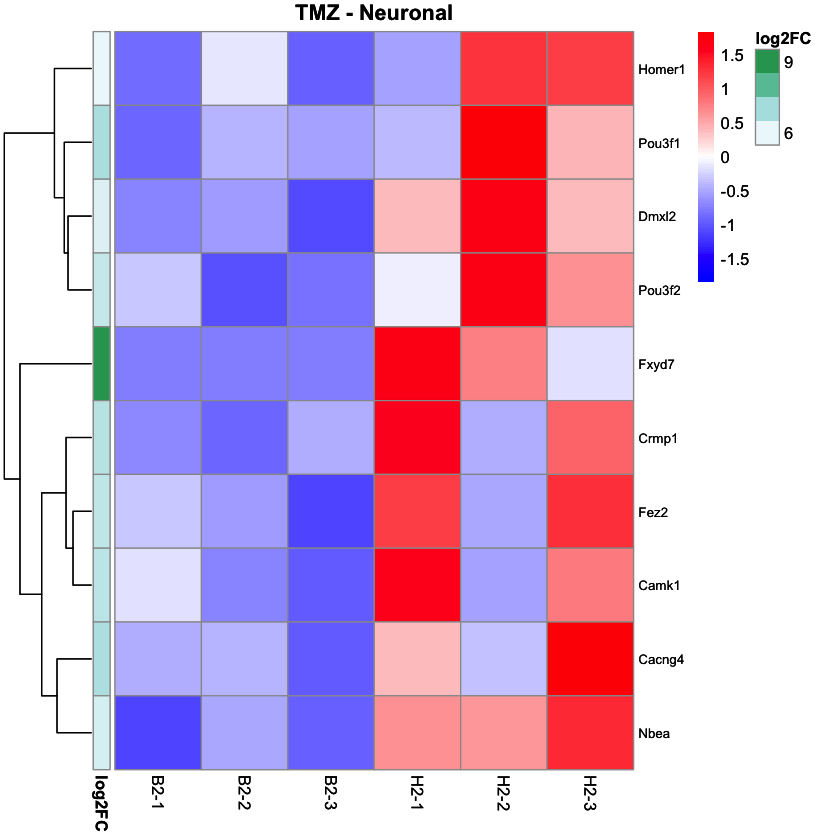

In [ ]:
# Get normalized counts for TMZ
norm_counts_tmz <- DESeq2::counts(de_out_tmz$dds, normalized = TRUE)

# LFC helper function for TMZ
plot_pathway_lfc_tmz <- function(genes, norm_counts, res, title) {
  genes_found <- genes[genes %in% rownames(norm_counts)]
  if (length(genes_found) == 0) {
    cat("No genes found for:", title, "\n")
    return(NULL)
  }
  df_plot <- log2(norm_counts[genes_found, ] + 1)
  df_plot <- df_plot[, order(colnames(df_plot))]
  lfc_vals <- round(as.data.frame(res[genes_found, "log2FoldChange"]), 2)
  rownames(lfc_vals) <- genes_found
  colnames(lfc_vals) <- "log2FC"
  print(pheatmap(df_plot, cluster_cols = FALSE, cluster_rows = TRUE,
                 show_rownames = TRUE, fontsize_row = 8, main = title,
                 scale = "row", annotation_row = lfc_vals,
                 color = colorRampPalette(c("blue", "white", "red"))(100)))
}

plot_pathway_lfc_tmz(prostaglandin, norm_counts_tmz, res_tmz, "TMZ - Prostaglandin/Lipid Metabolism")
plot_pathway_lfc_tmz(glycosylceramide, norm_counts_tmz, res_tmz, "TMZ - Glycosylceramide Metabolism")
plot_pathway_lfc_tmz(cell_cycle, norm_counts_tmz, res_tmz, "TMZ - Cell Cycle")
plot_pathway_lfc_tmz(dna_repair, norm_counts_tmz, res_tmz, "TMZ - DNA Repair")
plot_pathway_lfc_tmz(mtor_autophagy, norm_counts_tmz, res_tmz, "TMZ - mTOR/Autophagy")
plot_pathway_lfc_tmz(transcriptional, norm_counts_tmz, res_tmz, "TMZ - Transcriptional Regulation")
plot_pathway_lfc_tmz(jnk_mapk, norm_counts_tmz, res_tmz, "TMZ - JNK/MAPK Signalling")
plot_pathway_lfc_tmz(cell_adhesion, norm_counts_tmz, res_tmz, "TMZ - Cell Adhesion")
plot_pathway_lfc_tmz(glutamine_transport, norm_counts_tmz, res_tmz, "TMZ - Glutamine Transport")
plot_pathway_lfc_tmz(rna_processing, norm_counts_tmz, res_tmz, "TMZ - RNA Processing")
plot_pathway_lfc_tmz(nuclear_transport, norm_counts_tmz, res_tmz, "TMZ - Nuclear Transport")
plot_pathway_lfc_tmz(interferon, norm_counts_tmz, res_tmz, "TMZ - Immune Response")
plot_pathway_lfc_tmz(lipid_metabolism, norm_counts_tmz, res_tmz, "TMZ - Lipids")
plot_pathway_lfc_tmz(mitochondrial, norm_counts_tmz, res_tmz, "TMZ - Mitochondrial")
plot_pathway_lfc_tmz(signaling, norm_counts_tmz, res_tmz, "TMZ - Signaling")
plot_pathway_lfc_tmz(epigenetic, norm_counts_tmz, res_tmz, "TMZ - Epigenetic")
plot_pathway_lfc_tmz(neuronal, norm_counts_tmz, res_tmz, "TMZ - Neuronal")

# Healthy vs Glioma (Same Pathways)

In [ ]:
# AUF glioma
de_out_auf_glioma <- getDEresults_safe(countsRAW, meta, tissue = "Glioma", treatment = "AUF")
res_auf_glioma <- DESeq2::results(de_out_auf_glioma$dds)
sig_genes_auf_glioma <- res_auf_glioma[!is.na(res_auf_glioma$padj) & res_auf_glioma$padj < 0.05, ]

# TMZ glioma
de_out_tmz_glioma <- getDEresults_safe(countsRAW, meta, tissue = "Glioma", treatment = "TMZ")
res_tmz_glioma <- DESeq2::results(de_out_tmz_glioma$dds)
sig_genes_tmz_glioma <- res_tmz_glioma[!is.na(res_tmz_glioma$padj) & res_tmz_glioma$padj < 0.05, ]

# Normalized counts
norm_counts_auf_glioma <- DESeq2::counts(de_out_auf_glioma$dds, normalized = TRUE)
norm_counts_tmz_glioma <- DESeq2::counts(de_out_tmz_glioma$dds, normalized = TRUE)

converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [ ]:
exists("de_out_auf_glioma")
exists("res_auf_glioma")
exists("sig_genes_auf_glioma")
exists("de_out_tmz_glioma")
exists("res_tmz_glioma")
exists("sig_genes_tmz_glioma")

[1] TRUE

[1] TRUE

[1] TRUE

[1] TRUE

[1] TRUE

[1] TRUE

AUF Glioma - Genes found in pathways: 190 
AUF Glioma - Genes not significant: Stampbp 


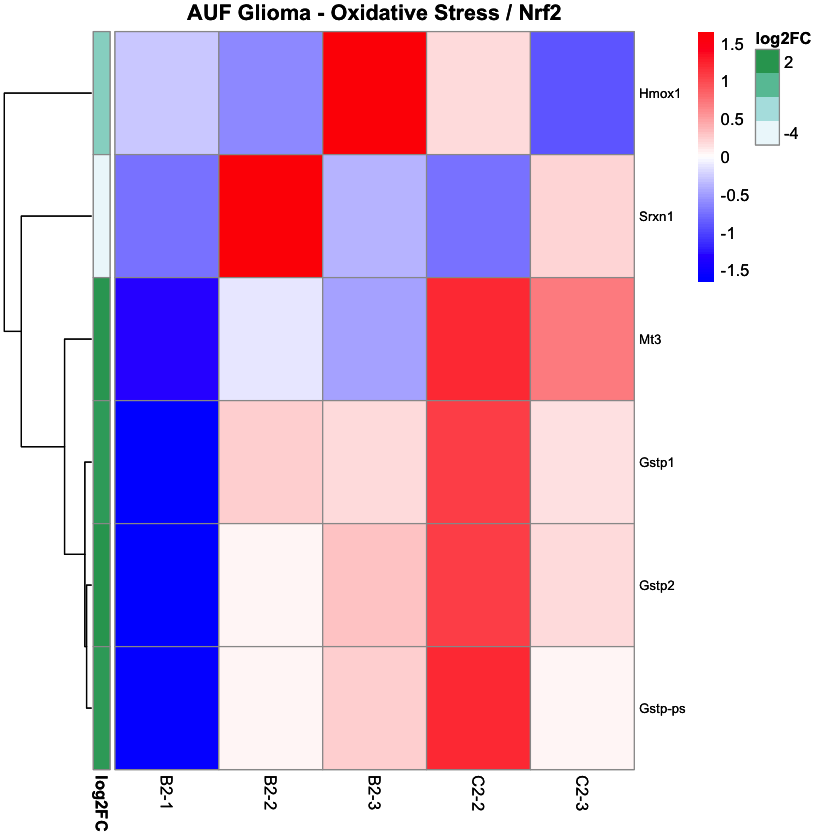

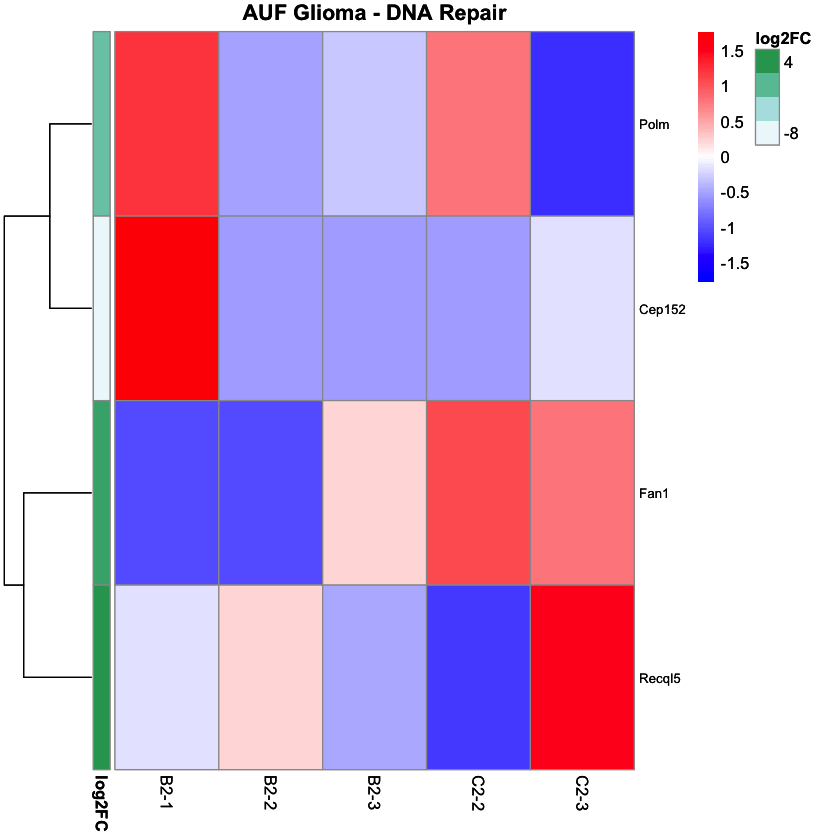

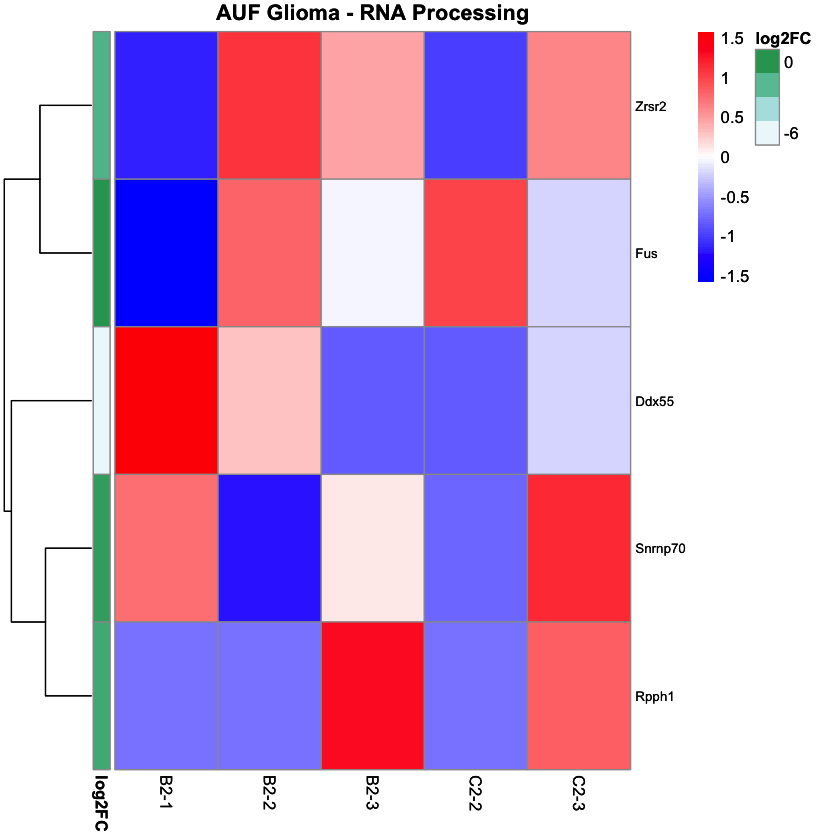

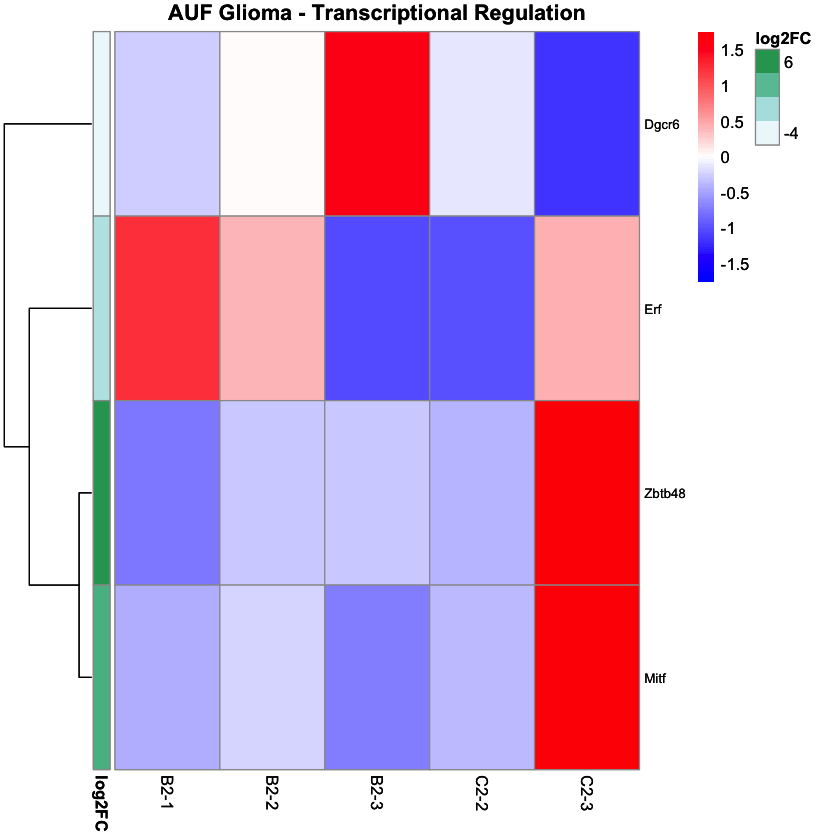

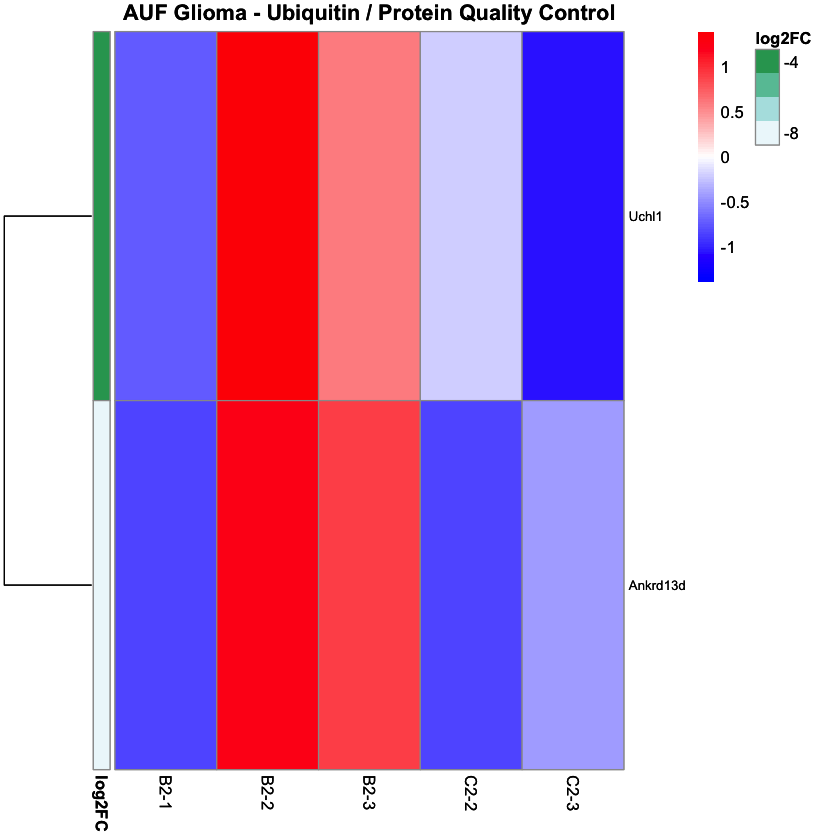

...

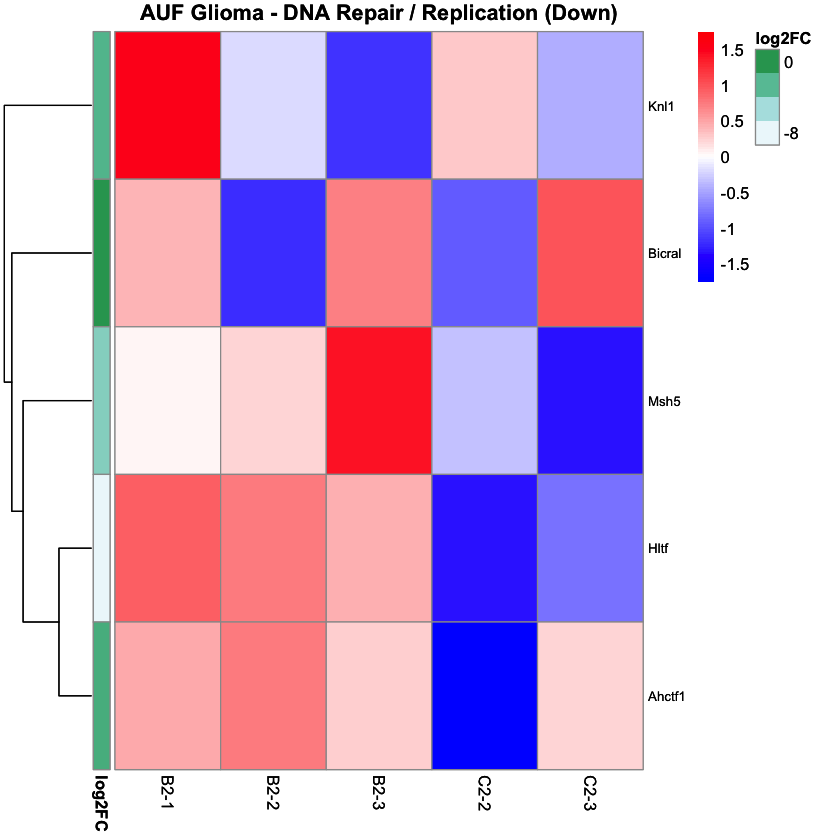

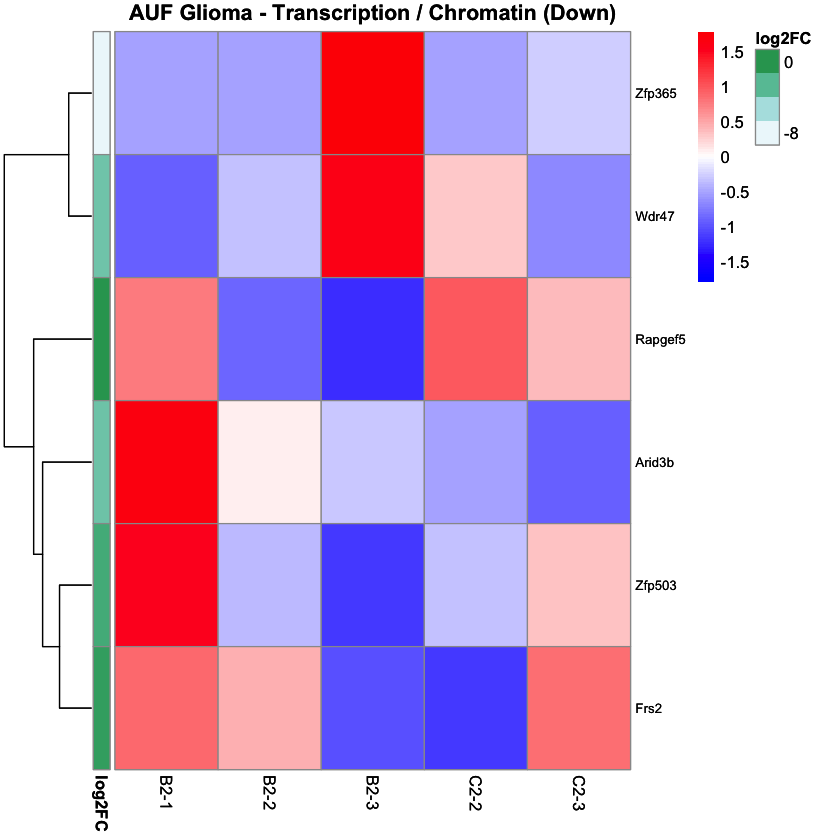

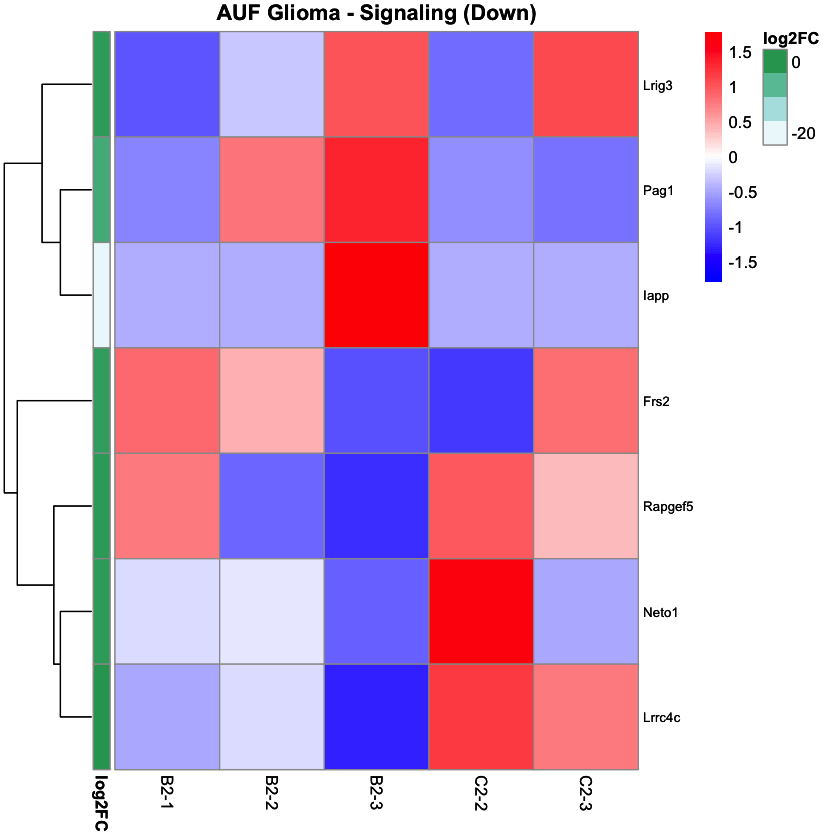

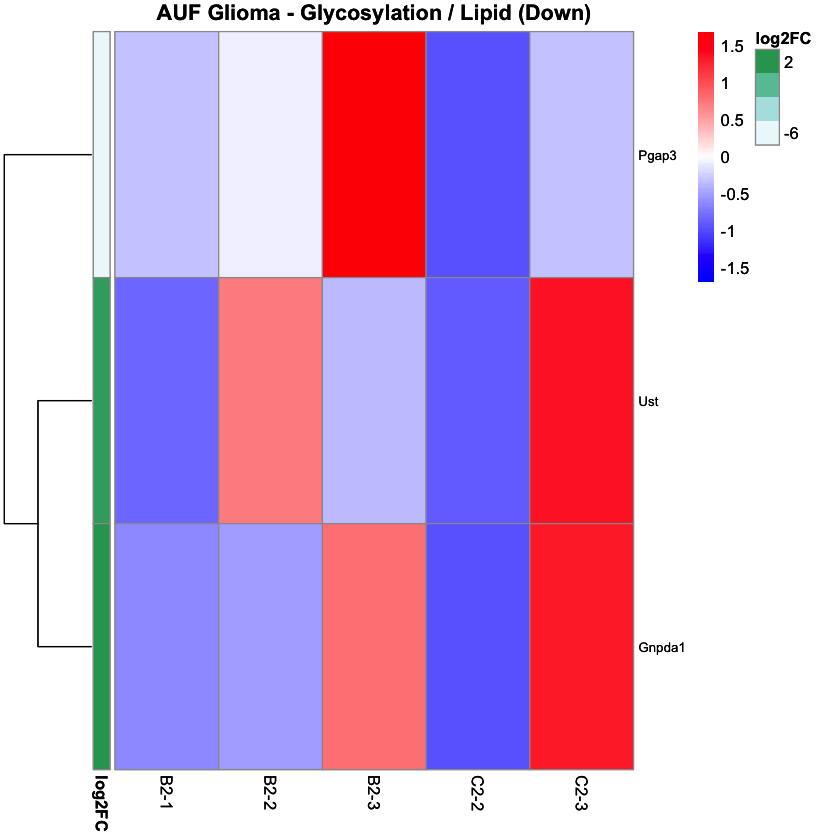

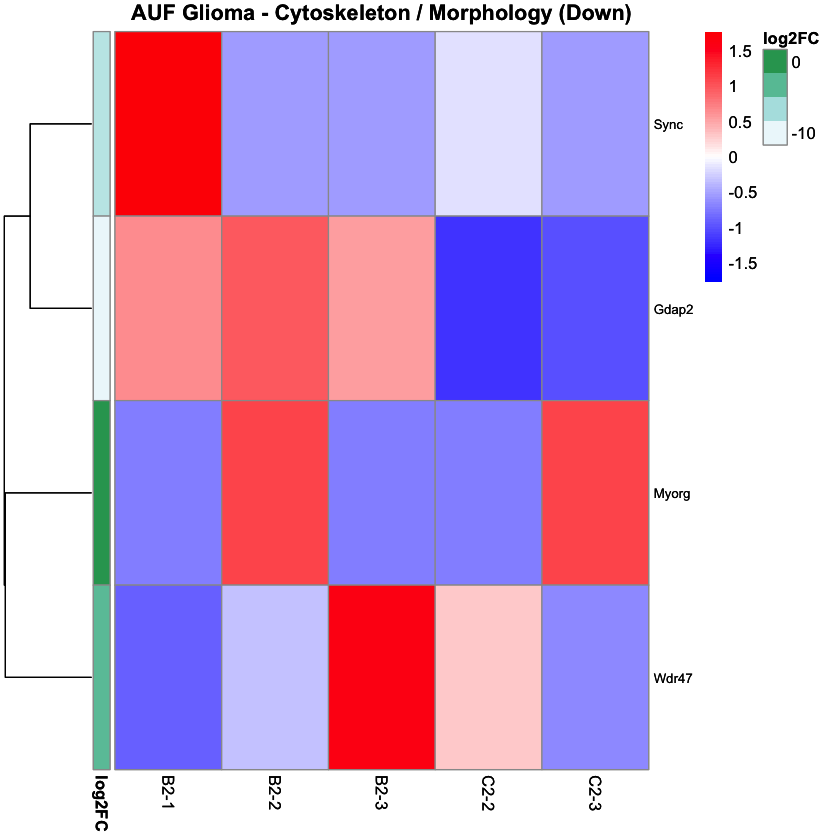

TMZ Glioma - Genes found in pathways: 177 
TMZ Glioma - Genes not significant:  


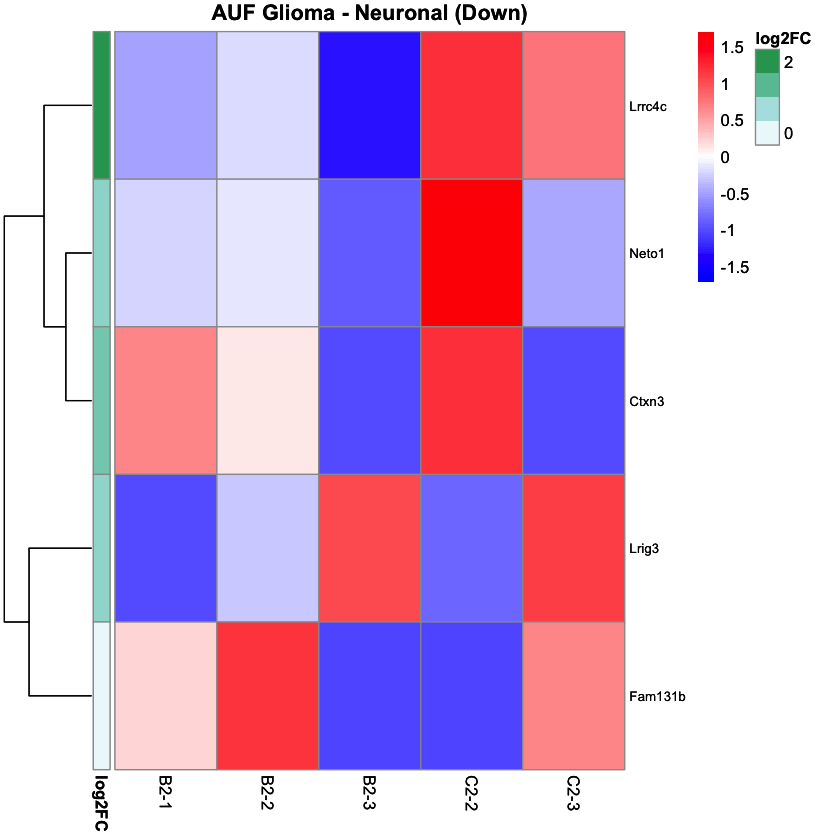

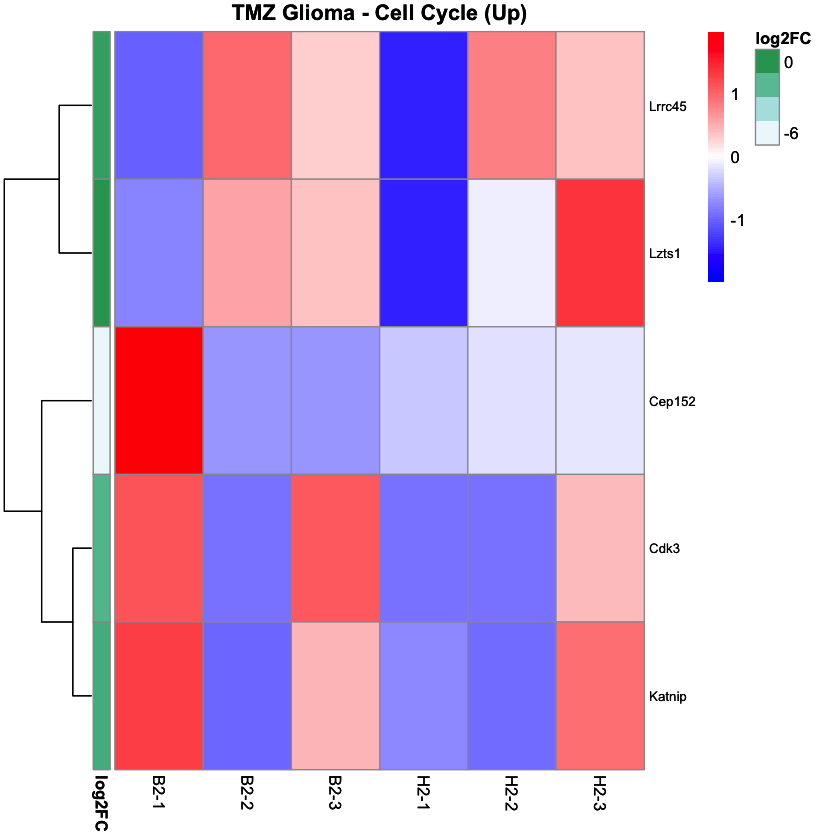

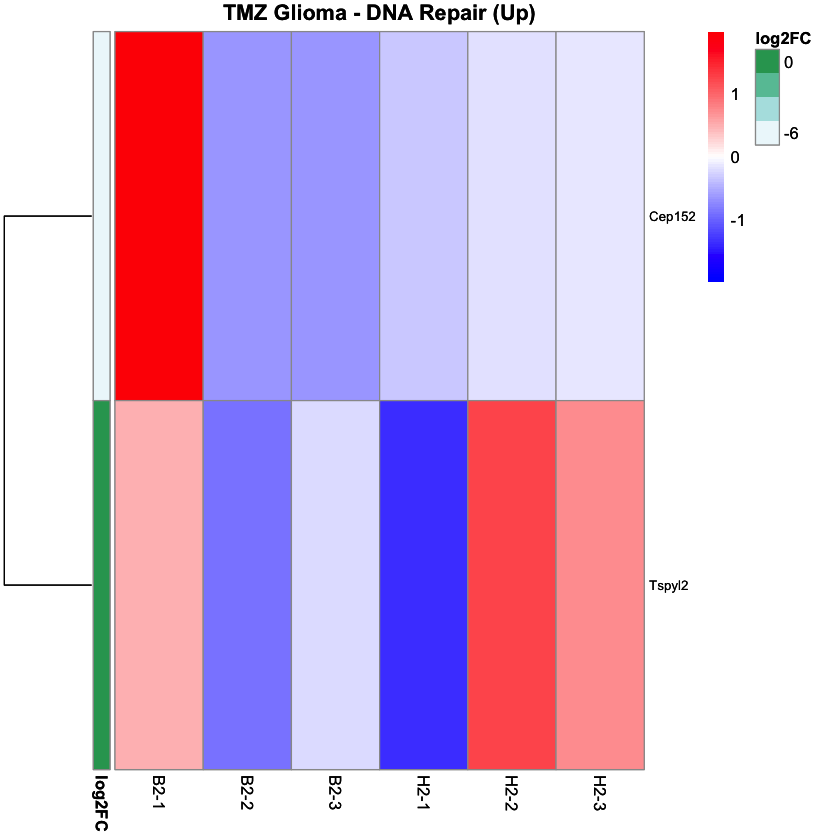

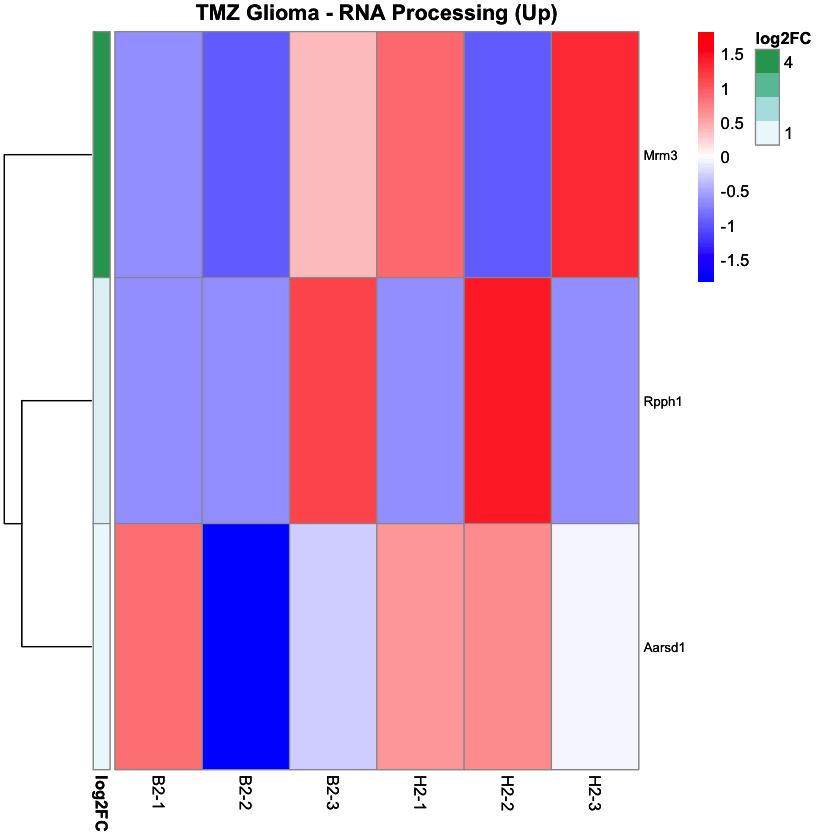

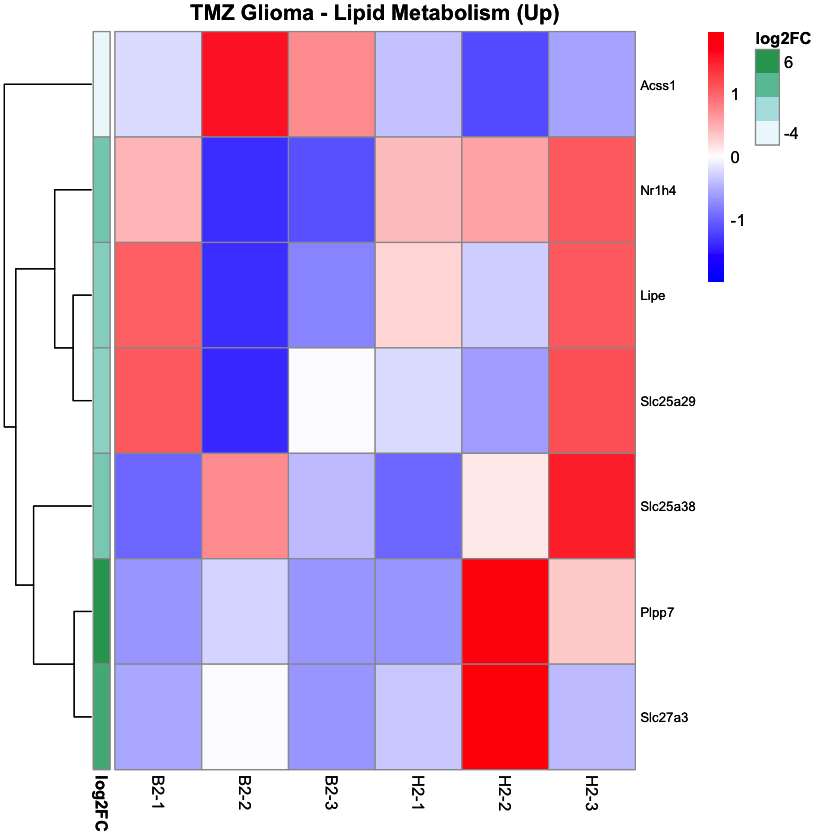

...

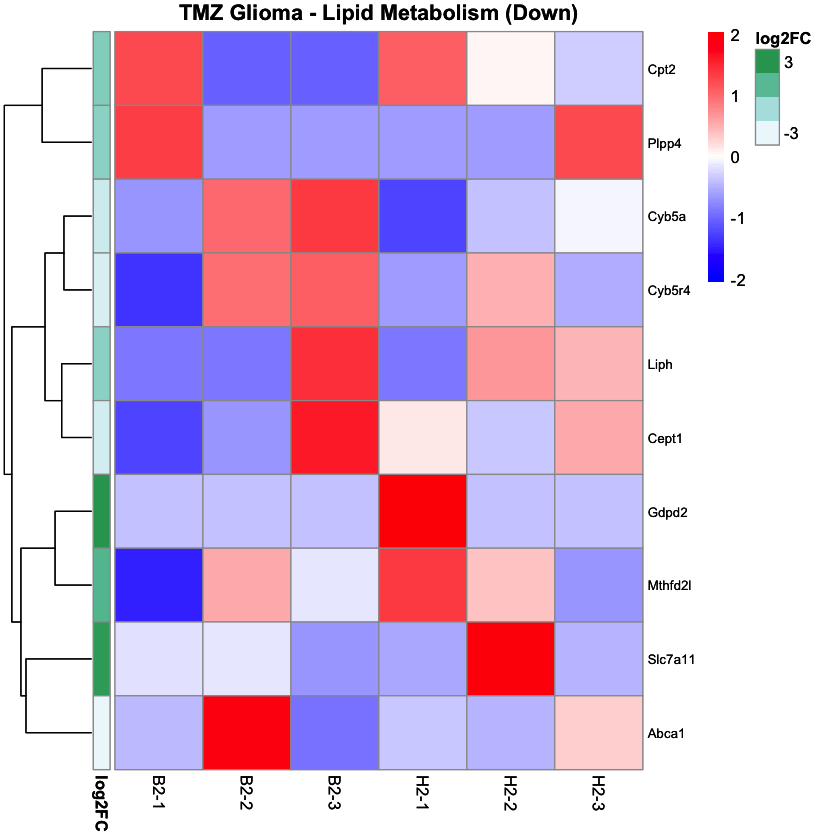

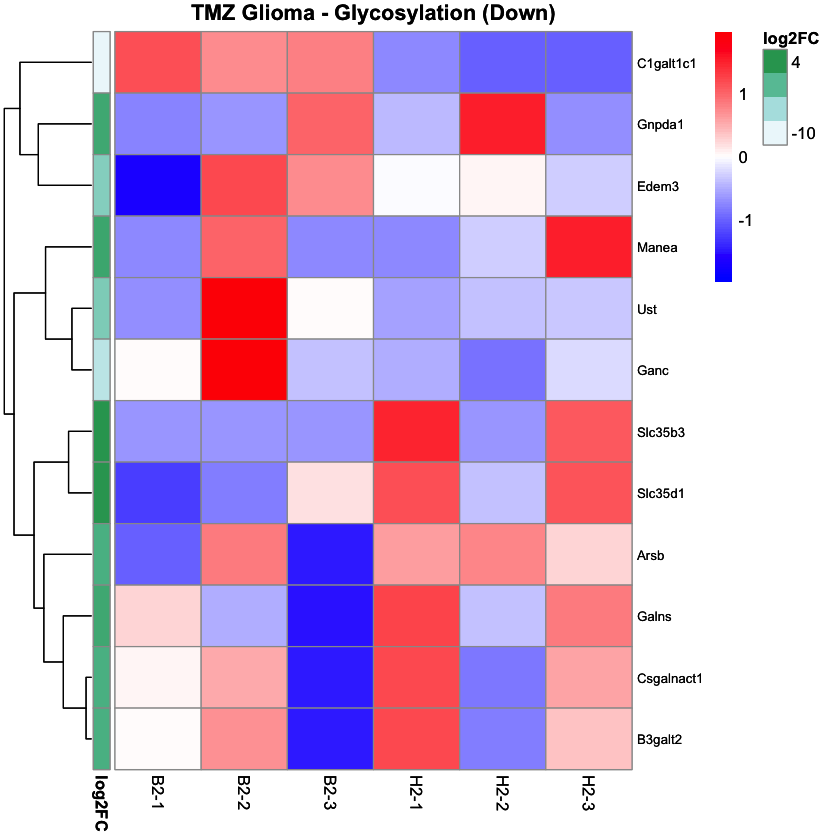

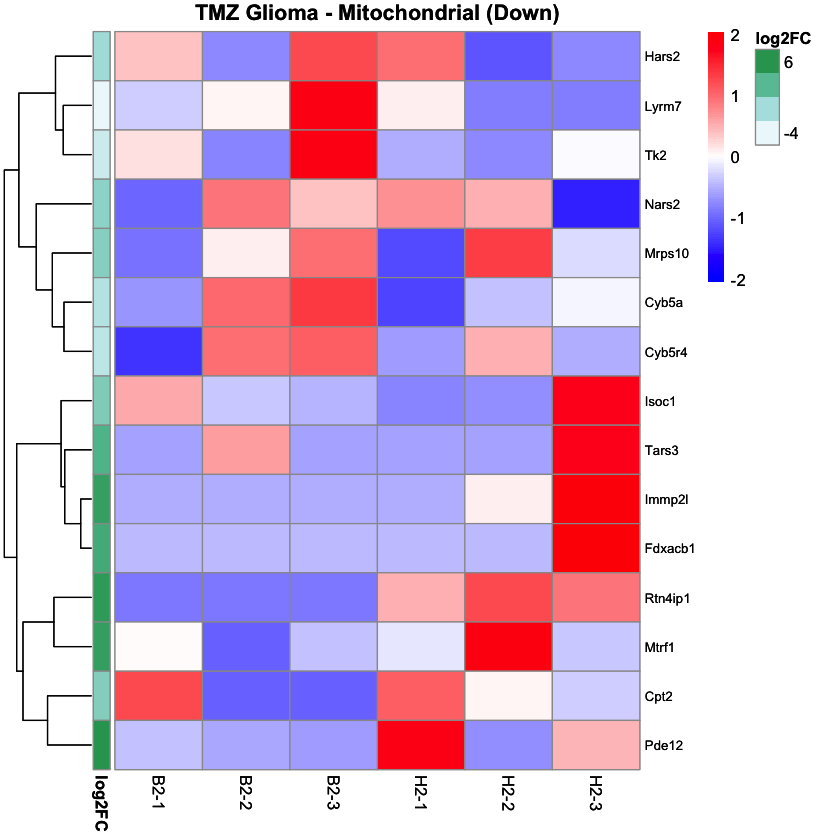

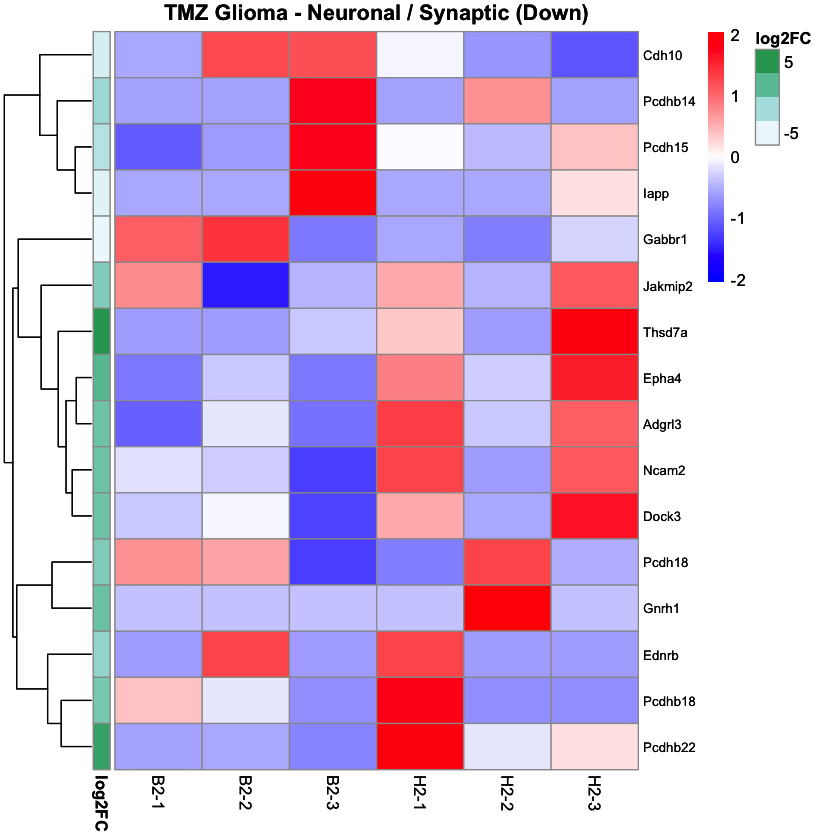

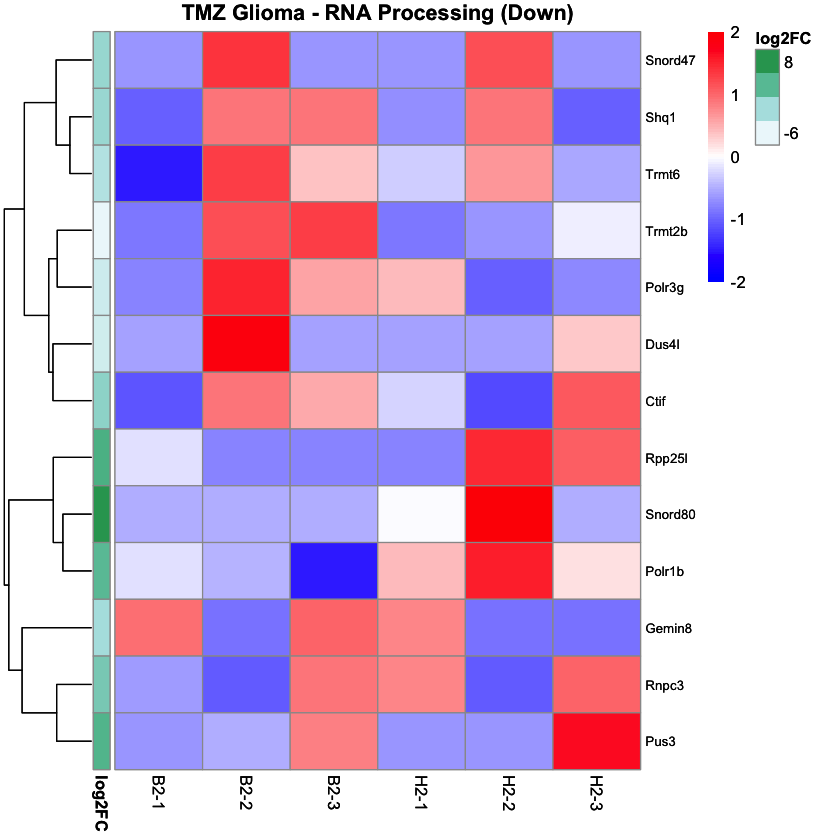

In [ ]:
# ── FUNCTION DEFINITIONS ──────────────────────────────────────────────────────

plot_pathway_heatmap <- function(genes, res, df, title) {
  subset <- res[rownames(res) %in% genes, ]
  df_plot <- df[rownames(subset), , drop = FALSE]
  df_plot <- as.matrix(df_plot)
  col_order <- order(as.character(colnames(df_plot)))
  df_plot <- df_plot[, col_order, drop = FALSE]
  df_plot <- df_plot[rowSums(df_plot) > 0, , drop = FALSE]
  if (nrow(df_plot) == 0) {
    cat("No genes found for:", title, "\n")
    return(NULL)
  }
  do_cluster <- nrow(df_plot) >= 2
  print(pheatmap(df_plot, scale = "row", cluster_cols = FALSE,
                 cluster_rows = do_cluster, show_rownames = TRUE,
                 fontsize_row = 8, main = title))
}

plot_pathway_heatmap_lfc <- function(genes, norm_counts, res, title) {
  genes_found <- genes[genes %in% rownames(norm_counts)]
  if (length(genes_found) == 0) {
    cat("No genes found for:", title, "\n")
    return(NULL)
  }
  df_plot <- log2(norm_counts[genes_found, , drop = FALSE] + 1)
  df_plot <- as.matrix(df_plot)
  df_plot <- df_plot[, order(as.character(colnames(df_plot))), drop = FALSE]
  df_plot <- df_plot[rowSums(df_plot) > 0, , drop = FALSE]
  if (nrow(df_plot) == 0) {
    cat("No expressed genes for:", title, "\n")
    return(NULL)
  }
  lfc_vals <- round(as.data.frame(res[rownames(df_plot), "log2FoldChange"]), 2)
  rownames(lfc_vals) <- rownames(df_plot)
  colnames(lfc_vals) <- "log2FC"
  do_cluster <- nrow(df_plot) >= 2
  print(pheatmap(df_plot, cluster_cols = FALSE, cluster_rows = do_cluster,
                 show_rownames = TRUE, fontsize_row = 8, main = title,
                 scale = "row",
                 annotation_row = lfc_vals,
                 color = colorRampPalette(c("blue", "white", "red"))(100)))
}

# ── AUF GLIOMA ────────────────────────────────────────────────────────────────

sig_subset_auf_glioma <- sig_genes_auf_glioma[rownames(sig_genes_auf_glioma) %in% all_pathways_auf, ]
cat("AUF Glioma - Genes found in pathways:", nrow(sig_subset_auf_glioma), "\n")
cat("AUF Glioma - Genes not significant:", all_pathways_auf[!all_pathways_auf %in% rownames(sig_genes_auf_glioma)], "\n")

plot_pathway_heatmap_lfc(auf_up_oxidative_stress, norm_counts_auf_glioma, res_auf_glioma,
                          "AUF Glioma - Oxidative Stress / Nrf2")
plot_pathway_heatmap_lfc(auf_up_dna_repair, norm_counts_auf_glioma, res_auf_glioma,
                          "AUF Glioma - DNA Repair")
plot_pathway_heatmap_lfc(auf_up_rna_processing, norm_counts_auf_glioma, res_auf_glioma,
                          "AUF Glioma - RNA Processing")
plot_pathway_heatmap_lfc(auf_up_transcription, norm_counts_auf_glioma, res_auf_glioma,
                          "AUF Glioma - Transcriptional Regulation")
plot_pathway_heatmap_lfc(auf_up_ubiquitin_protein, norm_counts_auf_glioma, res_auf_glioma,
                          "AUF Glioma - Ubiquitin / Protein Quality Control")
plot_pathway_heatmap_lfc(auf_up_mitochondrial, norm_counts_auf_glioma, res_auf_glioma,
                          "AUF Glioma - Mitochondrial")
plot_pathway_heatmap_lfc(auf_up_nuclear_structure, norm_counts_auf_glioma, res_auf_glioma,
                          "AUF Glioma - Nuclear Structure")
plot_pathway_heatmap_lfc(auf_up_cytoskeleton_scaffold, norm_counts_auf_glioma, res_auf_glioma,
                          "AUF Glioma - Cytoskeleton / Scaffold")
plot_pathway_heatmap_lfc(auf_up_secreted_extracellular, norm_counts_auf_glioma, res_auf_glioma,
                          "AUF Glioma - Secreted / Extracellular")
plot_pathway_heatmap_lfc(auf_up_ribosome, norm_counts_auf_glioma, res_auf_glioma,
                          "AUF Glioma - Ribosome / Translation")
plot_pathway_heatmap_lfc(auf_dn_immune_inflammation, norm_counts_auf_glioma, res_auf_glioma,
                          "AUF Glioma - Immune / Inflammation (Down)")
plot_pathway_heatmap_lfc(auf_dn_dna_repair_replication, norm_counts_auf_glioma, res_auf_glioma,
                          "AUF Glioma - DNA Repair / Replication (Down)")
plot_pathway_heatmap_lfc(auf_dn_transcription_chromatin, norm_counts_auf_glioma, res_auf_glioma,
                          "AUF Glioma - Transcription / Chromatin (Down)")
plot_pathway_heatmap_lfc(auf_dn_signaling, norm_counts_auf_glioma, res_auf_glioma,
                          "AUF Glioma - Signaling (Down)")
plot_pathway_heatmap_lfc(auf_dn_glycosylation_lipid, norm_counts_auf_glioma, res_auf_glioma,
                          "AUF Glioma - Glycosylation / Lipid (Down)")
plot_pathway_heatmap_lfc(auf_dn_cytoskeleton_morphology, norm_counts_auf_glioma, res_auf_glioma,
                          "AUF Glioma - Cytoskeleton / Morphology (Down)")
plot_pathway_heatmap_lfc(auf_dn_neuronal, norm_counts_auf_glioma, res_auf_glioma,
                          "AUF Glioma - Neuronal (Down)")

# ── TMZ GLIOMA ────────────────────────────────────────────────────────────────

sig_subset_tmz_glioma <- sig_genes_tmz_glioma[rownames(sig_genes_tmz_glioma) %in% all_pathways_tmz, ]
cat("TMZ Glioma - Genes found in pathways:", nrow(sig_subset_tmz_glioma), "\n")
cat("TMZ Glioma - Genes not significant:", all_pathways_tmz[!all_pathways_tmz %in% rownames(sig_genes_tmz_glioma)], "\n")

plot_pathway_heatmap_lfc(tmz_up_cell_cycle, norm_counts_tmz_glioma, res_tmz_glioma,
                          "TMZ Glioma - Cell Cycle (Up)")
plot_pathway_heatmap_lfc(tmz_up_dna_repair, norm_counts_tmz_glioma, res_tmz_glioma,
                          "TMZ Glioma - DNA Repair (Up)")
plot_pathway_heatmap_lfc(tmz_up_rna_processing, norm_counts_tmz_glioma, res_tmz_glioma,
                          "TMZ Glioma - RNA Processing (Up)")
plot_pathway_heatmap_lfc(tmz_up_lipid_metabolism, norm_counts_tmz_glioma, res_tmz_glioma,
                          "TMZ Glioma - Lipid Metabolism (Up)")
plot_pathway_heatmap_lfc(tmz_up_signaling, norm_counts_tmz_glioma, res_tmz_glioma,
                          "TMZ Glioma - Signaling (Up)")
plot_pathway_heatmap_lfc(tmz_up_transcription, norm_counts_tmz_glioma, res_tmz_glioma,
                          "TMZ Glioma - Transcription (Up)")
plot_pathway_heatmap_lfc(tmz_up_vesicle_trafficking, norm_counts_tmz_glioma, res_tmz_glioma,
                          "TMZ Glioma - Vesicle Trafficking (Up)")
plot_pathway_heatmap_lfc(tmz_up_cytoskeleton, norm_counts_tmz_glioma, res_tmz_glioma,
                          "TMZ Glioma - Cytoskeleton (Up)")
plot_pathway_heatmap_lfc(tmz_up_extracellular_matrix, norm_counts_tmz_glioma, res_tmz_glioma,
                          "TMZ Glioma - Extracellular Matrix (Up)")
plot_pathway_heatmap_lfc(tmz_up_mitochondrial, norm_counts_tmz_glioma, res_tmz_glioma,
                          "TMZ Glioma - Mitochondrial (Up)")
plot_pathway_heatmap_lfc(tmz_dn_dna_repair_replication, norm_counts_tmz_glioma, res_tmz_glioma,
                          "TMZ Glioma - DNA Repair / Replication (Down)")
plot_pathway_heatmap_lfc(tmz_dn_cell_cycle, norm_counts_tmz_glioma, res_tmz_glioma,
                          "TMZ Glioma - Cell Cycle (Down)")
plot_pathway_heatmap_lfc(tmz_dn_apoptosis, norm_counts_tmz_glioma, res_tmz_glioma,
                          "TMZ Glioma - Apoptosis (Down)")
plot_pathway_heatmap_lfc(tmz_dn_transcription_chromatin, norm_counts_tmz_glioma, res_tmz_glioma,
                          "TMZ Glioma - Transcription / Chromatin (Down)")
plot_pathway_heatmap_lfc(tmz_dn_signaling, norm_counts_tmz_glioma, res_tmz_glioma,
                          "TMZ Glioma - Signaling (Down)")
plot_pathway_heatmap_lfc(tmz_dn_ubiquitin_proteasome, norm_counts_tmz_glioma, res_tmz_glioma,
                          "TMZ Glioma - Ubiquitin / Proteasome (Down)")
plot_pathway_heatmap_lfc(tmz_dn_lipid_metabolism, norm_counts_tmz_glioma, res_tmz_glioma,
                          "TMZ Glioma - Lipid Metabolism (Down)")
plot_pathway_heatmap_lfc(tmz_dn_glycosylation, norm_counts_tmz_glioma, res_tmz_glioma,
                          "TMZ Glioma - Glycosylation (Down)")
plot_pathway_heatmap_lfc(tmz_dn_mitochondrial, norm_counts_tmz_glioma, res_tmz_glioma,
                          "TMZ Glioma - Mitochondrial (Down)")
plot_pathway_heatmap_lfc(tmz_dn_neuronal_synaptic, norm_counts_tmz_glioma, res_tmz_glioma,
                          "TMZ Glioma - Neuronal / Synaptic (Down)")
plot_pathway_heatmap_lfc(tmz_dn_rna_processing, norm_counts_tmz_glioma, res_tmz_glioma,
                          "TMZ Glioma - RNA Processing (Down)")